# Analisis de las inferencias progresivas con pesos congelados (STH-WP y SUB-WP)

## 1. Objetivo

Este notebook analiza los resultados de **inferencia con politicas ya entrenadas y con los pesos
congelados**, para la misma cadena curricular valida hasta E2.1 (mas las ramas E2.2/E2.2b) auditada en
`analisis_entrenamiento_hasta_e2_1.ipynb`. El objetivo es caracterizar el comportamiento resultante de
cada fase, comparar semillas y arquitecturas, y evaluar si el rendimiento en inferencia es coherente con
lo observado durante el entrenamiento.

No se ejecuta Webots, no se lanzan nuevas inferencias ni entrenamientos, y no se modifica ningun CSV
original. Solo se leen y normalizan los CSV de inferencia ya generados.

## 2. Diferencia entre entrenamiento e inferencia

El notebook de entrenamiento mide la evolucion de politicas **durante** el aprendizaje (con exploracion
activa y actualizacion continua de pesos). Este notebook mide el comportamiento de esas mismas politicas
**una vez congeladas**, evaluadas de forma determinista (o con la politica de evaluacion que cada script
de inferencia defina) sobre un conjunto fijo de episodios por objetivo. Ambas vistas son complementarias:
una tasa de exito alta durante el entrenamiento no garantiza el mismo resultado en inferencia si hubo
sobreajuste a la distribucion de entrenamiento, y viceversa, una politica con entrenamiento ruidoso puede
estabilizarse favorablemente al fijar los pesos. La Seccion 13 contrasta ambas vistas explicitamente.

In [1]:

import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings("ignore")

STHWP_DIR = Path("/Users/adrigarcia/tfm-robots-rl/simulacion/controllers/rl_train_STHWP")
SUBWP_DIR = Path("/Users/adrigarcia/tfm-robots-rl/simulacion/controllers/rl_train_SUB_WP_continuo")

NB_DIR      = Path("/Users/adrigarcia/tfm-robots-rl/simulacion/notebooks")
FIGS_DIR    = NB_DIR / "figuras_inferencias_progresivas"
TABLES_DIR  = NB_DIR / "resultados_inferencias_progresivas"
FIGS_DIR.mkdir(exist_ok=True, parents=True)
TABLES_DIR.mkdir(exist_ok=True, parents=True)

SEEDS = [42, 123, 524]
SEED_COLORS = {"s42": "#1F77B4", "s123": "#E6A700", "s524": "#2CA02C"}
SEED_LABELS = {"s42": "Semilla 42", "s123": "Semilla 123", "s524": "Semilla 524"}
ARCH_COLORS = {"STH-WP": "#1F77B4", "SUB-WP": "#FF7F0E"}

OUT_COLORS = {"exito": "#2CA02C", "col_approach": "#D62728", "col_exit": "#FF7F0E",
              "col_retorno": "#9467BD", "colision": "#D62728", "truncado": "#7F7F7F"}
OUT_LABELS = {"exito": "Éxito", "col_approach": "Colisión en aproximación", "col_exit": "Colisión en salida",
              "col_retorno": "Colisión en retorno", "colision": "Colisión", "truncado": "Truncamiento"}

plt.rcParams.update({
    "figure.dpi": 150, "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False, "legend.framealpha": 0.9,
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "grid.color": "#D9D9D9", "grid.linestyle": "--", "grid.alpha": 0.55,
})

VALID_RESULTADOS = {"exito", "colision", "col_approach", "col_exit", "col_retorno", "col_return", "truncado"}

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return max(0.0, center - margin), min(1.0, center + margin)

def load_infer_csv(base_dir, relpath):
    """
    Carga un CSV de inferencia. Algunos ficheros de este repositorio anaden filas de
    resumen al final (p.ej. 'RESUMEN_GLOBAL', 'RESUMEN_POR_GOAL' y una segunda tabla
    agregada por goal debajo de los episodios). Esas filas no son episodios individuales
    y se descartan quedandonos solo con filas cuya columna 'episodio' es numerica.
    """
    p = base_dir / relpath
    if not p.exists():
        return None
    df = pd.read_csv(p)
    if "episodio" in df.columns:
        mask = pd.to_numeric(df["episodio"], errors="coerce").notna()
        n_dropped = (~mask).sum()
        if n_dropped > 0:
            print(f"  [aviso] {relpath}: se descartan {n_dropped} filas de resumen anexadas al final del CSV (no son episodios).")
        df = df[mask].copy()
        df["episodio"] = pd.to_numeric(df["episodio"])
    return df

def normalize_infer_df(df, arch, fase, semilla, tarea, peaton, archivo_origen):
    """
    Normaliza un CSV de inferencia con esquema heterogeneo a un esquema comun.
    Conserva siempre el resultado original en 'resultado_original'. Usa NaN cuando
    una columna no existe en el CSV fuente.
    """
    df = df.copy()
    df["resultado_original"] = df["resultado"].astype(str) if "resultado" in df.columns else np.nan

    # Renombrados de columnas heterogeneas observadas en los CSV reales
    if "pasos_total" in df.columns:
        df = df.rename(columns={"pasos_total": "pasos"})
    if "reward_total" in df.columns:
        df = df.rename(columns={"reward_total": "reward"})
    if "llego_descarga" in df.columns:
        df = df.rename(columns={"llego_descarga": "llego_entrega"})
    for numcol in ["pasos", "reward"]:
        if numcol in df.columns:
            df[numcol] = pd.to_numeric(df[numcol], errors="coerce")

    def _to_bool01(series):
        # Algunos CSV representan llego_estanteria/llego_entrega como bool real,
        # otros como texto 'True'/'False' y otros como 0/1 numerico. Ademas, tras
        # descartar las filas de resumen anexadas al final del CSV, la columna puede
        # haber quedado con dtype 'object' mezclando estos tipos: se normaliza todo a
        # 0/1 (float, con NaN si el valor no es interpretable) para evitar que un
        # mean()/sum() intente concatenar cadenas de texto en vez de promediarlas.
        mapping = {True: 1, False: 0, "True": 1, "False": 0, "true": 1, "false": 0,
                   1: 1, 0: 0, "1": 1, "0": 0}
        return series.map(lambda v: mapping.get(v, np.nan) if pd.notna(v) else np.nan).astype(float)

    # Reclasificacion de colisiones por tramo cuando existe 'tipo_episodio' (esquema STHWP 3v2/4v2)
    if "tipo_episodio" in df.columns and "resultado" in df.columns:
        mask = df["resultado"] == "colision"
        df.loc[mask, "resultado"] = "col_" + df.loc[mask, "tipo_episodio"].fillna("approach").replace(
            {"exit": "exit", "ciclo_completo": "approach"})
    if "resultado" in df.columns:
        df["resultado"] = df["resultado"].replace({"col_retorno": "col_exit", "col_return": "col_exit",
                                                      "colision_approach": "col_approach",
                                                      "colision_exit": "col_exit",
                                                      "colision_return": "col_exit"})
        df = df[df["resultado"].isin(VALID_RESULTADOS)].copy()
    else:
        df["resultado"] = np.nan

    n = len(df)
    out = pd.DataFrame({
        "arquitectura": arch, "fase": fase, "semilla": semilla,
        "episodio": df["episodio"] if "episodio" in df.columns else np.arange(1, n+1),
        "goal_id": df["goal_id"] if "goal_id" in df.columns else np.nan,
        "tipo_tarea": tarea, "peaton_presente": peaton,
        "resultado_original": df["resultado_original"],
        "resultado_normalizado": df["resultado"],
        "exito": (df["resultado"] == "exito").astype(int) if "resultado" in df.columns else np.nan,
        "colision": (df["resultado"].isin(["col_approach","col_exit","colision"])).astype(int) if "resultado" in df.columns else np.nan,
        "truncamiento": (df["resultado"] == "truncado").astype(int) if "resultado" in df.columns else np.nan,
        "pasos_aproximacion_salida": np.nan,
        "pasos_retorno": np.nan,
        "pasos_totales": df["pasos"] if "pasos" in df.columns else np.nan,
        "recompensa_parcial": np.nan,
        "recompensa_total": df["reward"] if "reward" in df.columns else np.nan,
        "llego_estanteria": _to_bool01(df["llego_estanteria"]) if "llego_estanteria" in df.columns else np.nan,
        "llego_entrega": _to_bool01(df["llego_entrega"]) if "llego_entrega" in df.columns else np.nan,
        "archivo_origen": archivo_origen,
    })
    return out

def load_phase_inference(phase_meta, base_dir, arch):
    """Carga y normaliza todas las semillas disponibles de una fase de inferencia."""
    dfs = []
    for sk, relpath in phase_meta["files"].items():
        raw = load_infer_csv(base_dir, relpath)
        if raw is None:
            continue
        seed = int(sk[1:])
        norm = normalize_infer_df(raw, arch, phase_meta["id"], seed, phase_meta["tarea"],
                                   phase_meta["peaton"], relpath)
        dfs.append(norm)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

def _goal_sort_key(g):
    try:
        return int(str(g).split("_")[1])
    except (IndexError, ValueError):
        return 9999

def analyze_phase(df, phase_title, fname_prefix, arch_color="#6a3d9a"):
    """
    Genera el panel de graficas de inferencia de una fase (cuando hay datos) y devuelve
    una tabla resumen de metricas. Cubre: distribucion de resultados, exito por semilla,
    exito por objetivo (+ Wilson 95%), mapa de calor objetivo-semilla, distribucion de
    pasos, pasos por resultado, distribucion de recompensa, recompensa por resultado,
    pasos vs recompensa, llegada a estanteria/entrega, mejores/peores objetivos.
    Si una metrica no existe, imprime una nota en vez de una grafica vacia.
    """
    if df.empty:
        print(f"[{phase_title}] SIN DATOS DE INFERENCIA DISPONIBLES.")
        return pd.DataFrame()

    n = len(df)
    seeds_present = sorted(df["semilla"].unique())
    has_goal = df["goal_id"].notna().sum() > 0

    # --- 1. Distribucion global de resultados + 2. exito por semilla ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    counts = df["resultado_normalizado"].value_counts()
    axes[0].bar(range(len(counts)), counts.values,
                color=[OUT_COLORS.get(o, "#999999") for o in counts.index], alpha=0.9)
    axes[0].set_xticks(range(len(counts)))
    axes[0].set_xticklabels([OUT_LABELS.get(o, o) for o in counts.index], rotation=20, ha="right")
    axes[0].set_ylabel("Episodios"); axes[0].set_title("Distribucion global de resultados")
    axes[0].grid(True, axis="y")

    tasas_seed, lo_seed, hi_seed, colors_seed = [], [], [], []
    for s in seeds_present:
        sub = df[df["semilla"] == s]
        k = sub["exito"].sum(); ntot = len(sub)
        t = k/ntot*100 if ntot else 0
        lo, hi = wilson_ci(k, ntot)
        tasas_seed.append(t); lo_seed.append(lo*100); hi_seed.append(hi*100)
        colors_seed.append(SEED_COLORS[f"s{s}"])
    x = np.arange(len(seeds_present))
    yerr_lo = np.maximum(np.array(tasas_seed)-np.array(lo_seed), 0)
    yerr_hi = np.maximum(np.array(hi_seed)-np.array(tasas_seed), 0)
    axes[1].bar(x, tasas_seed, yerr=[yerr_lo, yerr_hi], color=colors_seed, alpha=0.9, capsize=4)
    axes[1].set_xticks(x); axes[1].set_xticklabels([f"Semilla {s}" for s in seeds_present])
    axes[1].set_ylabel("Tasa de exito (%)"); axes[1].set_ylim(0, 110)
    axes[1].set_title("Tasa de exito por semilla (IC 95% Wilson)")
    axes[1].grid(True, axis="y")
    fig.suptitle(phase_title, fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    fig.savefig(FIGS_DIR / f"{fname_prefix}_01_resultados_semilla.png", dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

    # --- 3. exito por objetivo + 4. mapa de calor objetivo-semilla ---
    if has_goal:
        goals = sorted(df["goal_id"].dropna().unique(), key=_goal_sort_key)
        fig, ax = plt.subplots(figsize=(14, 4.5))
        tasas_g, lo_g, hi_g = [], [], []
        for g in goals:
            sub = df[df["goal_id"] == g]
            k = sub["exito"].sum(); ntot = len(sub)
            t = k/ntot*100 if ntot else 0
            lo, hi = wilson_ci(k, ntot)
            tasas_g.append(t); lo_g.append(lo*100); hi_g.append(hi*100)
        xg = np.arange(len(goals))
        yerr_lo = np.maximum(np.array(tasas_g)-np.array(lo_g), 0)
        yerr_hi = np.maximum(np.array(hi_g)-np.array(tasas_g), 0)
        ax.bar(xg, tasas_g, yerr=[yerr_lo, yerr_hi], color=arch_color, alpha=0.85, capsize=3)
        ax.set_xticks(xg); ax.set_xticklabels([str(g).replace("goal_","G") for g in goals], rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("Tasa de exito (%)"); ax.set_ylim(0, 110)
        ax.set_title(f"{phase_title} — Exito por objetivo (IC 95% Wilson)")
        ax.grid(True, axis="y"); plt.tight_layout()
        fig.savefig(FIGS_DIR / f"{fname_prefix}_02_exito_objetivo.png", dpi=300, bbox_inches="tight")
        plt.show(); plt.close(fig)

        if len(seeds_present) > 1:
            heat = np.full((len(seeds_present), len(goals)), np.nan)
            for i, s in enumerate(seeds_present):
                for j, g in enumerate(goals):
                    sub = df[(df["semilla"]==s) & (df["goal_id"]==g)]
                    if len(sub): heat[i,j] = sub["exito"].mean()*100
            fig, ax = plt.subplots(figsize=(14, 0.6*len(seeds_present)+2))
            im = ax.imshow(heat, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
            ax.set_yticks(range(len(seeds_present))); ax.set_yticklabels([f"Semilla {s}" for s in seeds_present])
            ax.set_xticks(range(len(goals))); ax.set_xticklabels([str(g).replace("goal_","G") for g in goals], rotation=45, ha="right", fontsize=8)
            fig.colorbar(im, ax=ax, label="Tasa de exito (%)")
            ax.set_title(f"{phase_title} — Mapa de calor objetivo x semilla")
            plt.tight_layout()
            fig.savefig(FIGS_DIR / f"{fname_prefix}_03_heatmap.png", dpi=300, bbox_inches="tight")
            plt.show(); plt.close(fig)
        else:
            print("  [nota] Solo una semilla disponible: no se genera mapa de calor objetivo-semilla.")
    else:
        print("  [nota] Esta fase no registra goal_id por episodio: no se generan graficas por objetivo.")

    # --- 5/6. Pasos: distribucion + por resultado ; 7/8. Recompensa: distribucion + por resultado ---
    has_pasos = df["pasos_totales"].notna().sum() > 0
    has_reward = df["recompensa_total"].notna().sum() > 0
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    if has_pasos:
        axes[0,0].hist(df["pasos_totales"].dropna(), bins=30, color=arch_color, alpha=0.8)
        axes[0,0].set_title("Distribucion de pasos"); axes[0,0].set_xlabel("Pasos"); axes[0,0].set_ylabel("Episodios")
        for o in df["resultado_normalizado"].dropna().unique():
            sub = df[df["resultado_normalizado"]==o]["pasos_totales"].dropna()
            if len(sub):
                axes[0,1].scatter(np.full(len(sub), o), sub, alpha=0.25, s=10, color=OUT_COLORS.get(o,"#999"))
        axes[0,1].set_title("Pasos por resultado"); axes[0,1].set_ylabel("Pasos")
        axes[0,1].tick_params(axis="x", rotation=20)
    else:
        for ax in [axes[0,0], axes[0,1]]:
            ax.text(0.5,0.5,"no registrada", ha="center", va="center", transform=ax.transAxes, color="gray")
    if has_reward:
        axes[1,0].hist(df["recompensa_total"].dropna(), bins=30, color=arch_color, alpha=0.8)
        axes[1,0].set_title("Distribucion de recompensa"); axes[1,0].set_xlabel("Recompensa"); axes[1,0].set_ylabel("Episodios")
        for o in df["resultado_normalizado"].dropna().unique():
            sub = df[df["resultado_normalizado"]==o]["recompensa_total"].dropna()
            if len(sub):
                axes[1,1].scatter(np.full(len(sub), o), sub, alpha=0.25, s=10, color=OUT_COLORS.get(o,"#999"))
        axes[1,1].set_title("Recompensa por resultado")
        axes[1,1].tick_params(axis="x", rotation=20)
    else:
        for ax in [axes[1,0], axes[1,1]]:
            ax.text(0.5,0.5,"no registrada", ha="center", va="center", transform=ax.transAxes, color="gray")
    fig.suptitle(f"{phase_title} — Pasos y recompensa", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig.savefig(FIGS_DIR / f"{fname_prefix}_04_pasos_recompensa.png", dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

    # --- 9. pasos vs recompensa ---
    if has_pasos and has_reward:
        fig, ax = plt.subplots(figsize=(7,5.5))
        for o in df["resultado_normalizado"].dropna().unique():
            sub = df[df["resultado_normalizado"]==o]
            ax.scatter(sub["pasos_totales"], sub["recompensa_total"], alpha=0.3, s=12,
                       color=OUT_COLORS.get(o,"#999"), label=OUT_LABELS.get(o,o))
        ax.set_xlabel("Pasos"); ax.set_ylabel("Recompensa"); ax.legend(fontsize=8)
        ax.set_title(f"{phase_title} — Pasos vs recompensa"); ax.grid(True)
        plt.tight_layout()
        fig.savefig(FIGS_DIR / f"{fname_prefix}_05_pasos_vs_reward.png", dpi=300, bbox_inches="tight")
        plt.show(); plt.close(fig)
    else:
        print("  [nota] Pasos y/o recompensa no disponibles: no se genera grafica pasos-vs-recompensa.")

    # --- 10. llegada a estanteria/entrega ---
    has_est = df["llego_estanteria"].notna().sum() > 0
    has_ent = df["llego_entrega"].notna().sum() > 0
    if has_est or has_ent:
        fig, ax = plt.subplots(figsize=(6,4.5))
        vals, labels = [], []
        if has_est: vals.append(df["llego_estanteria"].mean()*100); labels.append("Llego a estanteria")
        if has_ent: vals.append(df["llego_entrega"].mean()*100); labels.append("Llego a entrega")
        ax.bar(labels, vals, color=arch_color, alpha=0.85)
        ax.set_ylabel("% episodios"); ax.set_ylim(0,110)
        ax.set_title(f"{phase_title} — Llegada a hitos intermedios")
        ax.grid(True, axis="y"); plt.tight_layout()
        fig.savefig(FIGS_DIR / f"{fname_prefix}_06_hitos.png", dpi=300, bbox_inches="tight")
        plt.show(); plt.close(fig)
    else:
        print("  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.")

    # --- 11. mejores/peores objetivos ---
    if has_goal:
        goal_rates = df.groupby("goal_id")["exito"].mean().sort_values() * 100
        print(f"  Peores 3 objetivos: {dict(goal_rates.head(3).round(1))}")
        print(f"  Mejores 3 objetivos: {dict(goal_rates.tail(3).round(1))}")

    # --- Tabla resumen ---
    k_exito = df["exito"].sum(); k_col = df["colision"].sum(); k_trunc = df["truncamiento"].sum()
    lo_e, hi_e = wilson_ci(k_exito, n); lo_c, hi_c = wilson_ci(k_col, n); lo_t, hi_t = wilson_ci(k_trunc, n)
    resumen = pd.DataFrame([{
        "n_episodios": n, "n_semillas": len(seeds_present),
        "exitos": int(k_exito), "colisiones": int(k_col), "truncamientos": int(k_trunc),
        "tasa_exito_%": round(k_exito/n*100,2), "ic95_exito_lo": round(lo_e*100,2), "ic95_exito_hi": round(hi_e*100,2),
        "tasa_colision_%": round(k_col/n*100,2), "ic95_colision_lo": round(lo_c*100,2), "ic95_colision_hi": round(hi_c*100,2),
        "tasa_truncamiento_%": round(k_trunc/n*100,2),
        "pasos_media": round(df["pasos_totales"].mean(),1) if has_pasos else "no registrada",
        "pasos_mediana": round(df["pasos_totales"].median(),1) if has_pasos else "no registrada",
        "pasos_std": round(df["pasos_totales"].std(),1) if has_pasos else "no registrada",
        "reward_media": round(df["recompensa_total"].mean(),2) if has_reward else "no registrada",
        "reward_mediana": round(df["recompensa_total"].median(),2) if has_reward else "no registrada",
        "reward_std": round(df["recompensa_total"].std(),2) if has_reward else "no registrada",
        "llego_estanteria_%": round(df["llego_estanteria"].mean()*100,2) if has_est else "no registrada",
        "llego_entrega_%": round(df["llego_entrega"].mean()*100,2) if has_ent else "no registrada",
    }])
    return resumen

print("Funciones auxiliares de inferencia listas.")
print(f"Figuras -> {FIGS_DIR}")
print(f"Tablas  -> {TABLES_DIR}")


Funciones auxiliares de inferencia listas.
Figuras -> /Users/adrigarcia/tfm-robots-rl/simulacion/notebooks/figuras_inferencias_progresivas
Tablas  -> /Users/adrigarcia/tfm-robots-rl/simulacion/notebooks/resultados_inferencias_progresivas


In [2]:
STHWP_INFER = [{'id': 'stage1', 'title': 'Fase 1 — Aproximacion simple (inferencia)', 'tarea': 'aproximacion simple a una unica ubicacion', 'peaton': False, 'files': {'s524': 'inferencia_sthwp/resultados/infer_run002_s524_stage1.csv'}, 'obs': "CORREGIDO tras verificar MODEL_PATH en los scripts de inferencia: la unica inferencia de Fase 1 que evalua la cadena CANONICA (run002, la que continua a Fase 2->3v2->4v2->...->E2.1) es infer_run002_s524_stage1.csv (verificado: infer_run002_s524_stage1.py carga 'pruebas/run002_s524_stage1_final'). Tambien existe infer_run001_s123_stage1.csv, pero ese script (inferencia_sthwp/infer_stage1.py) carga 'pruebas/run001_s123_stage1_final', el checkpoint de la rama run001 -- la primera pasada de fases 1-3 que la auditoria de entrenamiento confirmo que NO continua a Fase 3v2/4v2 y por tanto queda FUERA de la cadena valida. Se EXCLUYE de la Fase 1 canonica para no mezclar una rama valida con un entrenamiento descartado, y se registra aqui solo como nota. No existe ninguna inferencia de Fase 1 (ni run001 ni run002) para la semilla 42: hueco visible, no se sustituye por otra semilla."}, {'id': 'stage2', 'title': 'Fase 2 — Aproximacion generalizada (inferencia)', 'tarea': 'aproximacion generalizada a 28 ubicaciones', 'peaton': False, 'files': {'s524': 'inferencia_sthwp/resultados/infer_run002_s524_stage2.csv'}, 'obs': "CORREGIDO: verificado por MODEL_PATH que infer_run002_s524_stage2.py carga 'pruebas/run002_s524_stage2_final' (cadena canonica). Los tres archivos infer_run001_s{42,123,524}_stage2.csv SI existen, pero sus scripts (inferencia_sthwp/infer_stage2_s{seed}.py) cargan explicitamente 'pruebas/run001_s{seed}_stage2_final' -- la misma rama run001 descartada de Fase 1, que no continua a Fase 3v2/4v2. Se EXCLUYEN de la Fase 2 canonica por el mismo motivo (no mezclar rama valida con entrenamiento abandonado); se muestran solo como nota de auditoria. Por tanto la Fase 2 canonica solo tiene inferencia disponible para la semilla 524: hueco visible para 42 y 123, no se sustituye ni se usa run001 como proxy."}, {'id': 'stage3v2', 'title': 'Fase 3v2 — Salida desde la estanteria (inferencia)', 'tarea': 'salida (exit) desde la estanteria hacia la zona de descarga', 'peaton': False, 'files': {'s42': 'inferencia_sthwp/resultados/infer_run002_s42_stage3v2.csv', 's123': 'inferencia_sthwp/resultados/infer_run002_s123_stage3v2.csv', 's524': 'inferencia_sthwp/resultados/infer_run002_s524_stage3v2.csv'}, 'obs': 'Se prioriza 3v2 frente a Fase 3 clasica (infer_run002_s524_stage3.csv, EXCLUIDA), tal y como exige el encargo.'}, {'id': 'stage4v2', 'title': 'Fase 4v2 — Aproximacion + salida (inferencia)', 'tarea': 'ciclo aproximacion+salida en el mismo episodio', 'peaton': False, 'files': {'s42': 'inferencia_sthwp/resultados/infer_run002_s42_stage4v2.csv', 's123': 'inferencia_sthwp/resultados/infer_run002_s123_stage4v2.csv', 's524': 'inferencia_sthwp/resultados/infer_run002_s524_stage4v2.csv'}, 'obs': 'Se prioriza 4v2 frente a Fase 4 clasica (infer_run002_s524_stage4.csv, EXCLUIDA).'}, {'id': 'stage5', 'title': 'Fase 5 — Retorno a la base (inferencia)', 'tarea': 'retorno puro (zona de descarga -> zona de espera)', 'peaton': False, 'files': {'s42': 'inferencia_sthwp/resultados/infer_run002_s42_stage5.csv', 's123': 'inferencia_sthwp/resultados/infer_run002_s123_stage5.csv', 's524': 'inferencia_sthwp/resultados/infer_run002_s524_stage5.csv'}, 'obs': 'Las tres semillas disponibles.'}, {'id': 'stage6', 'title': 'Fase 6 — Ciclo completo (inferencia)', 'tarea': 'ciclo completo approach+exit+return en un unico episodio, sin peaton', 'peaton': False, 'files': {'s42': 'inferencia_sthwp/resultados/infer_run003_s42_stage6.csv', 's123': 'inferencia_sthwp/resultados/infer_run003_s123_stage6.csv', 's524': 'inferencia_sthwp/resultados/infer_run003_s524_stage6.csv'}, 'obs': "Verificado en el script (infer_run003_s{seed}_stage6.py): carga 'run003_s{seed}_stage6_final' -- EL MODELO REAL DE FASE 6. Existe tambien 'infer_run002_s{seed}_ciclo_completo.csv', que NO es Fase 6: ese script encadena DOS modelos distintos (stage4v2_final + stage5_final) en un mismo episodio simulado, no evalua la politica unica de Fase 6. Se EXCLUYE explicitamente de este notebook para no confundir 'ciclo completo' compuesto con la Fase 6 real, tal y como exige el encargo."}]
STHWP_INFER_E2 = [{'id': 'sthwp_e2_1', 'title': 'E2.1 — Con peaton (inferencia)', 'tarea': 'ciclo completo con peaton dinamico, observacion LIDAR realista', 'peaton': True, 'files': {'s42': 'experimentos/resultados/sthwp_infer_e2_1_s42.csv', 's123': 'experimentos/resultados/sthwp_infer_e2_1_s123.csv', 's524': 'experimentos/resultados/sthwp_infer_e2_1_s524.csv'}, 'obs': 'Modelo evaluado: sthwp_e2_1_s{seed}_final (verificado por convencion de nombre de script y MODEL_PATH).'}, {'id': 'sthwp_e2_1_noped', 'title': 'E2.1 — Sin peaton, control (inferencia)', 'tarea': 'ciclo completo, MISMO modelo E2.1 pero evaluado en un mundo sin peaton (control)', 'peaton': False, 'files': {'s42': 'experimentos/resultados/sthwp_infer_e2_1_noped_s42.csv', 's123': 'experimentos/resultados/sthwp_infer_e2_1_noped_s123.csv', 's524': 'experimentos/resultados/sthwp_infer_e2_1_noped_s524.csv'}, 'obs': 'Es el MISMO checkpoint E2.1 evaluado sin peaton (condicion de control), no debe confundirse con la Fase 6 (que es un modelo entrenado especificamente sin peaton).'}, {'id': 'sthwp_e2_2', 'title': 'E2.2 — Replanning LIDAR (inferencia)', 'tarea': 'ciclo completo con peaton + replanning LIDAR [1.5,4.5]m', 'peaton': True, 'files': {'s42': 'experimentos/resultados/sthwp_infer_e2_2_s42.csv', 's123': 'experimentos/resultados/sthwp_infer_e2_2_s123.csv', 's524': 'experimentos/resultados/sthwp_infer_e2_2_s524.csv'}, 'obs': 'Modelo evaluado: sthwp_e2_2_s{seed}_final.'}, {'id': 'sthwp_e2_2b', 'title': 'E2.2b — Replanning LIDAR corregido (inferencia)', 'tarea': 'ciclo completo con peaton + replanning LIDAR [2.5,4.5]m', 'peaton': True, 'files': {'s42': 'experimentos/resultados/sthwp_infer_e2_2b_s42.csv', 's123': 'experimentos/resultados/sthwp_infer_e2_2b_s123.csv', 's524': 'experimentos/resultados/sthwp_infer_e2_2b_s524.csv'}, 'obs': 'Modelo evaluado: sthwp_e2_2b_s{seed}_final.'}]
SUBWP_INFER = [{'id': 'stage1', 'title': 'Fase 1 — Approach puro (inferencia)', 'tarea': 'aproximacion simple a un unico goal', 'peaton': False, 'files': {'s42': 'inferencia_subwp/resultados/infer_subwp_s42_stage1.csv', 's123': 'inferencia_subwp/resultados/infer_subwp_s123_stage1.csv', 's524': 'inferencia_subwp/resultados/infer_subwp_s524_stage1.csv'}, 'obs': 'Las tres semillas disponibles.'}, {'id': 'stage2', 'title': 'Fase 2 — Approach generalizado (inferencia)', 'tarea': 'aproximacion generalizada a 28 goals', 'peaton': False, 'files': {'s42': 'inferencia_subwp/resultados/infer_subwp_s42_stage2.csv', 's123': 'inferencia_subwp/resultados/infer_subwp_s123_stage2.csv', 's524': 'inferencia_subwp/resultados/infer_subwp_s524_stage2.csv'}, 'obs': 'Las tres semillas disponibles.'}, {'id': 'stage3_r2', 'title': 'Fase 3 r2 — Exit puro corregido (inferencia)', 'tarea': 'salida (exit) con zona de descarga corregida', 'peaton': False, 'files': {'s42': 'inferencia_subwp/resultados/infer_subwp_s42_wp75_r2_stage3.csv', 's123': 'inferencia_subwp/resultados/infer_subwp_s123_wp75_r2_stage3.csv', 's524': 'inferencia_subwp/resultados/infer_subwp_s524_wp75_r2_stage3.csv'}, 'obs': "Se prioriza wp75_r2 frente a las variantes 'wp75_stage3' (pre-r2) y 'stage3' (mas antigua aun), ambas EXCLUIDAS por evaluar un modelo con la zona de descarga mal definida."}, {'id': 'stage4_r2', 'title': 'Fase 4 r2 — Ciclo approach+exit corregido (inferencia)', 'tarea': 'ciclo aproximacion+salida (70/30) con zona de descarga corregida', 'peaton': False, 'files': {'s42': 'inferencia_subwp/resultados/infer_subwp_s42_wp75_r2_stage4.csv', 's123': 'inferencia_subwp/resultados/infer_subwp_s123_wp75_r2_stage4.csv', 's524': 'inferencia_subwp/resultados/infer_subwp_s524_wp75_r2_stage4.csv'}, 'obs': 'Se prioriza wp75_r2 frente a variantes pre-r2, EXCLUIDAS.'}, {'id': 'stage5_r2', 'title': 'Fase 5 r2 — Return puro corregido (inferencia)', 'tarea': 'retorno puro con zona de descarga corregida', 'peaton': False, 'files': {'s42': 'inferencia_subwp/resultados/infer_subwp_s42_wp75_r2_stage5.csv', 's123': 'inferencia_subwp/resultados/infer_subwp_s123_wp75_r2_stage5.csv', 's524': 'inferencia_subwp/resultados/infer_subwp_s524_wp75_r2_stage5.csv'}, 'obs': 'Se prioriza wp75_r2 frente a variantes pre-r2, EXCLUIDAS.'}, {'id': 'e2_0', 'title': 'E2.0 — Ciclo completo sin peaton (inferencia)', 'tarea': 'ciclo completo approach+exit+return, sin peaton', 'peaton': False, 'files': {}, 'obs': "NO EXISTE una inferencia especifica del checkpoint E2.0 en el repositorio. El unico CSV con nombre 'ciclo' (infer_subwp_s{seed}_wp75_ciclo.csv) evalua un modelo PRE-r2 ('subwp_s{seed}_wp75_stage5_final', SIN el sufijo r2), no el checkpoint E2.0 -- se EXCLUYE por corresponder a una version anterior a la correccion r2. Tampoco se debe sustituir E2.0 por la inferencia de E2.1 sin peaton ('subwp_infer_e2_1_noped_*.csv'): esa evalua el checkpoint E2.1 (entrenado CON peaton) en un mundo sin peaton, no el checkpoint E2.0 (entrenado especificamente SIN peaton). Esta fase queda registrada como AUSENTE, de forma visible, en el manifiesto de inferencia; no se inventa un valor ni se copia el de otra fase."}]
SUBWP_INFER_E2 = [{'id': 'subwp_e2_1', 'title': 'E2.1 — Con peaton (inferencia)', 'tarea': 'ciclo completo con peaton dinamico, observacion LIDAR realista', 'peaton': True, 'files': {'s42': 'experimentos/resultados/subwp_infer_e2_1_s42.csv', 's123': 'experimentos/resultados/subwp_infer_e2_1_s123.csv', 's524': 'experimentos/resultados/subwp_infer_e2_1_s524.csv'}, 'obs': 'Modelo evaluado: subwp_e2_1_s{seed}_final.'}, {'id': 'subwp_e2_1_noped', 'title': 'E2.1 — Sin peaton, control (inferencia)', 'tarea': 'ciclo completo, MISMO modelo E2.1 pero evaluado en un mundo sin peaton (control)', 'peaton': False, 'files': {'s42': 'experimentos/resultados/subwp_infer_e2_1_noped_s42.csv', 's123': 'experimentos/resultados/subwp_infer_e2_1_noped_s123.csv', 's524': 'experimentos/resultados/subwp_infer_e2_1_noped_s524.csv'}, 'obs': 'Mismo checkpoint E2.1, condicion de control sin peaton. No sustituye a E2.0 (ver arriba).'}, {'id': 'subwp_e2_2', 'title': 'E2.2 — Replanning LIDAR (inferencia)', 'tarea': 'ciclo completo con peaton + replanning LIDAR [1.5,4.5]m', 'peaton': True, 'files': {'s42': 'experimentos/resultados/subwp_infer_e2_2_s42.csv', 's123': 'experimentos/resultados/subwp_infer_e2_2_s123.csv', 's524': 'experimentos/resultados/subwp_infer_e2_2_s524.csv'}, 'obs': 'Modelo evaluado: subwp_e2_2_s{seed}_final.'}, {'id': 'subwp_e2_2b', 'title': 'E2.2b — Replanning LIDAR corregido (inferencia)', 'tarea': 'ciclo completo con peaton + replanning LIDAR [2.5,4.5]m', 'peaton': True, 'files': {'s42': 'experimentos/resultados/subwp_infer_e2_2b_s42.csv', 's123': 'experimentos/resultados/subwp_infer_e2_2b_s123.csv', 's524': 'experimentos/resultados/subwp_infer_e2_2b_s524.csv'}, 'obs': 'Modelo evaluado: subwp_e2_2b_s{seed}_final.'}]


## 3. Auditoria de CSV

Se listan, para cada fase valida, los archivos CSV candidatos y se determina cual es el canonico
verificando el script de inferencia que lo genero (busqueda de `PPO.load`/`MODEL_PATH`), no el nombre del
archivo. Los hallazgos mas relevantes de esta auditoria:

- **STH-WP — "ciclo completo" (`infer_run002_s{seed}_ciclo_completo.csv`) NO es la Fase 6.** Ese script
  encadena DOS modelos distintos (`stage4v2_final` + `stage5_final`) en un mismo episodio simulado. La
  Fase 6 real es un unico modelo (`run003_s{seed}_stage6_final`), evaluado en
  `infer_run003_s{seed}_stage6.csv`. Este notebook usa exclusivamente la segunda y excluye la primera.
- **STH-WP — se prioriza Stage 3v2/4v2 frente a Stage 3/4 clasicos**, que quedan excluidos.
- **SUB-WP — se prioriza wp75_r2 frente a las variantes pre-r2** (`wp75_stage{3,4,5}` y `stage{3,4,5}`
  sin sufijo), excluidas por evaluar un modelo con la zona de descarga mal definida.
- **SUB-WP — no existe una inferencia especifica de E2.0.** El unico candidato con "ciclo" en el nombre
  (`infer_subwp_s{seed}_wp75_ciclo.csv`) evalua un checkpoint **pre-r2**, no el checkpoint E2.0. Tampoco
  se sustituye E2.0 por la inferencia de E2.1 sin peaton, que evalua un checkpoint distinto (E2.1,
  entrenado con peaton, evaluado en un mundo sin peaton como control) y no el checkpoint E2.0 (entrenado
  especificamente sin peaton). Esta fase se registra como **ausente** en el manifiesto.
- **E2.1 tiene inferencia con y sin peaton en ambas arquitecturas**: la version sin peaton es una
  condicion de control sobre el MISMO checkpoint, no debe confundirse con E2.0.

In [3]:

# ---------------------------------------------------------------------------
# inference_manifest: una fila por arquitectura x fase x semilla
# ---------------------------------------------------------------------------
def build_infer_manifest(phases, base_dir, arch, decision_default="incluido"):
    rows = []
    for ph in phases:
        seeds_present = set(ph["files"].keys())
        for sk in ["s42", "s123", "s524"]:
            seed = int(sk[1:])
            if sk in ph["files"]:
                relpath = ph["files"][sk]
                raw = load_infer_csv(base_dir, relpath)
                if raw is None:
                    rows.append(dict(arquitectura=arch, fase=ph["id"], semilla=seed, archivo=relpath,
                        modelo_evaluado="no encontrado", tarea=ph["tarea"], peaton=ph["peaton"],
                        n_episodios="no encontrado", n_objetivos="no encontrado", repeticiones="no encontrado",
                        columnas="no encontrado", resultados="no encontrado", estado="ausente",
                        decision_inclusion="excluido", motivo="archivo referenciado no existe en disco"))
                    continue
                n_goals = raw["goal_id"].nunique() if "goal_id" in raw.columns else "no aplica"
                reps = (len(raw)//n_goals) if isinstance(n_goals,int) and n_goals>0 else "no aplica"
                rows.append(dict(
                    arquitectura=arch, fase=ph["id"], semilla=seed, archivo=relpath,
                    modelo_evaluado=f"{ph['id']}_s{seed}_final (o equivalente, ver observaciones de fase)",
                    tarea=ph["tarea"], peaton=ph["peaton"],
                    n_episodios=len(raw), n_objetivos=n_goals, repeticiones=reps,
                    columnas=";".join(raw.columns), resultados=";".join(sorted(raw["resultado"].dropna().unique().astype(str))) if "resultado" in raw.columns else "no aplica",
                    estado="completo", decision_inclusion=decision_default, motivo=ph.get("obs","")))
            else:
                rows.append(dict(arquitectura=arch, fase=ph["id"], semilla=seed, archivo="no disponible",
                    modelo_evaluado="no disponible", tarea=ph["tarea"], peaton=ph["peaton"],
                    n_episodios="no disponible", n_objetivos="no disponible", repeticiones="no disponible",
                    columnas="no disponible", resultados="no disponible", estado="ausente",
                    decision_inclusion="excluido", motivo=ph.get("obs","hueco de datos, no sustituido por otra semilla/fase")))
    return rows

manifest_rows = []
manifest_rows += build_infer_manifest(STHWP_INFER, STHWP_DIR, "STH-WP")
manifest_rows += build_infer_manifest(STHWP_INFER_E2, STHWP_DIR, "STH-WP")
manifest_rows += build_infer_manifest(SUBWP_INFER, SUBWP_DIR, "SUB-WP")
manifest_rows += build_infer_manifest(SUBWP_INFER_E2, SUBWP_DIR, "SUB-WP")

# Fila de transparencia: inferencia "ciclo_completo" compuesta de STHWP, excluida explicitamente
manifest_rows.append(dict(arquitectura="STH-WP", fase="stage6_ciclo_completo_compuesto", semilla="42/123/524",
    archivo="inferencia_sthwp/resultados/infer_run002_s{seed}_ciclo_completo.csv",
    modelo_evaluado="DOS modelos encadenados: run002_s{seed}_stage4v2_final + run002_s{seed}_stage5_final",
    tarea="ciclo completo (compuesto, no es un unico modelo de Fase 6)", peaton=False,
    n_episodios="no analizado", n_objetivos="no analizado", repeticiones="no analizado",
    columnas="no analizado", resultados="no analizado", estado="excluido deliberadamente",
    decision_inclusion="excluido", motivo=("No corresponde a la politica de Fase 6 (que es un unico modelo, "
        "run003_s{seed}_stage6_final). Este archivo evalua un encadenamiento de dos modelos distintos "
        "(Fase 4v2 + Fase 5) y no debe confundirse con la inferencia canonica de Fase 6, que se usa en su "
        "lugar (infer_run003_s{seed}_stage6.csv).")))

inference_manifest_df = pd.DataFrame(manifest_rows)
manifest_path = TABLES_DIR / "inference_manifest.csv"
inference_manifest_df.to_csv(manifest_path, index=False)
print(f"inference_manifest.csv escrito con {len(inference_manifest_df)} filas -> {manifest_path}")
display(inference_manifest_df.head(10))


  [aviso] inferencia_sthwp/resultados/infer_run002_s524_stage1.csv: se descartan 7 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s524_stage2.csv: se descartan 36 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s42_stage3v2.csv: se descartan 36 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s123_stage3v2.csv: se descartan 36 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s524_stage3v2.csv: se descartan 36 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s42_stage4v2.csv: se descartan 39 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s123_stage4v2.csv: se descartan 39 filas de resumen anexadas a

,arquitectura,fase,semilla,archivo,modelo_evaluado,tarea,peaton,n_episodios,n_objetivos,repeticiones,columnas,resultados,estado,decision_inclusion,motivo
0,STH-WP,stage1,42,no disponible,no disponible,aproximacion simple a una unica ubicacion,False,no disponible,no disponible,no disponible,no disponible,no disponible,ausente,excluido,CORREGIDO tras verificar MODEL_PATH en los scr...
1,STH-WP,stage1,123,no disponible,no disponible,aproximacion simple a una unica ubicacion,False,no disponible,no disponible,no disponible,no disponible,no disponible,ausente,excluido,CORREGIDO tras verificar MODEL_PATH en los scr...
2,STH-WP,stage1,524,inferencia_sthwp/resultados/infer_run002_s524_...,"stage1_s524_final (o equivalente, ver observac...",aproximacion simple a una unica ubicacion,False,100,1,100,episodio;goal_id;tipo_episodio;resultado;pasos...,exito,completo,incluido,CORREGIDO tras verificar MODEL_PATH en los scr...
3,STH-WP,stage2,42,no disponible,no disponible,aproximacion generalizada a 28 ubicaciones,False,no disponible,no disponible,no disponible,no disponible,no disponible,ausente,excluido,CORREGIDO: verificado por MODEL_PATH que infer...
4,STH-WP,stage2,123,no disponible,no disponible,aproximacion generalizada a 28 ubicaciones,False,no disponible,no disponible,no disponible,no disponible,no disponible,ausente,excluido,CORREGIDO: verificado por MODEL_PATH que infer...
5,STH-WP,stage2,524,inferencia_sthwp/resultados/infer_run002_s524_...,"stage2_s524_final (o equivalente, ver observac...",aproximacion generalizada a 28 ubicaciones,False,2800,28,100,episodio;goal_id;tipo_episodio;resultado;pasos...,exito,completo,incluido,CORREGIDO: verificado por MODEL_PATH que infer...
6,STH-WP,stage3v2,42,inferencia_sthwp/resultados/infer_run002_s42_s...,"stage3v2_s42_final (o equivalente, ver observa...",salida (exit) desde la estanteria hacia la zon...,False,2800,28,100,episodio;goal_id;tipo_episodio;resultado;pasos...,colision;exito,completo,incluido,Se prioriza 3v2 frente a Fase 3 clasica (infer...
7,STH-WP,stage3v2,123,inferencia_sthwp/resultados/infer_run002_s123_...,"stage3v2_s123_final (o equivalente, ver observ...",salida (exit) desde la estanteria hacia la zon...,False,2800,28,100,episodio;goal_id;tipo_episodio;resultado;pasos...,colision;exito,completo,incluido,Se prioriza 3v2 frente a Fase 3 clasica (infer...
8,STH-WP,stage3v2,524,inferencia_sthwp/resultados/infer_run002_s524_...,"stage3v2_s524_final (o equivalente, ver observ...",salida (exit) desde la estanteria hacia la zon...,False,2800,28,100,episodio;goal_id;tipo_episodio;resultado;pasos...,colision;exito,completo,incluido,Se prioriza 3v2 frente a Fase 3 clasica (infer...
9,STH-WP,stage4v2,42,inferencia_sthwp/resultados/infer_run002_s42_s...,"stage4v2_s42_final (o equivalente, ver observa...",ciclo aproximacion+salida en el mismo episodio,False,2800,28,100,episodio;goal_id;tipo_episodio;resultado;pasos...,exito,completo,incluido,Se prioriza 4v2 frente a Fase 4 clasica (infer...


## 4. Normalizacion

Los CSV de inferencia tienen esquemas heterogeneos (columnas `pasos`/`pasos_total`,
`reward`/`reward_total`, presencia o no de `tipo_episodio`, `goal_id`, `llego_estanteria`). La funcion
`normalize_infer_df` unifica estos esquemas en una tabla comun, **conservando siempre el resultado
original** en la columna `resultado_original`, y usando `NaN` cuando una columna no existe en el CSV
fuente (nunca se inventa un valor).

In [4]:
# Carga y normalizacion de todas las fases validas
sthwp_dfs = {ph["id"]: load_phase_inference(ph, STHWP_DIR, "STH-WP") for ph in STHWP_INFER + STHWP_INFER_E2}
subwp_dfs = {ph["id"]: load_phase_inference(ph, SUBWP_DIR, "SUB-WP") for ph in SUBWP_INFER + SUBWP_INFER_E2}

todas_normalizadas = pd.concat(
    [df for df in sthwp_dfs.values() if not df.empty] + [df for df in subwp_dfs.values() if not df.empty],
    ignore_index=True)
todas_normalizadas.to_csv(TABLES_DIR / "tabla_normalizada_todas_inferencias.csv", index=False)
print(f"Tabla normalizada: {len(todas_normalizadas)} episodios totales")
for pid, df in {**sthwp_dfs, **subwp_dfs}.items():
    print(f"  {pid:20s}: {len(df):5d} episodios" if not df.empty else f"  {pid:20s}: SIN DATOS")
todas_normalizadas.head(5)

  [aviso] inferencia_sthwp/resultados/infer_run002_s524_stage1.csv: se descartan 7 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s524_stage2.csv: se descartan 36 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s42_stage3v2.csv: se descartan 36 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s123_stage3v2.csv: se descartan 36 filas de resumen anexadas al final del CSV (no son episodios).


  [aviso] inferencia_sthwp/resultados/infer_run002_s524_stage3v2.csv: se descartan 36 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s42_stage4v2.csv: se descartan 39 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s123_stage4v2.csv: se descartan 39 filas de resumen anexadas al final del CSV (no son episodios).


  [aviso] inferencia_sthwp/resultados/infer_run002_s524_stage4v2.csv: se descartan 39 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s42_stage5.csv: se descartan 7 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s123_stage5.csv: se descartan 7 filas de resumen anexadas al final del CSV (no son episodios).
  [aviso] inferencia_sthwp/resultados/infer_run002_s524_stage5.csv: se descartan 7 filas de resumen anexadas al final del CSV (no son episodios).


Tabla normalizada: 119500 episodios totales
  stage1              :   300 episodios
  stage2              :  8400 episodios
  stage3v2            :  8400 episodios
  stage4v2            :  8400 episodios
  stage5              :   900 episodios
  stage6              :  8400 episodios
  sthwp_e2_1          :  8400 episodios
  sthwp_e2_1_noped    :  5600 episodios
  sthwp_e2_2          :  8400 episodios
  sthwp_e2_2b         :  8400 episodios
  stage3_r2           :  8400 episodios
  stage4_r2           :  8400 episodios
  stage5_r2           :   600 episodios
  e2_0                : SIN DATOS
  subwp_e2_1          :  8400 episodios
  subwp_e2_1_noped    :  8400 episodios
  subwp_e2_2          :  8400 episodios
  subwp_e2_2b         :  8400 episodios


,arquitectura,fase,semilla,episodio,goal_id,tipo_tarea,peaton_presente,resultado_original,resultado_normalizado,exito,colision,truncamiento,pasos_aproximacion_salida,pasos_retorno,pasos_totales,recompensa_parcial,recompensa_total,llego_estanteria,llego_entrega,archivo_origen
0,STH-WP,stage1,524,1,goal_01,aproximacion simple a una unica ubicacion,False,exito,exito,1,0,0,NaN,NaN,228.0,NaN,80.55,1.0,NaN,inferencia_sthwp/resultados/infer_run002_s524_...
1,STH-WP,stage1,524,2,goal_01,aproximacion simple a una unica ubicacion,False,exito,exito,1,0,0,NaN,NaN,227.0,NaN,80.42,1.0,NaN,inferencia_sthwp/resultados/infer_run002_s524_...
2,STH-WP,stage1,524,3,goal_01,aproximacion simple a una unica ubicacion,False,exito,exito,1,0,0,NaN,NaN,227.0,NaN,80.42,1.0,NaN,inferencia_sthwp/resultados/infer_run002_s524_...
3,STH-WP,stage1,524,4,goal_01,aproximacion simple a una unica ubicacion,False,exito,exito,1,0,0,NaN,NaN,228.0,NaN,80.52,1.0,NaN,inferencia_sthwp/resultados/infer_run002_s524_...
4,STH-WP,stage1,524,5,goal_01,aproximacion simple a una unica ubicacion,False,exito,exito,1,0,0,NaN,NaN,227.0,NaN,80.42,1.0,NaN,inferencia_sthwp/resultados/infer_run002_s524_...


---
## 5. Inferencias de STH-WP por fase

Las fases evaluan tareas de dificultad distinta (aproximacion simple, aproximacion generalizada, salida,
combinacion, retorno, ciclo completo); las tasas de exito **no se comparan directamente entre fases**
como si evaluaran la misma dificultad.

### Fase 1 — Aproximacion simple (inferencia)

- **Tarea evaluada**: aproximacion simple a una unica ubicacion
- **Peaton presente**: No
- **Observaciones de auditoria**: CORREGIDO tras verificar MODEL_PATH en los scripts de inferencia: la unica inferencia de Fase 1 que evalua la cadena CANONICA (run002, la que continua a Fase 2->3v2->4v2->...->E2.1) es infer_run002_s524_stage1.csv (verificado: infer_run002_s524_stage1.py carga 'pruebas/run002_s524_stage1_final'). Tambien existe infer_run001_s123_stage1.csv, pero ese script (inferencia_sthwp/infer_stage1.py) carga 'pruebas/run001_s123_stage1_final', el checkpoint de la rama run001 -- la primera pasada de fases 1-3 que la auditoria de entrenamiento confirmo que NO continua a Fase 3v2/4v2 y por tanto queda FUERA de la cadena valida. Se EXCLUYE de la Fase 1 canonica para no mezclar una rama valida con un entrenamiento descartado, y se registra aqui solo como nota. No existe ninguna inferencia de Fase 1 (ni run001 ni run002) para la semilla 42: hueco visible, no se sustituye por otra semilla.


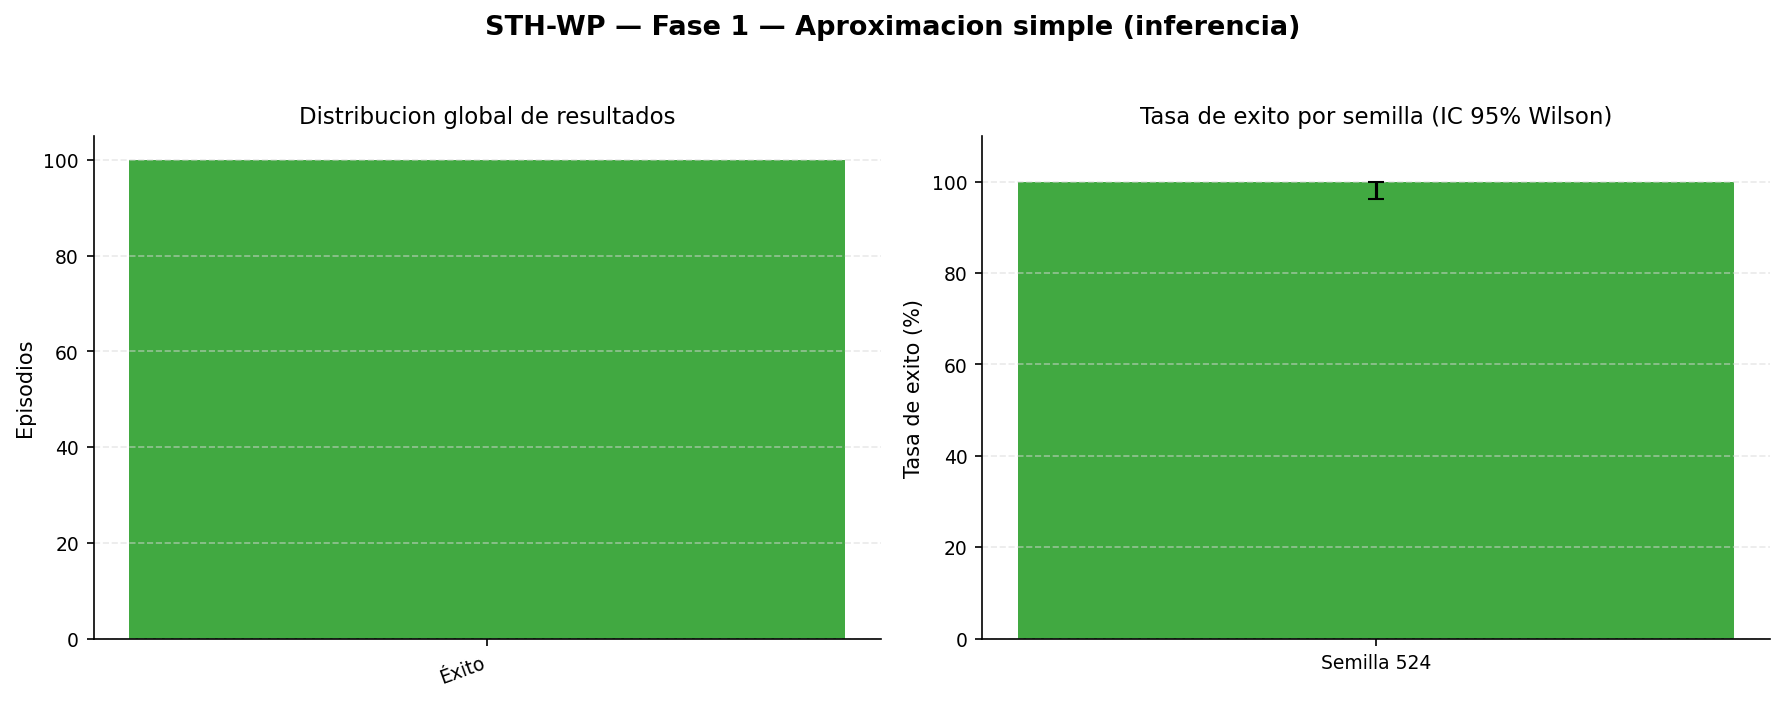

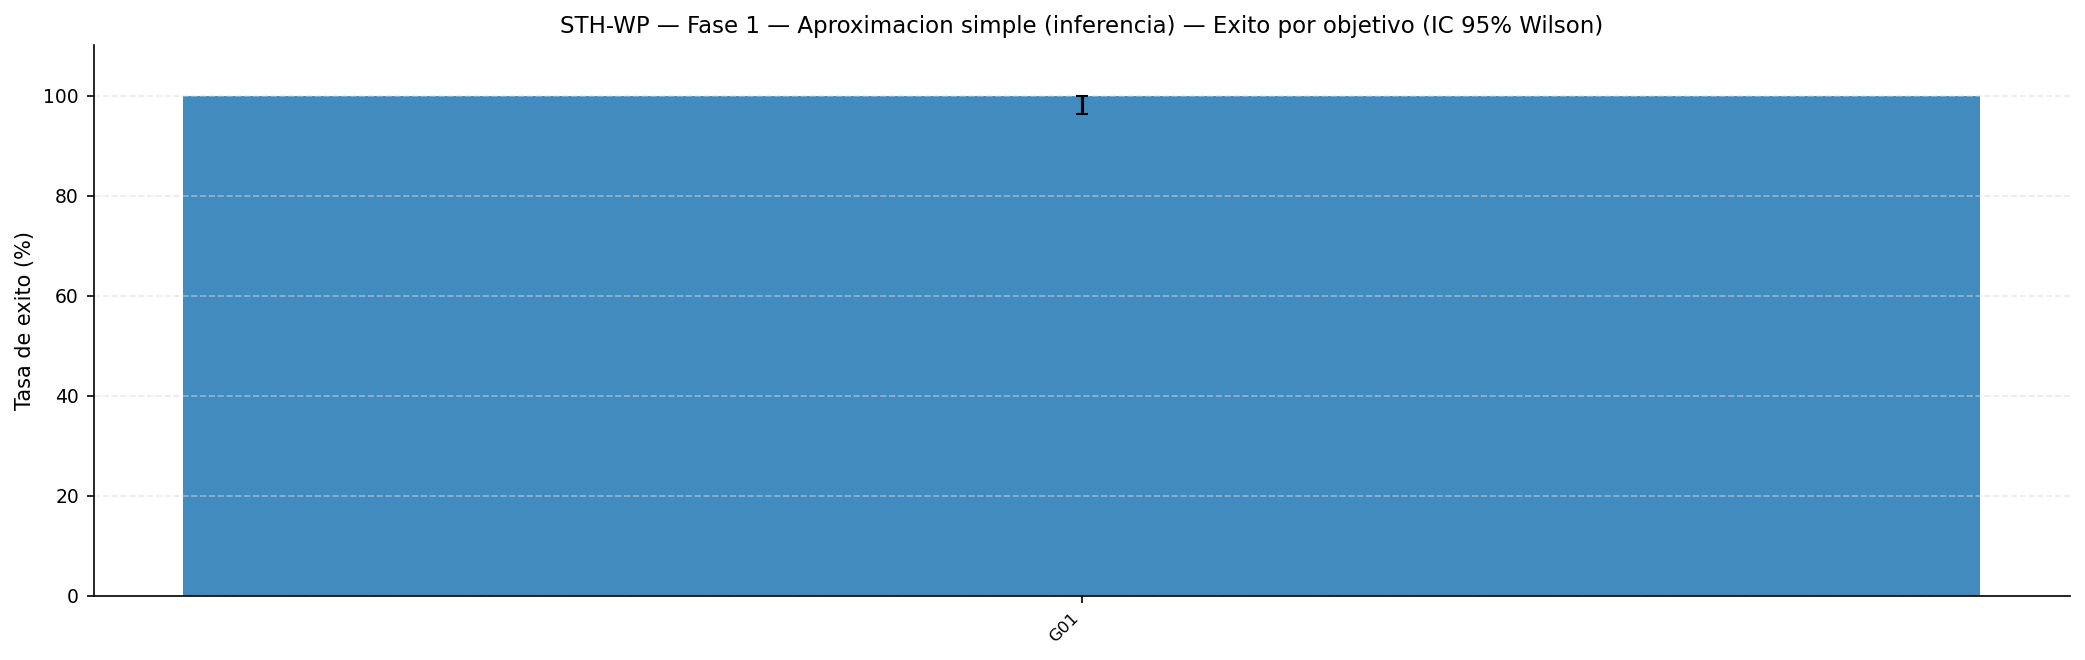

  [nota] Solo una semilla disponible: no se genera mapa de calor objetivo-semilla.


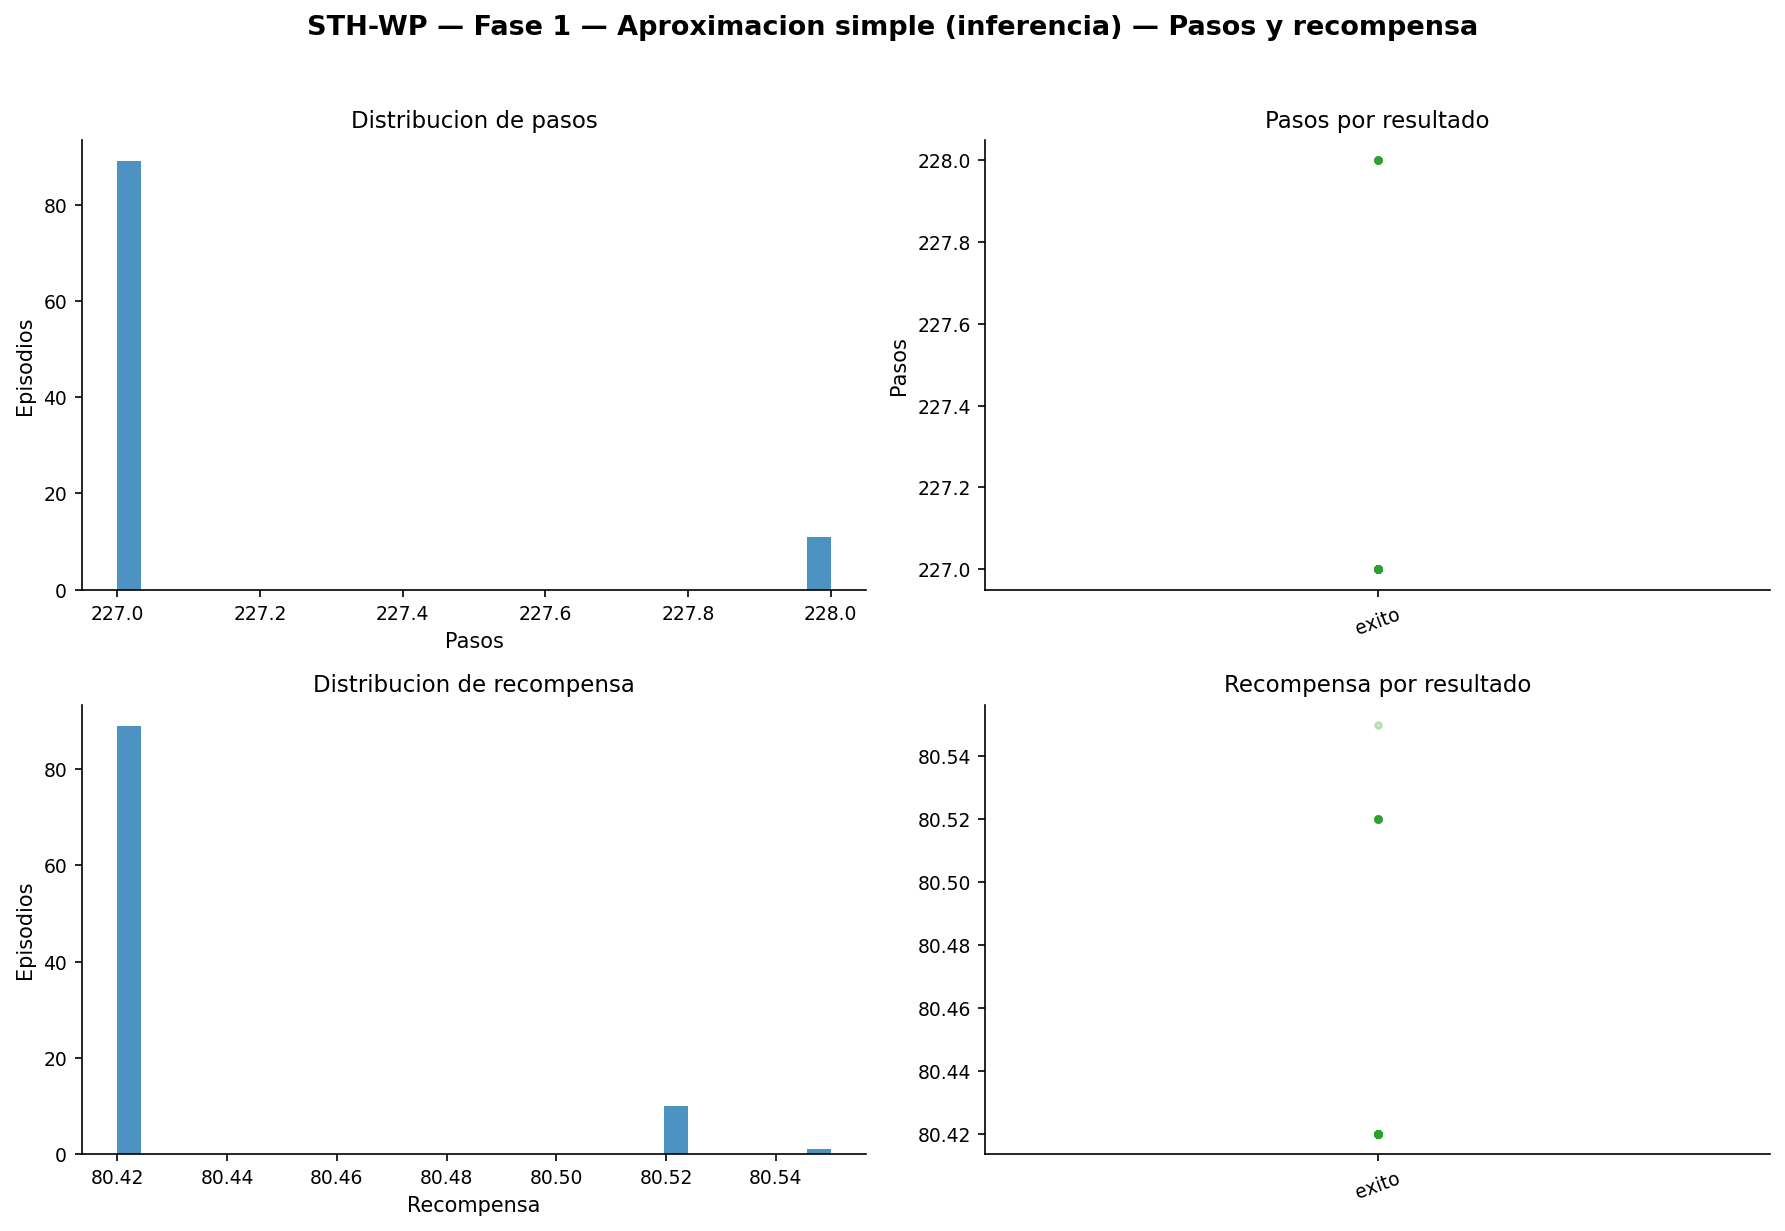

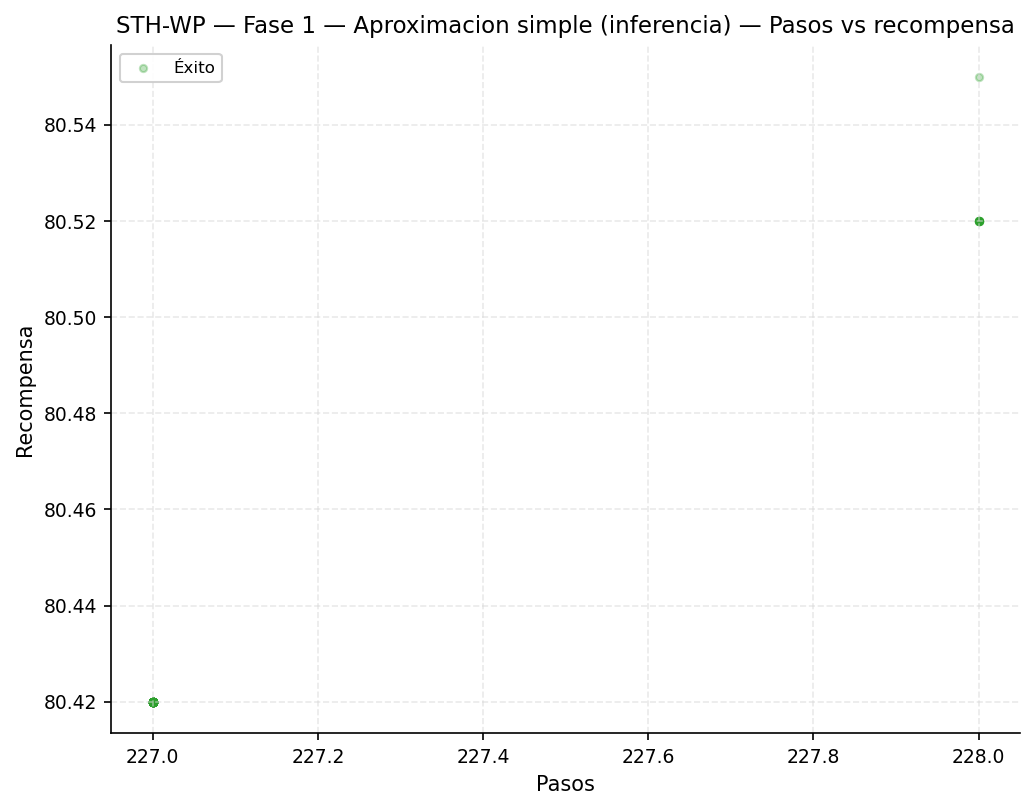

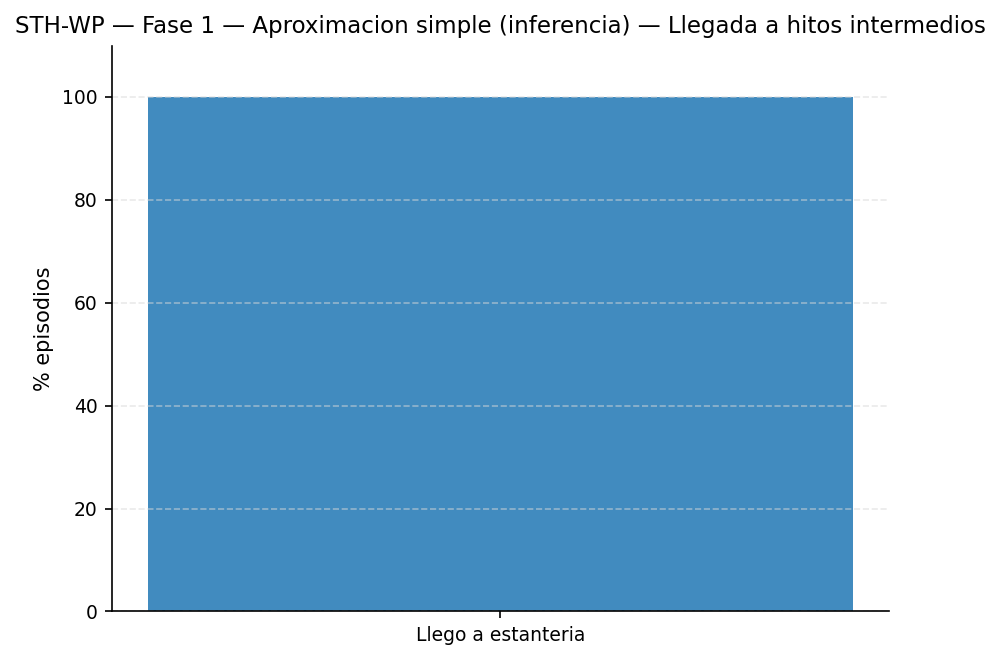

  Peores 3 objetivos: {'goal_01': np.float64(100.0)}
  Mejores 3 objetivos: {'goal_01': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,100,1,100,0,0,100.0,96.3,100.0,0.0,0.0,3.7,0.0,227.1,227.0,0.3,80.43,80.42,0.03,100.0,no registrada


In [5]:
resumen_stage1_sthwp = analyze_phase(sthwp_dfs["stage1"], "STH-WP — Fase 1 — Aproximacion simple (inferencia)", "fig_sthwp_stage1", ARCH_COLORS["STH-WP"])
if not resumen_stage1_sthwp.empty:
    resumen_stage1_sthwp.to_csv(TABLES_DIR / "tabla_resumen_sthwp_stage1.csv", index=False)
    display(resumen_stage1_sthwp)

### Fase 2 — Aproximacion generalizada (inferencia)

- **Tarea evaluada**: aproximacion generalizada a 28 ubicaciones
- **Peaton presente**: No
- **Observaciones de auditoria**: CORREGIDO: verificado por MODEL_PATH que infer_run002_s524_stage2.py carga 'pruebas/run002_s524_stage2_final' (cadena canonica). Los tres archivos infer_run001_s{42,123,524}_stage2.csv SI existen, pero sus scripts (inferencia_sthwp/infer_stage2_s{seed}.py) cargan explicitamente 'pruebas/run001_s{seed}_stage2_final' -- la misma rama run001 descartada de Fase 1, que no continua a Fase 3v2/4v2. Se EXCLUYEN de la Fase 2 canonica por el mismo motivo (no mezclar rama valida con entrenamiento abandonado); se muestran solo como nota de auditoria. Por tanto la Fase 2 canonica solo tiene inferencia disponible para la semilla 524: hueco visible para 42 y 123, no se sustituye ni se usa run001 como proxy.


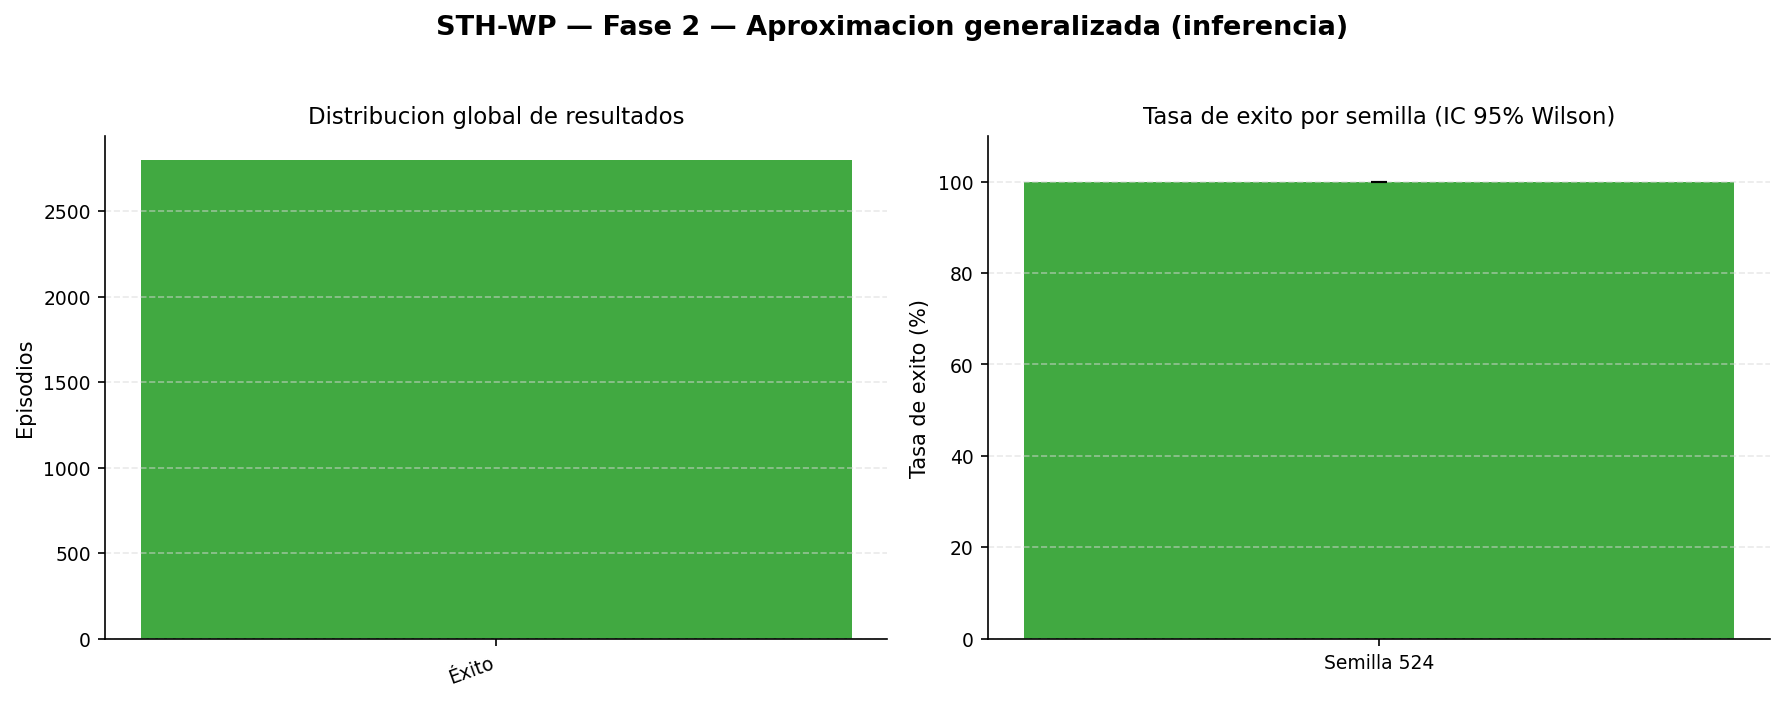

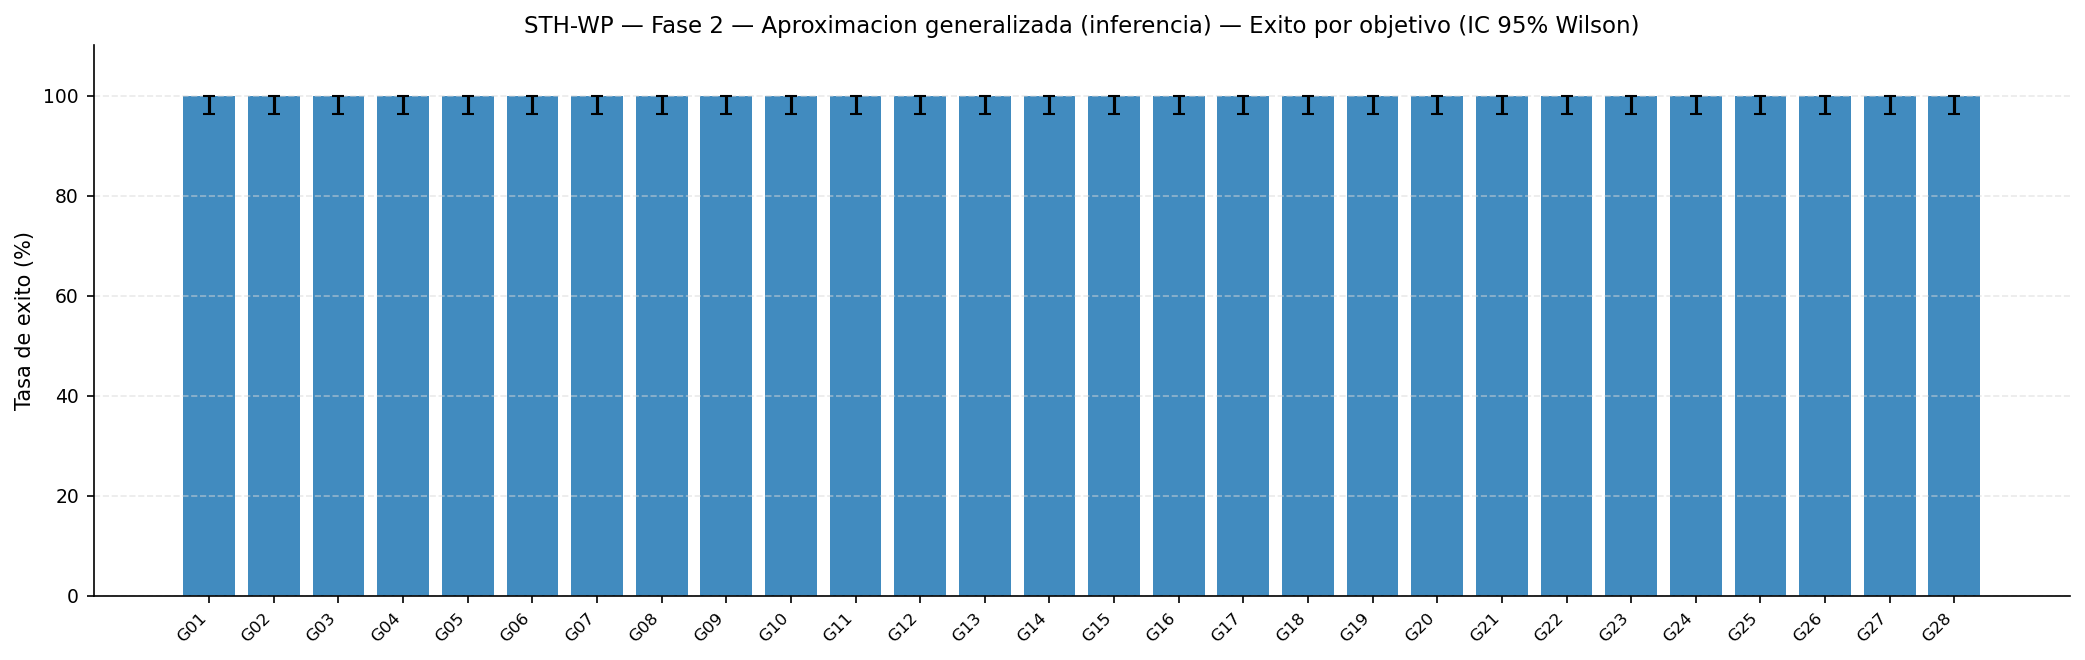

  [nota] Solo una semilla disponible: no se genera mapa de calor objetivo-semilla.


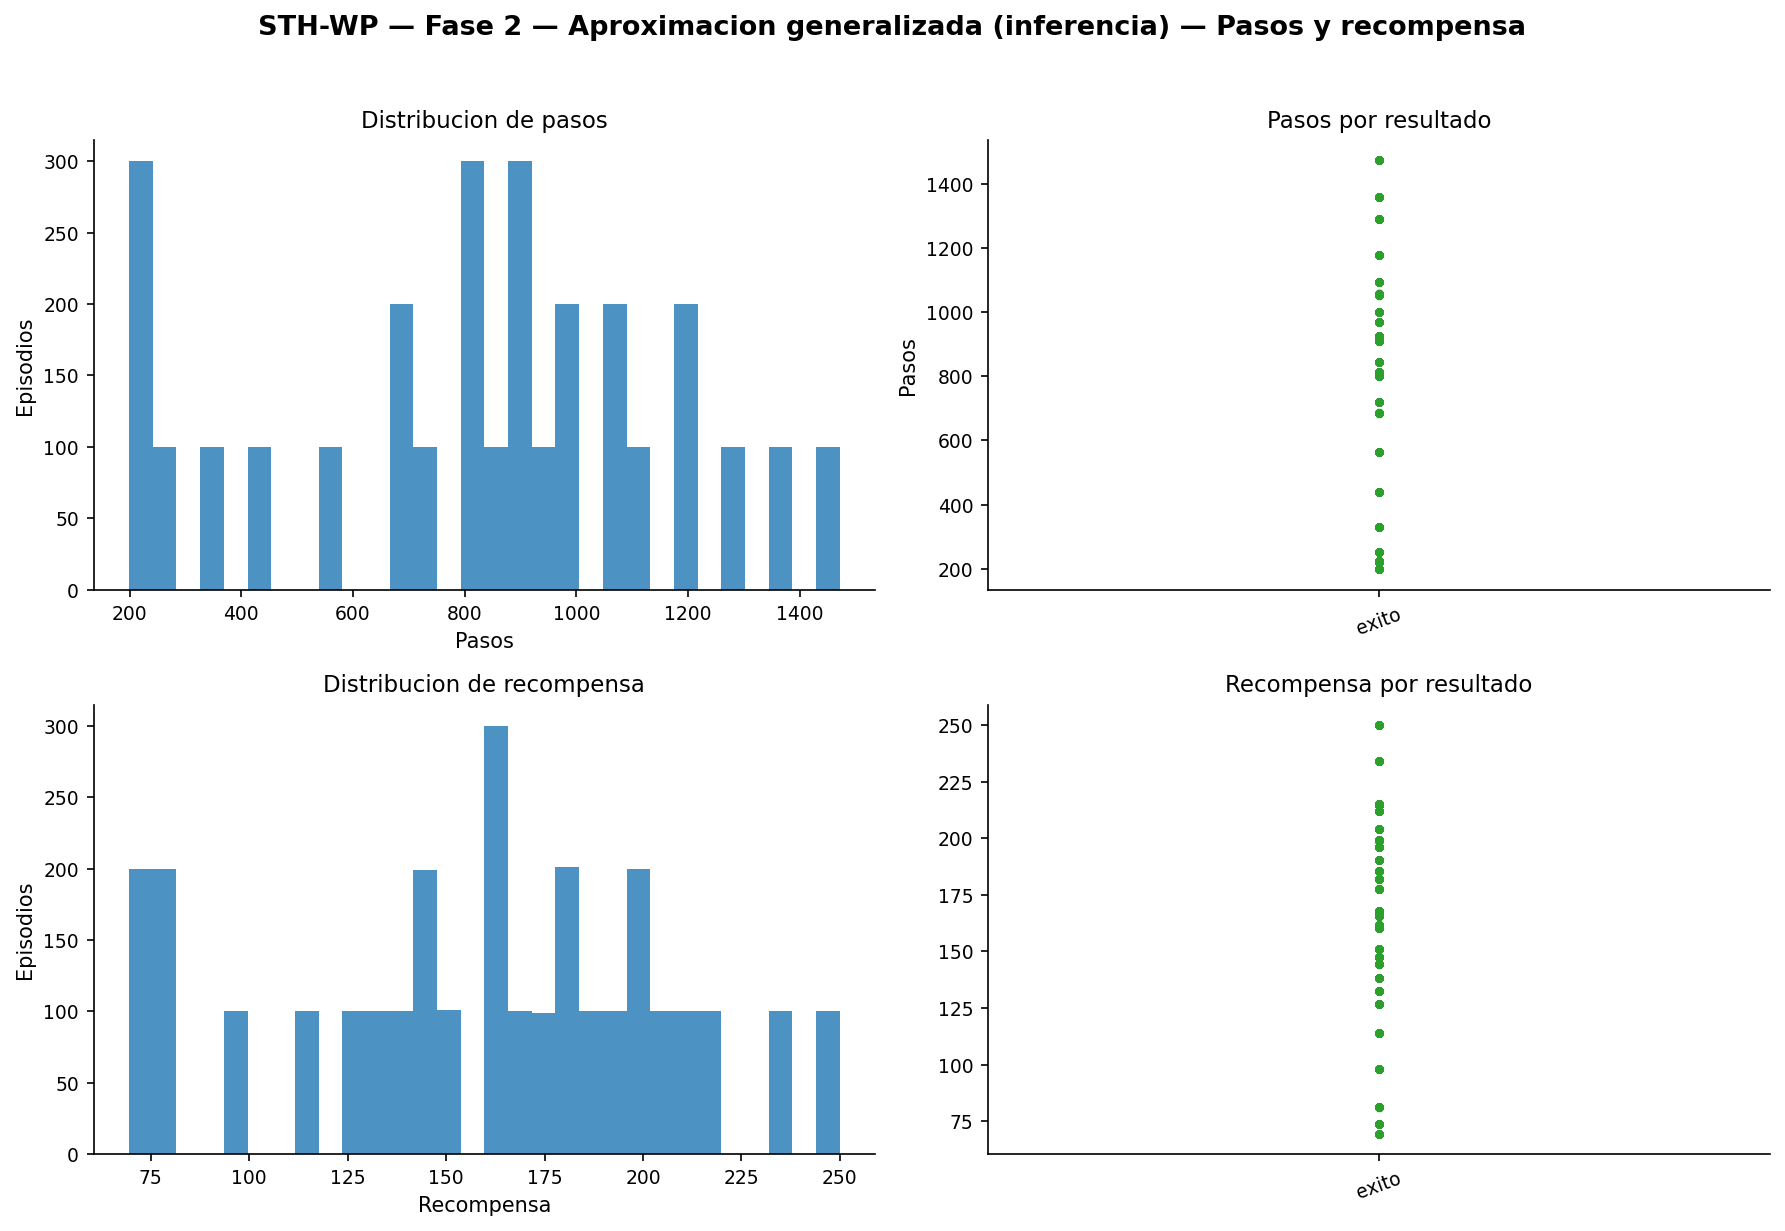

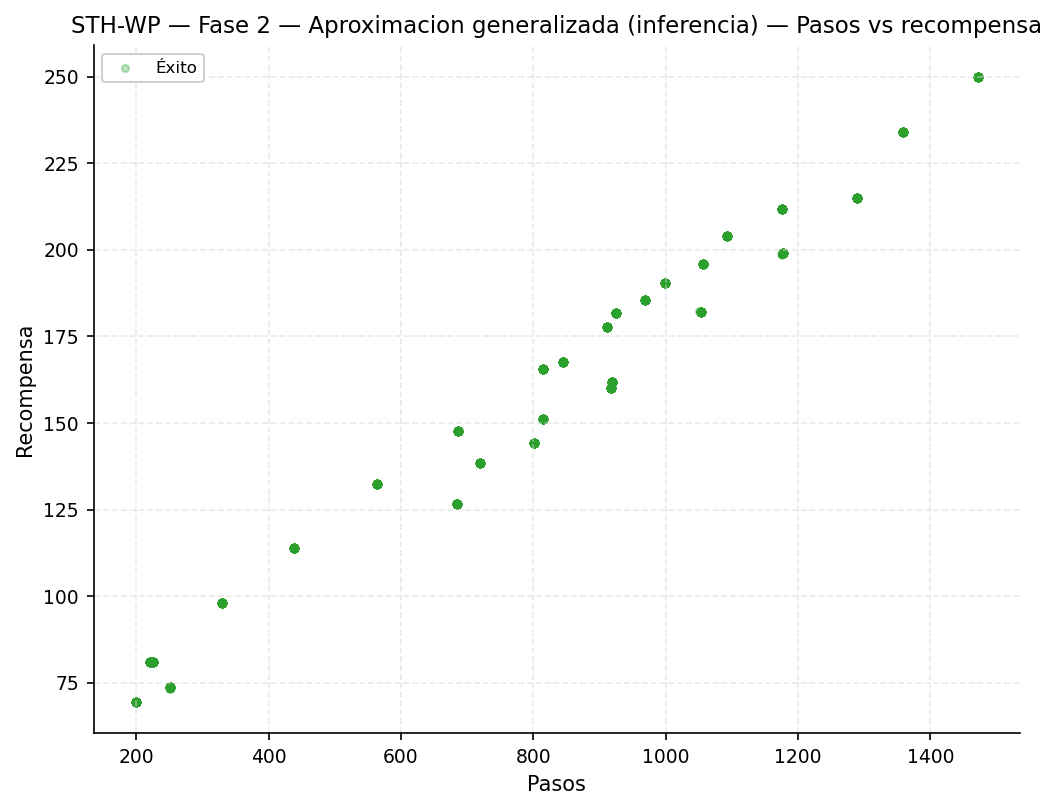

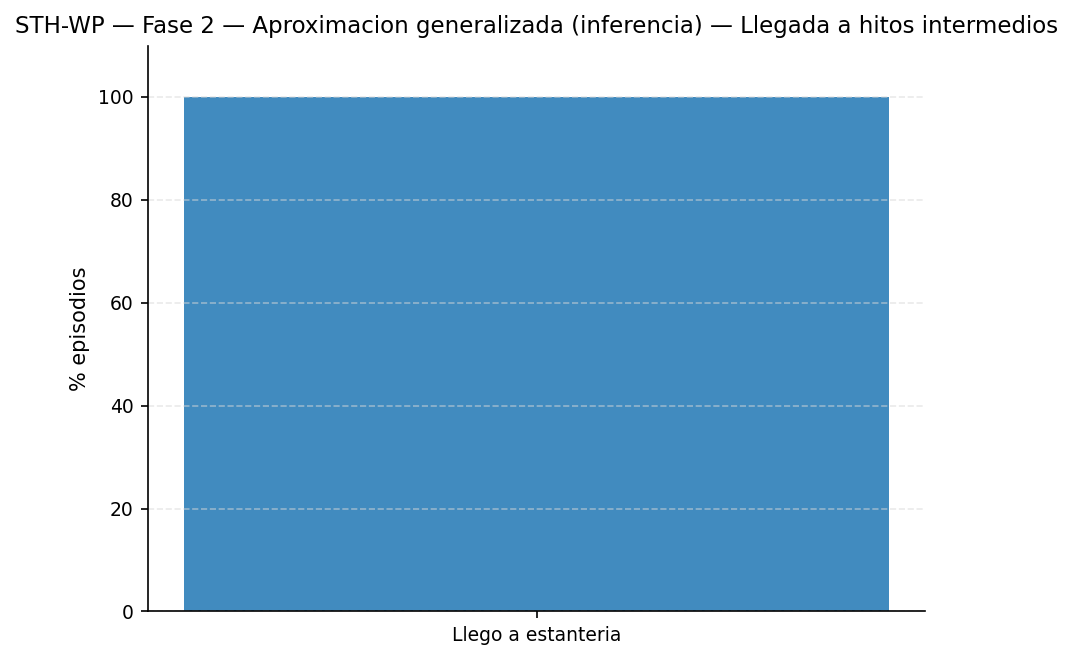

  Peores 3 objetivos: {'goal_01': np.float64(100.0), 'goal_26': np.float64(100.0), 'goal_25': np.float64(100.0)}
  Mejores 3 objetivos: {'goal_02': np.float64(100.0), 'goal_27': np.float64(100.0), 'goal_28': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,2800,1,2800,0,0,100.0,99.86,100.0,0.0,0.0,0.14,0.0,818.2,878.0,348.0,158.57,163.75,47.74,100.0,no registrada


In [6]:
resumen_stage2_sthwp = analyze_phase(sthwp_dfs["stage2"], "STH-WP — Fase 2 — Aproximacion generalizada (inferencia)", "fig_sthwp_stage2", ARCH_COLORS["STH-WP"])
if not resumen_stage2_sthwp.empty:
    resumen_stage2_sthwp.to_csv(TABLES_DIR / "tabla_resumen_sthwp_stage2.csv", index=False)
    display(resumen_stage2_sthwp)

### Fase 3v2 — Salida desde la estanteria (inferencia)

- **Tarea evaluada**: salida (exit) desde la estanteria hacia la zona de descarga
- **Peaton presente**: No
- **Observaciones de auditoria**: Se prioriza 3v2 frente a Fase 3 clasica (infer_run002_s524_stage3.csv, EXCLUIDA), tal y como exige el encargo.


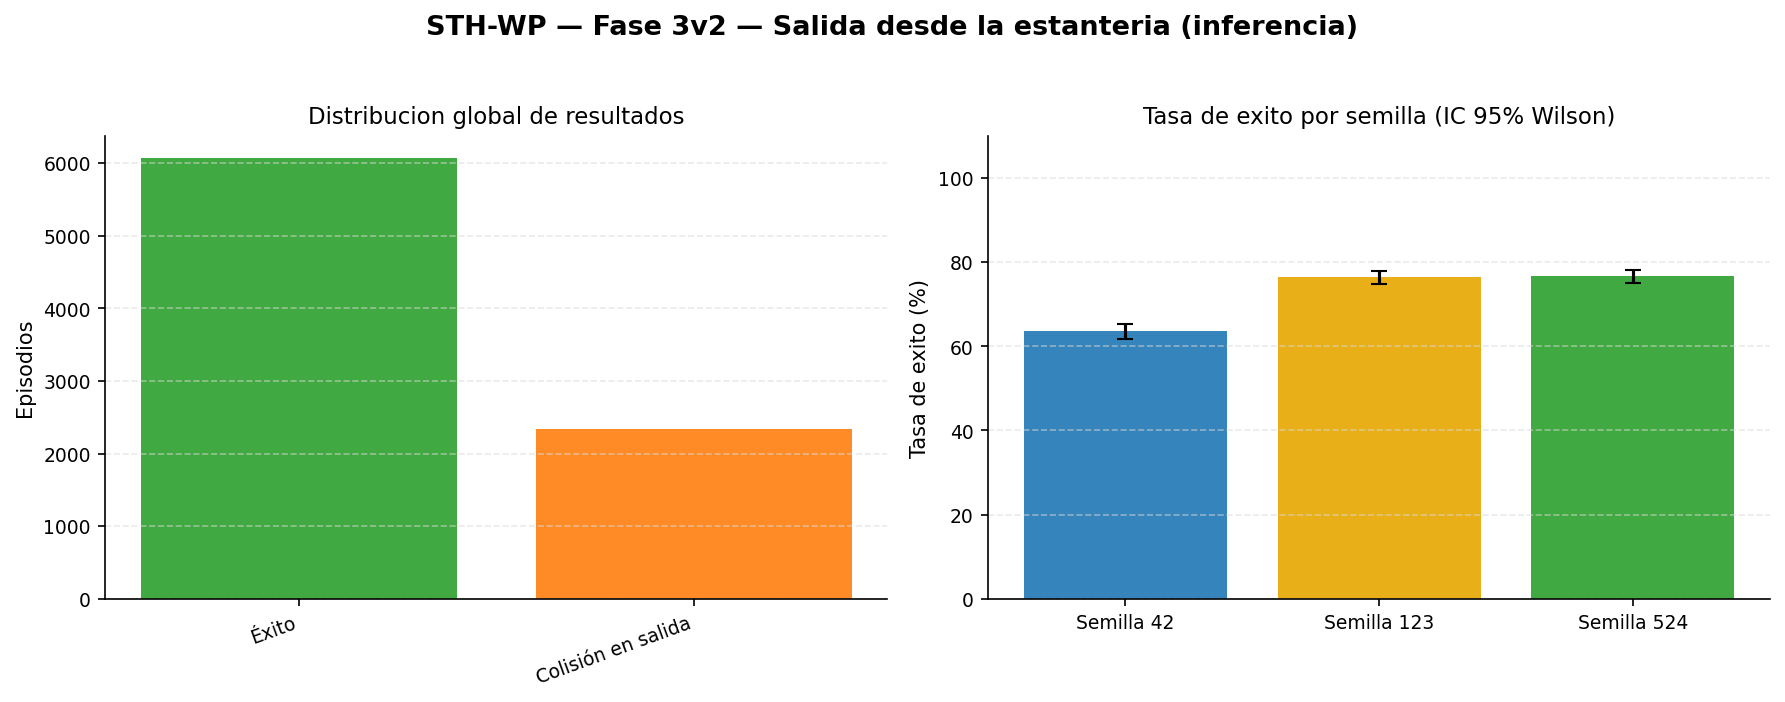

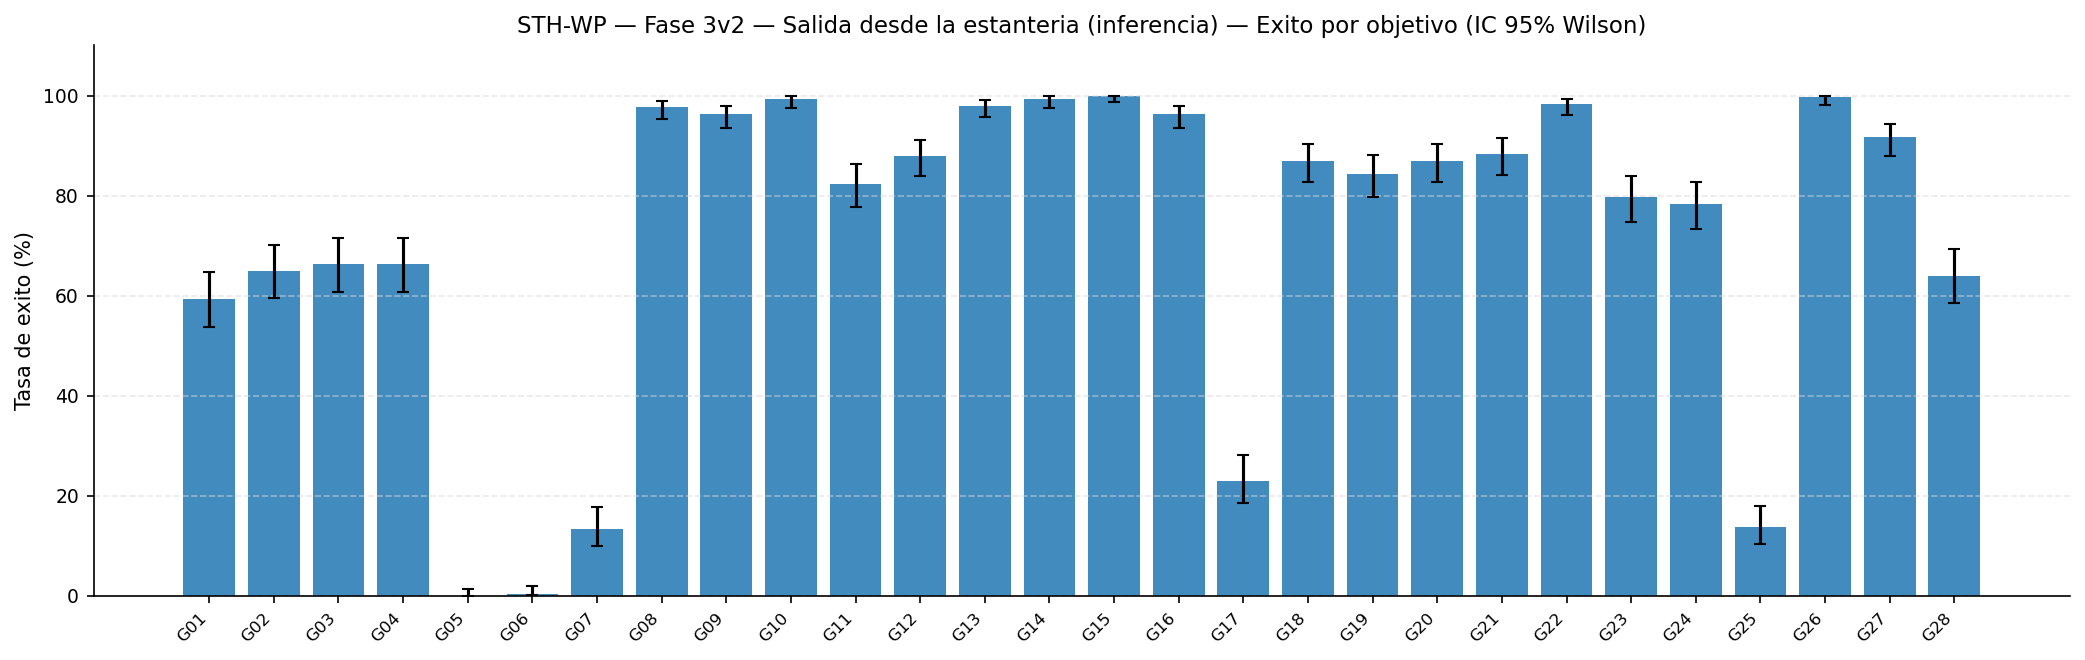

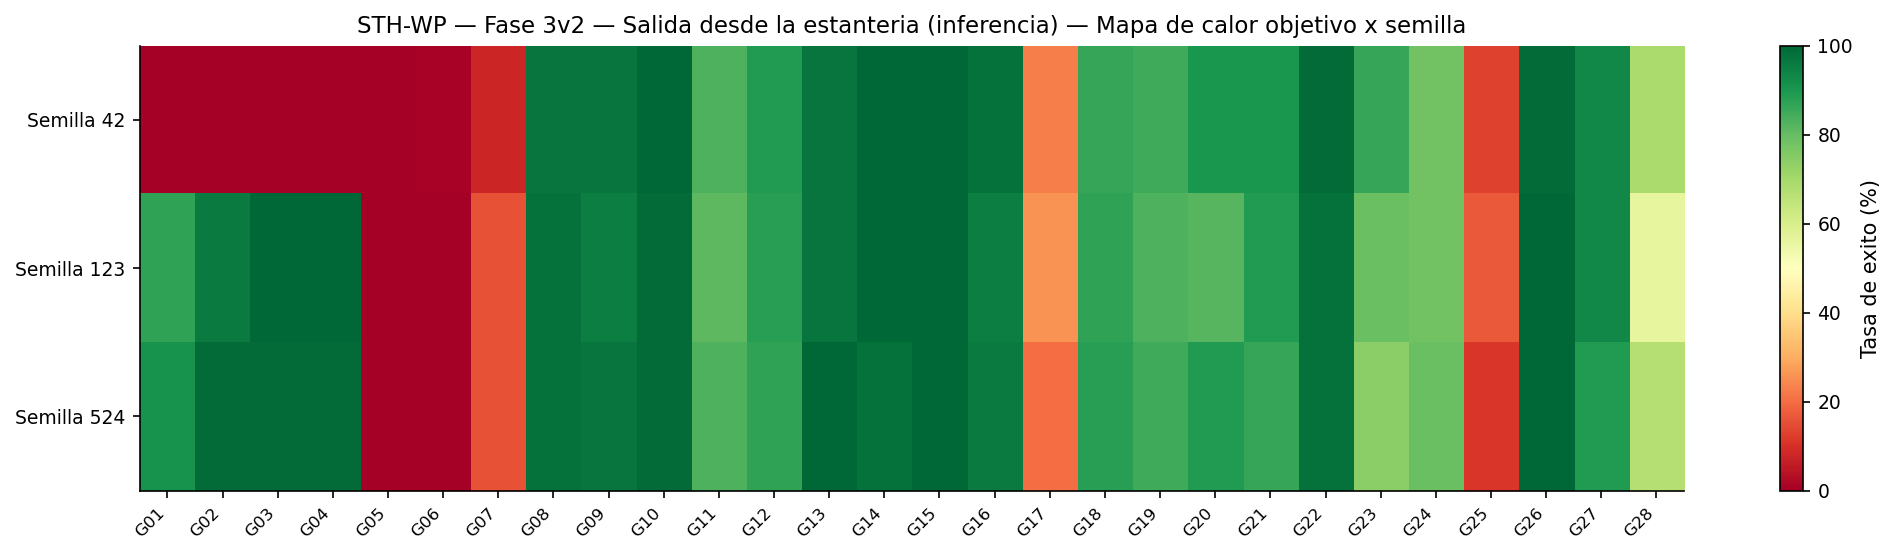

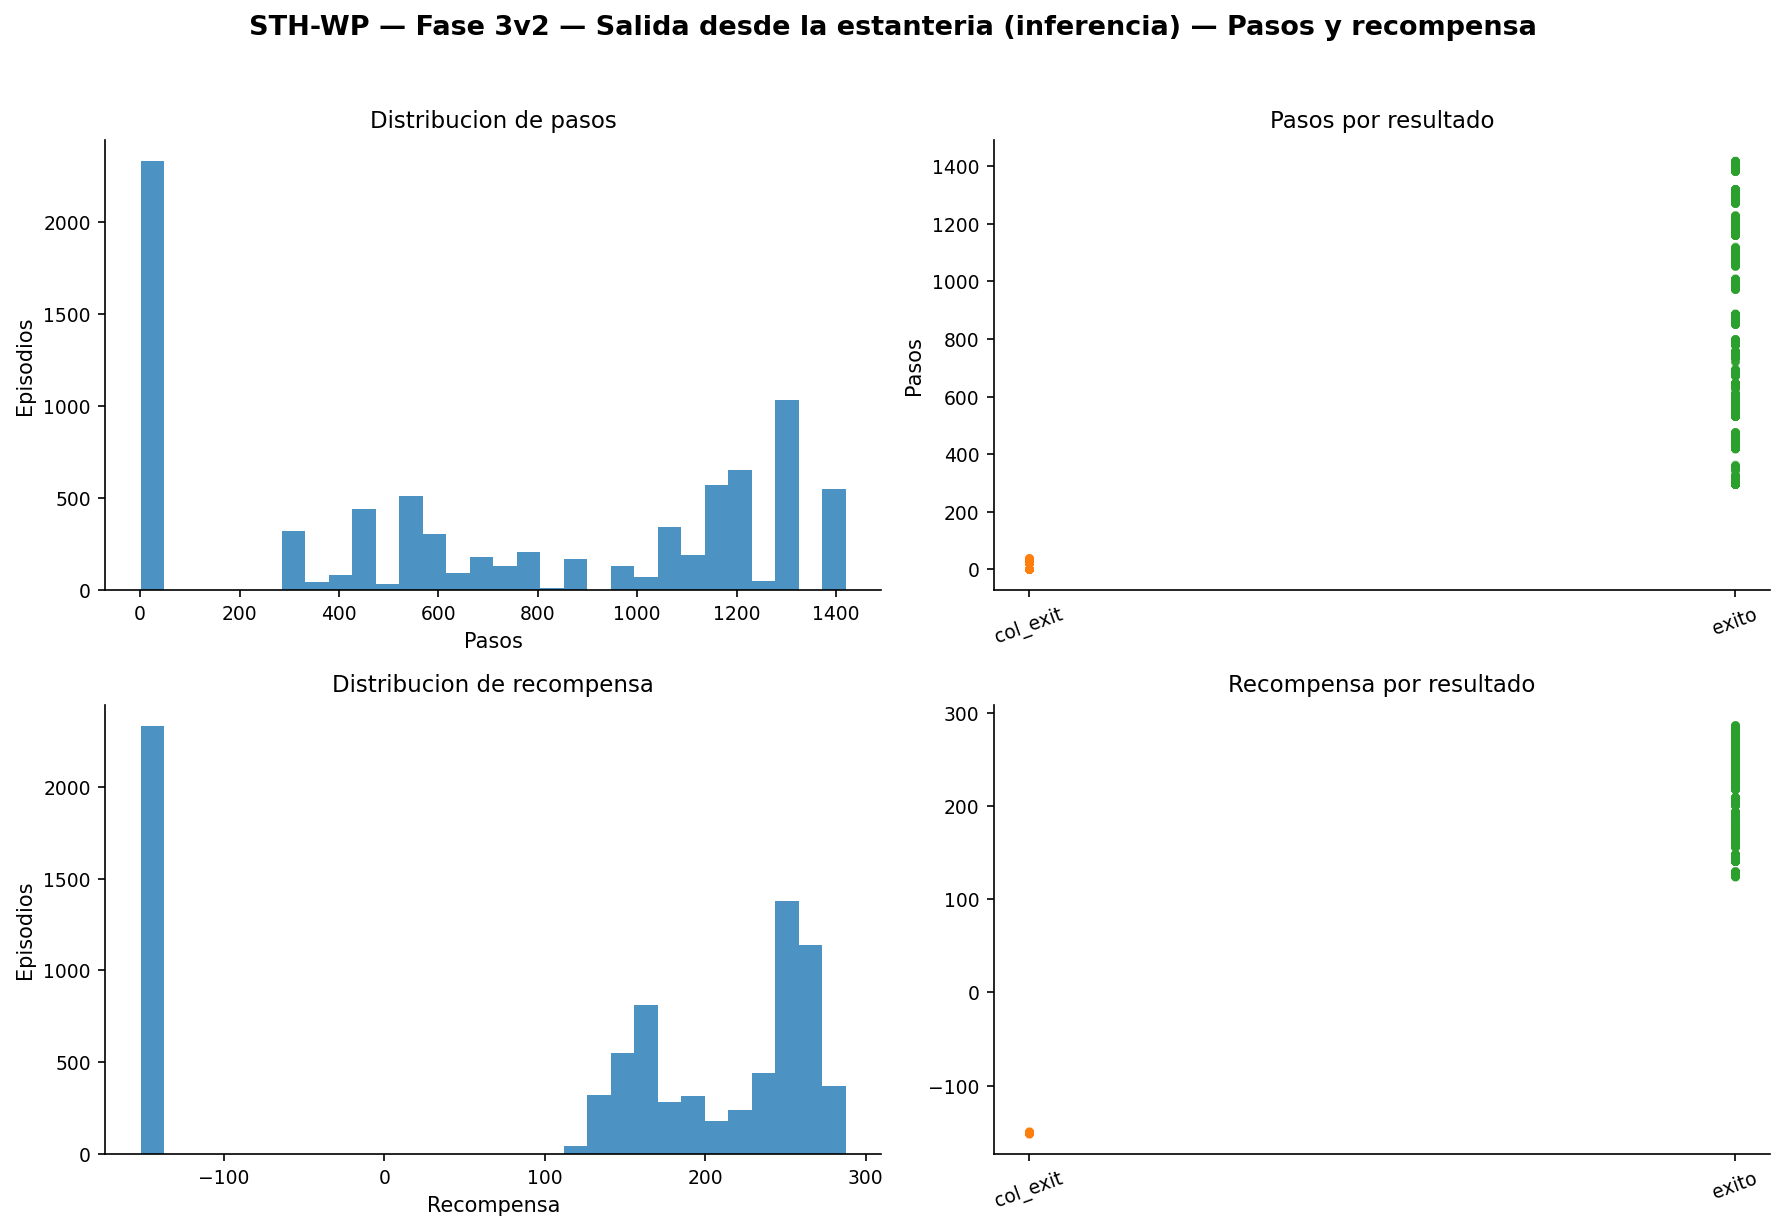

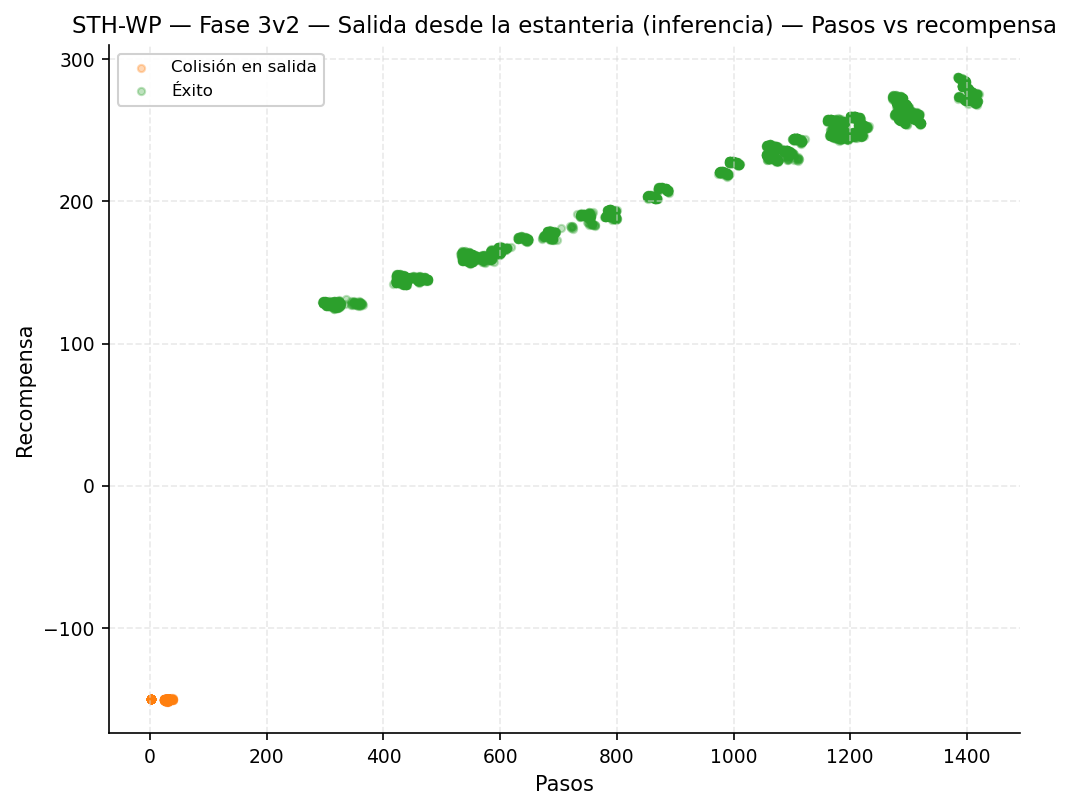

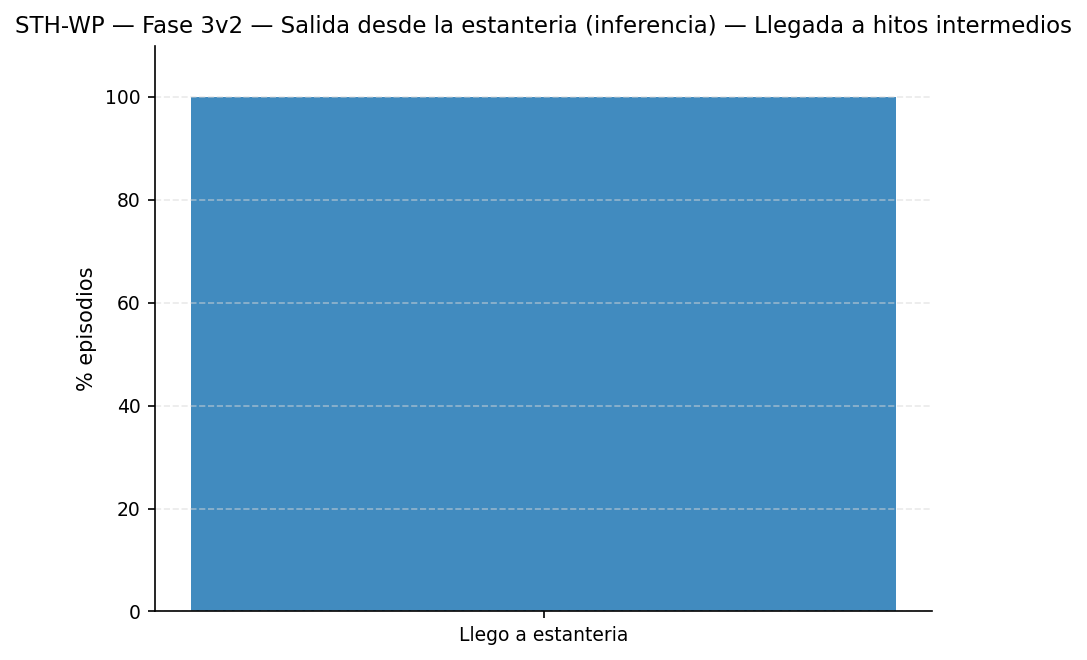

  Peores 3 objetivos: {'goal_05': np.float64(0.0), 'goal_06': np.float64(0.3), 'goal_07': np.float64(13.3)}
  Mejores 3 objetivos: {'goal_14': np.float64(99.3), 'goal_26': np.float64(99.7), 'goal_15': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,6069,2331,0,72.25,71.28,73.2,27.75,26.8,28.72,0.0,689.9,684.0,520.3,114.52,175.06,169.24,100.0,no registrada


In [7]:
resumen_stage3v2_sthwp = analyze_phase(sthwp_dfs["stage3v2"], "STH-WP — Fase 3v2 — Salida desde la estanteria (inferencia)", "fig_sthwp_stage3v2", ARCH_COLORS["STH-WP"])
if not resumen_stage3v2_sthwp.empty:
    resumen_stage3v2_sthwp.to_csv(TABLES_DIR / "tabla_resumen_sthwp_stage3v2.csv", index=False)
    display(resumen_stage3v2_sthwp)

### Fase 4v2 — Aproximacion + salida (inferencia)

- **Tarea evaluada**: ciclo aproximacion+salida en el mismo episodio
- **Peaton presente**: No
- **Observaciones de auditoria**: Se prioriza 4v2 frente a Fase 4 clasica (infer_run002_s524_stage4.csv, EXCLUIDA).


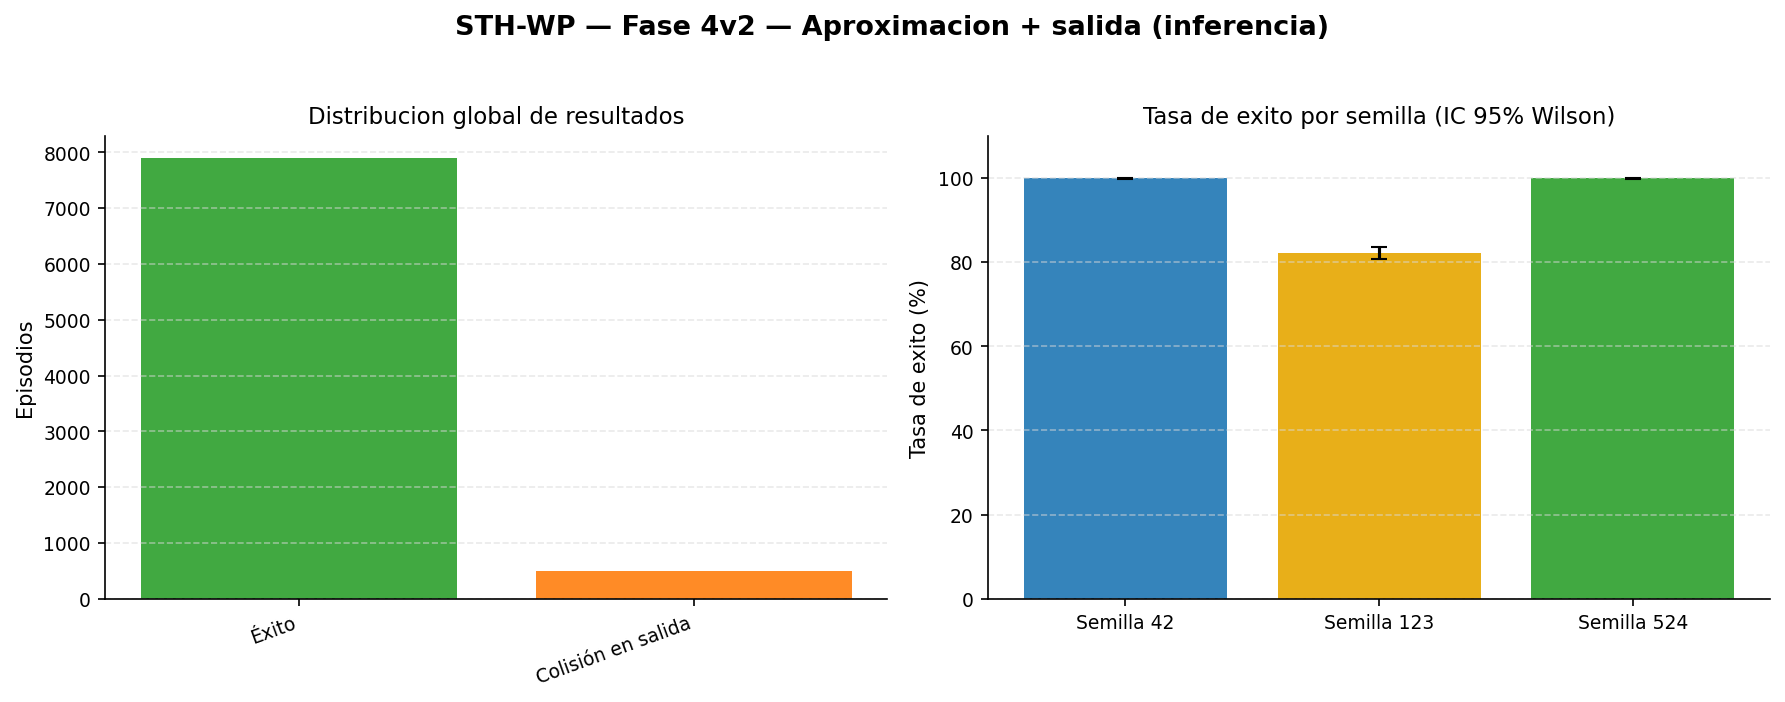

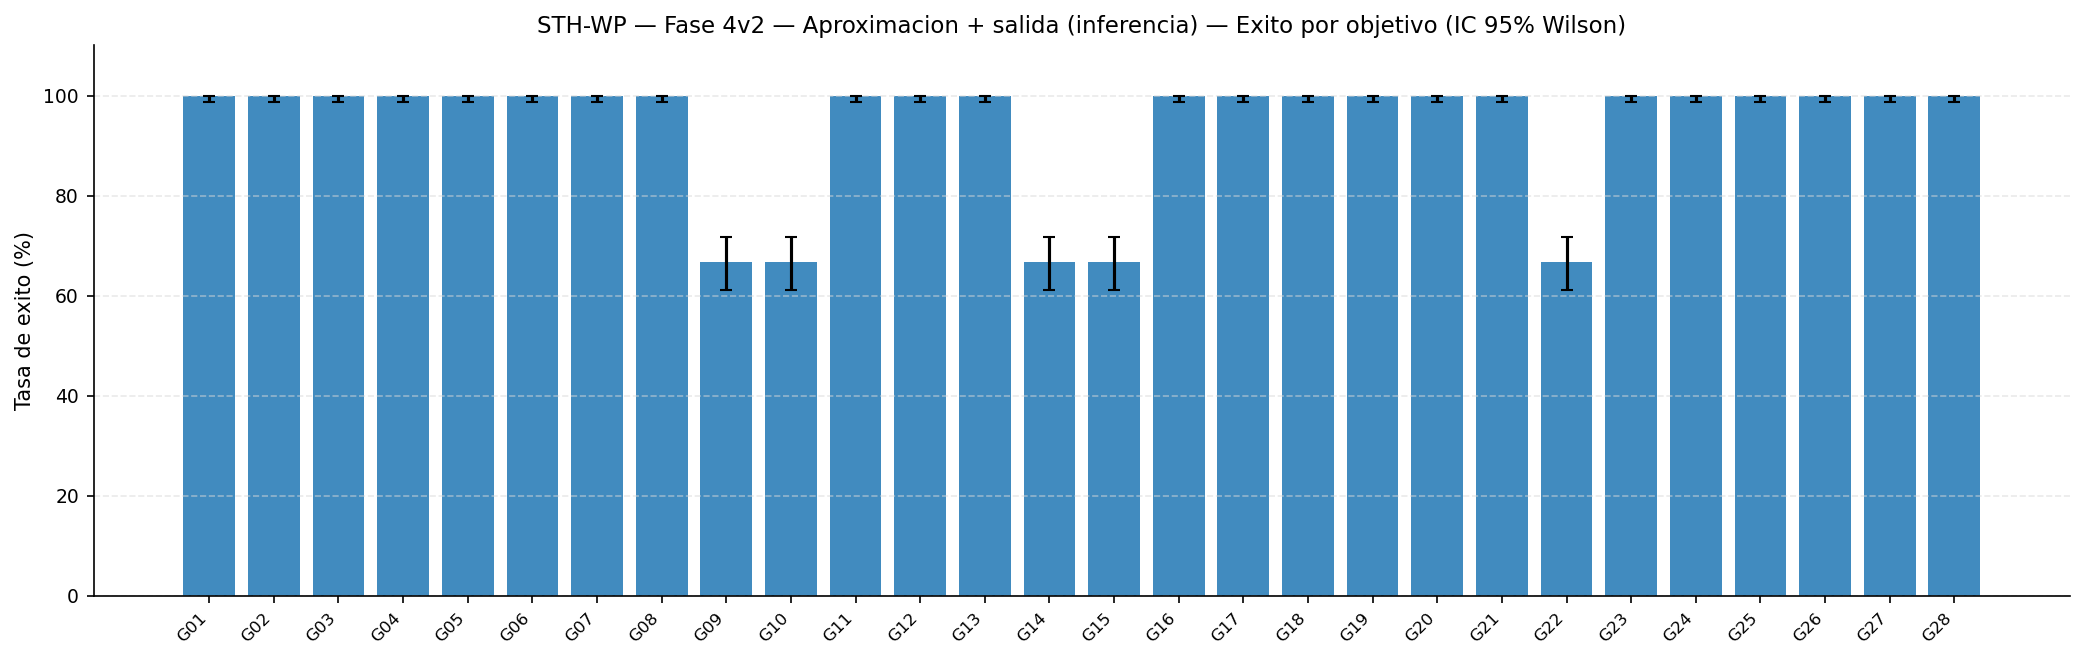

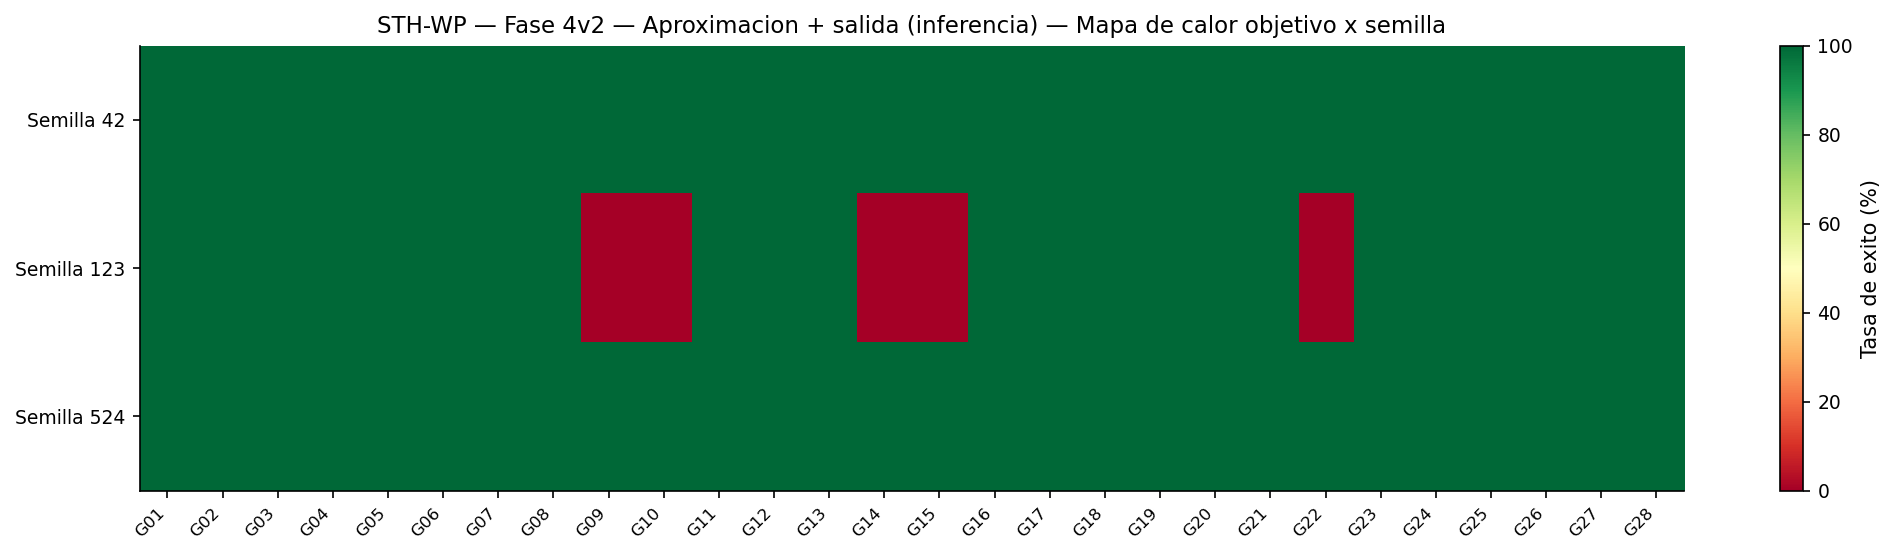

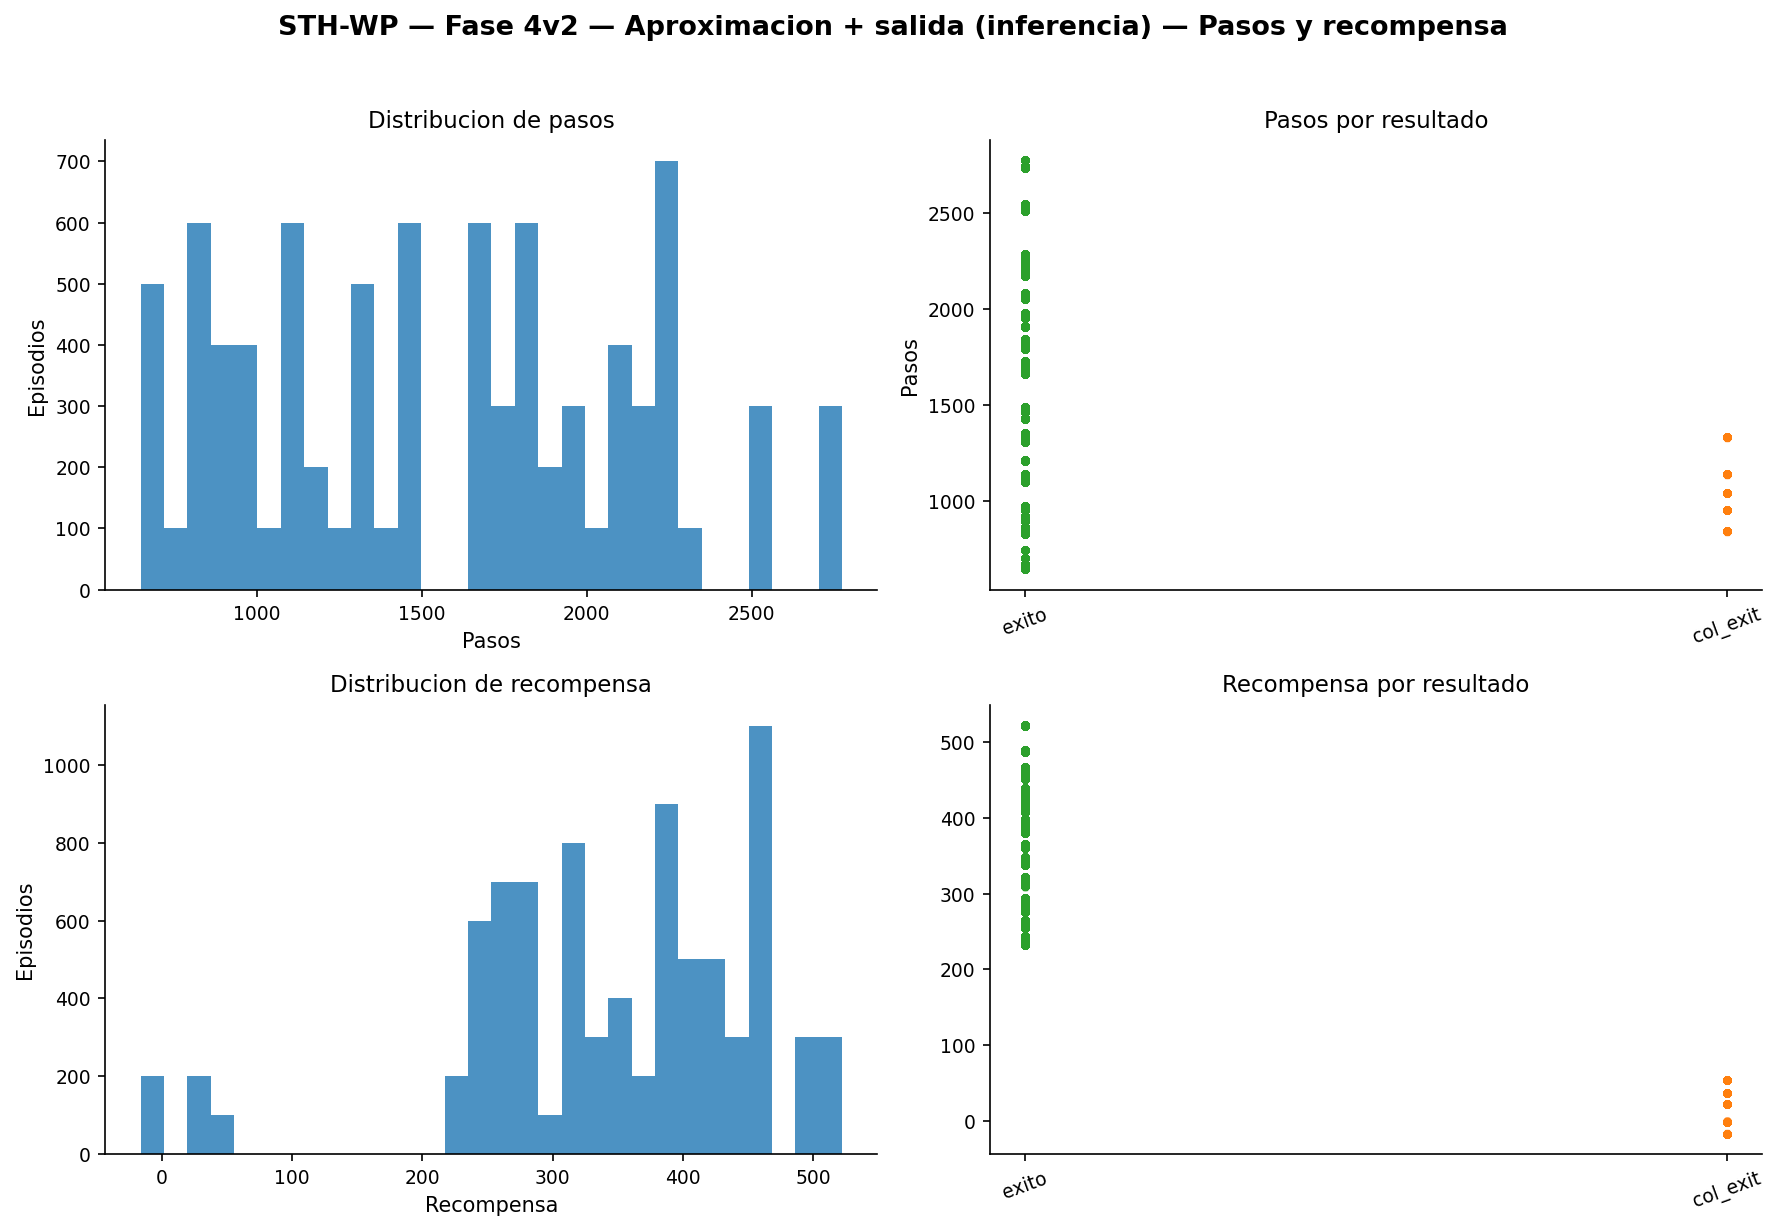

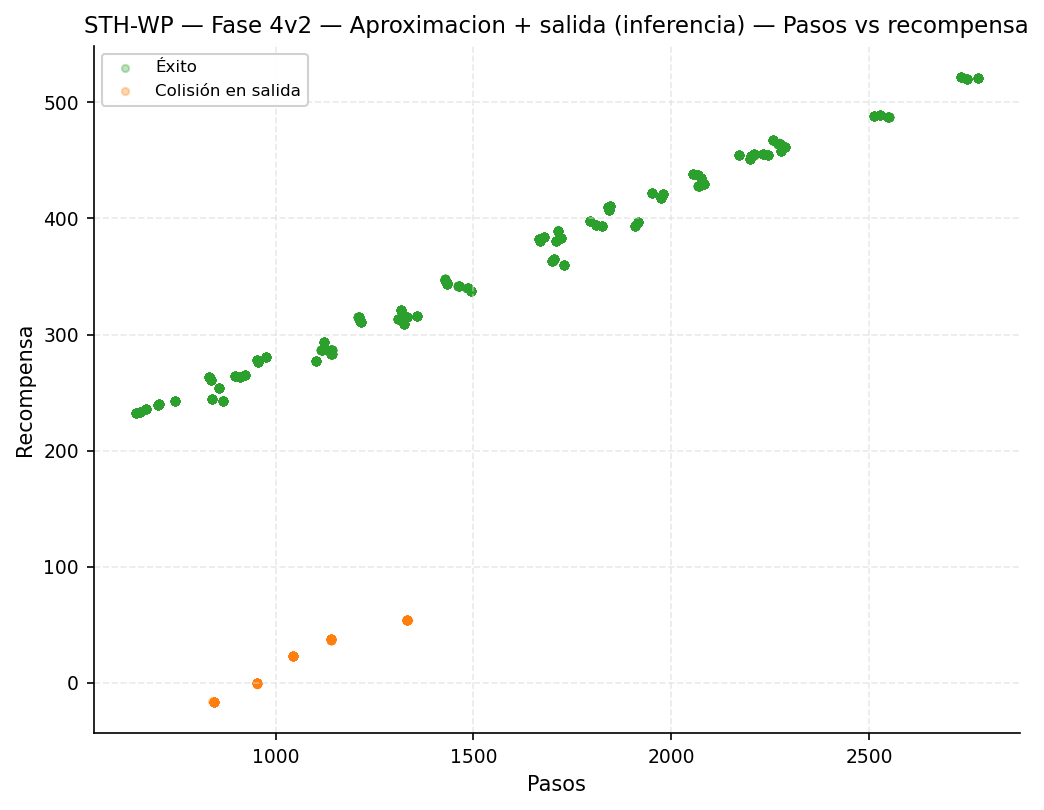

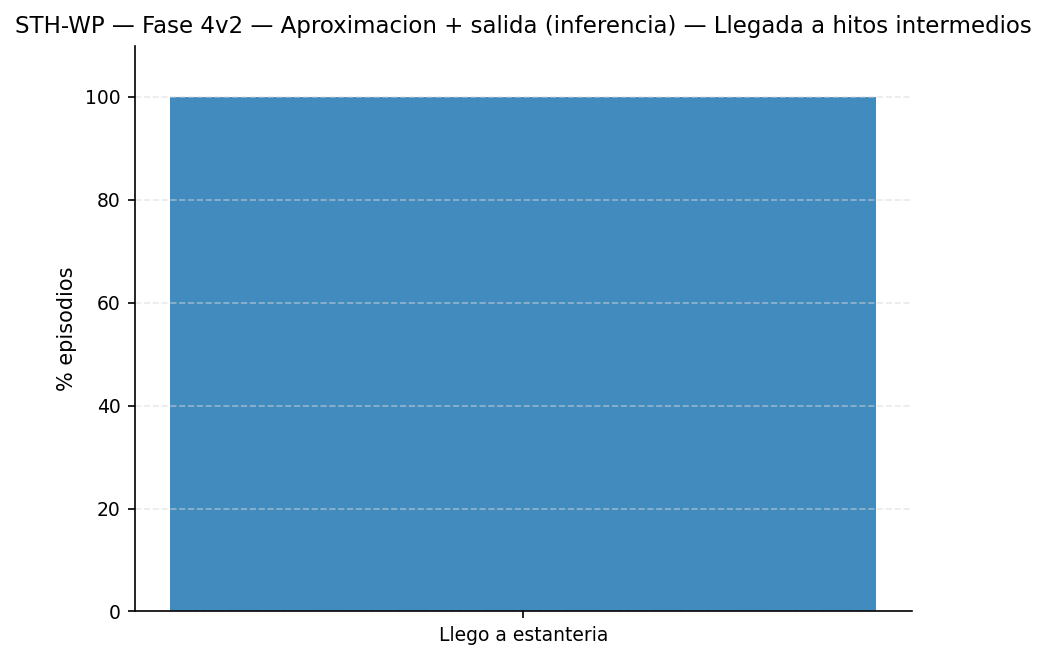

  Peores 3 objetivos: {'goal_14': np.float64(66.7), 'goal_22': np.float64(66.7), 'goal_09': np.float64(66.7)}
  Mejores 3 objetivos: {'goal_02': np.float64(100.0), 'goal_27': np.float64(100.0), 'goal_28': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,7900,500,0,94.05,93.52,94.53,5.95,5.47,6.48,0.0,1565.8,1579.0,575.7,342.49,353.71,114.27,100.0,no registrada


In [8]:
resumen_stage4v2_sthwp = analyze_phase(sthwp_dfs["stage4v2"], "STH-WP — Fase 4v2 — Aproximacion + salida (inferencia)", "fig_sthwp_stage4v2", ARCH_COLORS["STH-WP"])
if not resumen_stage4v2_sthwp.empty:
    resumen_stage4v2_sthwp.to_csv(TABLES_DIR / "tabla_resumen_sthwp_stage4v2.csv", index=False)
    display(resumen_stage4v2_sthwp)

### Fase 5 — Retorno a la base (inferencia)

- **Tarea evaluada**: retorno puro (zona de descarga -> zona de espera)
- **Peaton presente**: No
- **Observaciones de auditoria**: Las tres semillas disponibles.


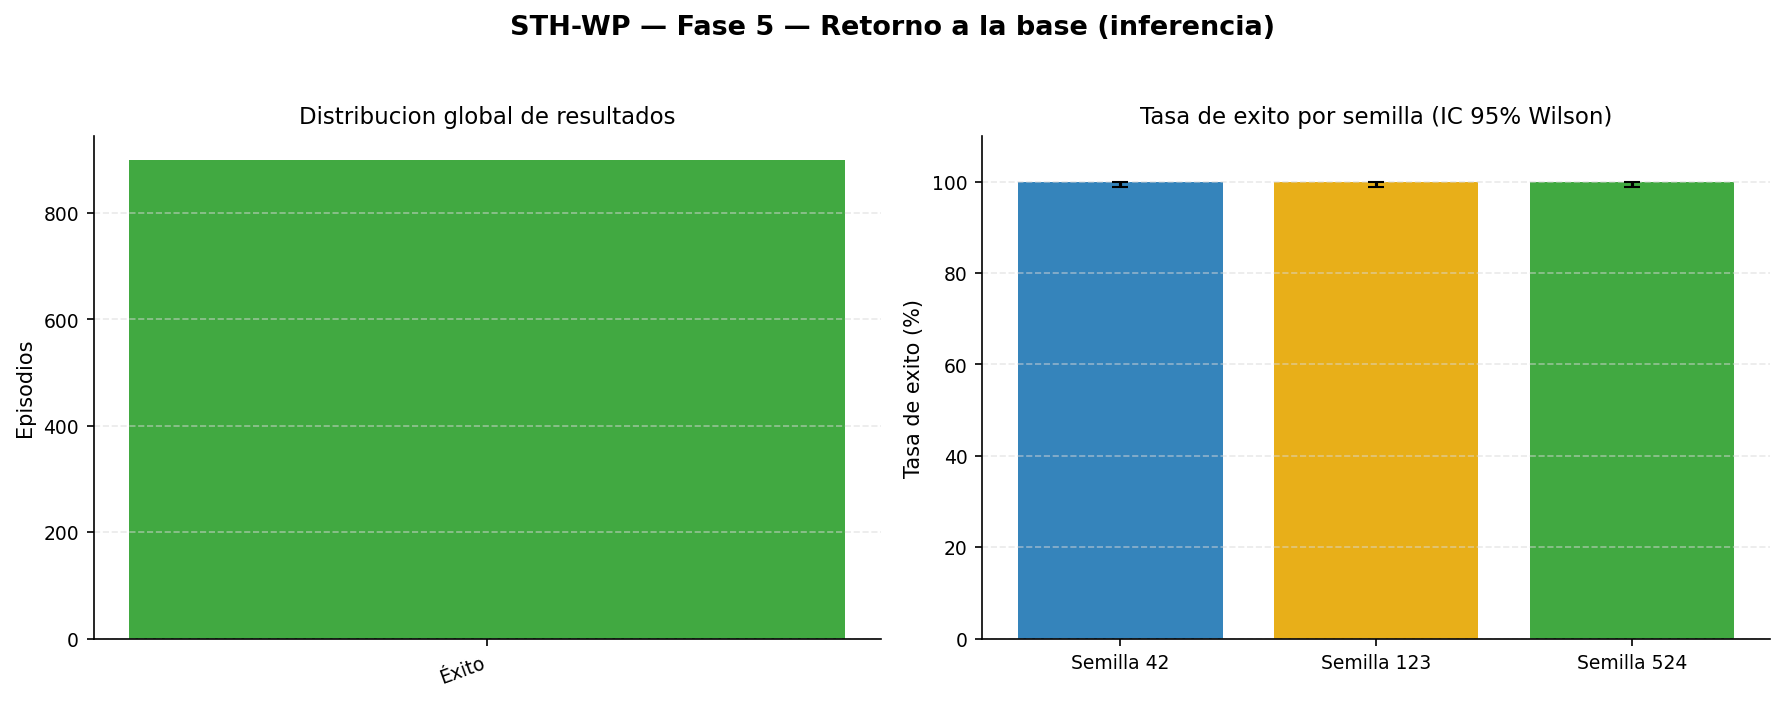

  [nota] Esta fase no registra goal_id por episodio: no se generan graficas por objetivo.


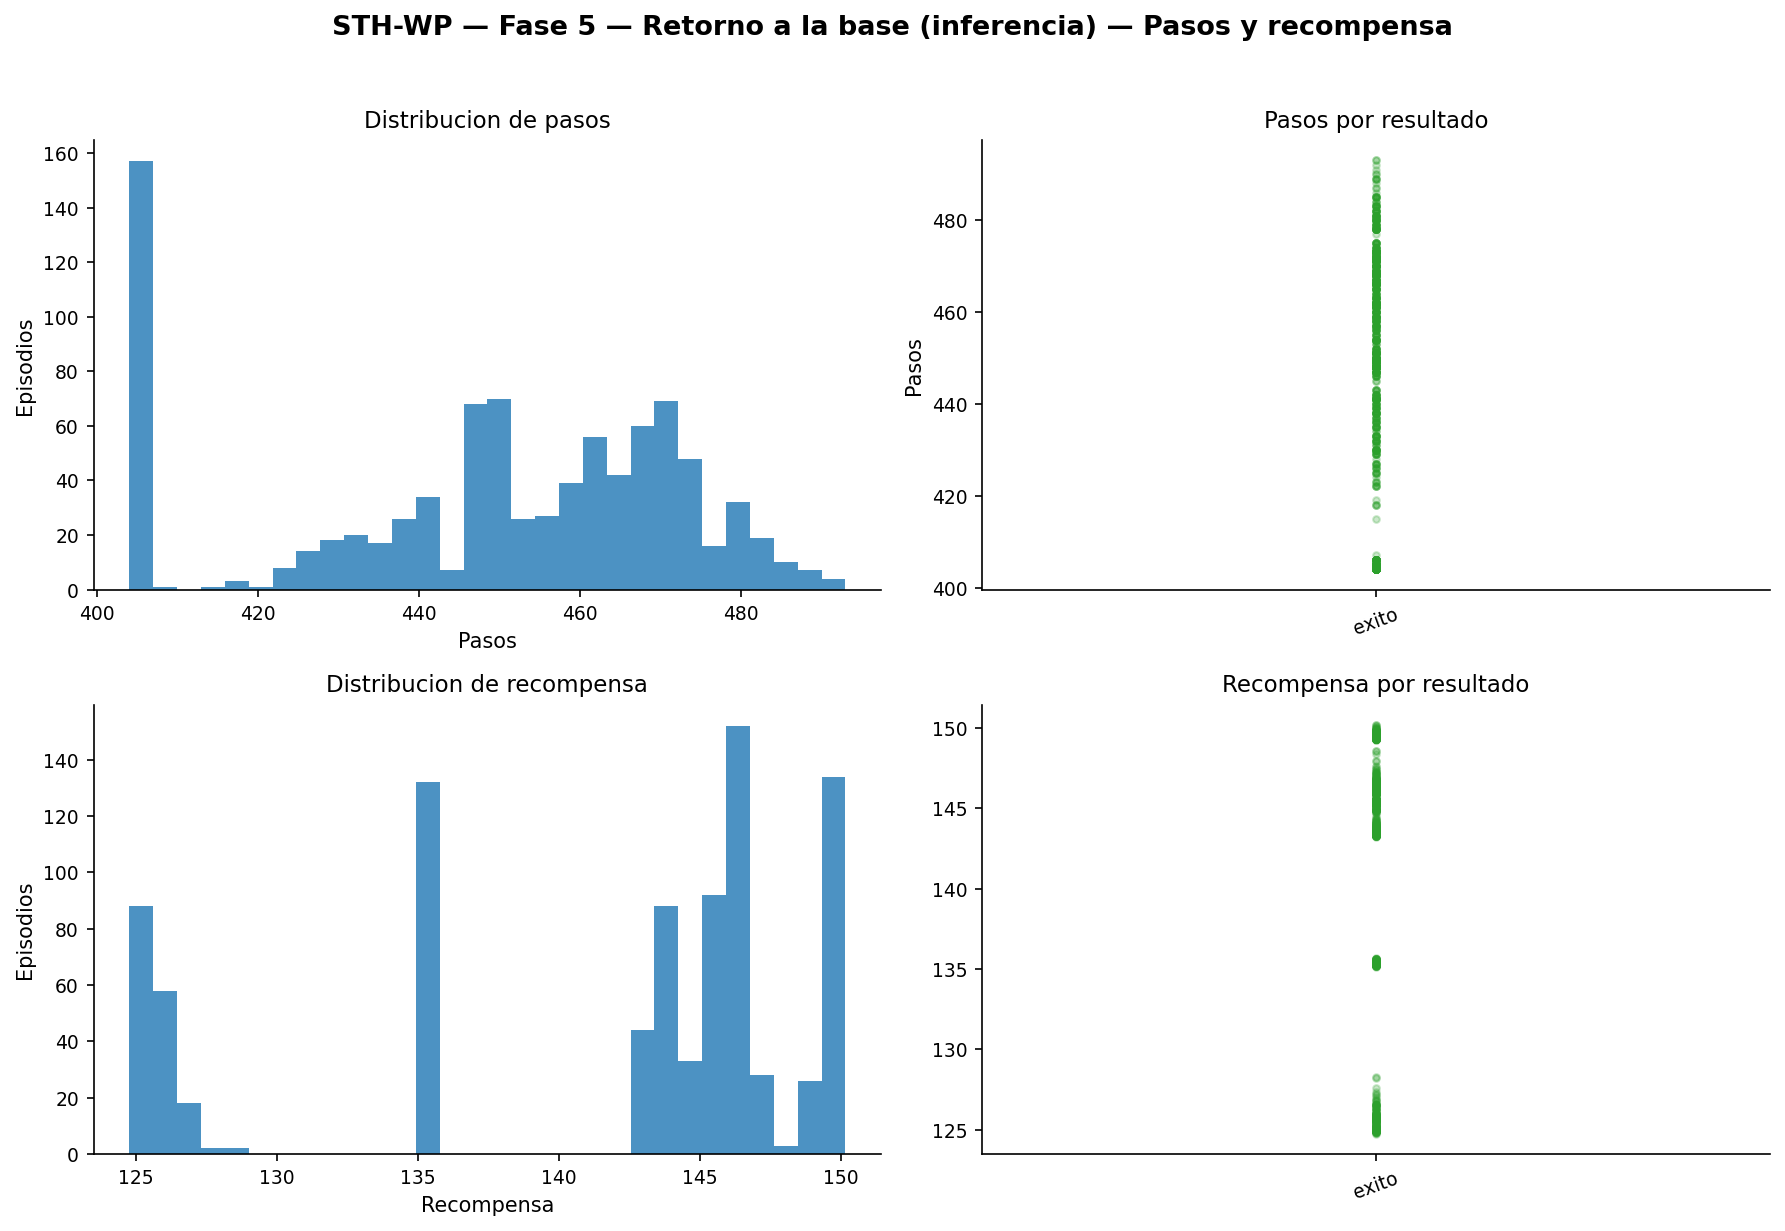

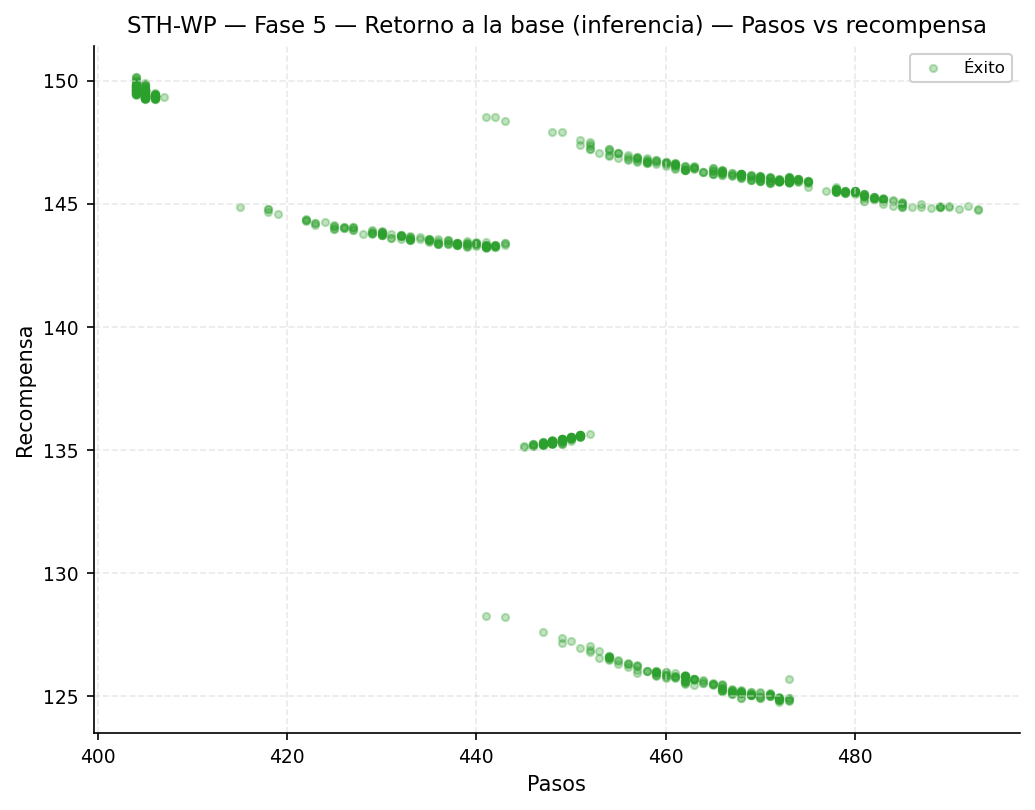

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,900,3,900,0,0,100.0,99.57,100.0,0.0,0.0,0.43,0.0,448.6,452.0,24.9,140.91,144.88,8.45,no registrada,no registrada


In [9]:
resumen_stage5_sthwp = analyze_phase(sthwp_dfs["stage5"], "STH-WP — Fase 5 — Retorno a la base (inferencia)", "fig_sthwp_stage5", ARCH_COLORS["STH-WP"])
if not resumen_stage5_sthwp.empty:
    resumen_stage5_sthwp.to_csv(TABLES_DIR / "tabla_resumen_sthwp_stage5.csv", index=False)
    display(resumen_stage5_sthwp)

### Fase 6 — Ciclo completo (inferencia)

- **Tarea evaluada**: ciclo completo approach+exit+return en un unico episodio, sin peaton
- **Peaton presente**: No
- **Observaciones de auditoria**: Verificado en el script (infer_run003_s{seed}_stage6.py): carga 'run003_s{seed}_stage6_final' -- EL MODELO REAL DE FASE 6. Existe tambien 'infer_run002_s{seed}_ciclo_completo.csv', que NO es Fase 6: ese script encadena DOS modelos distintos (stage4v2_final + stage5_final) en un mismo episodio simulado, no evalua la politica unica de Fase 6. Se EXCLUYE explicitamente de este notebook para no confundir 'ciclo completo' compuesto con la Fase 6 real, tal y como exige el encargo.


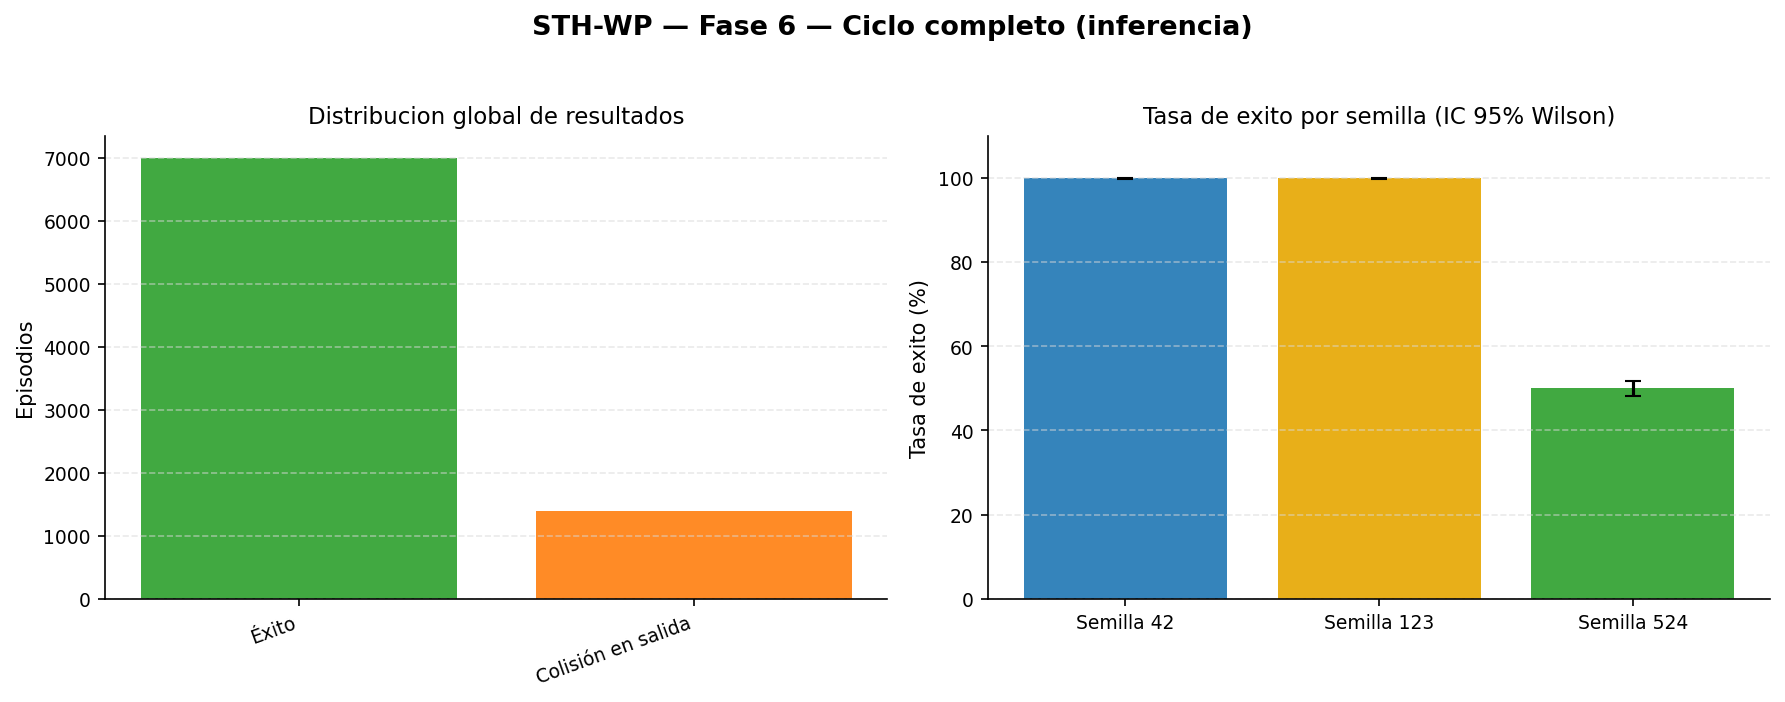

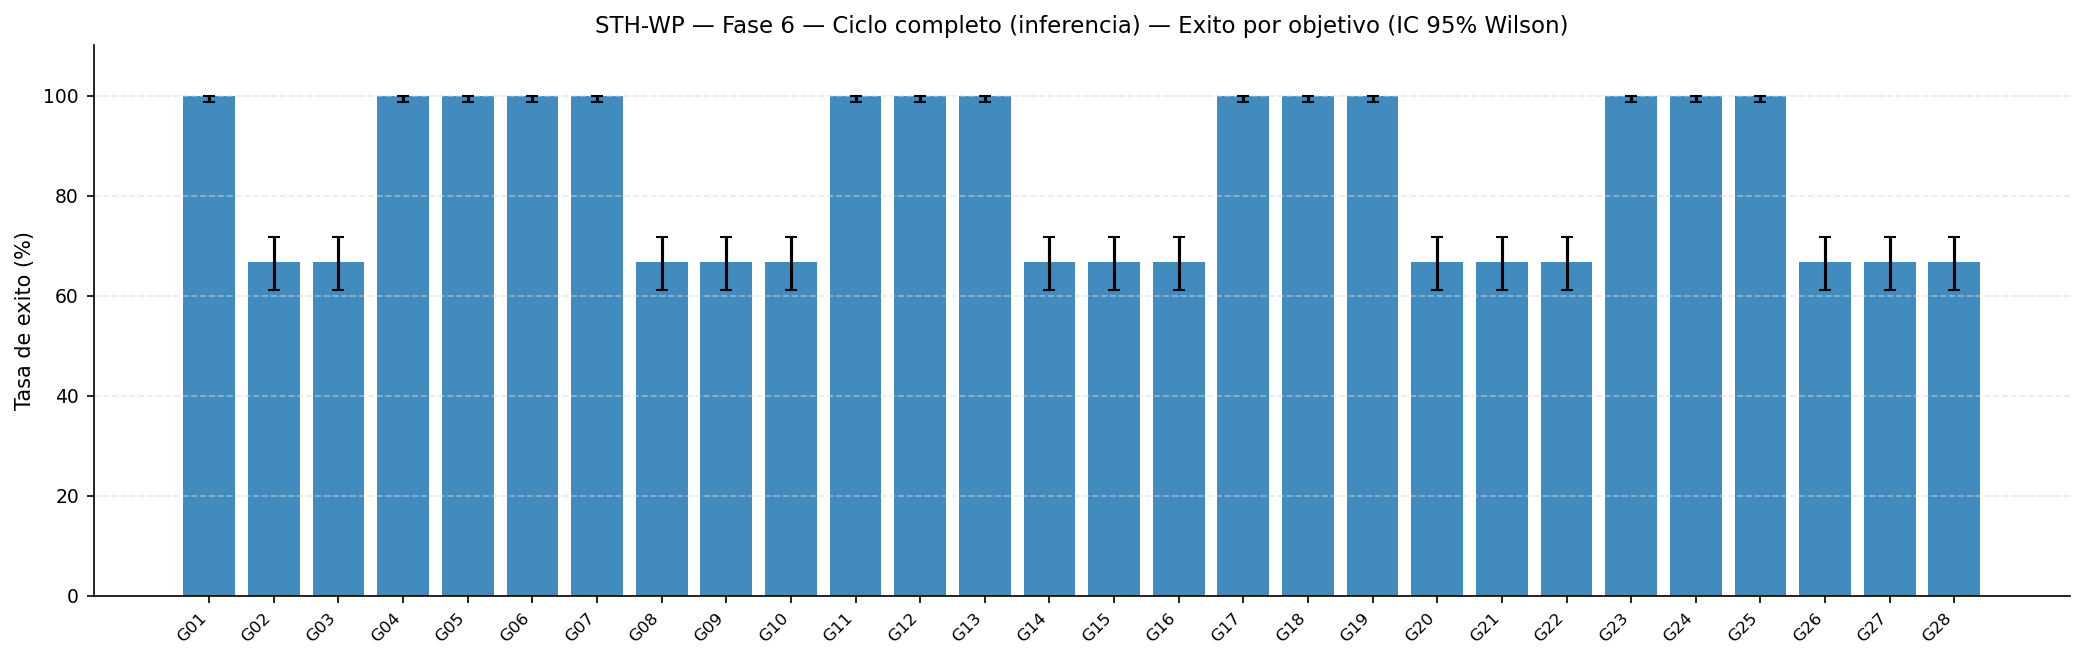

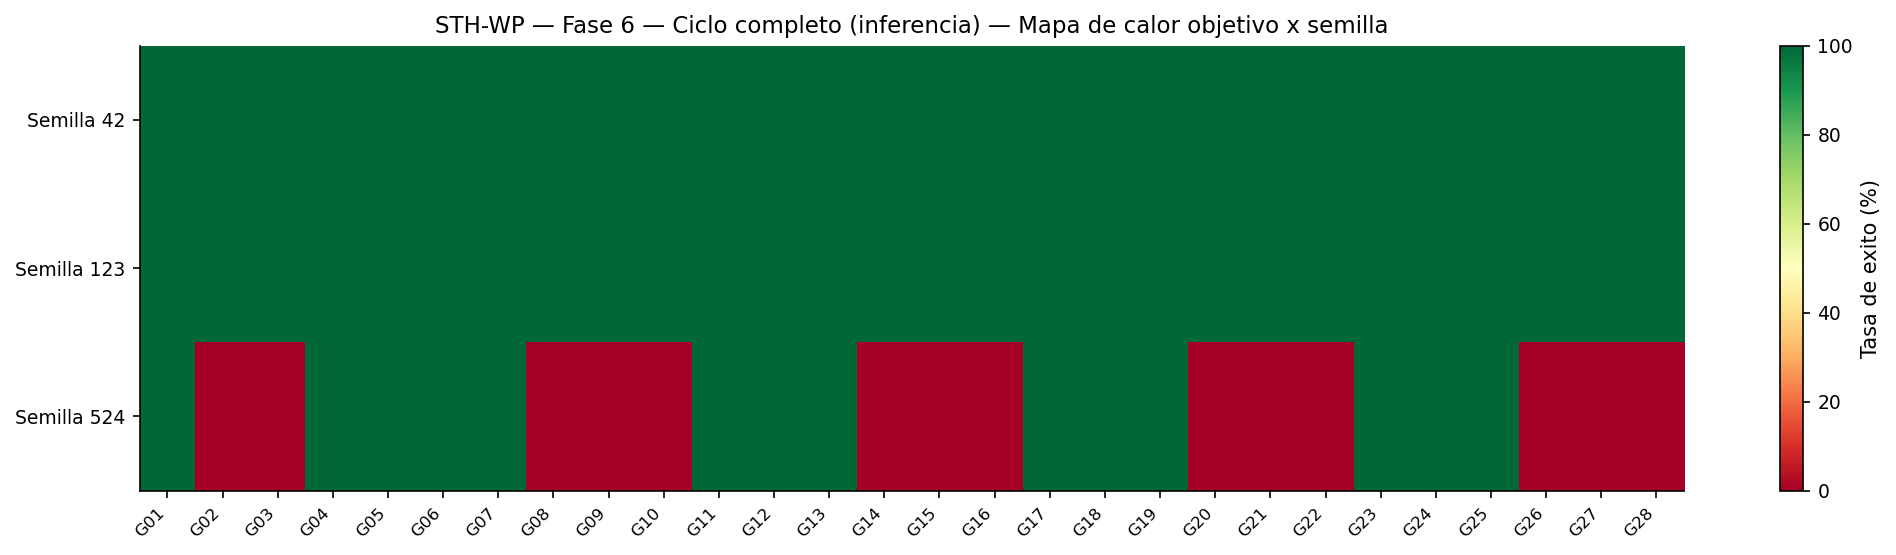

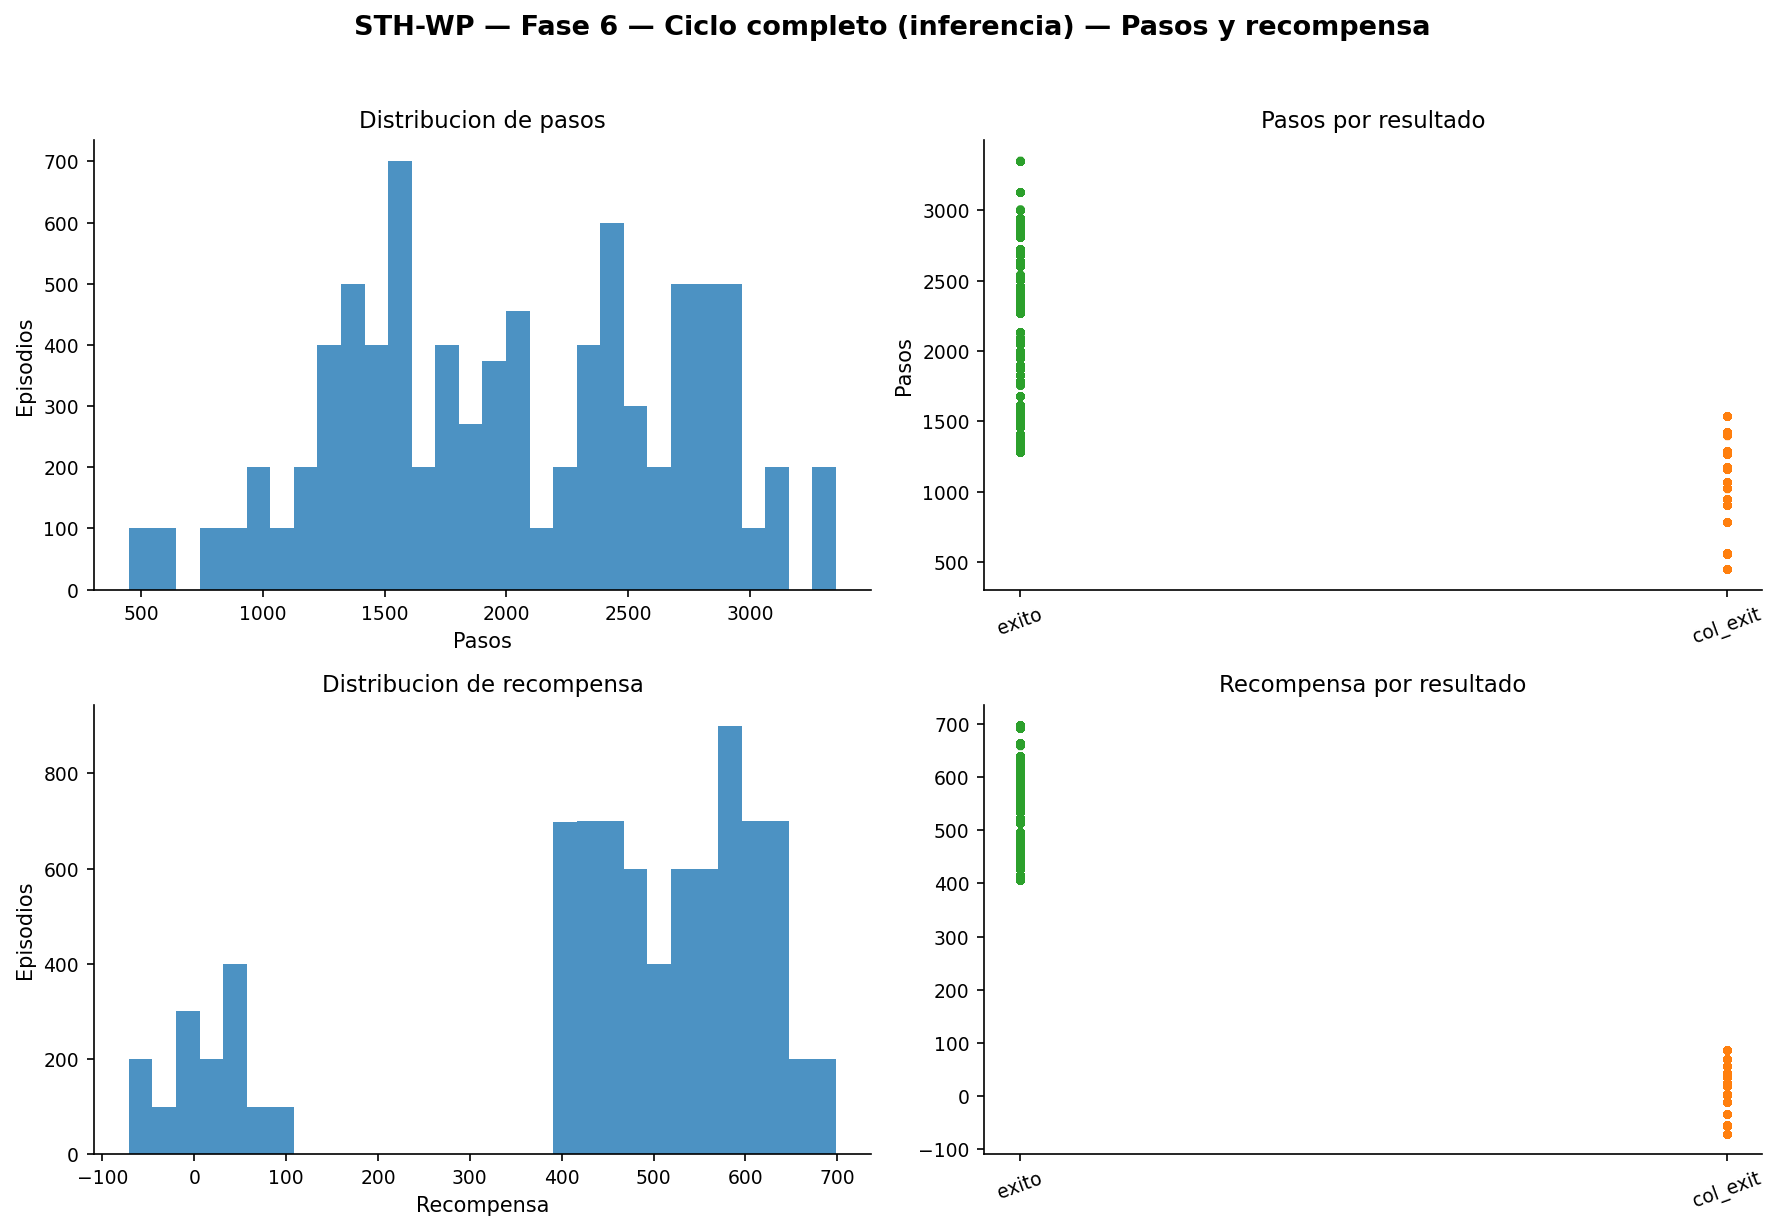

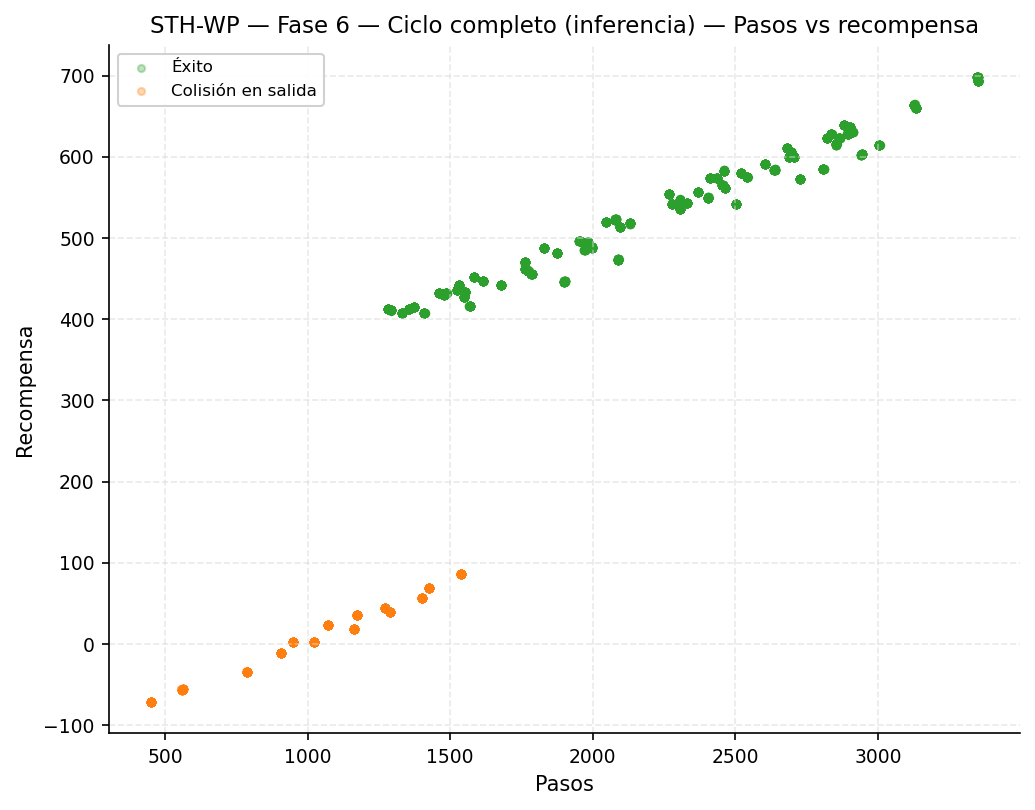

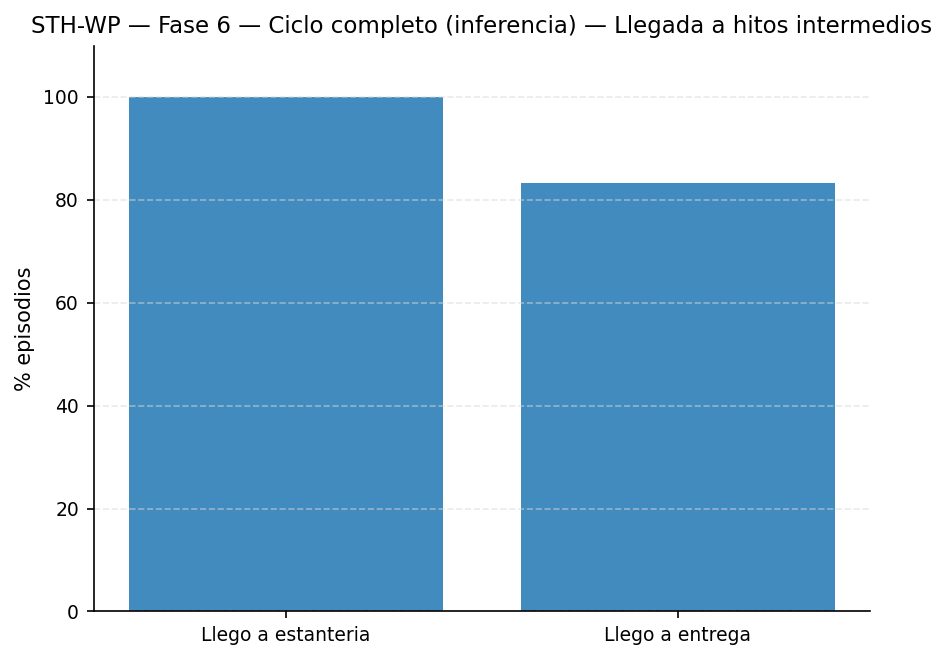

  Peores 3 objetivos: {'goal_14': np.float64(66.7), 'goal_26': np.float64(66.7), 'goal_22': np.float64(66.7)}
  Mejores 3 objetivos: {'goal_12': np.float64(100.0), 'goal_05': np.float64(100.0), 'goal_01': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,7000,1400,0,83.33,82.52,84.12,16.67,15.88,17.48,0.0,2030.8,2022.5,682.3,444.44,495.73,206.52,100.0,83.33


In [10]:
resumen_stage6_sthwp = analyze_phase(sthwp_dfs["stage6"], "STH-WP — Fase 6 — Ciclo completo (inferencia)", "fig_sthwp_stage6", ARCH_COLORS["STH-WP"])
if not resumen_stage6_sthwp.empty:
    resumen_stage6_sthwp.to_csv(TABLES_DIR / "tabla_resumen_sthwp_stage6.csv", index=False)
    display(resumen_stage6_sthwp)

## 6. E2.1, E2.2 y E2.2b de STH-WP


### E2.1 — Con peaton (inferencia)

- **Tarea evaluada**: ciclo completo con peaton dinamico, observacion LIDAR realista
- **Peaton presente**: Si
- **Observaciones de auditoria**: Modelo evaluado: sthwp_e2_1_s{seed}_final (verificado por convencion de nombre de script y MODEL_PATH).


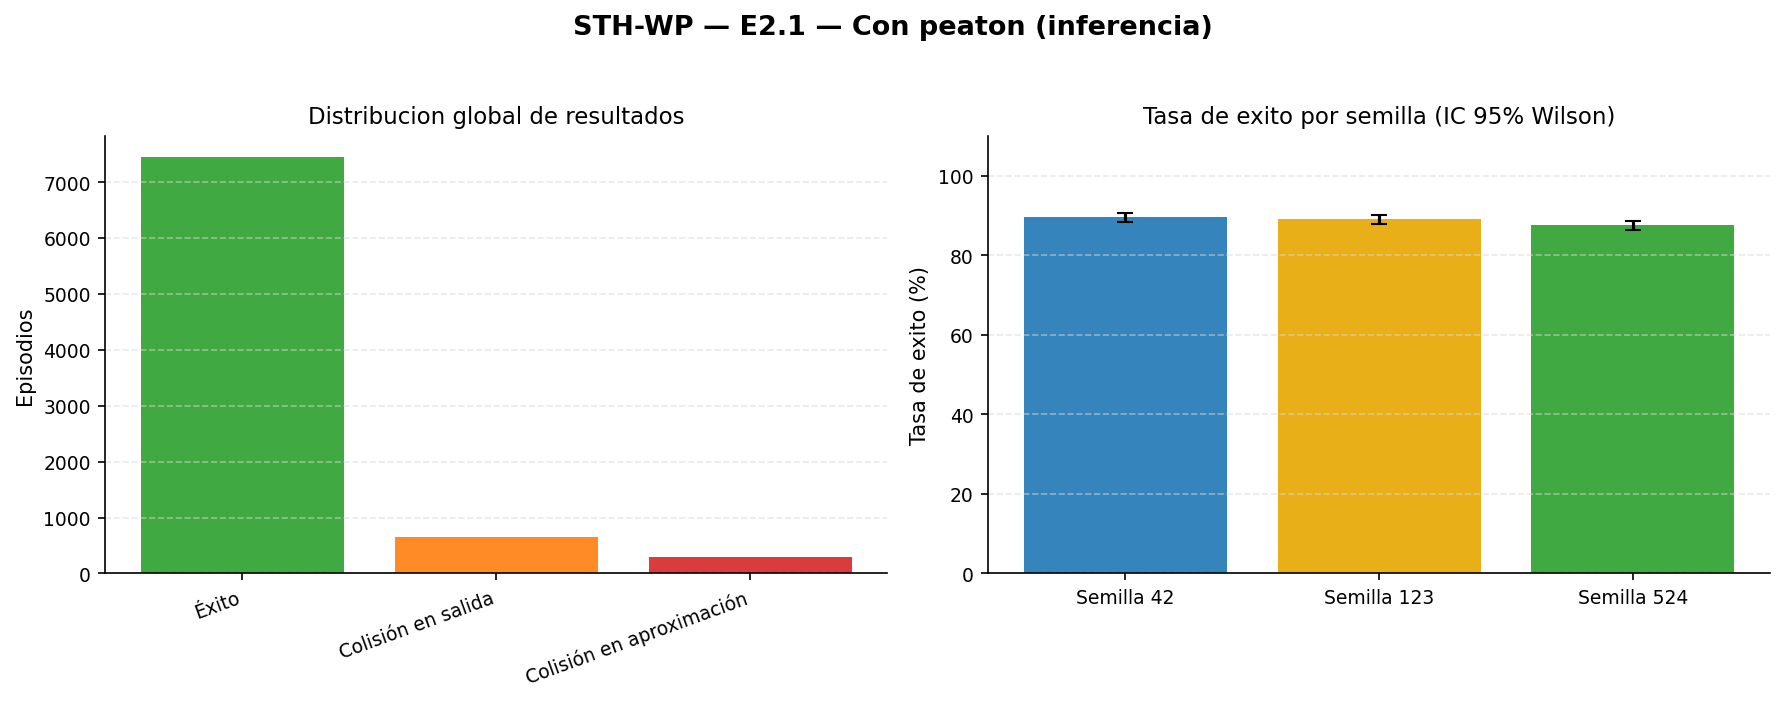

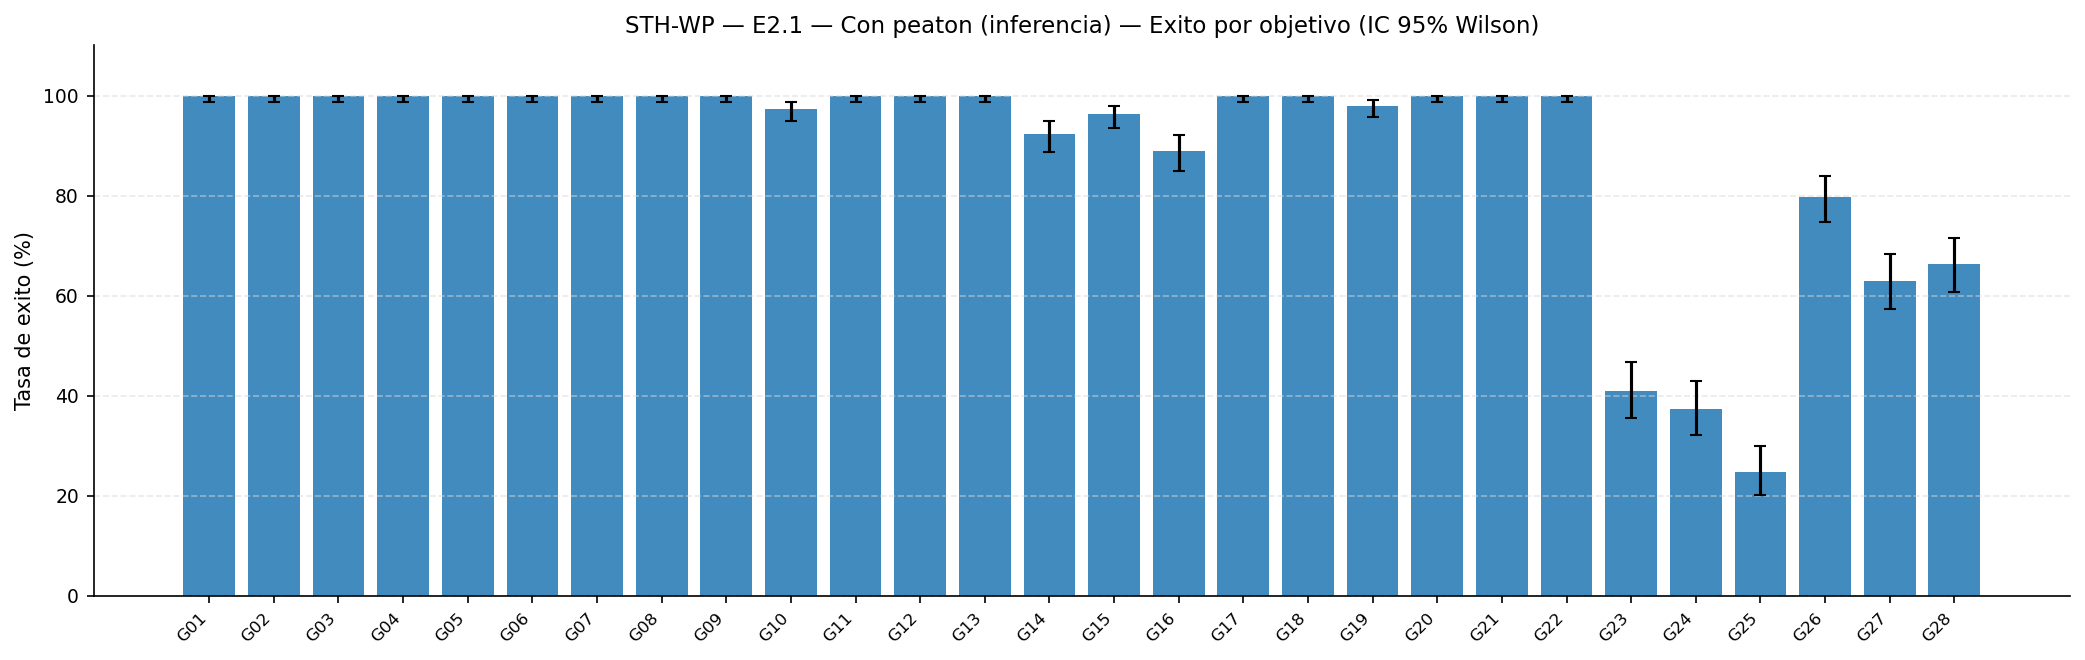

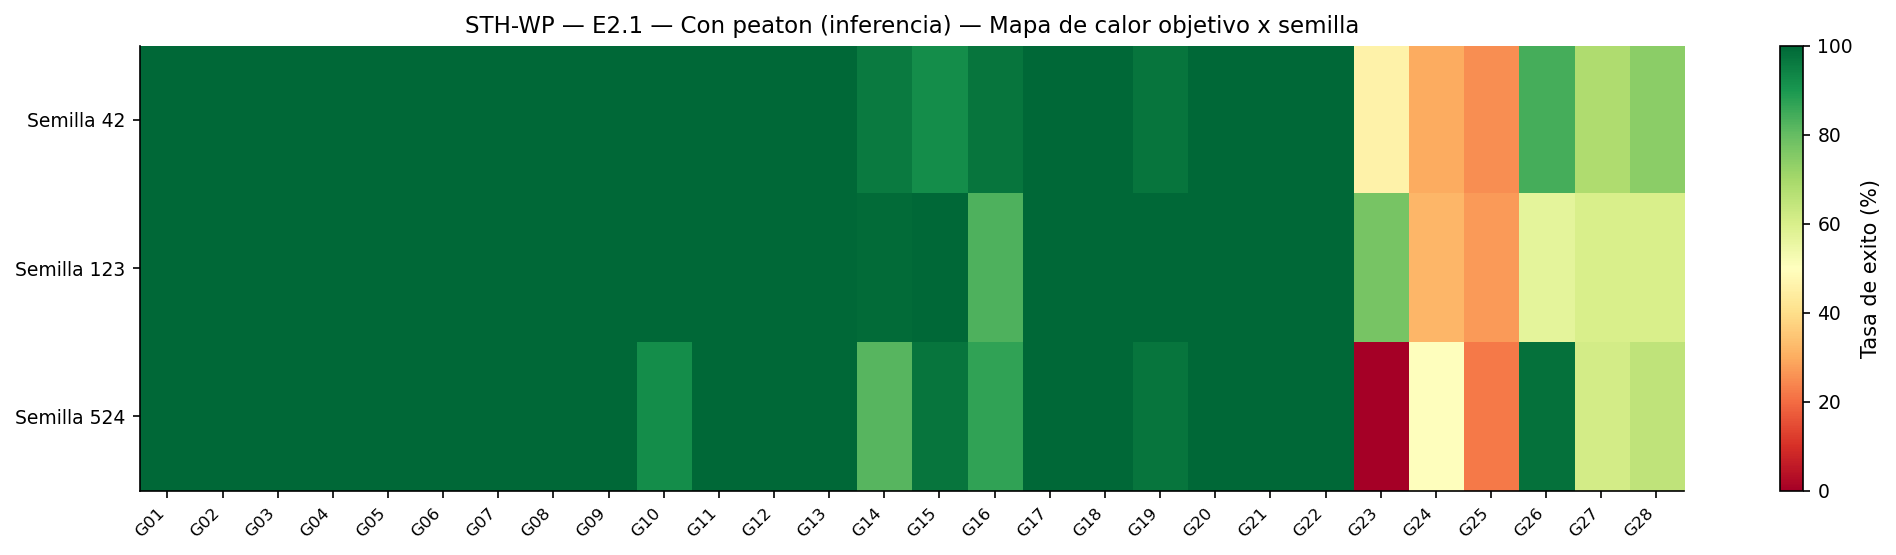

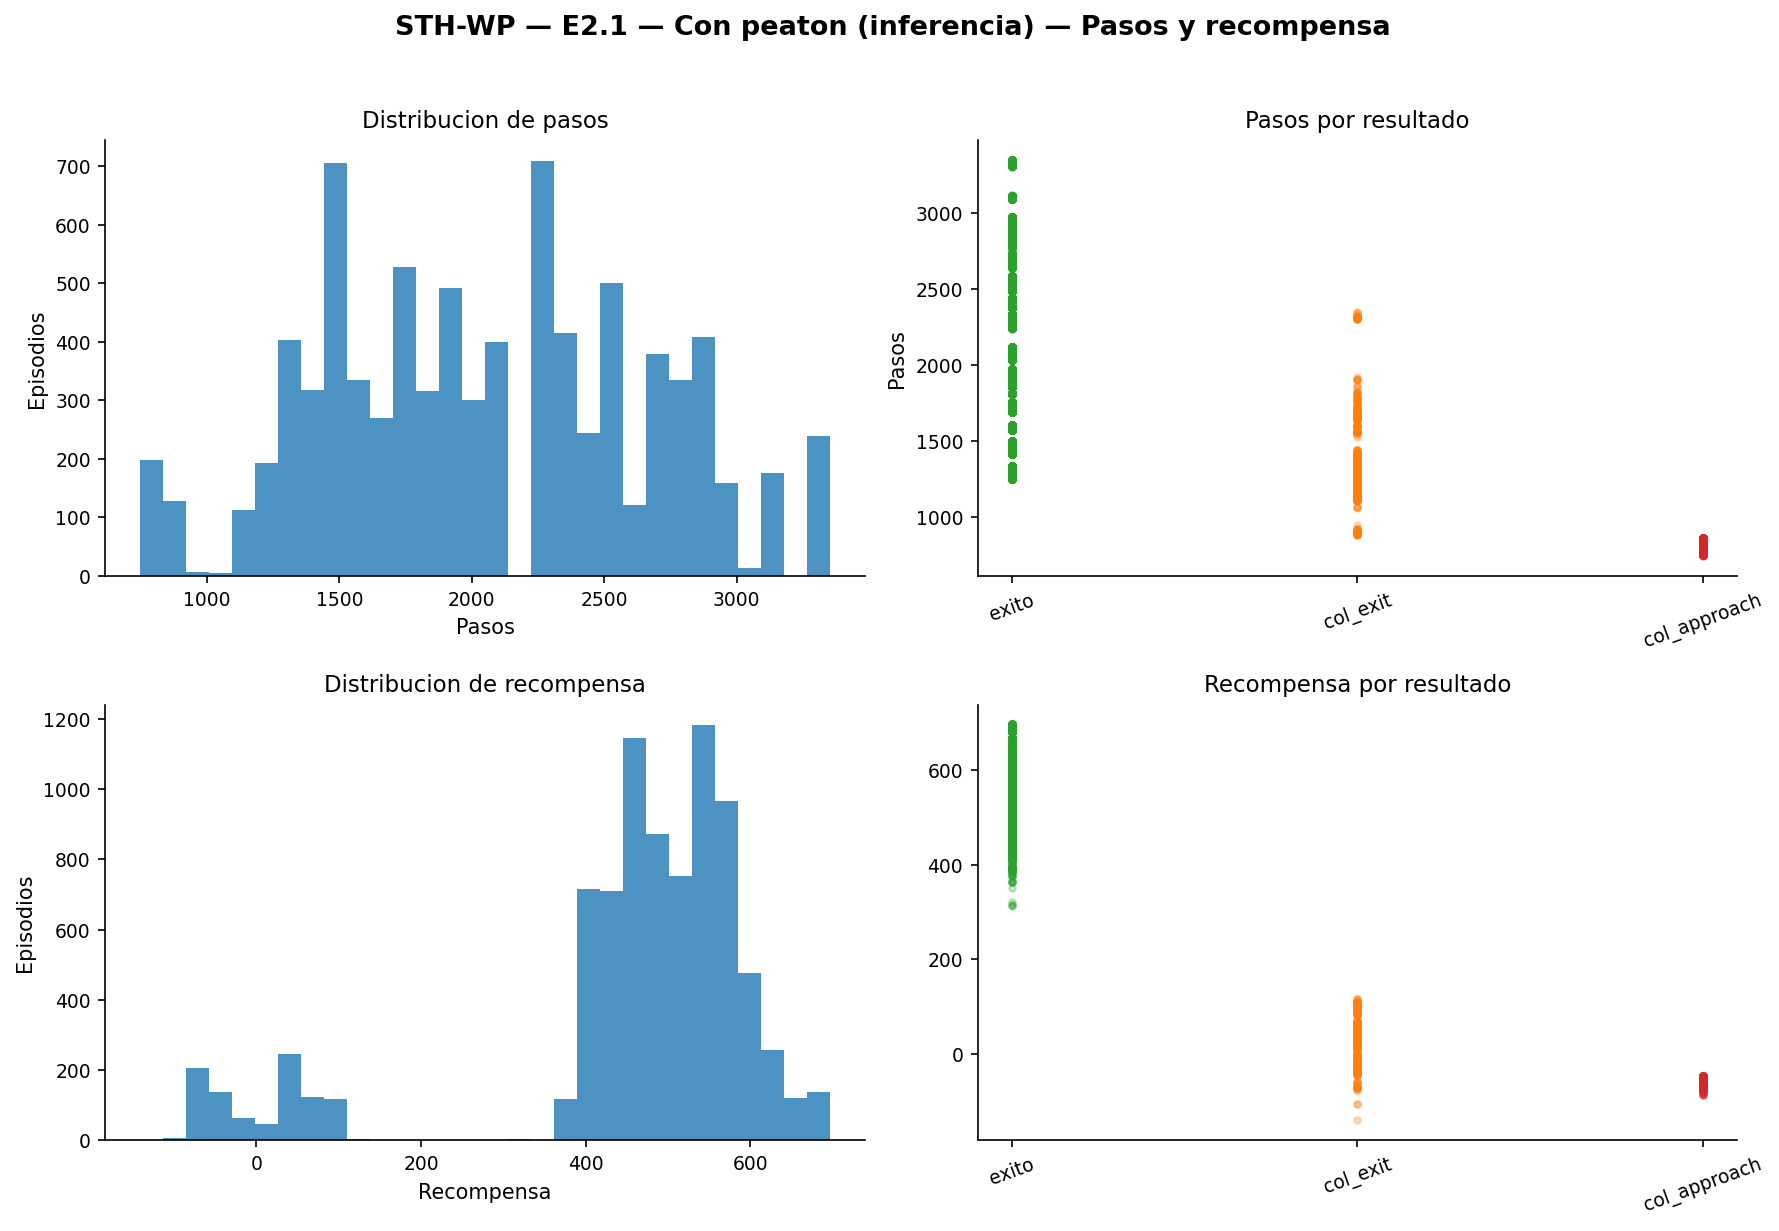

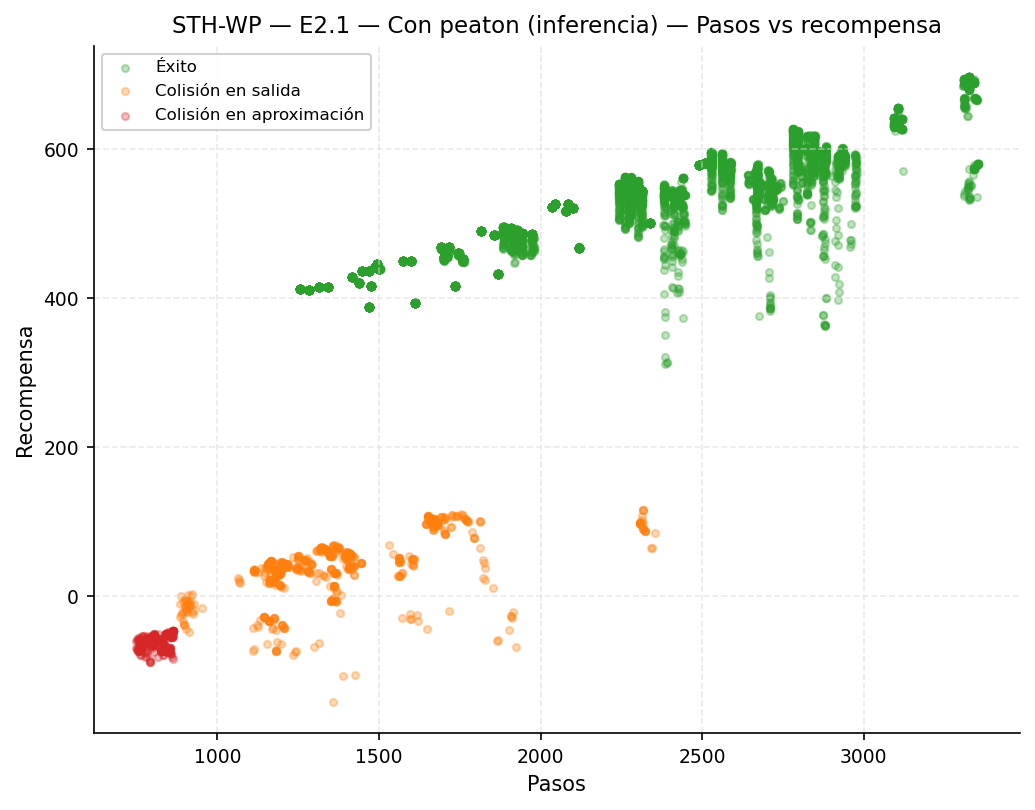

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_25': np.float64(24.7), 'goal_24': np.float64(37.3), 'goal_23': np.float64(41.0)}
  Mejores 3 objetivos: {'goal_11': np.float64(100.0), 'goal_08': np.float64(100.0), 'goal_01': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,7455,945,0,88.75,88.06,89.41,11.25,10.59,11.94,0.0,2053.8,2034.0,605.2,454.56,491.66,173.04,no registrada,no registrada


In [11]:
resumen_sthwp_e2_1_sthwp = analyze_phase(sthwp_dfs["sthwp_e2_1"], "STH-WP — E2.1 — Con peaton (inferencia)", "fig_sthwp_sthwp_e2_1", ARCH_COLORS["STH-WP"])
if not resumen_sthwp_e2_1_sthwp.empty:
    resumen_sthwp_e2_1_sthwp.to_csv(TABLES_DIR / "tabla_resumen_sthwp_sthwp_e2_1.csv", index=False)
    display(resumen_sthwp_e2_1_sthwp)

### E2.1 — Sin peaton, control (inferencia)

- **Tarea evaluada**: ciclo completo, MISMO modelo E2.1 pero evaluado en un mundo sin peaton (control)
- **Peaton presente**: No
- **Observaciones de auditoria**: Es el MISMO checkpoint E2.1 evaluado sin peaton (condicion de control), no debe confundirse con la Fase 6 (que es un modelo entrenado especificamente sin peaton).


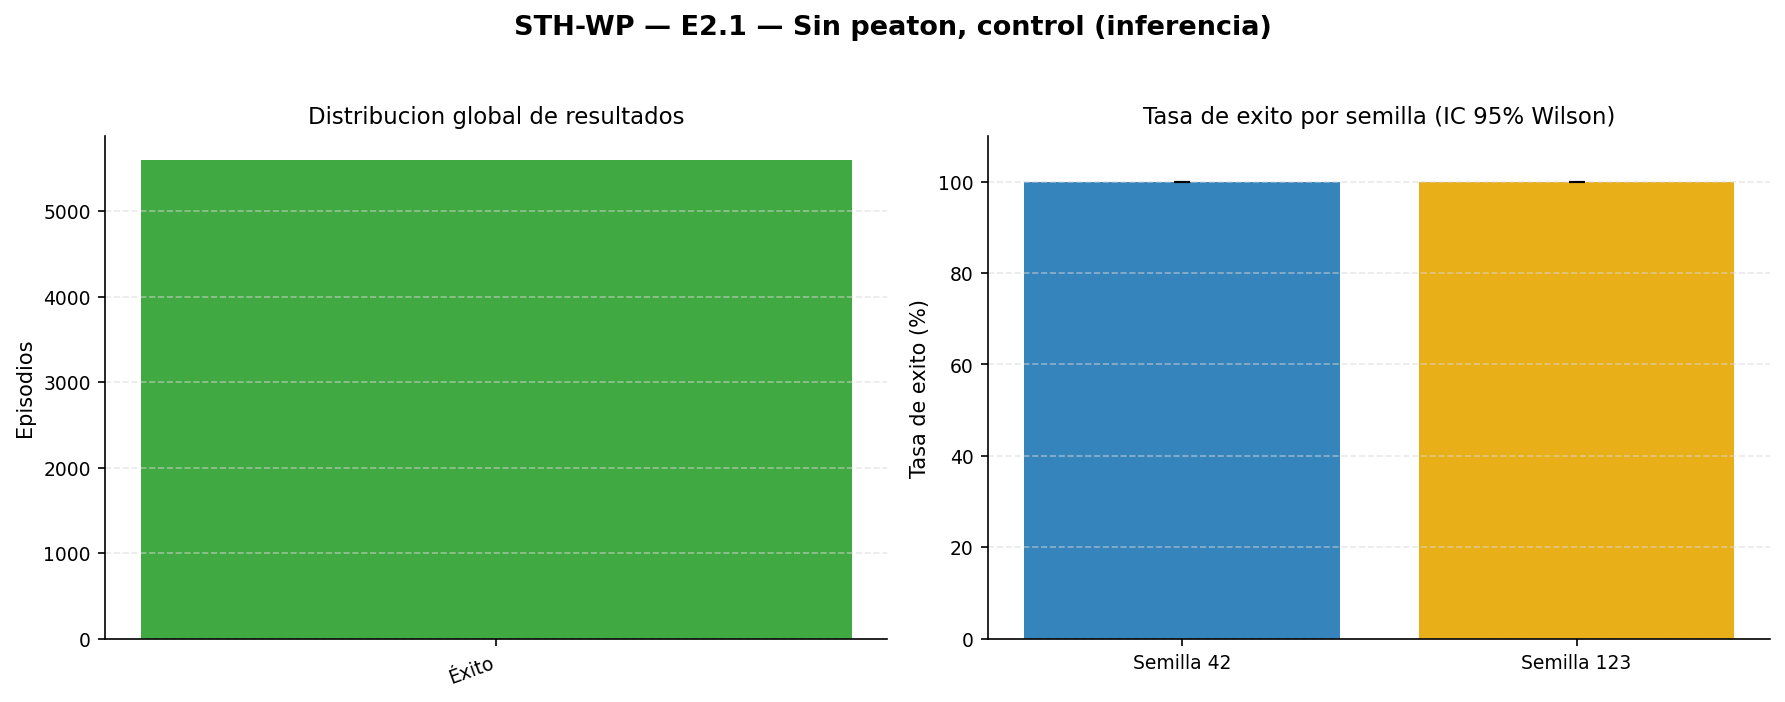

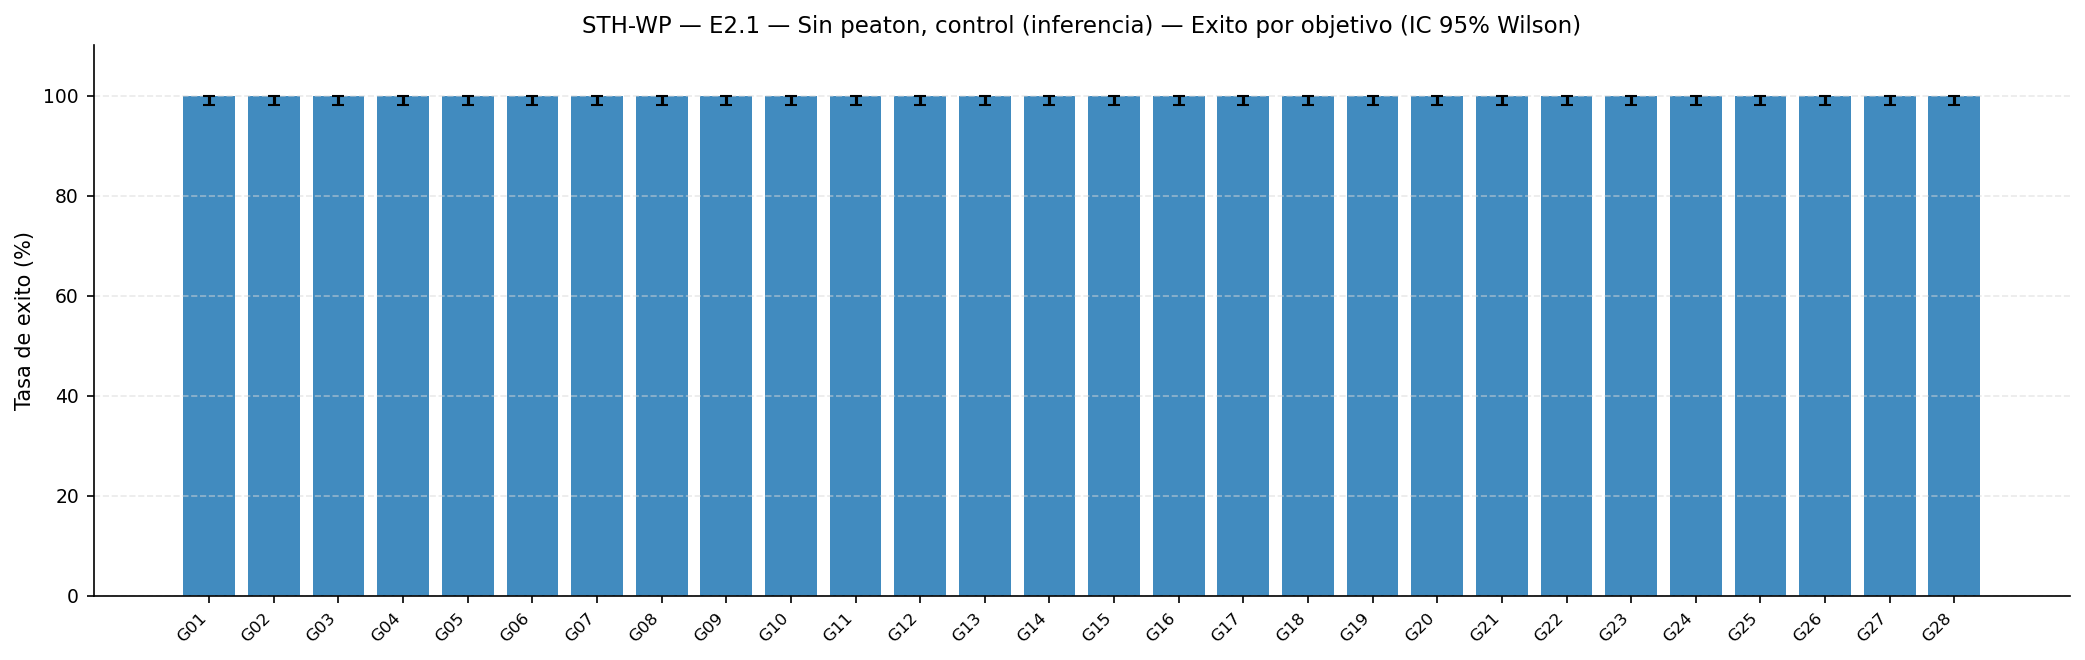

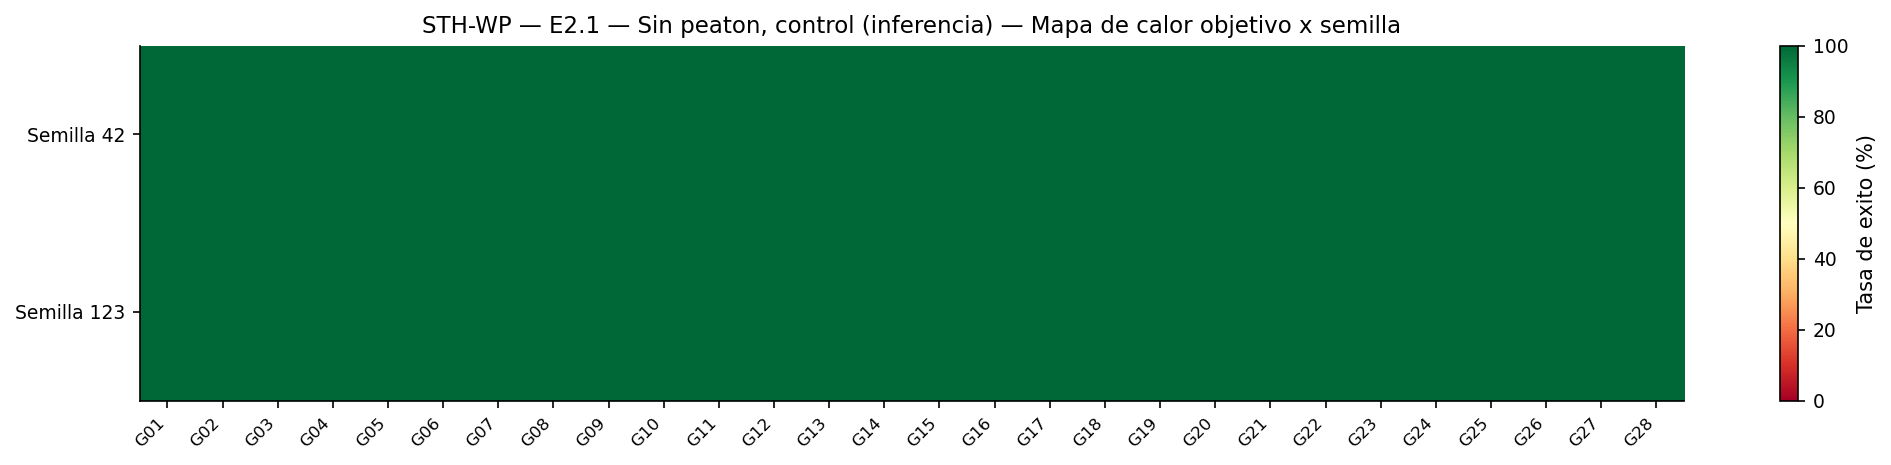

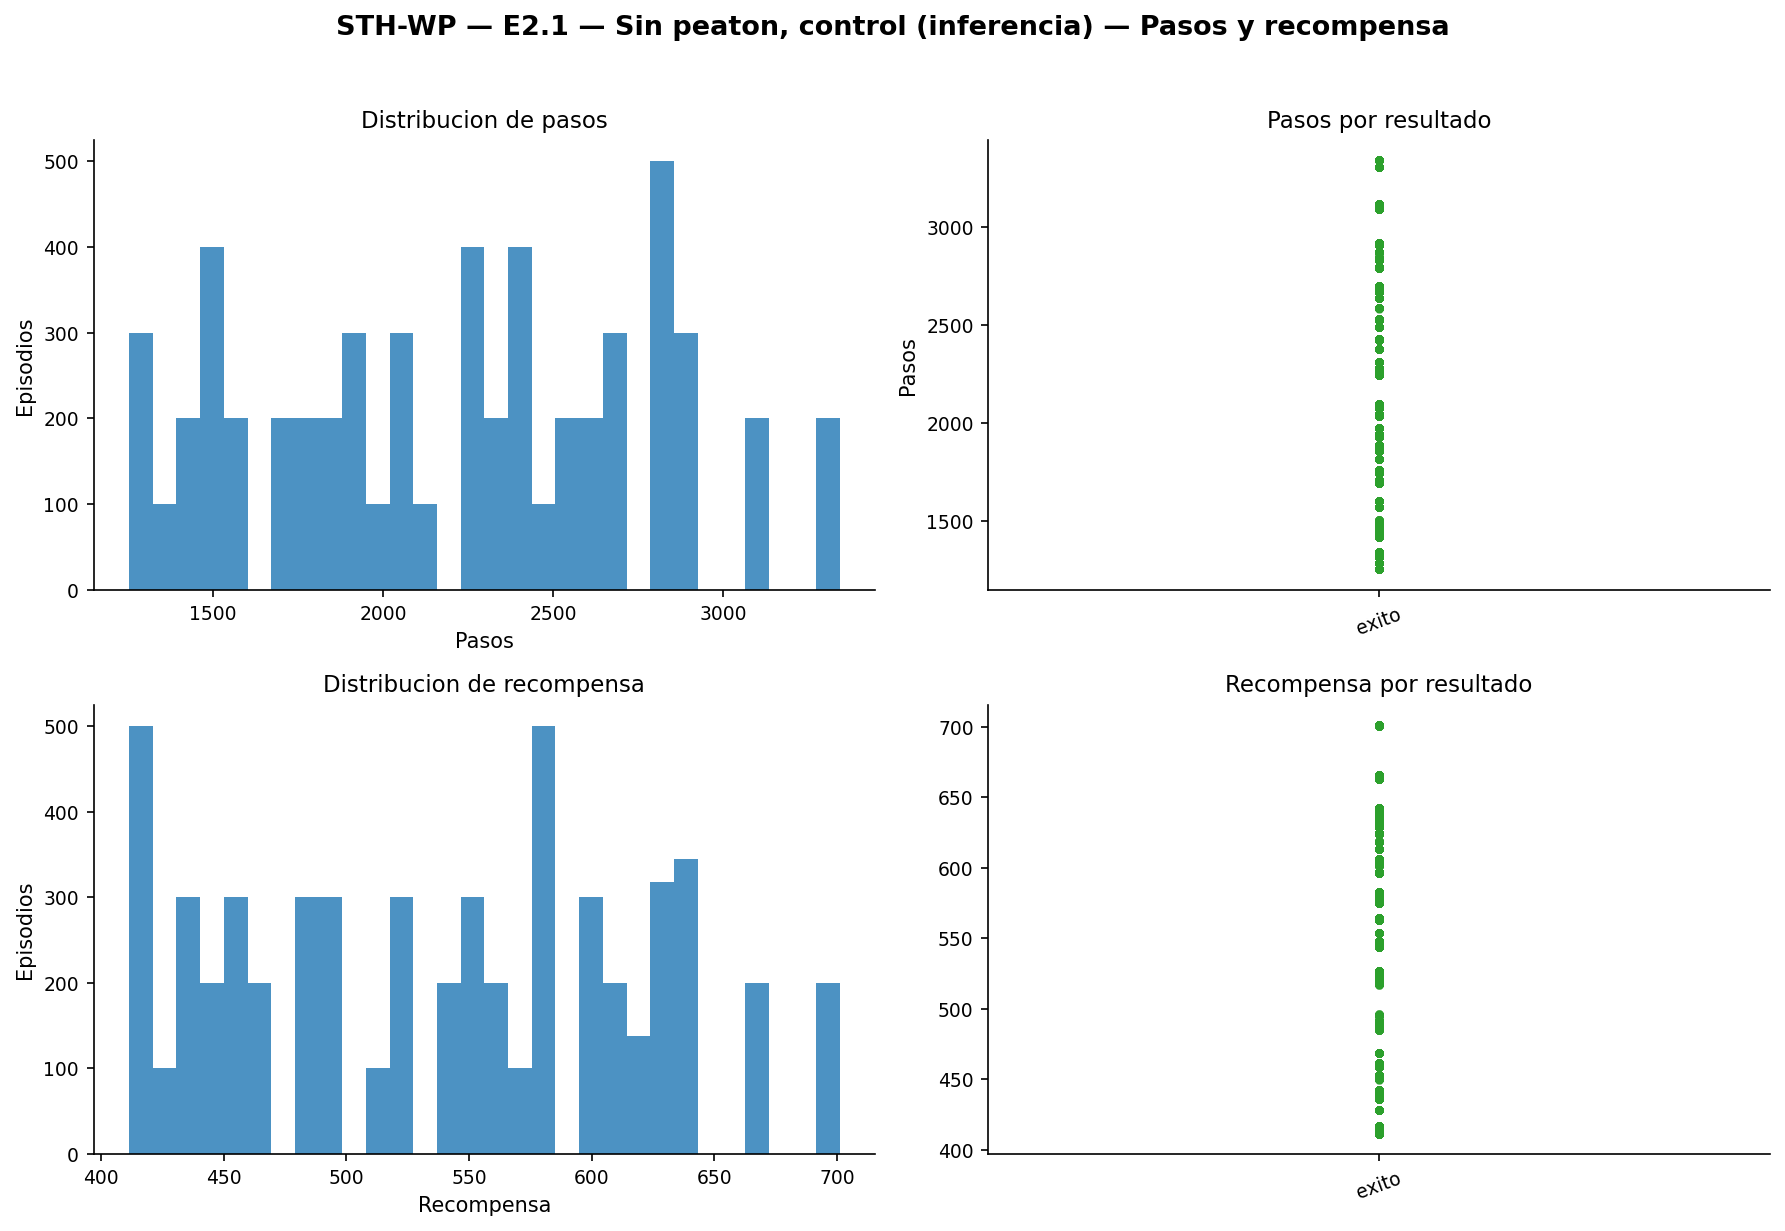

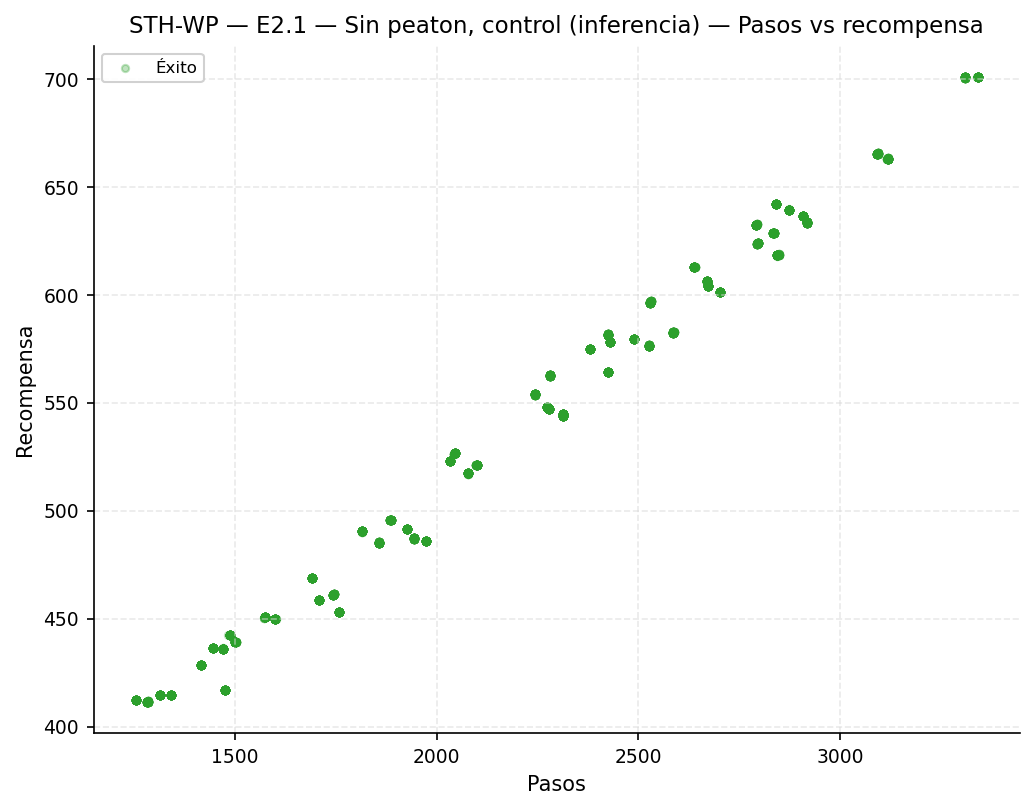

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_01': np.float64(100.0), 'goal_26': np.float64(100.0), 'goal_25': np.float64(100.0)}
  Mejores 3 objetivos: {'goal_02': np.float64(100.0), 'goal_27': np.float64(100.0), 'goal_28': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,5600,2,5600,0,0,100.0,99.93,100.0,0.0,0.0,0.07,0.0,2206.9,2276.0,566.0,538.69,545.98,81.68,no registrada,no registrada


In [12]:
resumen_sthwp_e2_1_noped_sthwp = analyze_phase(sthwp_dfs["sthwp_e2_1_noped"], "STH-WP — E2.1 — Sin peaton, control (inferencia)", "fig_sthwp_sthwp_e2_1_noped", ARCH_COLORS["STH-WP"])
if not resumen_sthwp_e2_1_noped_sthwp.empty:
    resumen_sthwp_e2_1_noped_sthwp.to_csv(TABLES_DIR / "tabla_resumen_sthwp_sthwp_e2_1_noped.csv", index=False)
    display(resumen_sthwp_e2_1_noped_sthwp)

### E2.2 — Replanning LIDAR (inferencia)

- **Tarea evaluada**: ciclo completo con peaton + replanning LIDAR [1.5,4.5]m
- **Peaton presente**: Si
- **Observaciones de auditoria**: Modelo evaluado: sthwp_e2_2_s{seed}_final.


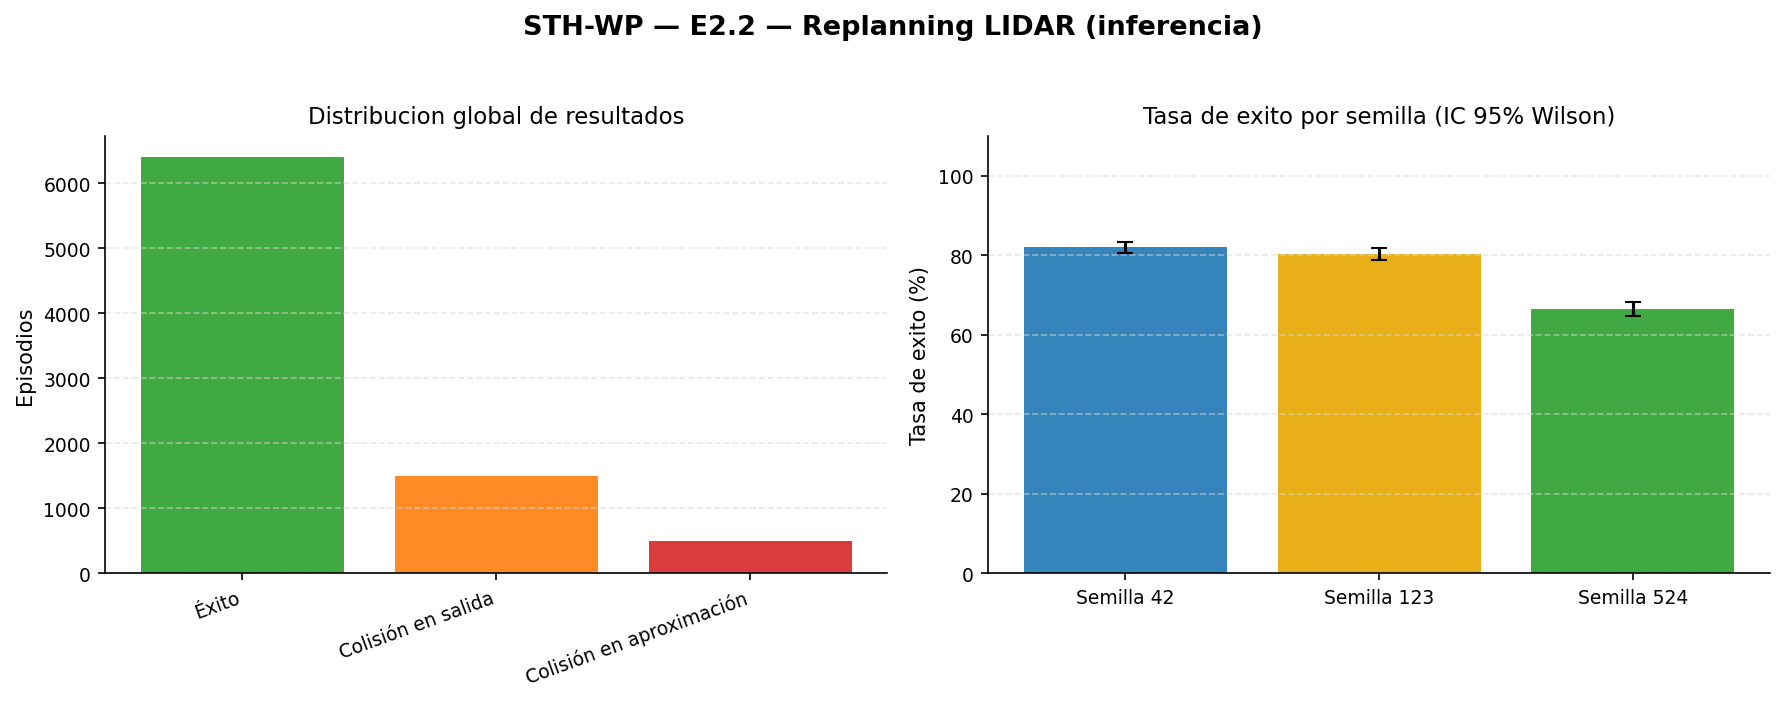

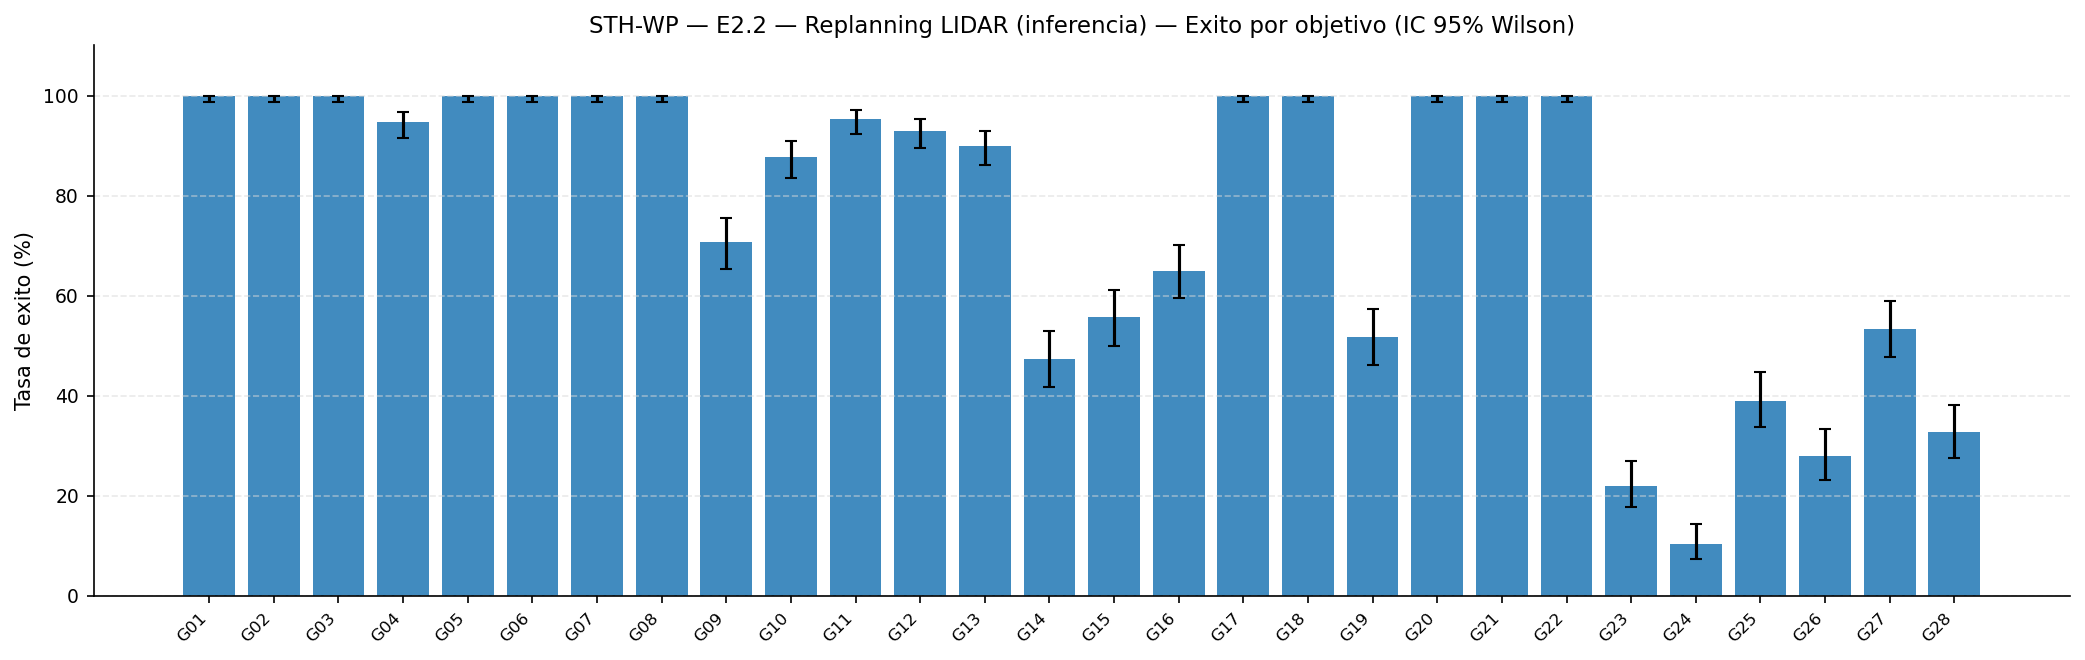

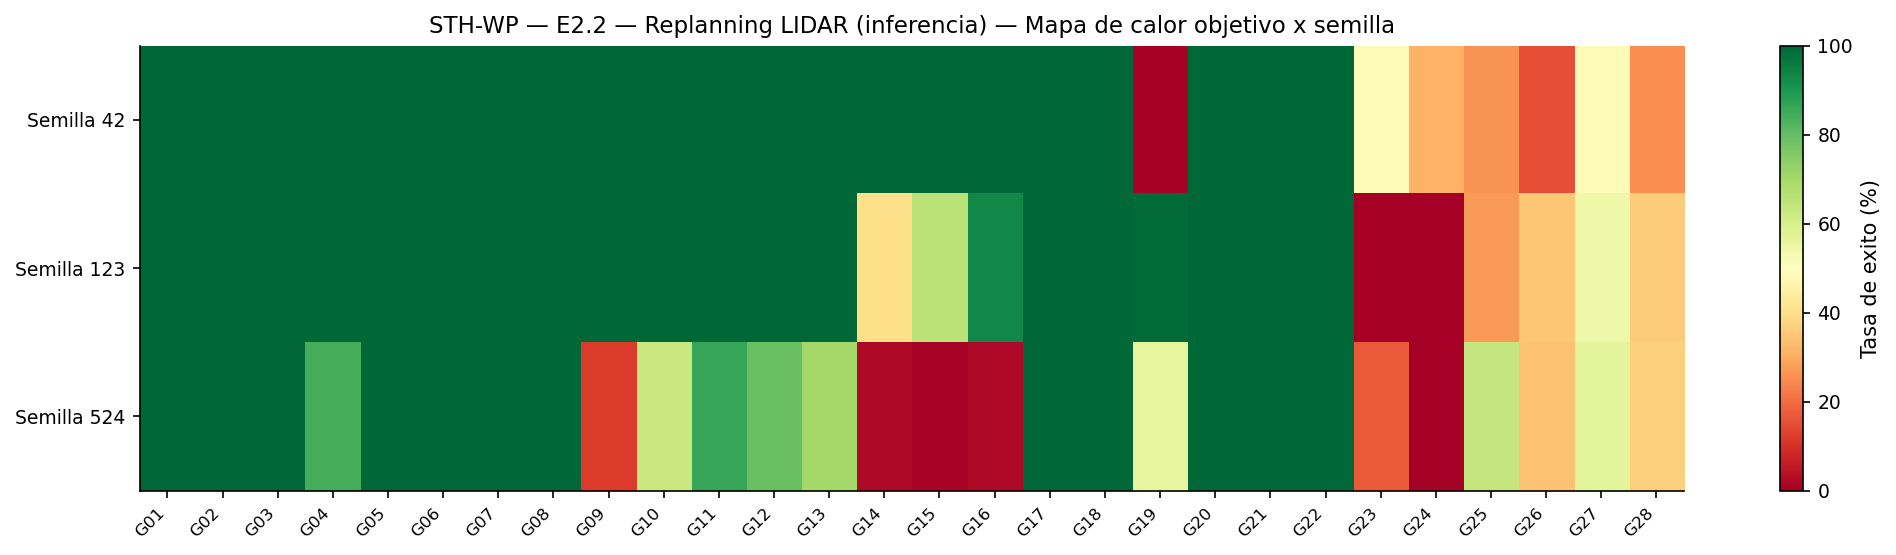

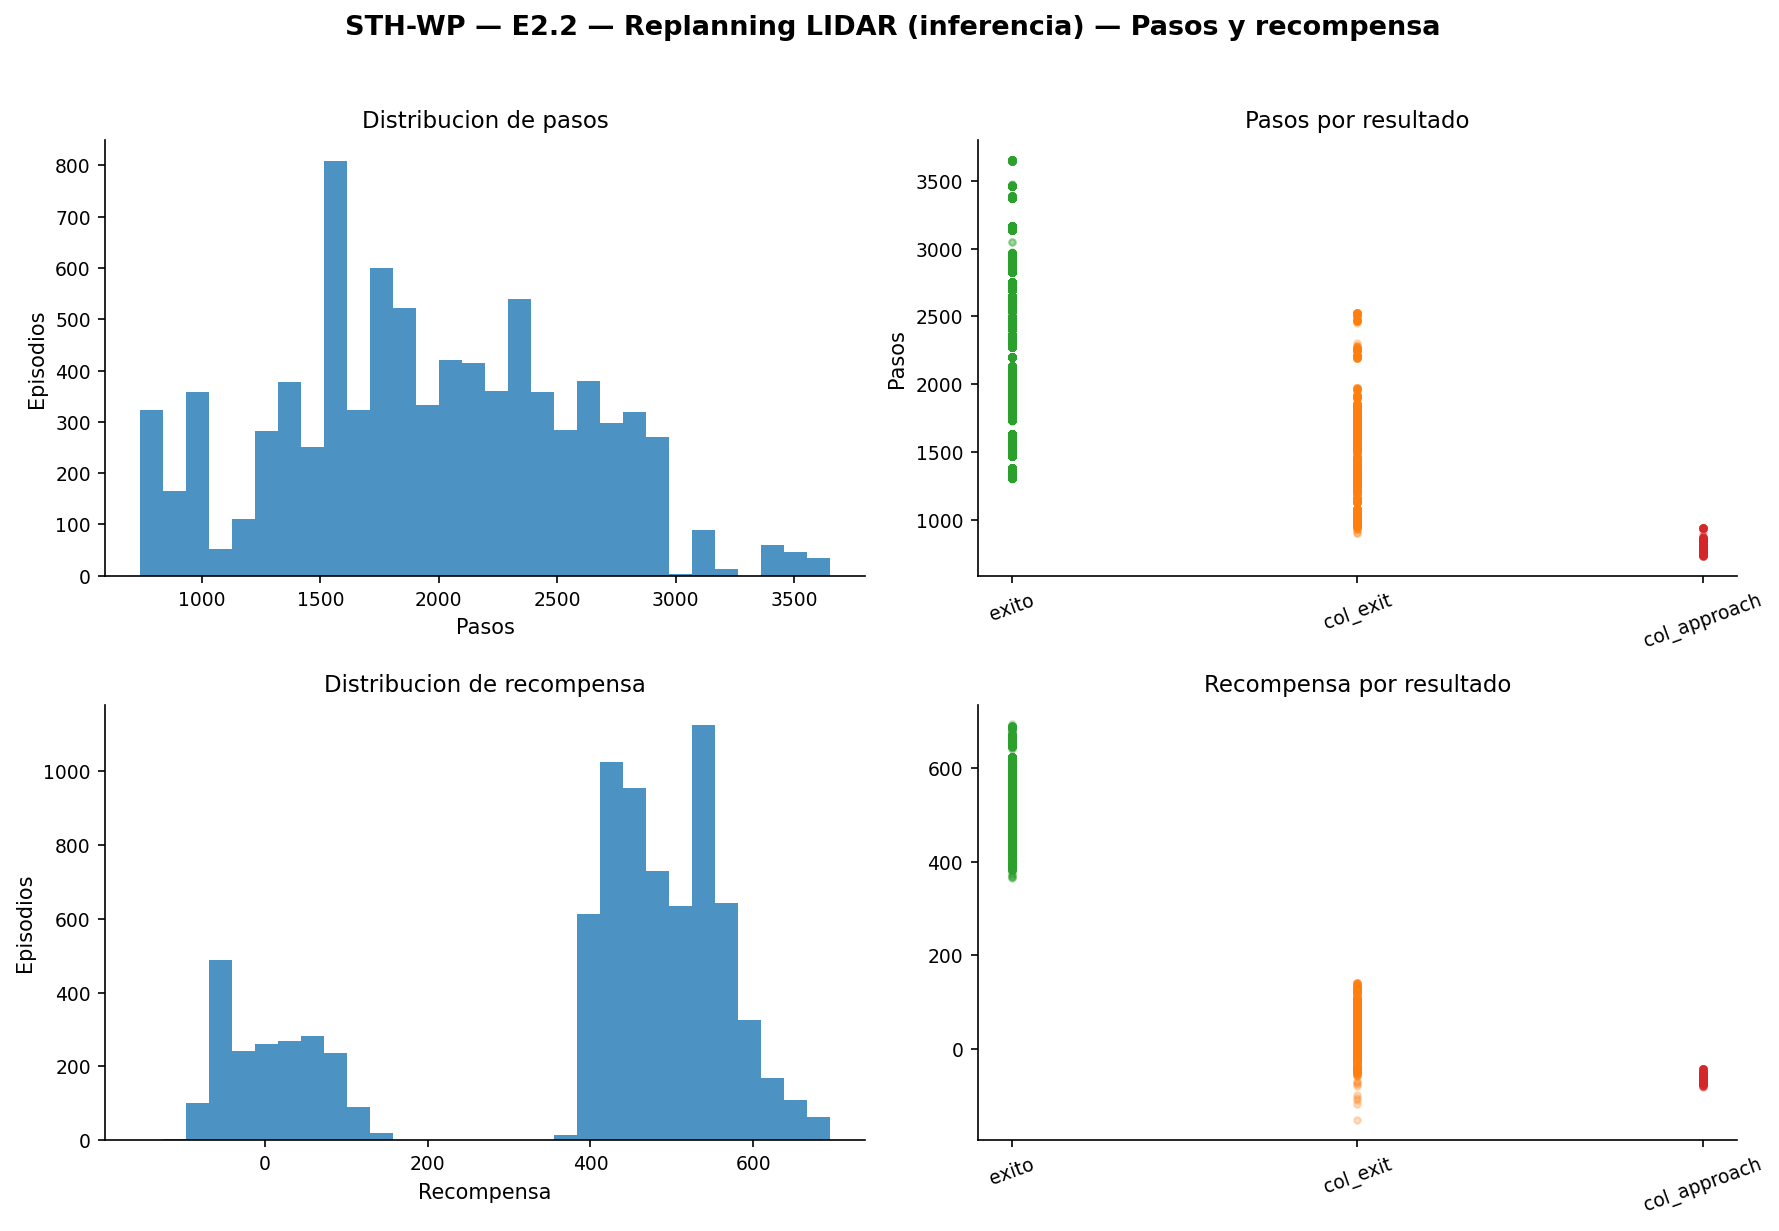

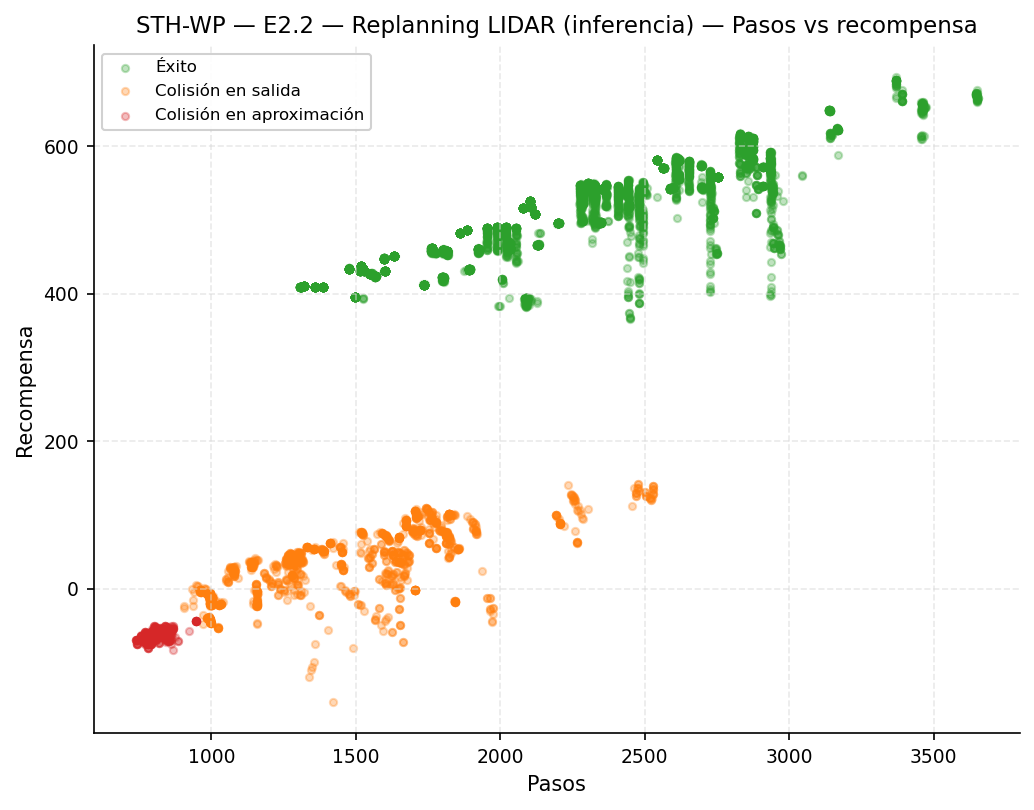

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_24': np.float64(10.3), 'goal_23': np.float64(22.0), 'goal_26': np.float64(28.0)}
  Mejores 3 objetivos: {'goal_08': np.float64(100.0), 'goal_21': np.float64(100.0), 'goal_01': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,6409,1991,0,76.3,75.38,77.19,23.7,22.81,24.62,0.0,1953.3,1922.0,620.4,382.3,460.14,218.23,no registrada,no registrada


In [13]:
resumen_sthwp_e2_2_sthwp = analyze_phase(sthwp_dfs["sthwp_e2_2"], "STH-WP — E2.2 — Replanning LIDAR (inferencia)", "fig_sthwp_sthwp_e2_2", ARCH_COLORS["STH-WP"])
if not resumen_sthwp_e2_2_sthwp.empty:
    resumen_sthwp_e2_2_sthwp.to_csv(TABLES_DIR / "tabla_resumen_sthwp_sthwp_e2_2.csv", index=False)
    display(resumen_sthwp_e2_2_sthwp)

### E2.2b — Replanning LIDAR corregido (inferencia)

- **Tarea evaluada**: ciclo completo con peaton + replanning LIDAR [2.5,4.5]m
- **Peaton presente**: Si
- **Observaciones de auditoria**: Modelo evaluado: sthwp_e2_2b_s{seed}_final.


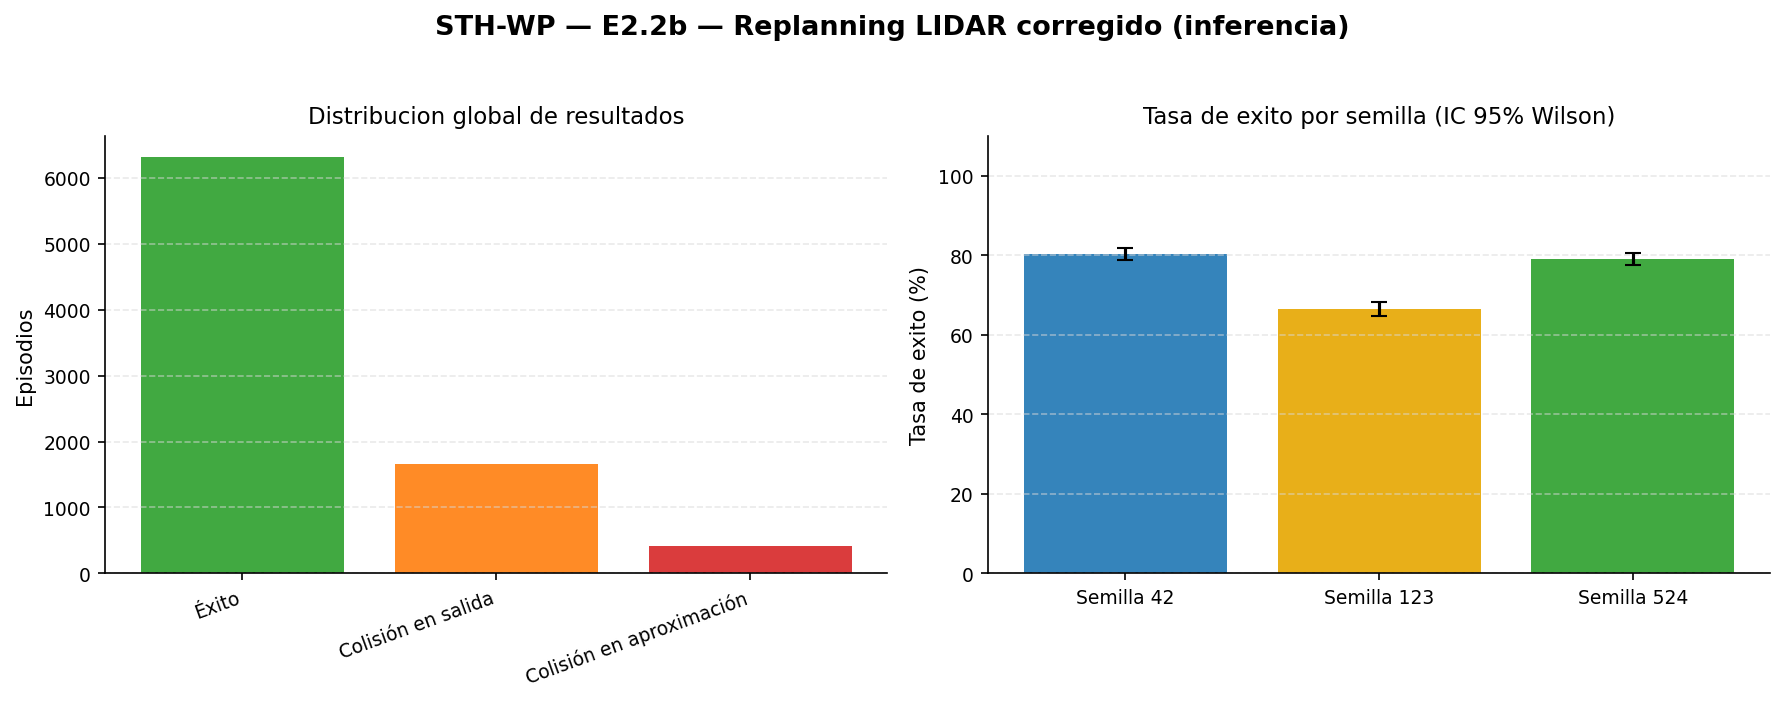

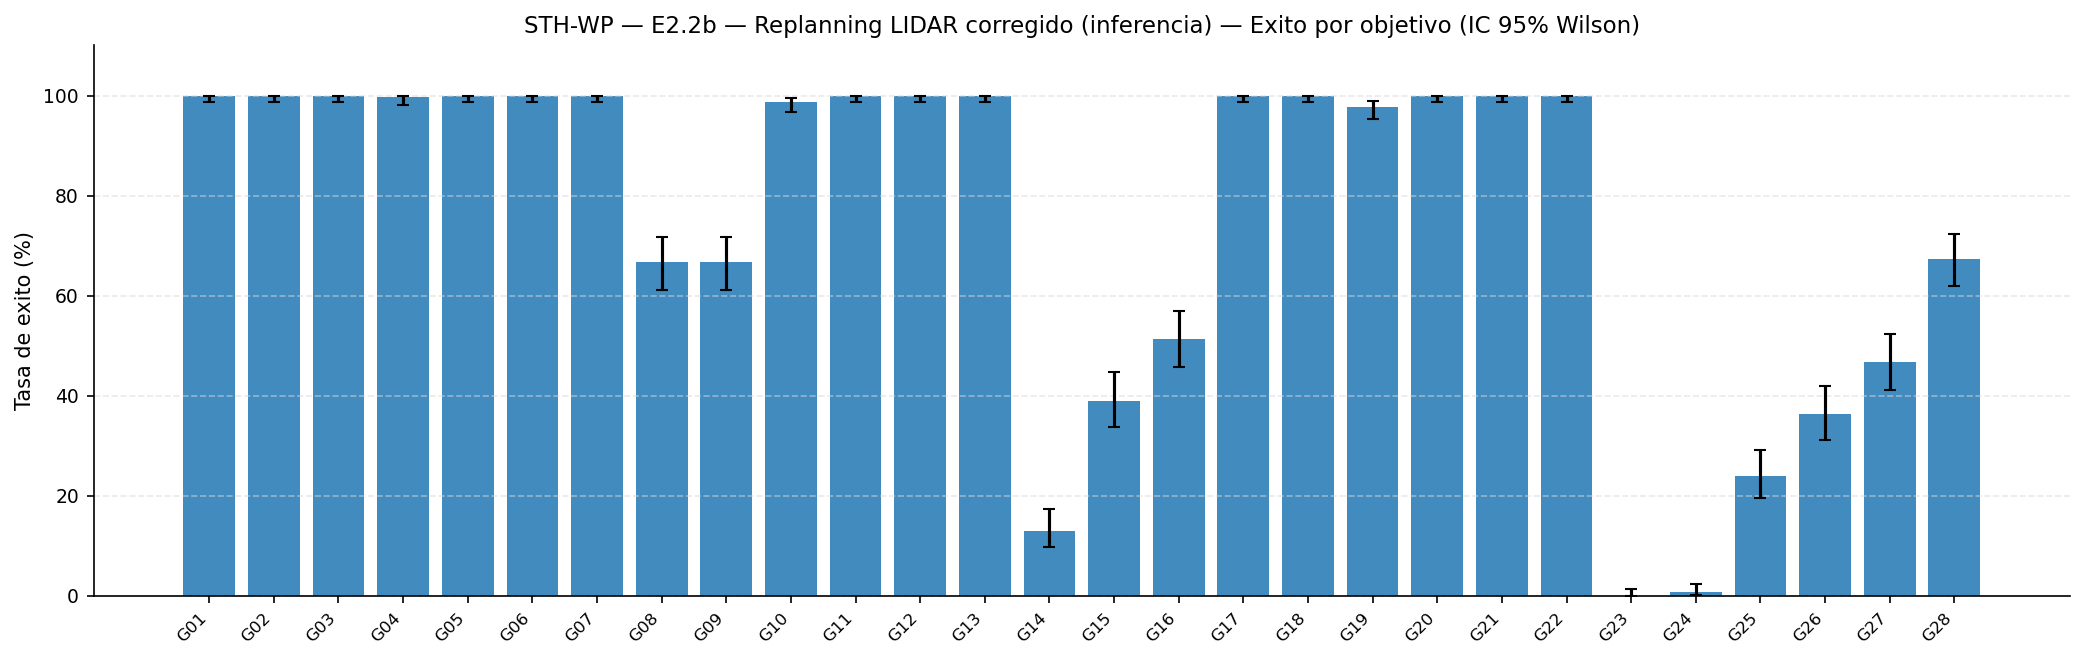

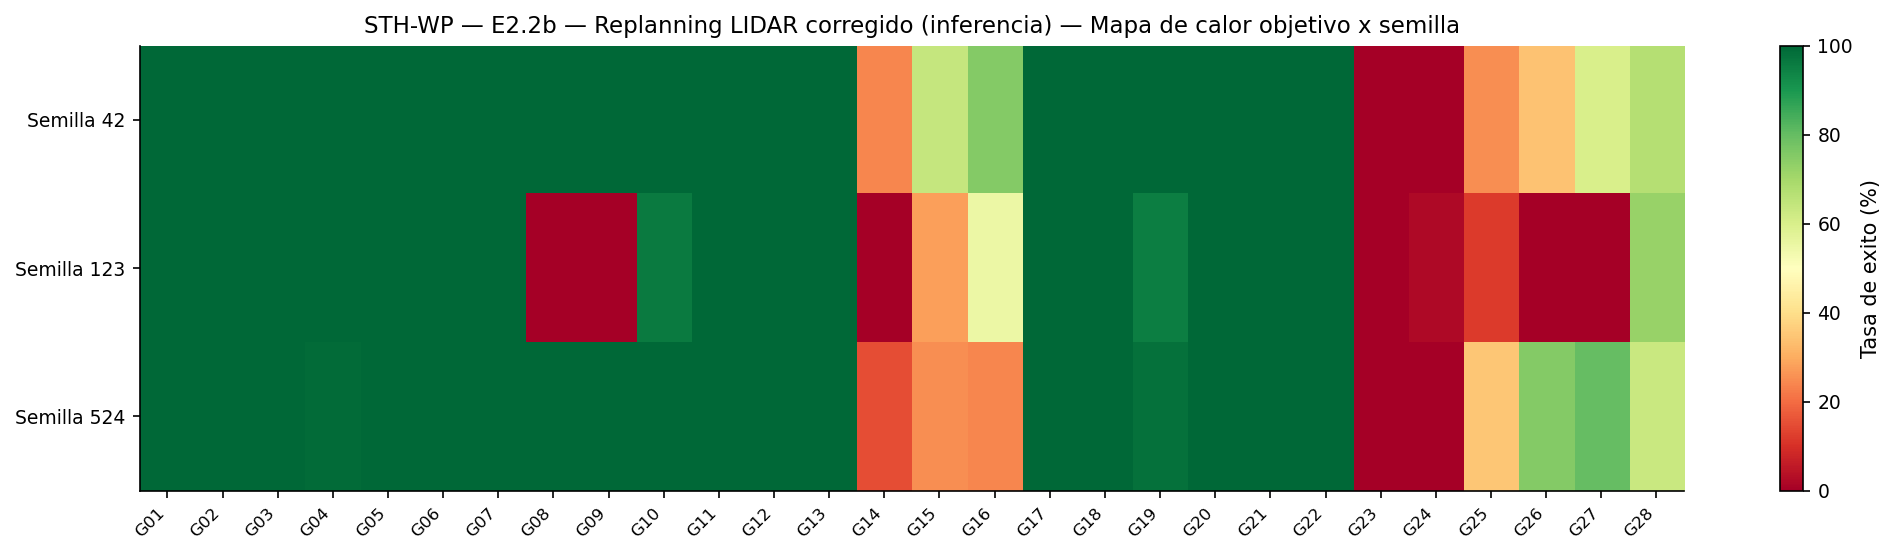

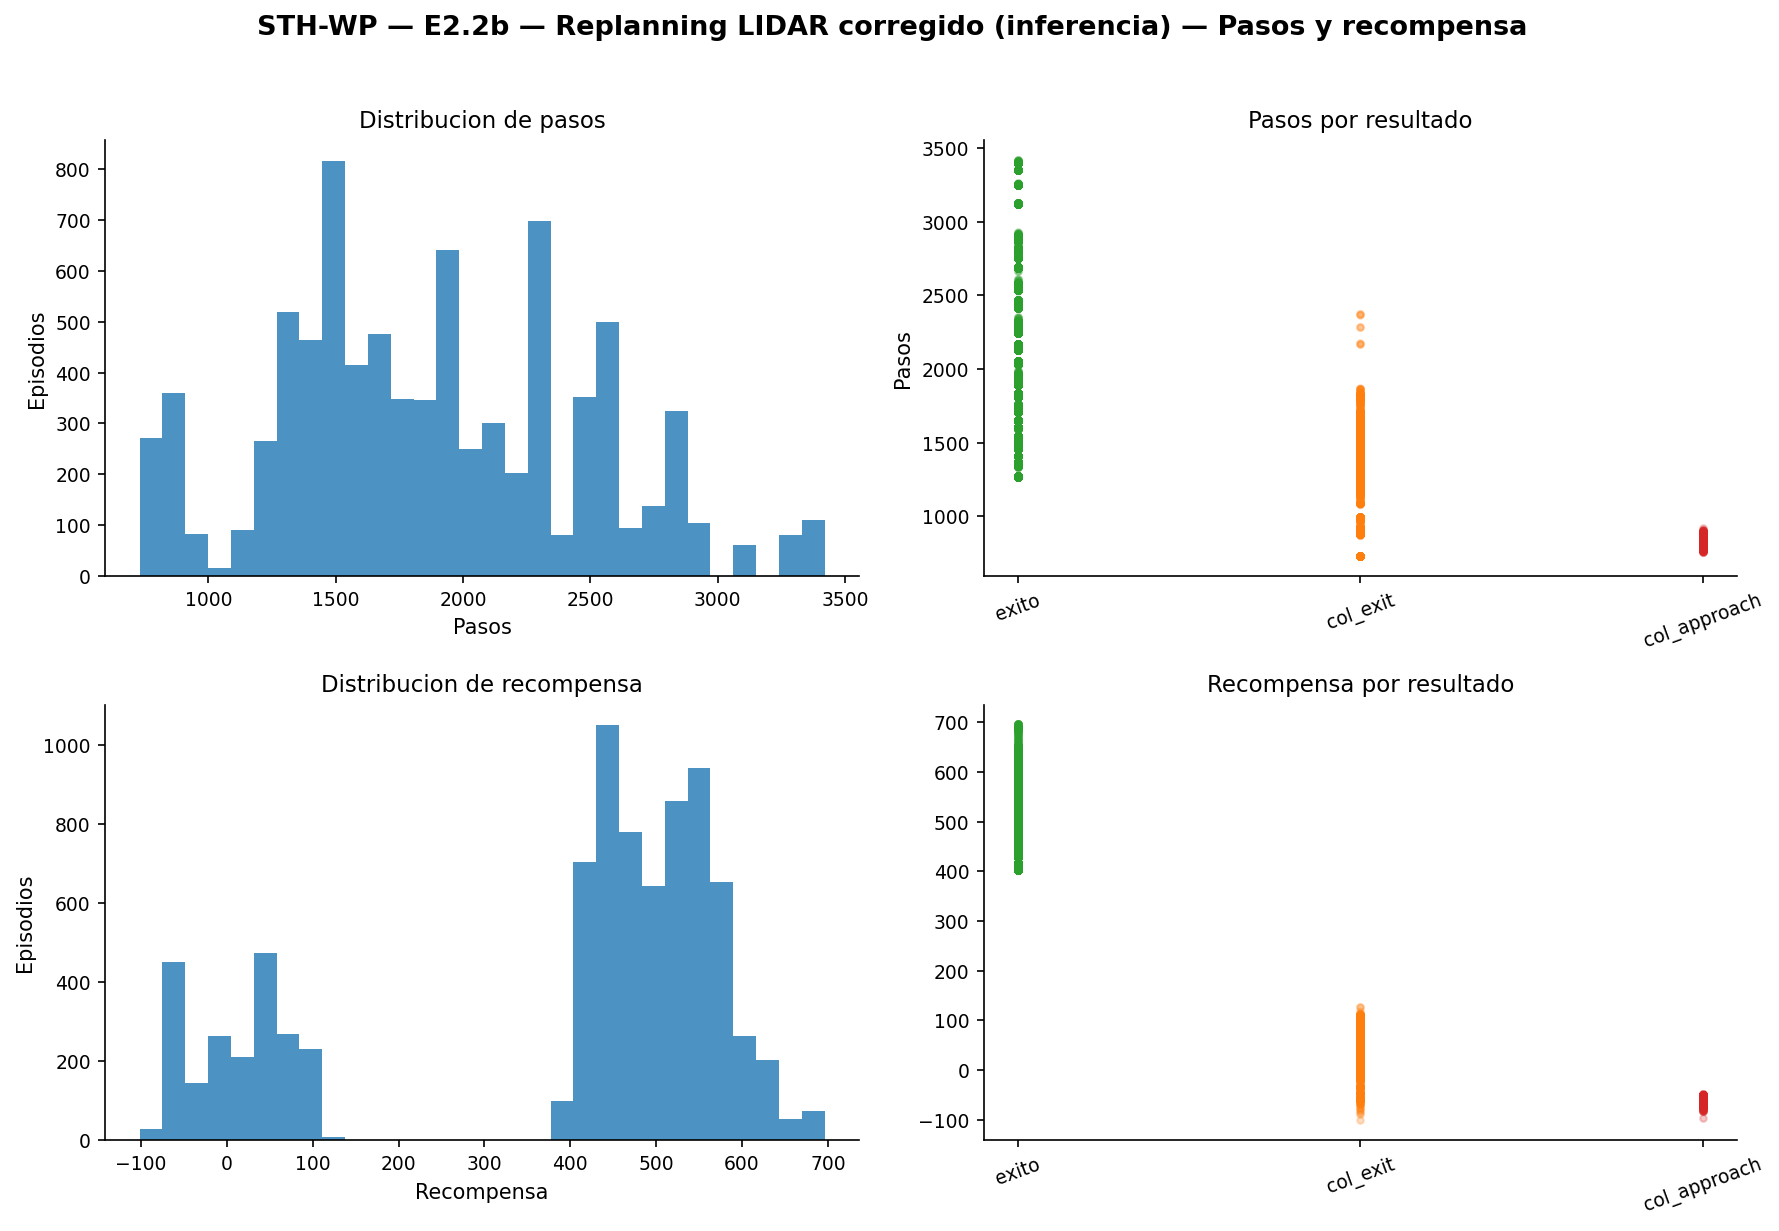

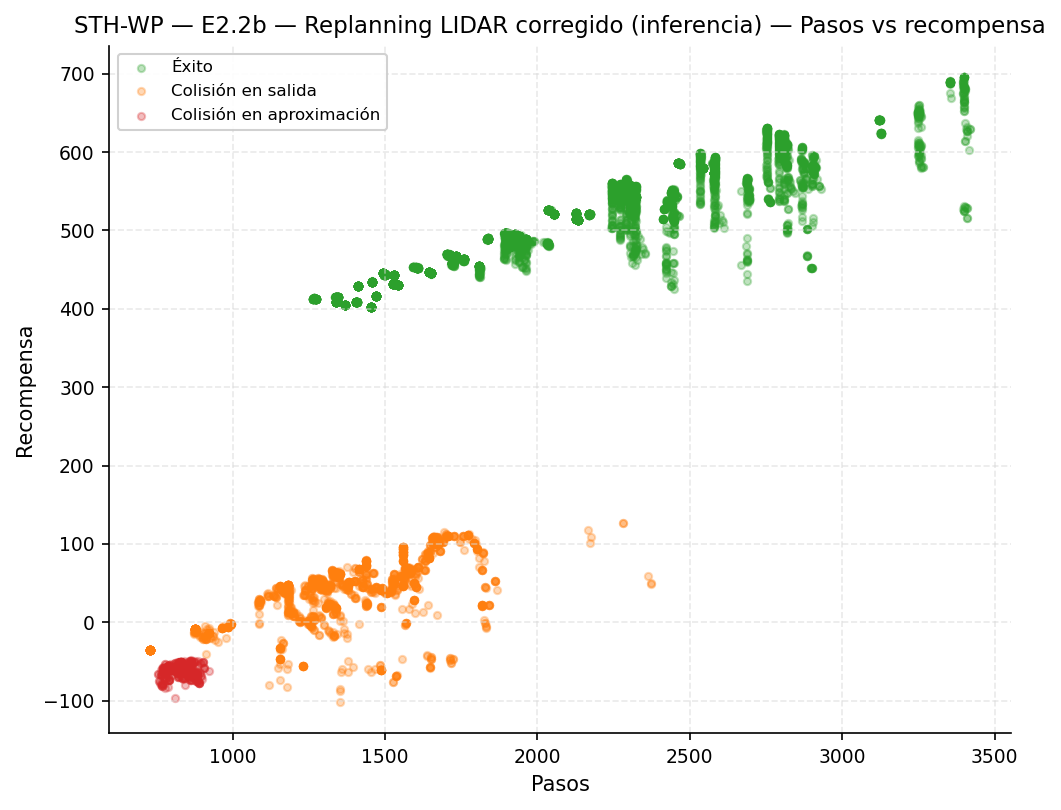

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_23': np.float64(0.0), 'goal_24': np.float64(0.7), 'goal_14': np.float64(13.0)}
  Mejores 3 objetivos: {'goal_13': np.float64(100.0), 'goal_11': np.float64(100.0), 'goal_01': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,6323,2077,0,75.27,74.34,76.18,24.73,23.82,25.66,0.0,1871.8,1810.0,598.9,383.88,467.16,220.52,no registrada,no registrada


In [14]:
resumen_sthwp_e2_2b_sthwp = analyze_phase(sthwp_dfs["sthwp_e2_2b"], "STH-WP — E2.2b — Replanning LIDAR corregido (inferencia)", "fig_sthwp_sthwp_e2_2b", ARCH_COLORS["STH-WP"])
if not resumen_sthwp_e2_2b_sthwp.empty:
    resumen_sthwp_e2_2b_sthwp.to_csv(TABLES_DIR / "tabla_resumen_sthwp_sthwp_e2_2b.csv", index=False)
    display(resumen_sthwp_e2_2b_sthwp)

---
## 7. Inferencias de SUB-WP por fase

Igual que en STH-WP, las fases evaluan tareas de dificultad distinta y no se comparan directamente entre
si.

### Fase 1 — Approach puro (inferencia)

- **Tarea evaluada**: aproximacion simple a un unico goal
- **Peaton presente**: No
- **Observaciones de auditoria**: Las tres semillas disponibles.


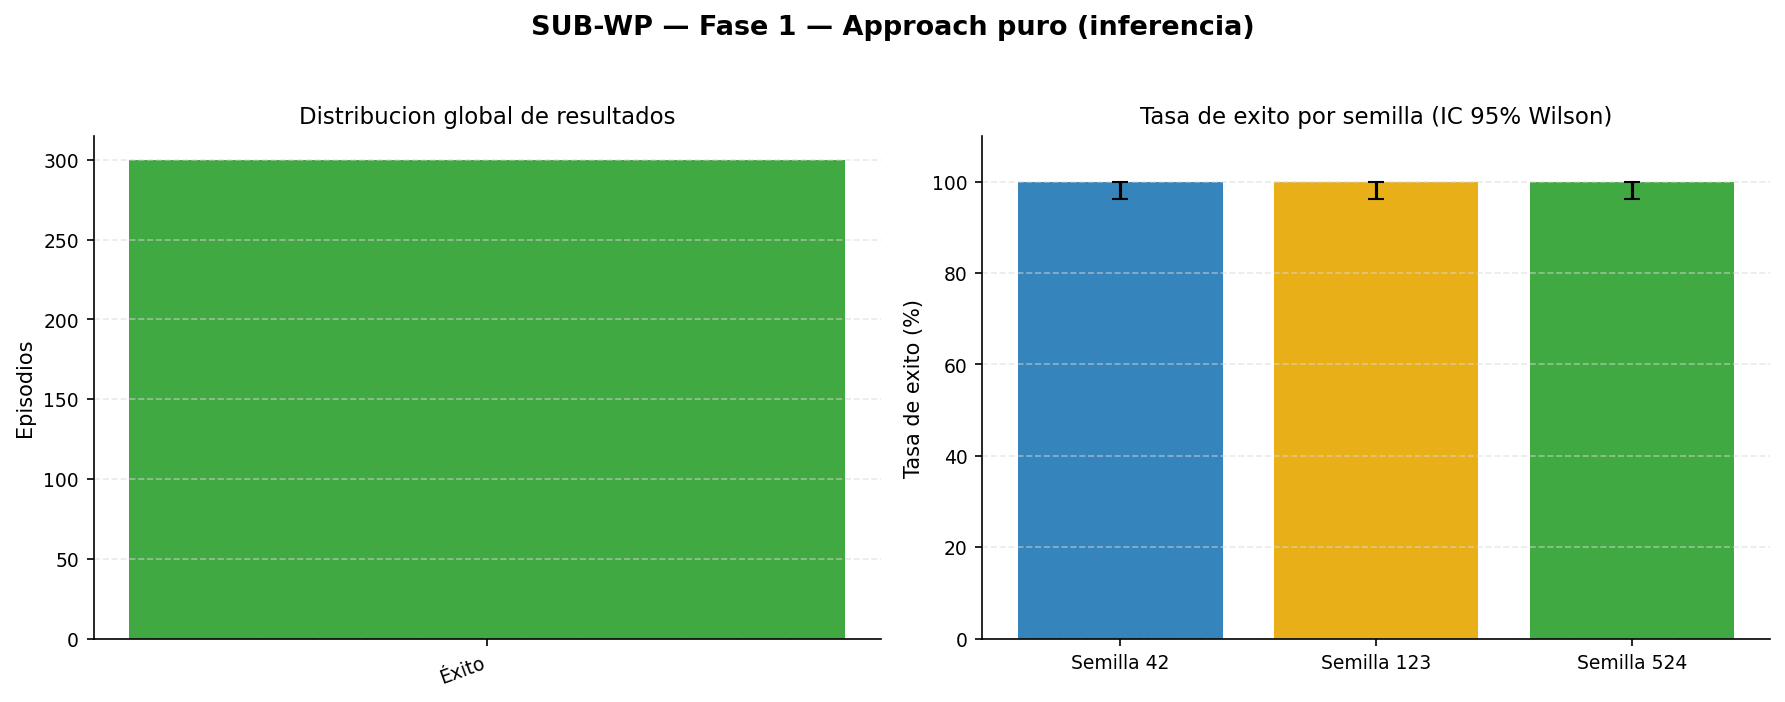

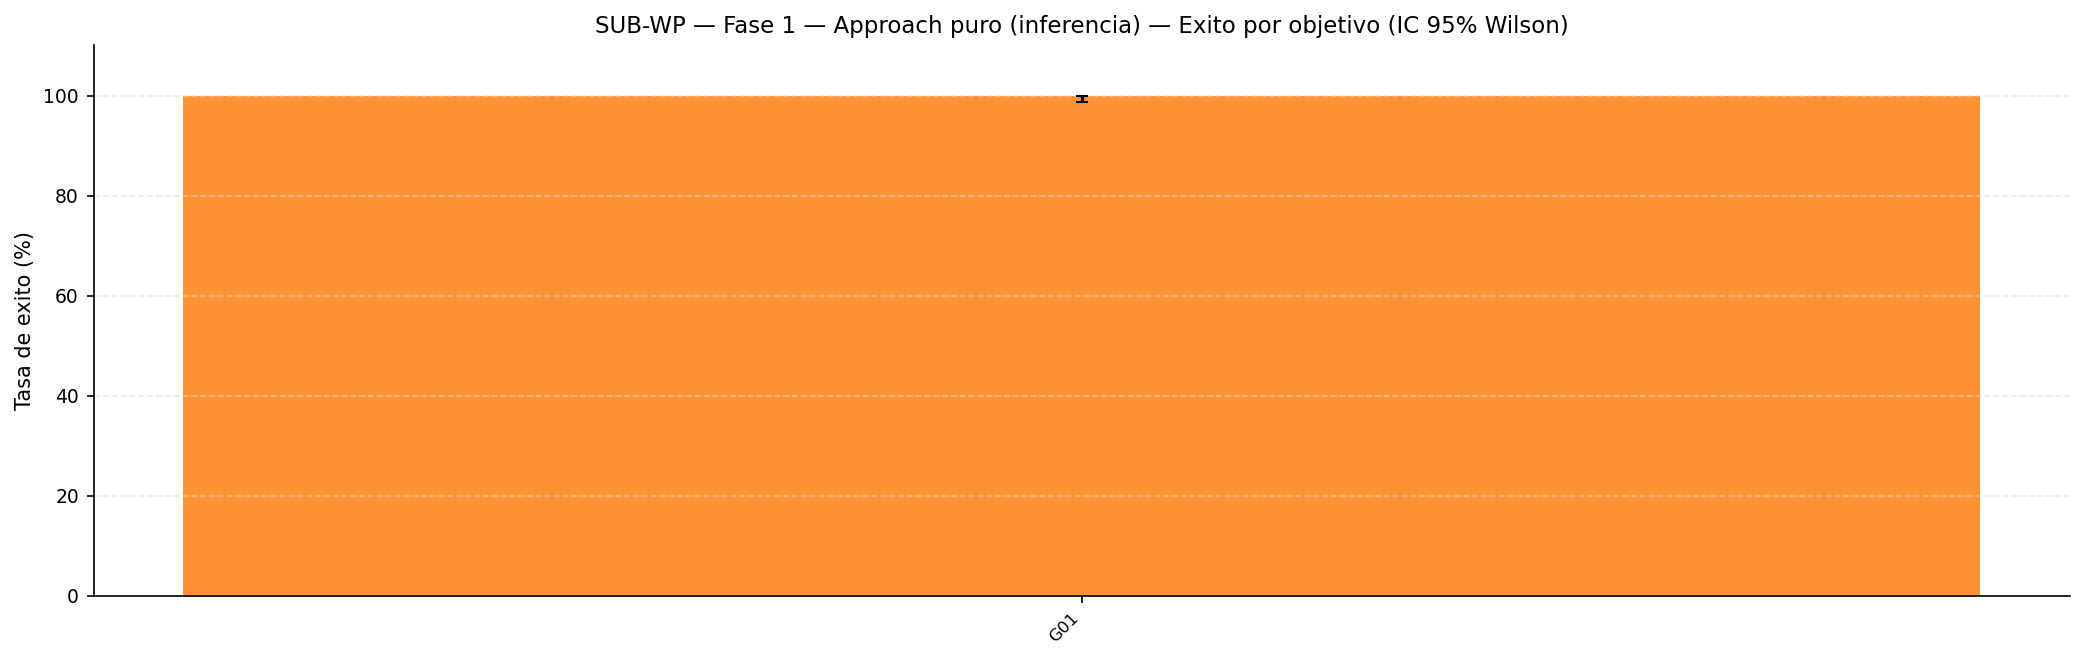

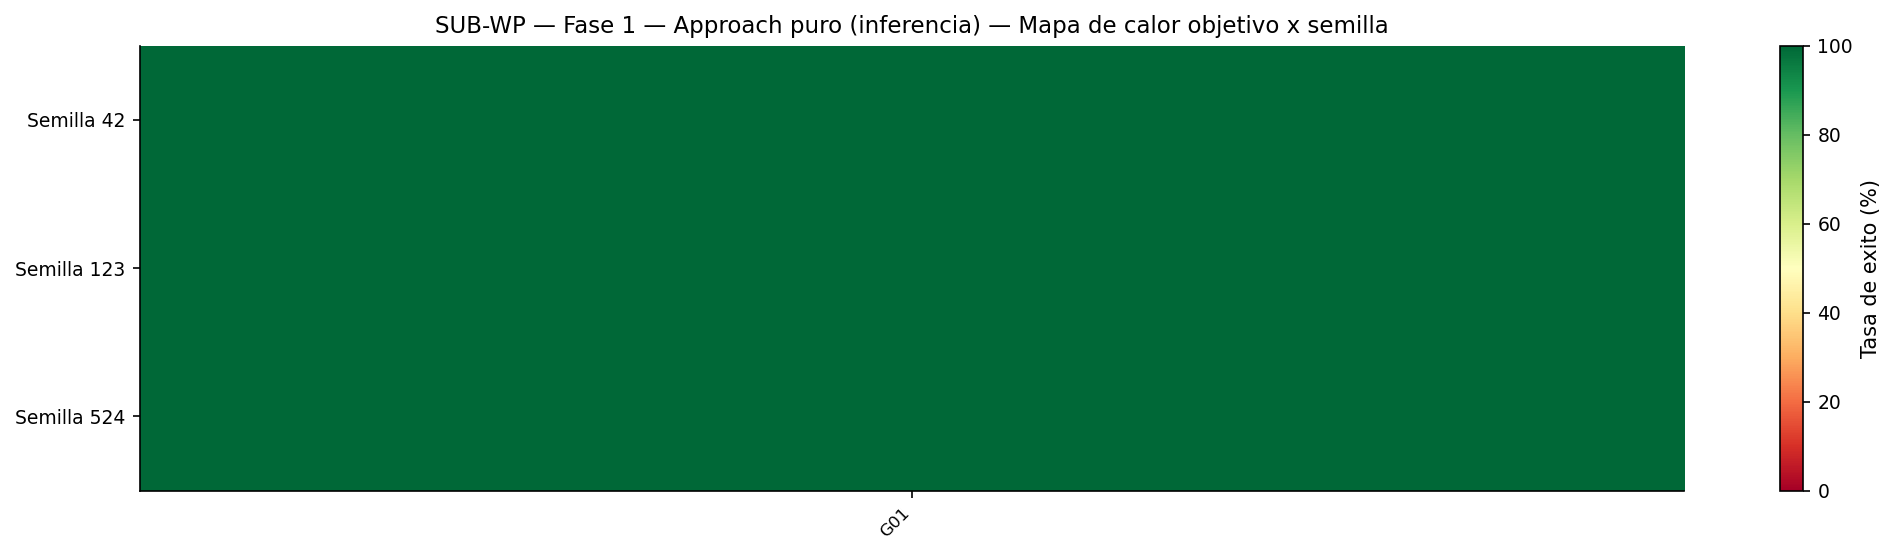

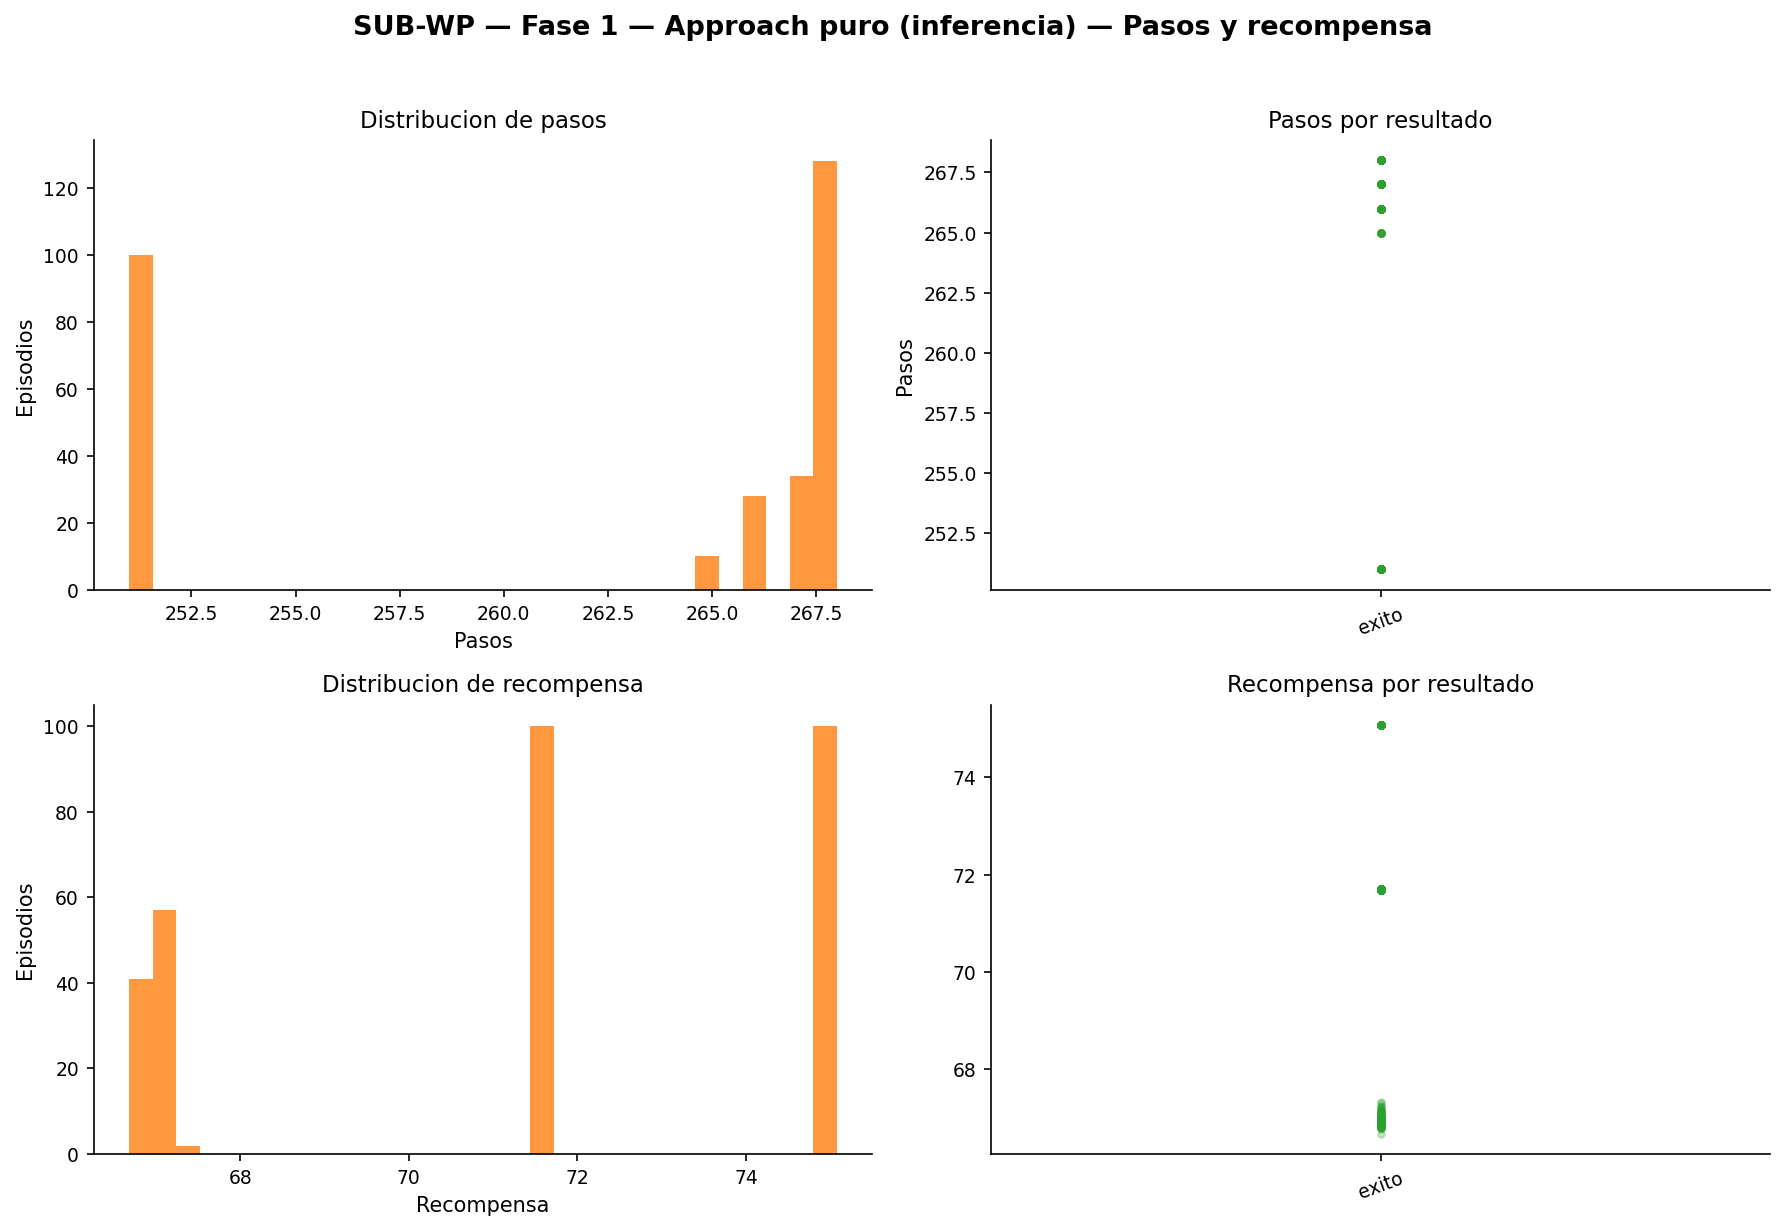

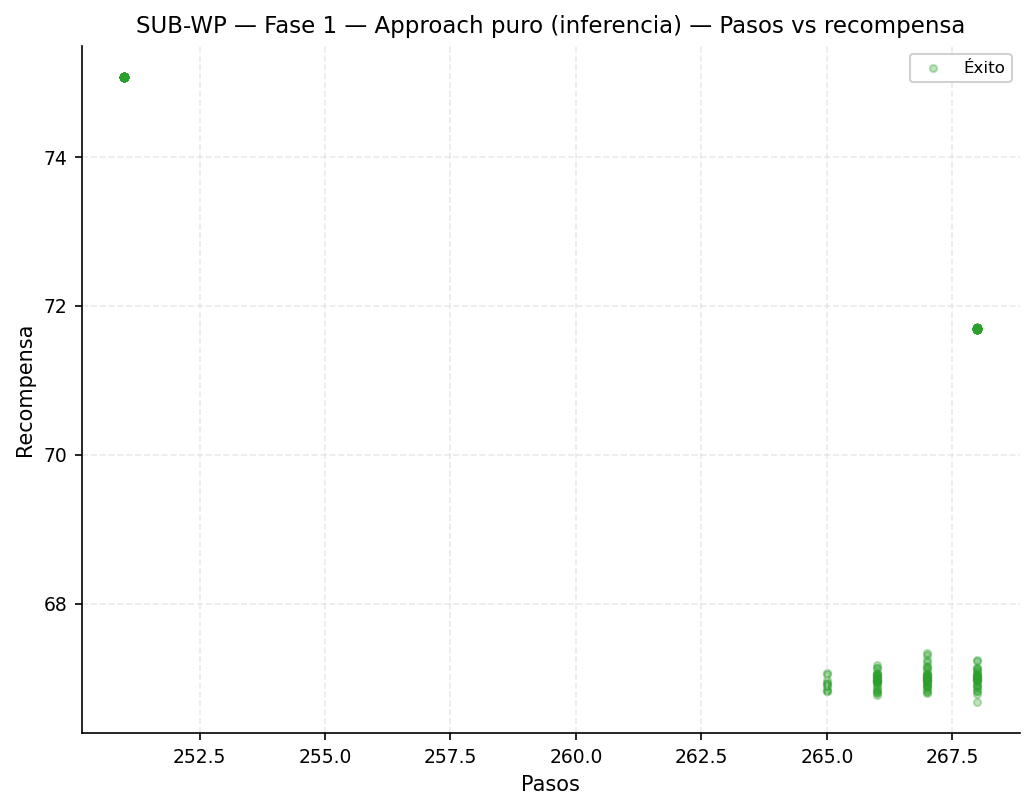

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_01': np.float64(100.0)}
  Mejores 3 objetivos: {'goal_01': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,300,3,300,0,0,100.0,98.74,100.0,0.0,0.0,1.26,0.0,261.9,267.0,7.8,71.25,71.69,3.32,no registrada,no registrada


In [15]:
resumen_stage1_subwp = analyze_phase(subwp_dfs["stage1"], "SUB-WP — Fase 1 — Approach puro (inferencia)", "fig_subwp_stage1", ARCH_COLORS["SUB-WP"])
if not resumen_stage1_subwp.empty:
    resumen_stage1_subwp.to_csv(TABLES_DIR / "tabla_resumen_subwp_stage1.csv", index=False)
    display(resumen_stage1_subwp)

### Fase 2 — Approach generalizado (inferencia)

- **Tarea evaluada**: aproximacion generalizada a 28 goals
- **Peaton presente**: No
- **Observaciones de auditoria**: Las tres semillas disponibles.


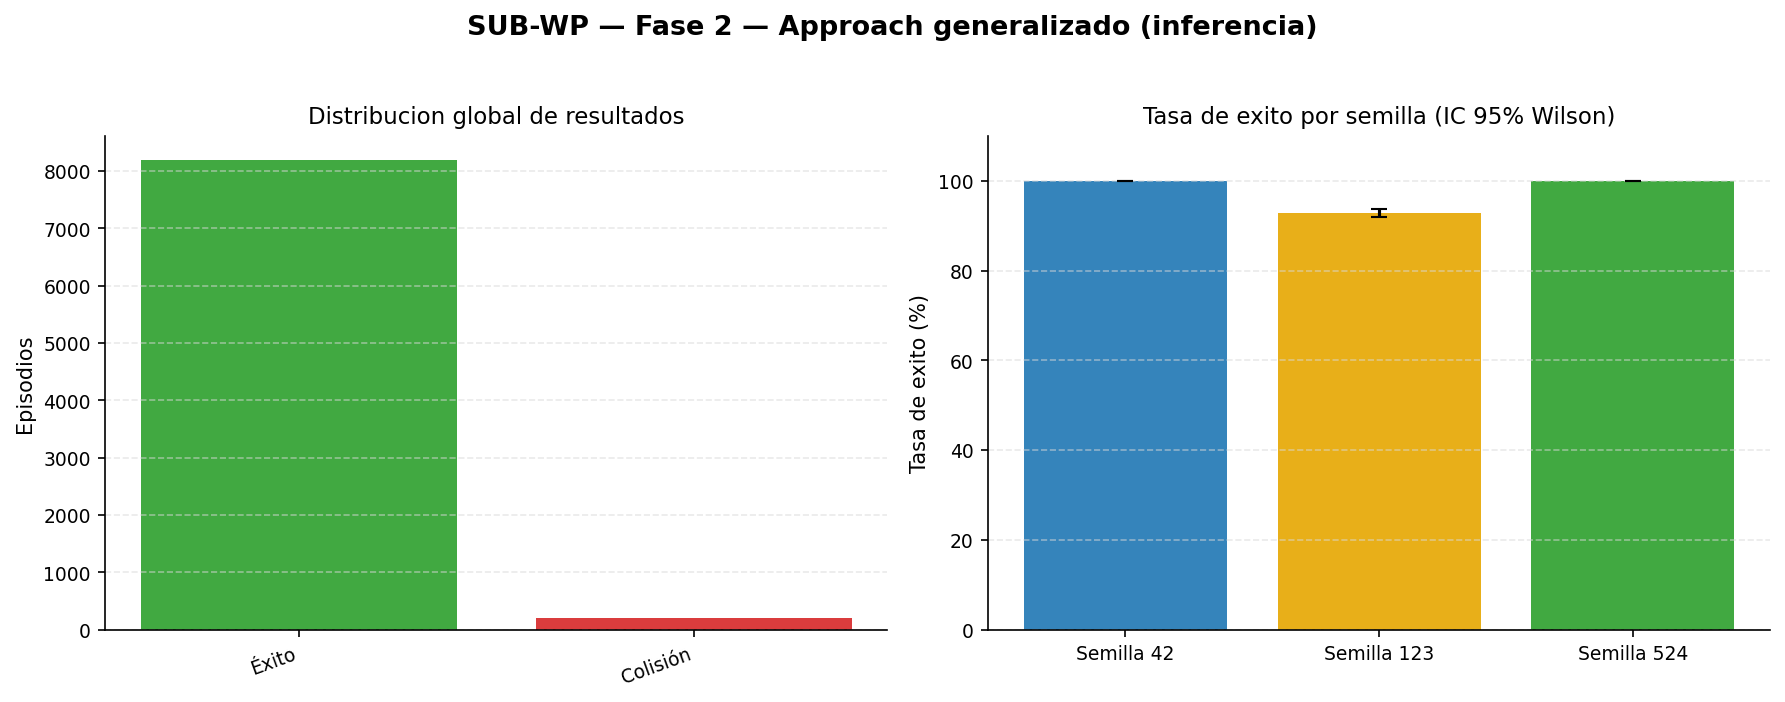

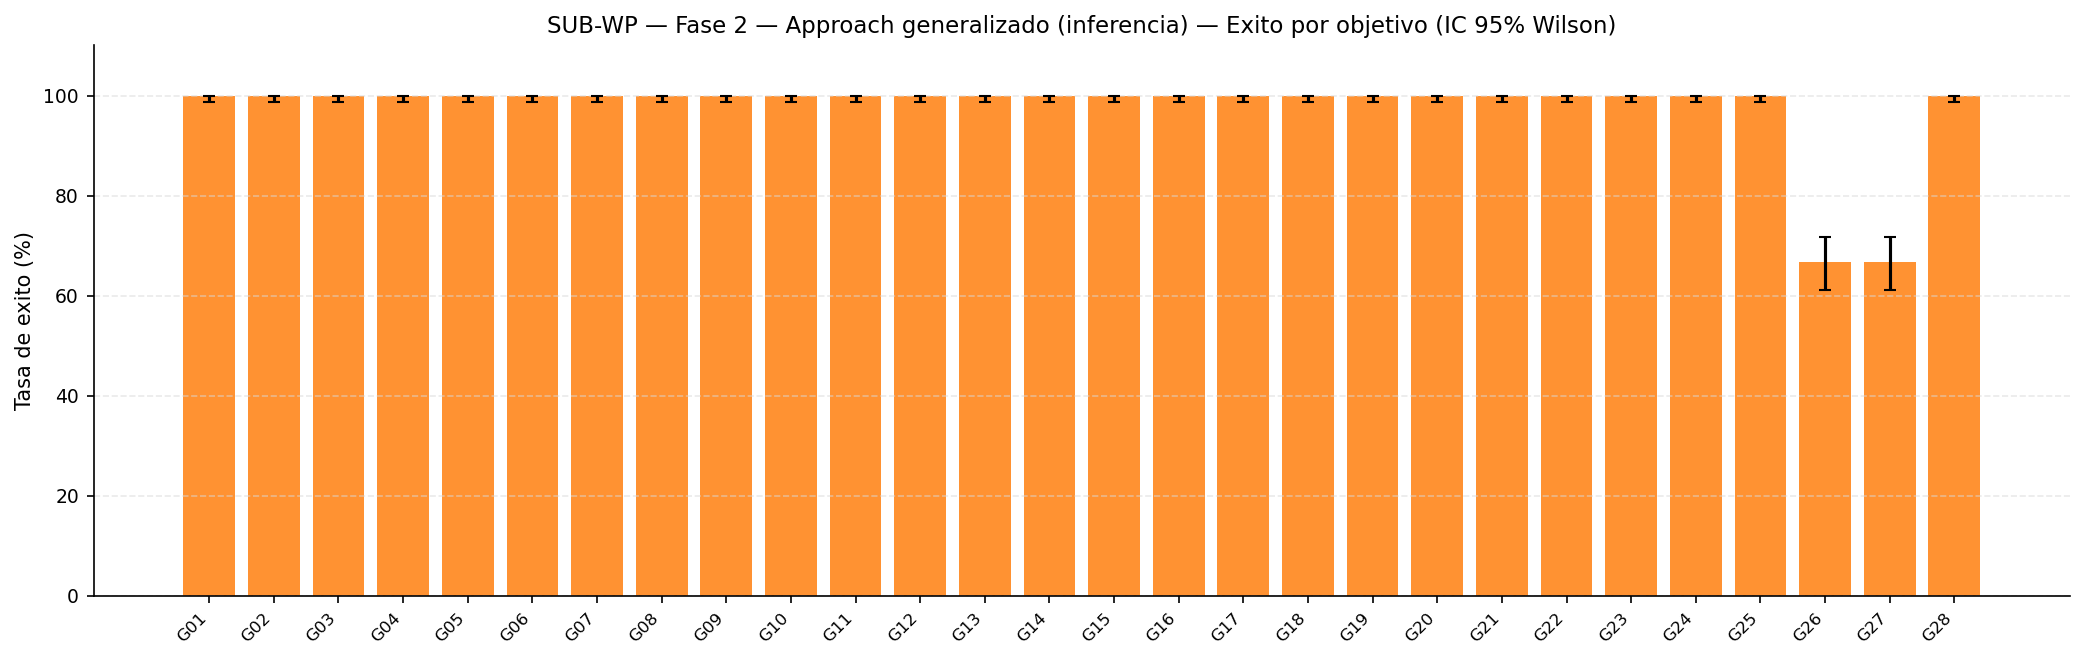

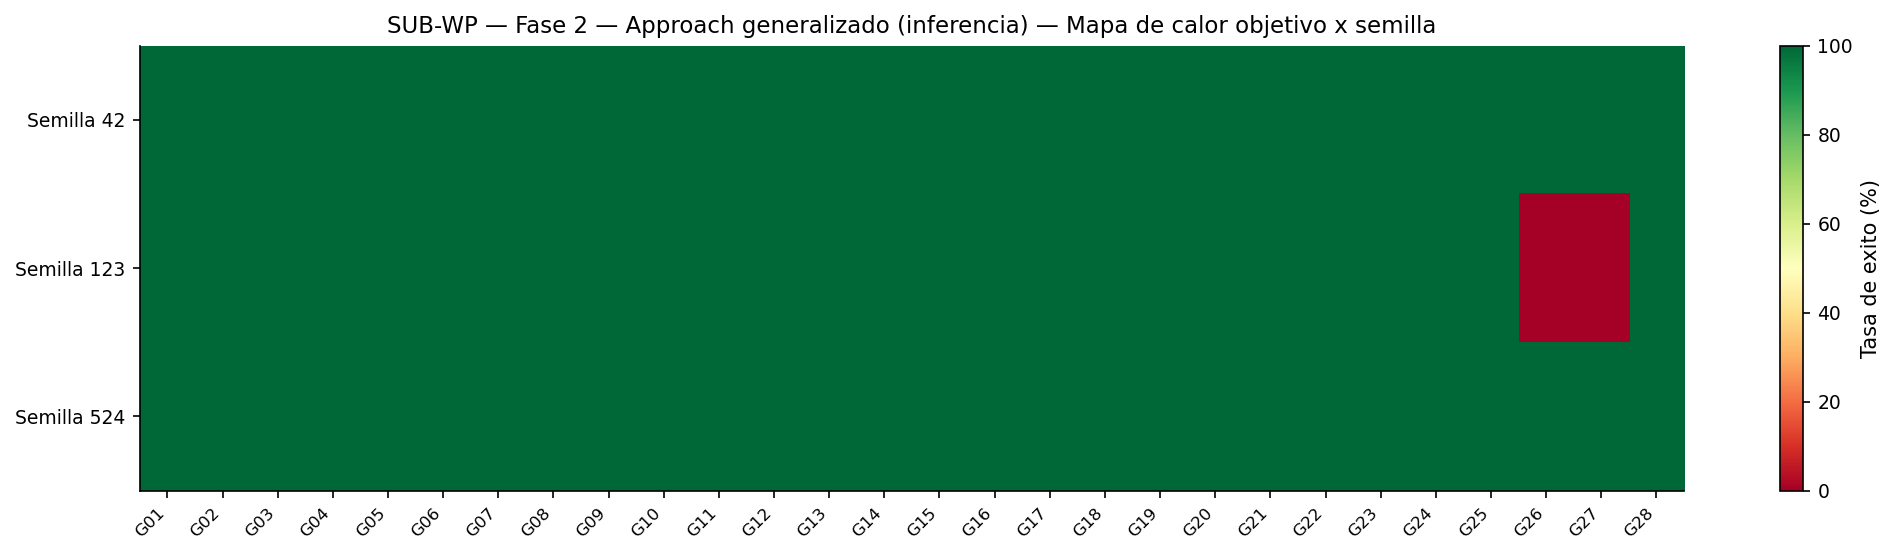

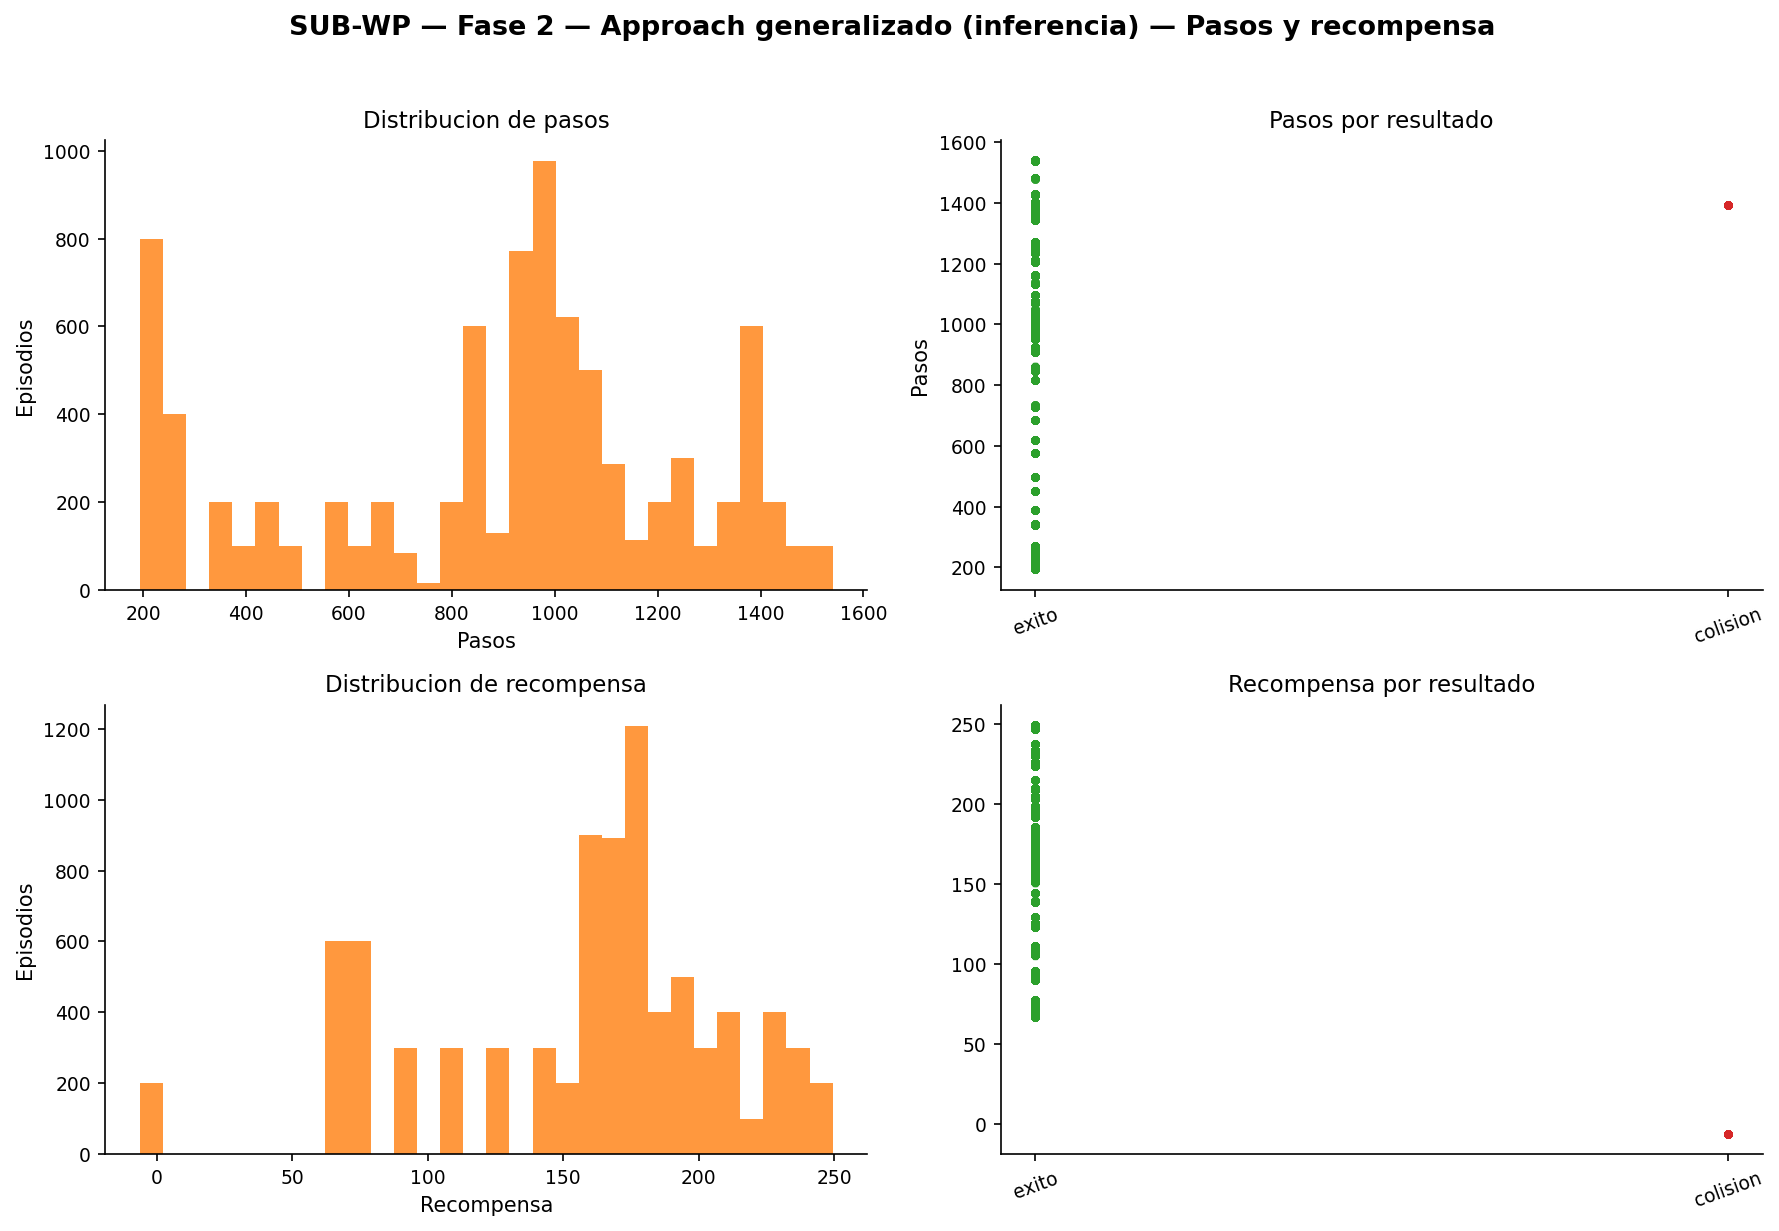

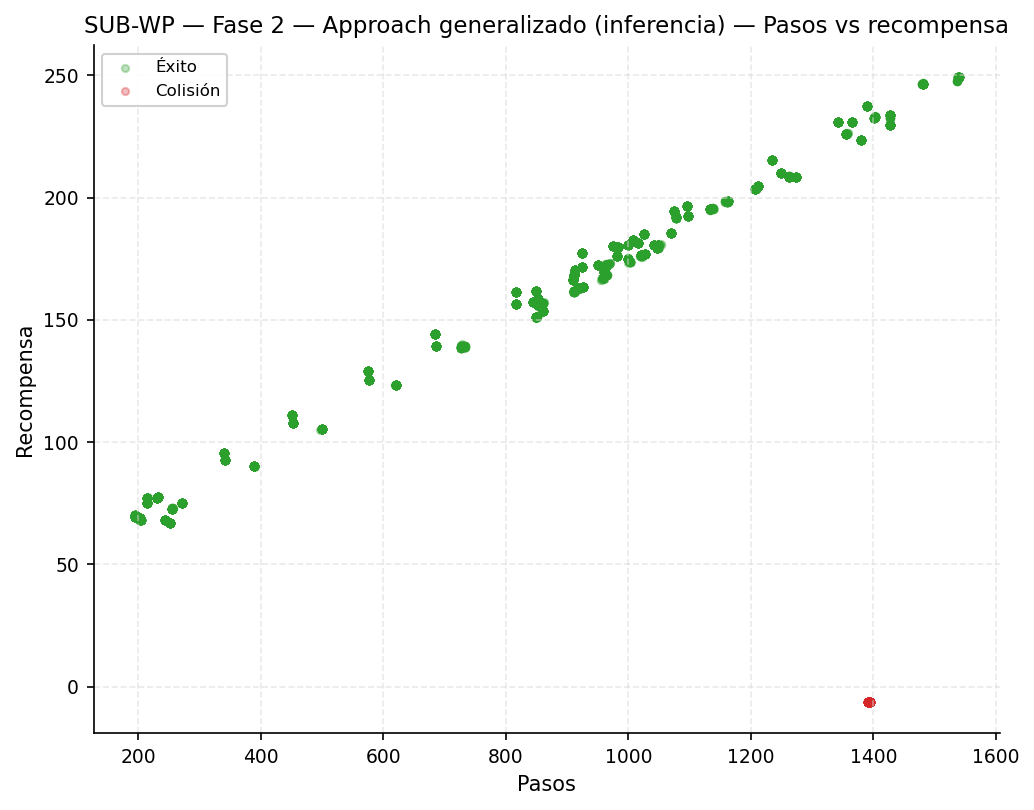

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_26': np.float64(66.7), 'goal_27': np.float64(66.7), 'goal_01': np.float64(100.0)}
  Mejores 3 objetivos: {'goal_02': np.float64(100.0), 'goal_13': np.float64(100.0), 'goal_28': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,8200,200,0,97.62,97.27,97.92,2.38,2.08,2.73,0.0,882.7,960.5,372.4,156.68,170.08,55.35,no registrada,no registrada


In [16]:
resumen_stage2_subwp = analyze_phase(subwp_dfs["stage2"], "SUB-WP — Fase 2 — Approach generalizado (inferencia)", "fig_subwp_stage2", ARCH_COLORS["SUB-WP"])
if not resumen_stage2_subwp.empty:
    resumen_stage2_subwp.to_csv(TABLES_DIR / "tabla_resumen_subwp_stage2.csv", index=False)
    display(resumen_stage2_subwp)

### Fase 3 r2 — Exit puro corregido (inferencia)

- **Tarea evaluada**: salida (exit) con zona de descarga corregida
- **Peaton presente**: No
- **Observaciones de auditoria**: Se prioriza wp75_r2 frente a las variantes 'wp75_stage3' (pre-r2) y 'stage3' (mas antigua aun), ambas EXCLUIDAS por evaluar un modelo con la zona de descarga mal definida.


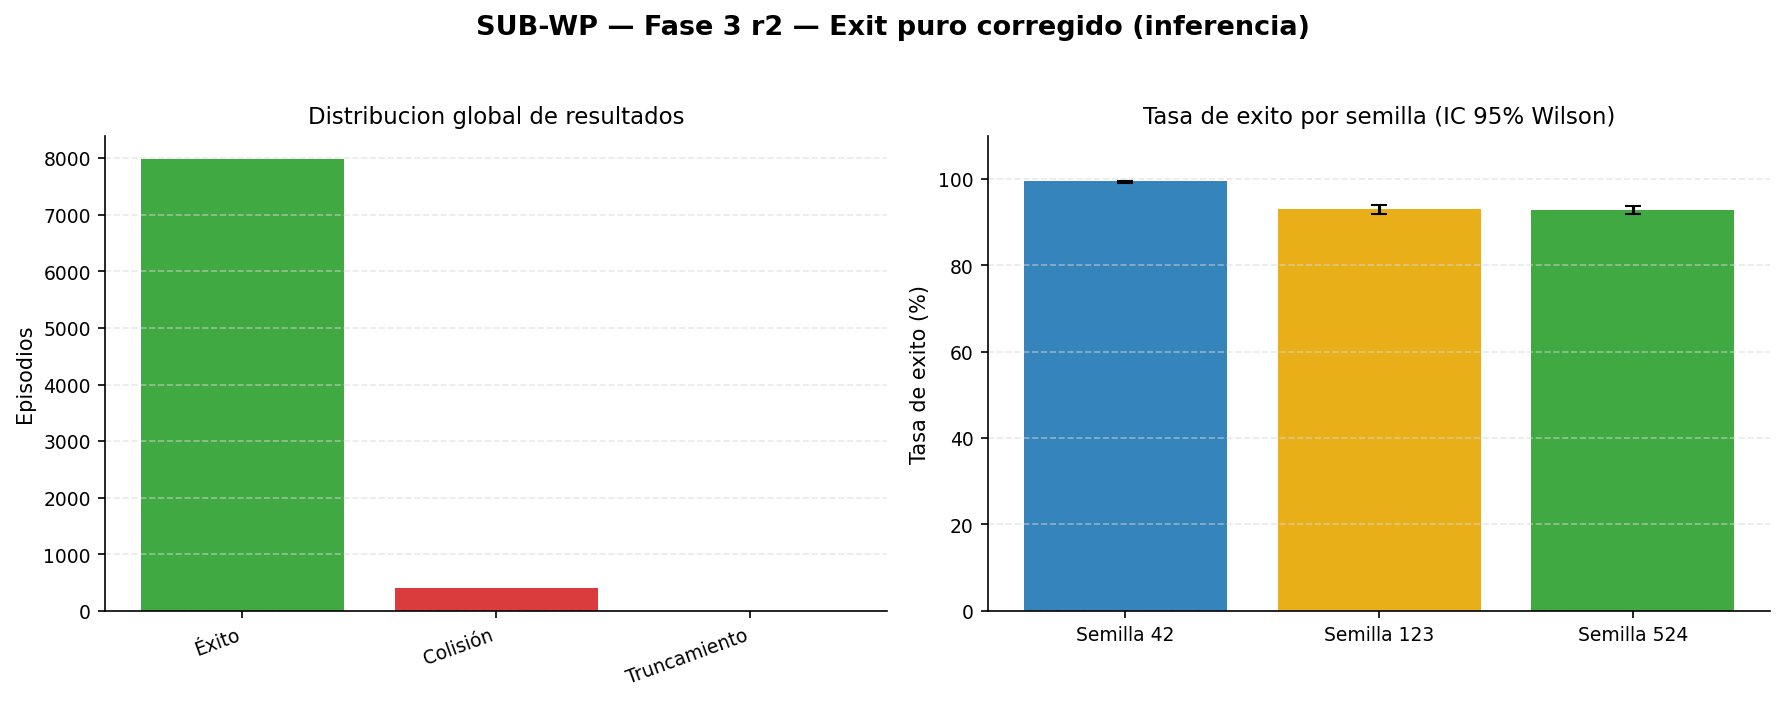

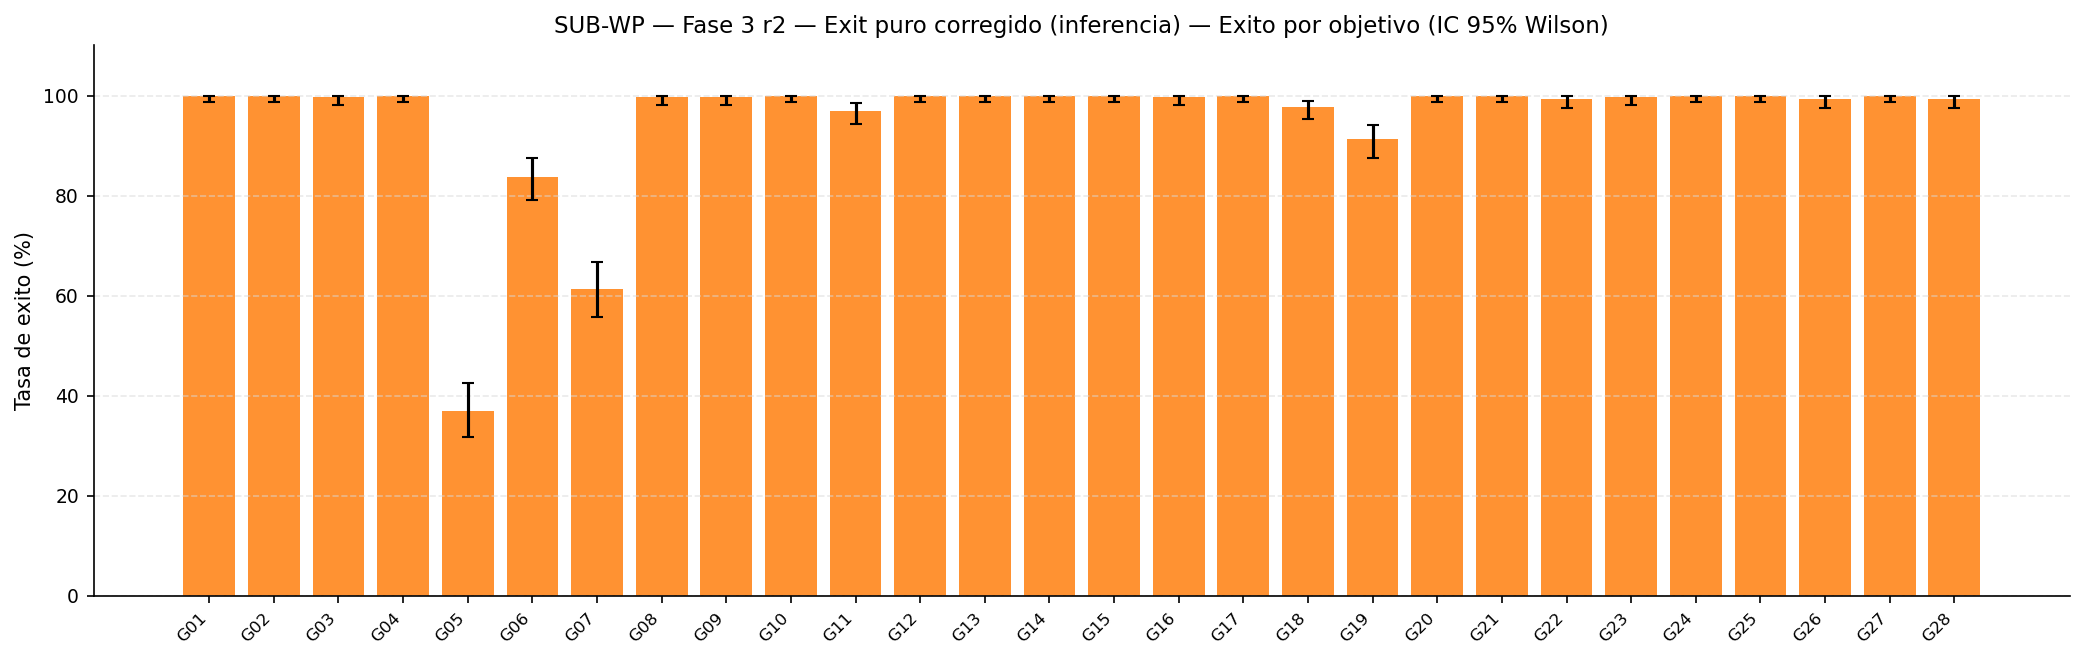

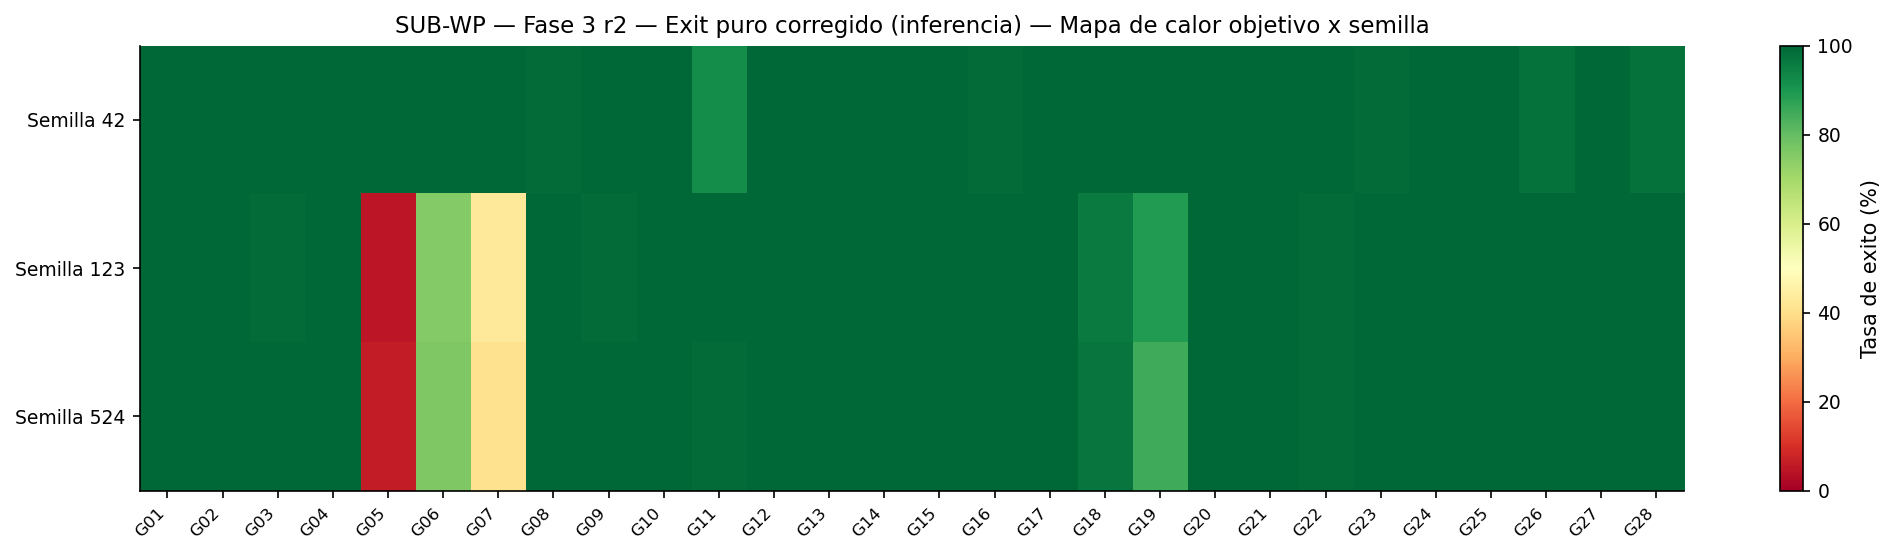

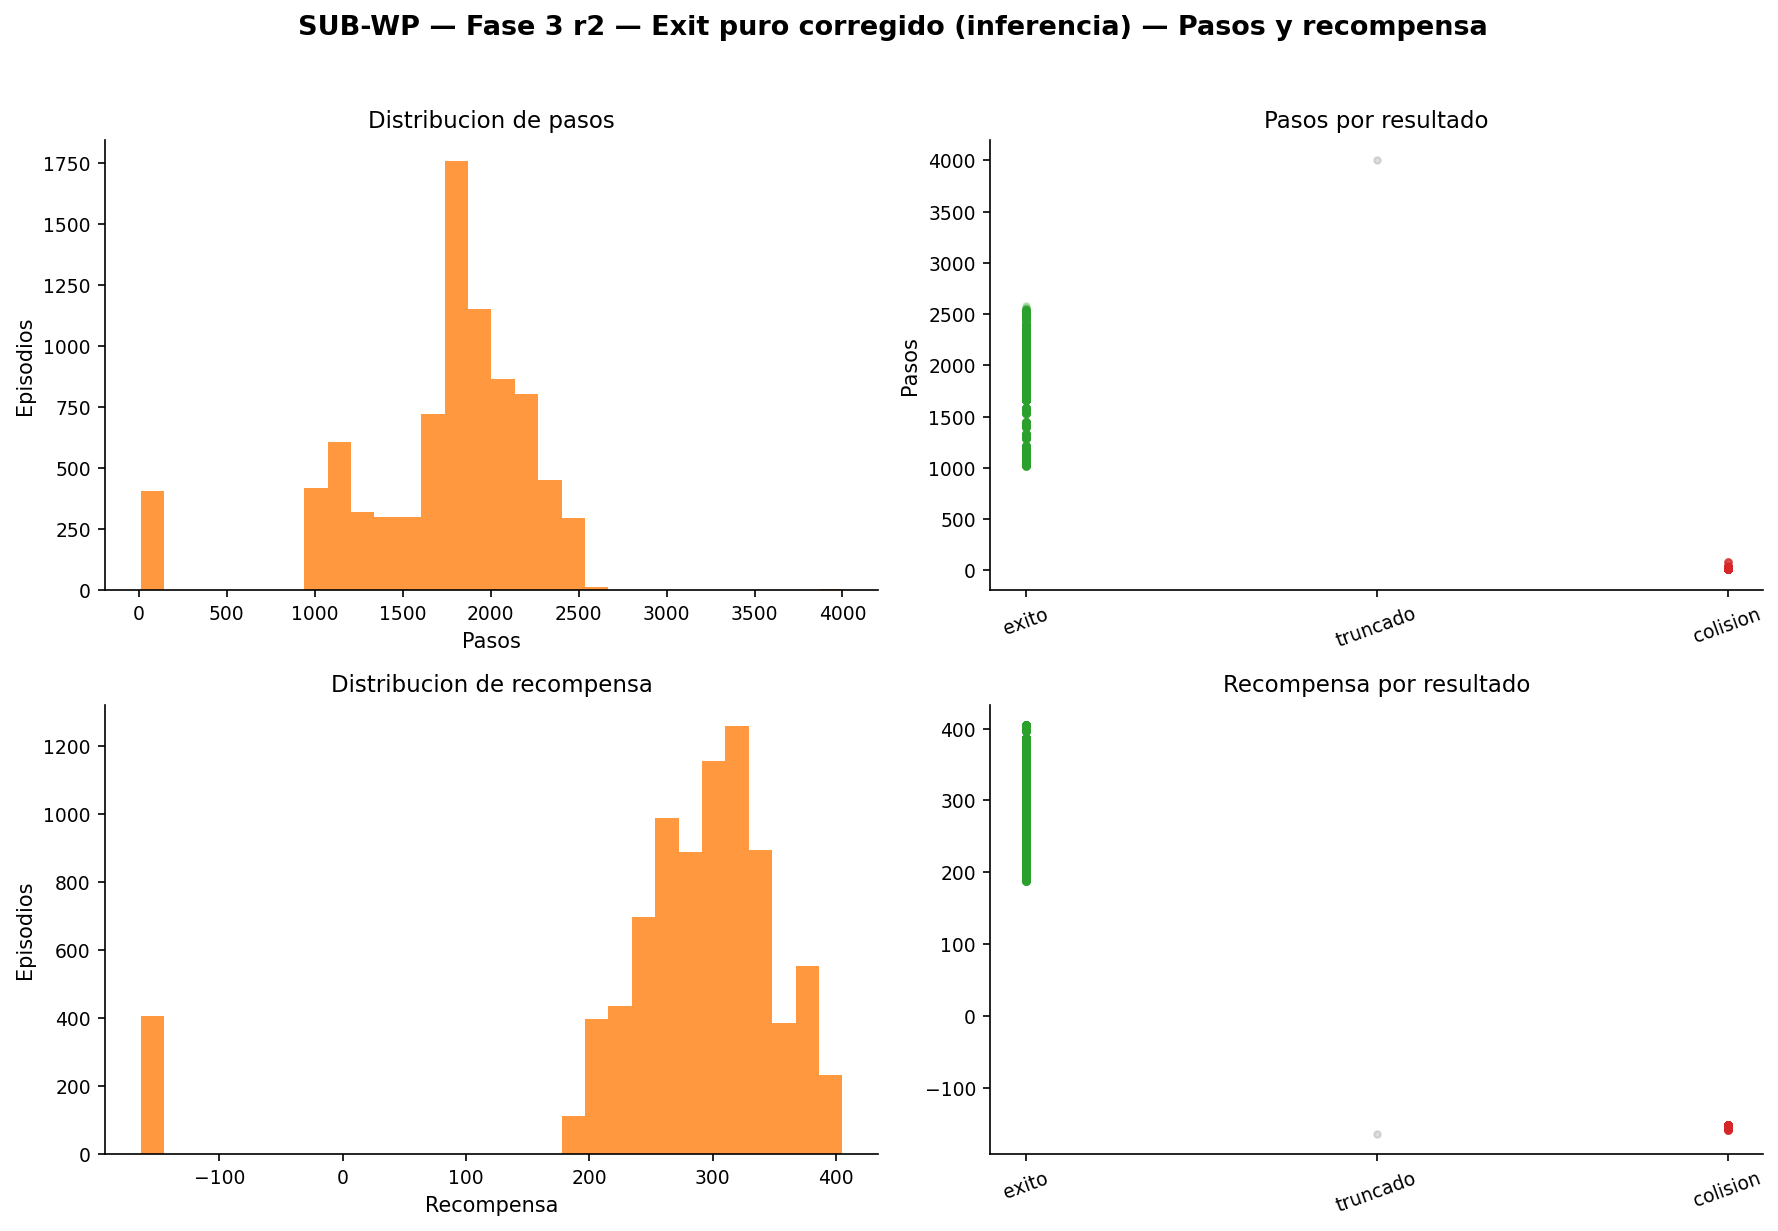

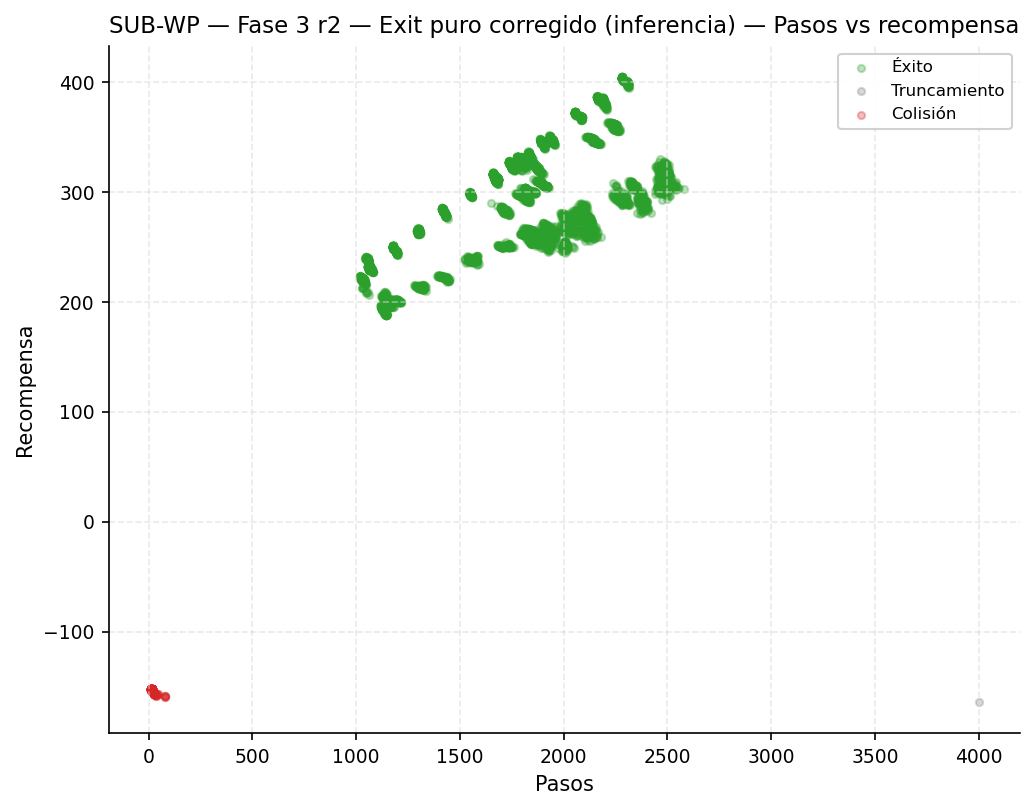

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_05': np.float64(37.0), 'goal_07': np.float64(61.3), 'goal_06': np.float64(83.7)}
  Mejores 3 objetivos: {'goal_02': np.float64(100.0), 'goal_17': np.float64(100.0), 'goal_14': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,7993,406,1,95.15,94.67,95.59,4.83,4.39,5.31,0.01,1716.6,1831.0,528.9,275.26,297.24,108.34,no registrada,no registrada


In [17]:
resumen_stage3_r2_subwp = analyze_phase(subwp_dfs["stage3_r2"], "SUB-WP — Fase 3 r2 — Exit puro corregido (inferencia)", "fig_subwp_stage3_r2", ARCH_COLORS["SUB-WP"])
if not resumen_stage3_r2_subwp.empty:
    resumen_stage3_r2_subwp.to_csv(TABLES_DIR / "tabla_resumen_subwp_stage3_r2.csv", index=False)
    display(resumen_stage3_r2_subwp)

### Fase 4 r2 — Ciclo approach+exit corregido (inferencia)

- **Tarea evaluada**: ciclo aproximacion+salida (70/30) con zona de descarga corregida
- **Peaton presente**: No
- **Observaciones de auditoria**: Se prioriza wp75_r2 frente a variantes pre-r2, EXCLUIDAS.


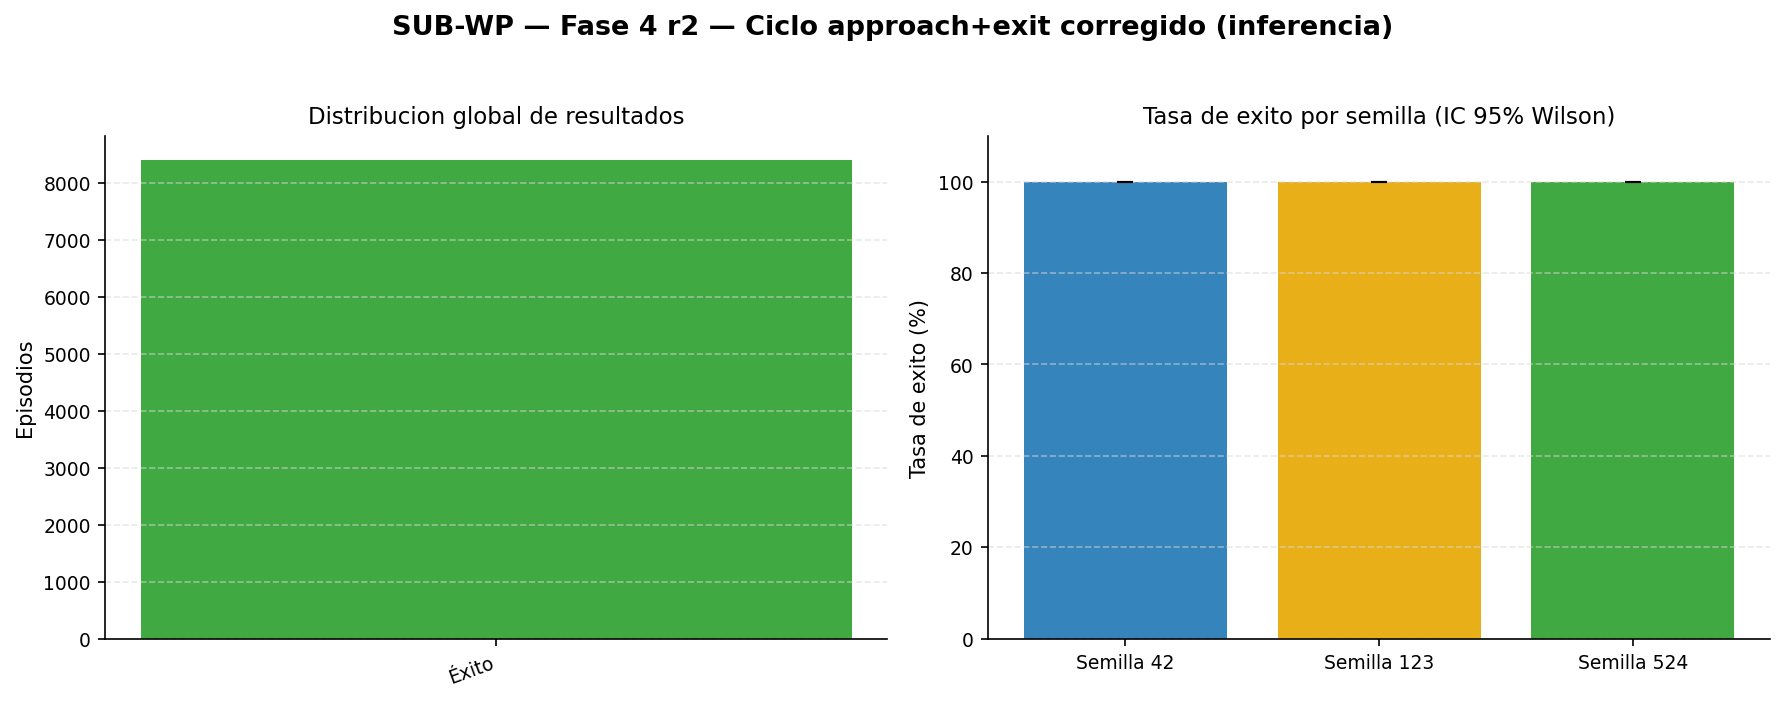

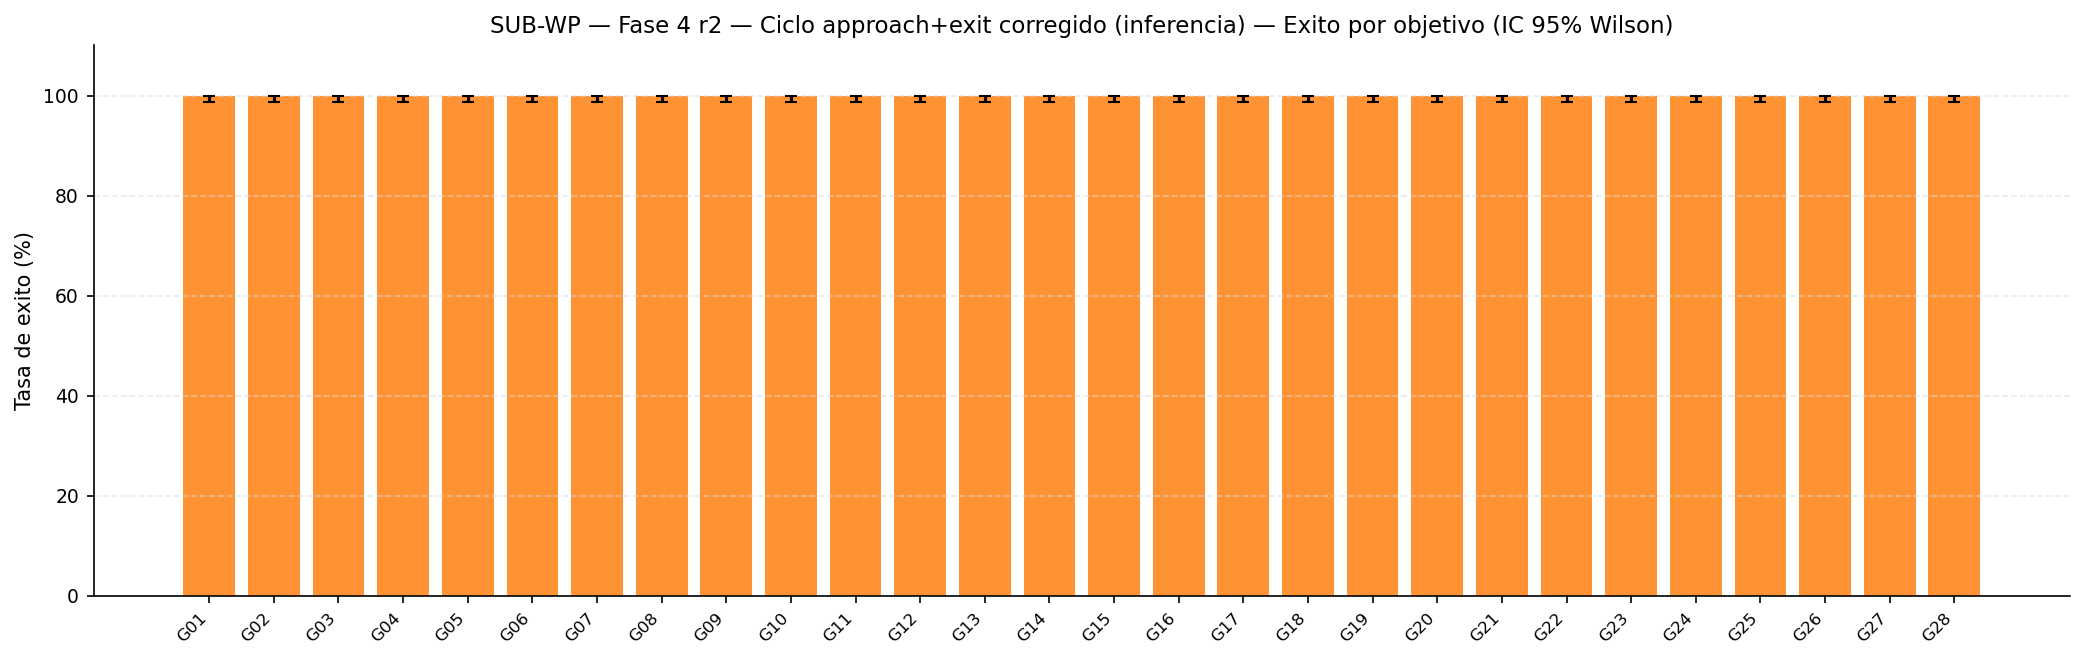

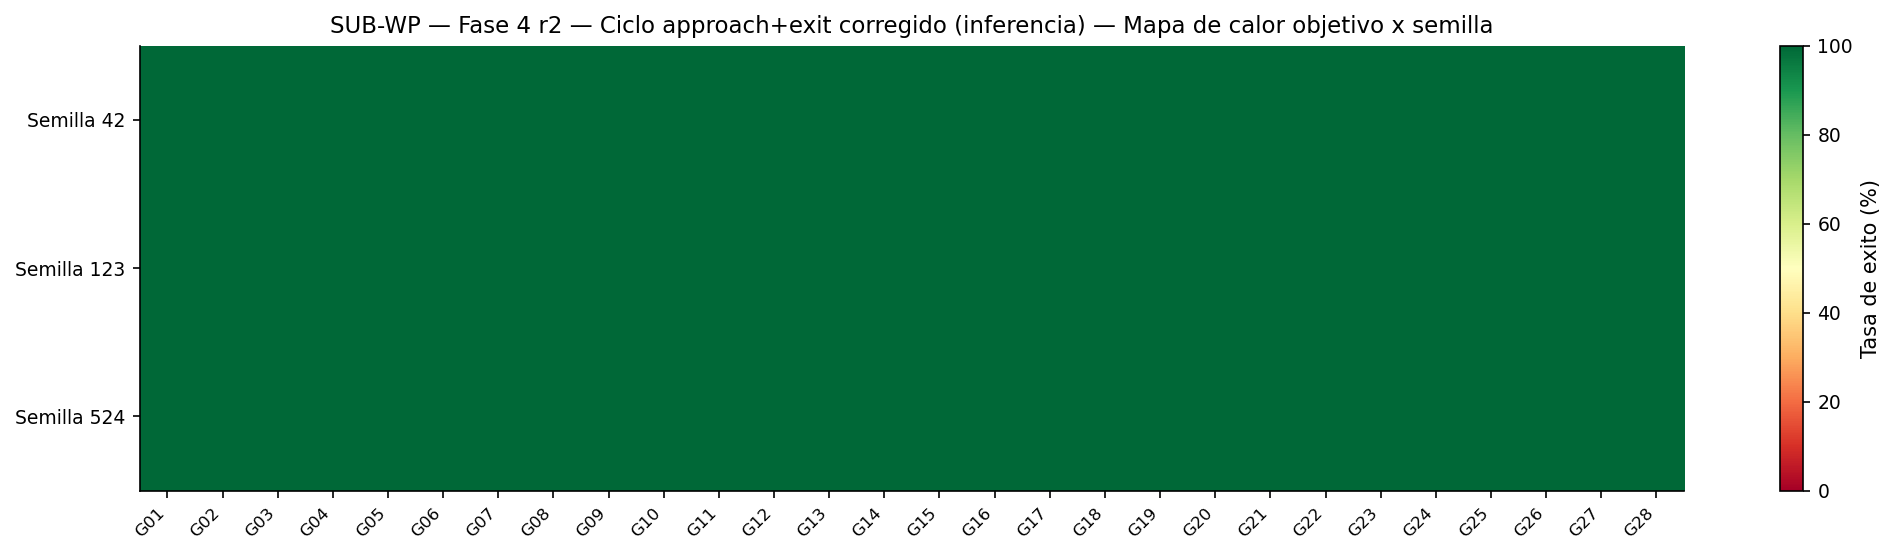

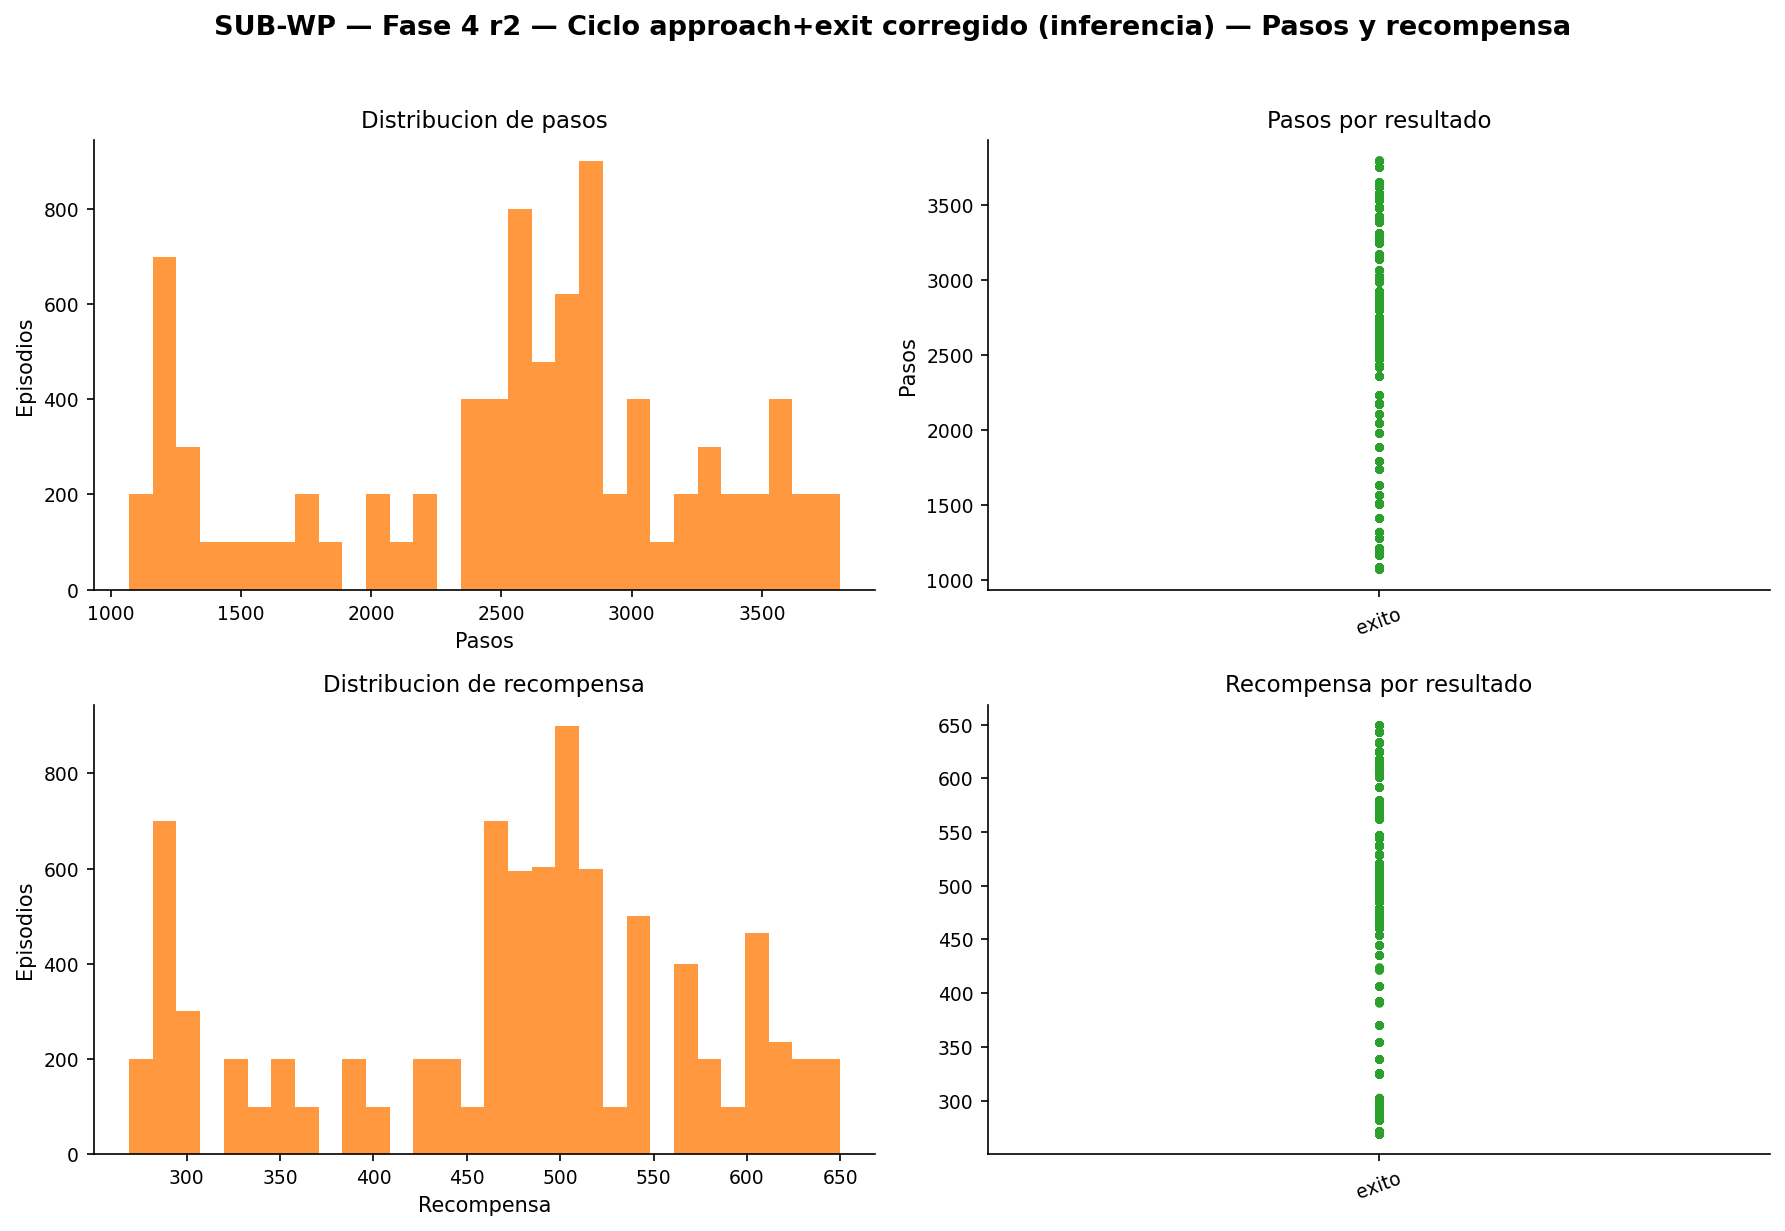

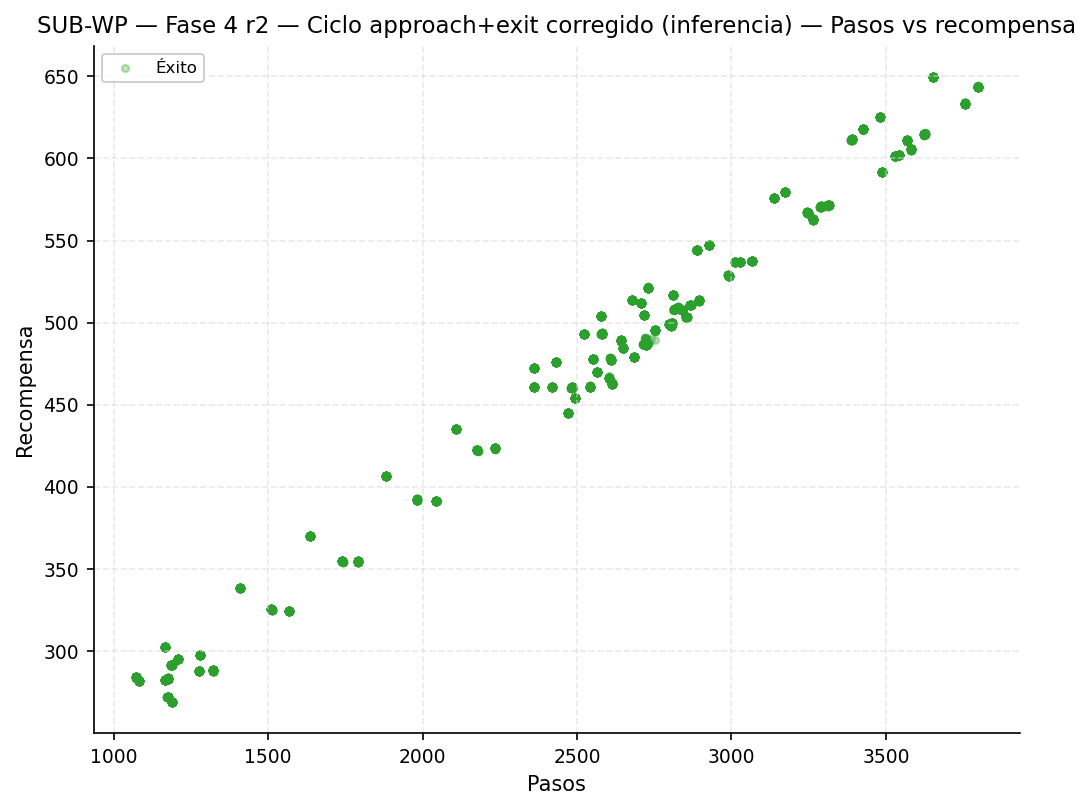

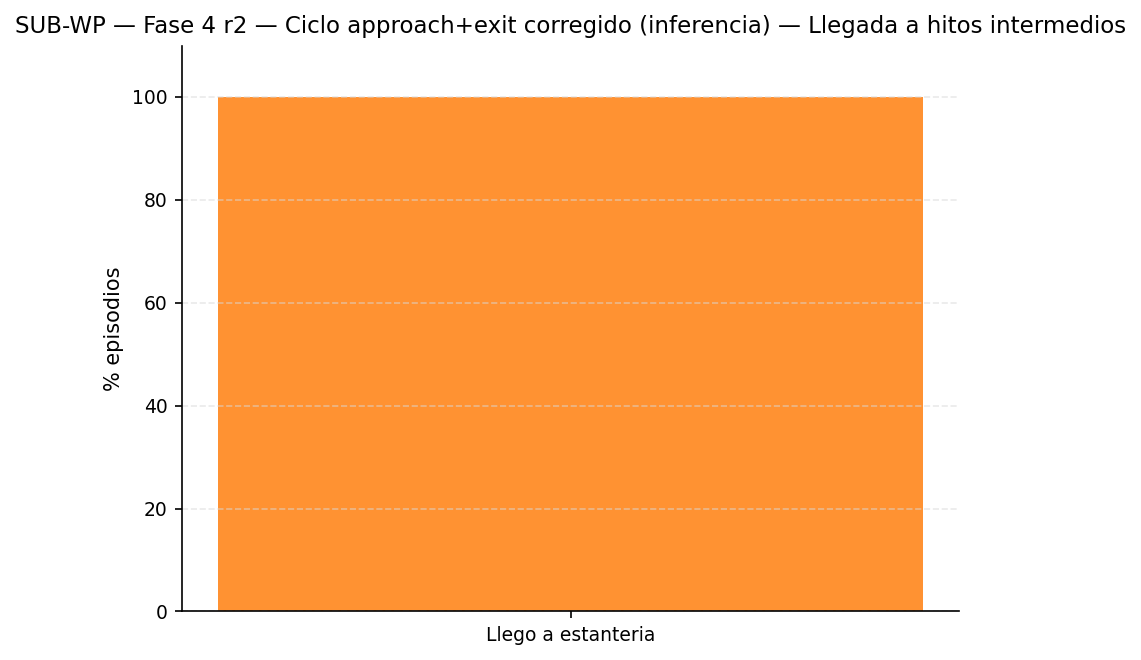

  Peores 3 objetivos: {'goal_01': np.float64(100.0), 'goal_26': np.float64(100.0), 'goal_25': np.float64(100.0)}
  Mejores 3 objetivos: {'goal_02': np.float64(100.0), 'goal_27': np.float64(100.0), 'goal_28': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,8400,0,0,100.0,99.95,100.0,0.0,0.0,0.05,0.0,2524.6,2663.5,747.0,471.66,491.84,103.74,100.0,no registrada


In [18]:
resumen_stage4_r2_subwp = analyze_phase(subwp_dfs["stage4_r2"], "SUB-WP — Fase 4 r2 — Ciclo approach+exit corregido (inferencia)", "fig_subwp_stage4_r2", ARCH_COLORS["SUB-WP"])
if not resumen_stage4_r2_subwp.empty:
    resumen_stage4_r2_subwp.to_csv(TABLES_DIR / "tabla_resumen_subwp_stage4_r2.csv", index=False)
    display(resumen_stage4_r2_subwp)

### Fase 5 r2 — Return puro corregido (inferencia)

- **Tarea evaluada**: retorno puro con zona de descarga corregida
- **Peaton presente**: No
- **Observaciones de auditoria**: Se prioriza wp75_r2 frente a variantes pre-r2, EXCLUIDAS.


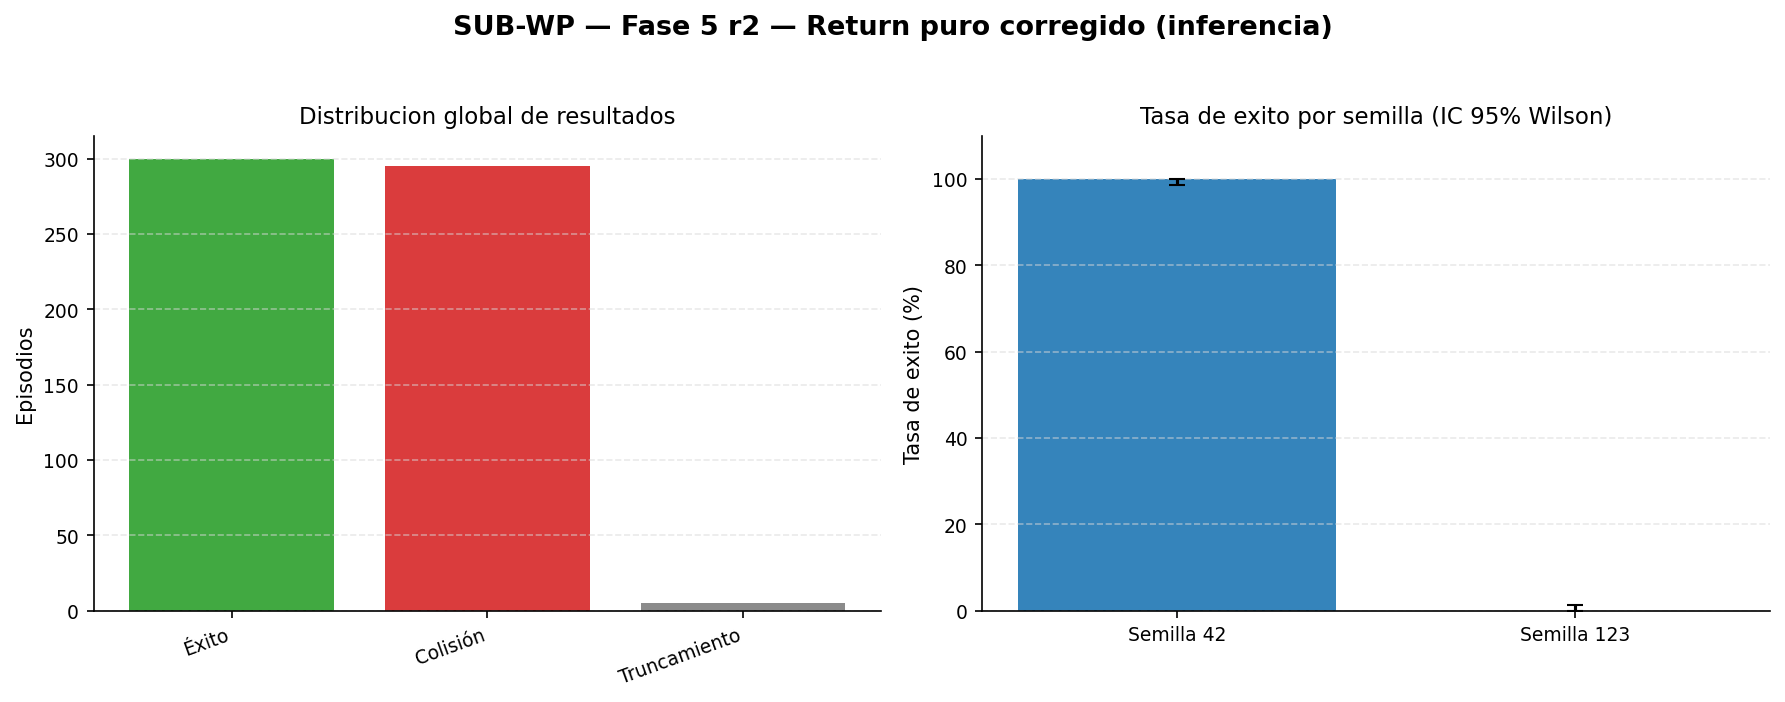

  [nota] Esta fase no registra goal_id por episodio: no se generan graficas por objetivo.


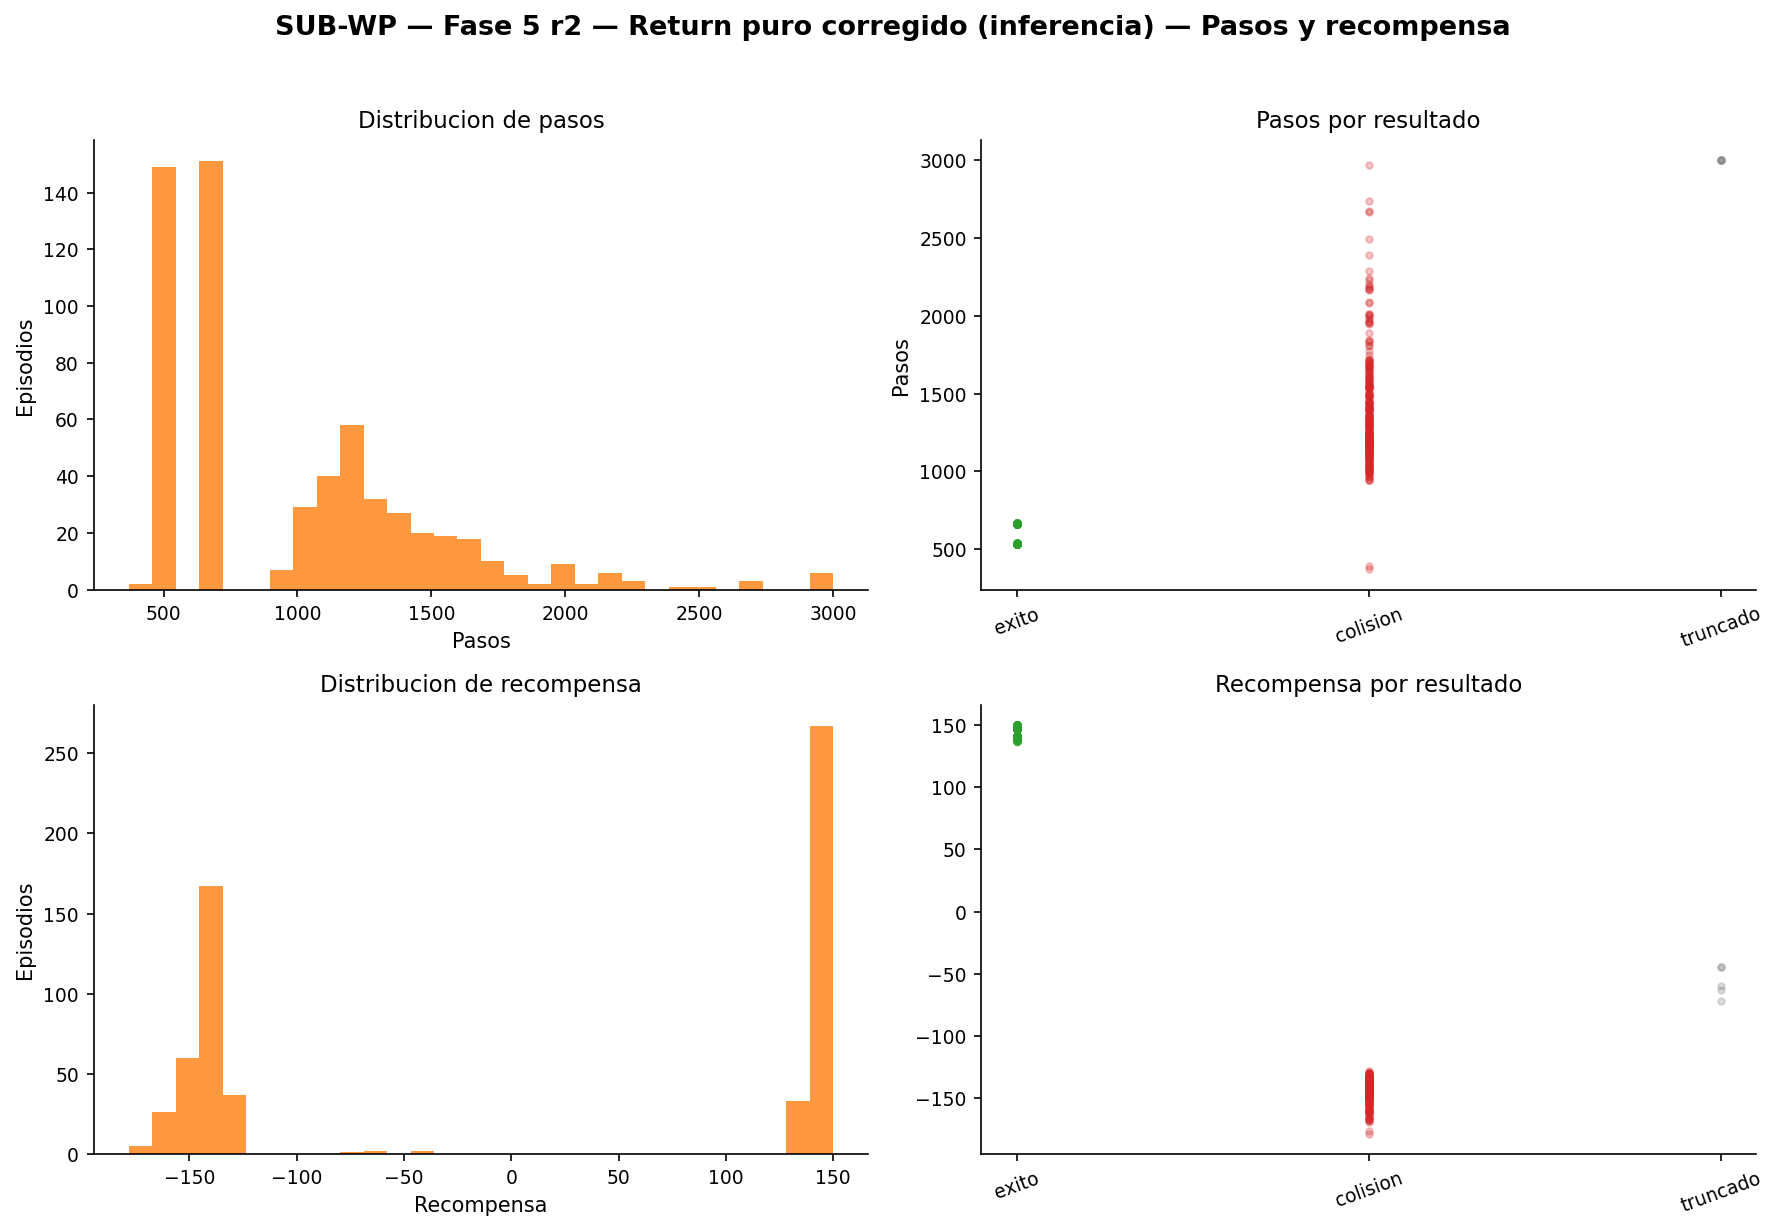

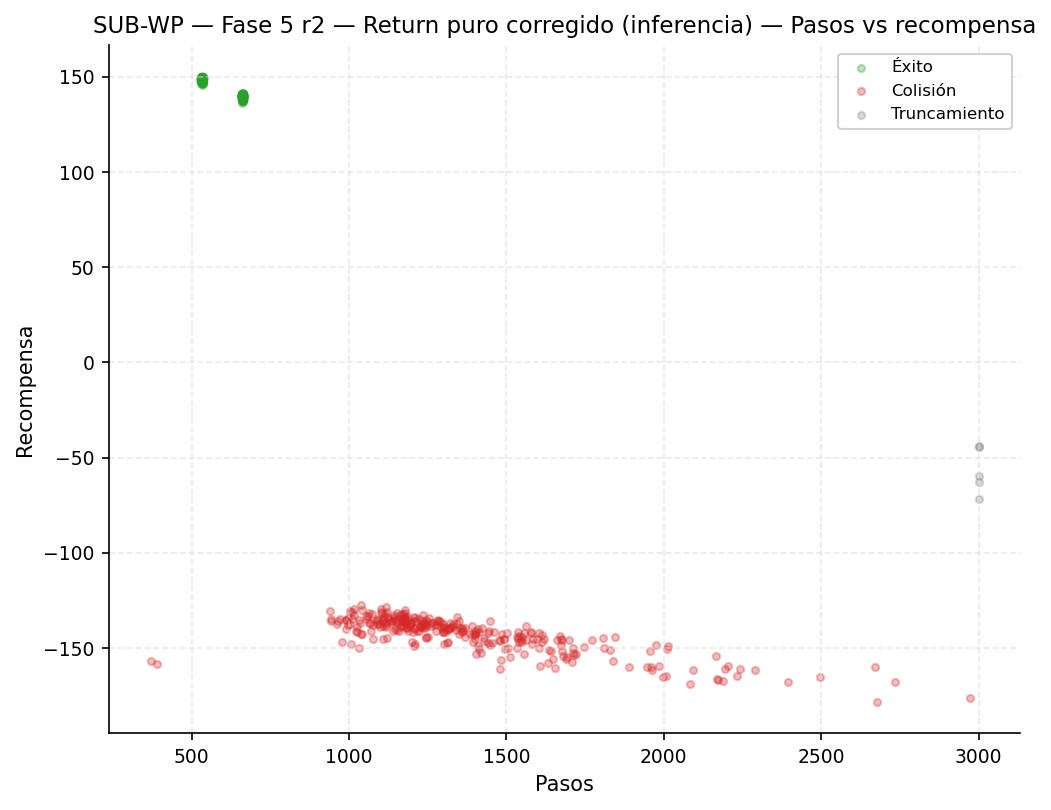

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,600,2,300,295,5,50.0,46.01,53.99,49.17,45.18,53.16,0.83,1001.7,664.5,498.9,1.31,46.16,143.26,no registrada,no registrada


In [19]:
resumen_stage5_r2_subwp = analyze_phase(subwp_dfs["stage5_r2"], "SUB-WP — Fase 5 r2 — Return puro corregido (inferencia)", "fig_subwp_stage5_r2", ARCH_COLORS["SUB-WP"])
if not resumen_stage5_r2_subwp.empty:
    resumen_stage5_r2_subwp.to_csv(TABLES_DIR / "tabla_resumen_subwp_stage5_r2.csv", index=False)
    display(resumen_stage5_r2_subwp)

### E2.0 — Ciclo completo sin peaton (inferencia)

- **Tarea evaluada**: ciclo completo approach+exit+return, sin peaton
- **Peaton presente**: No
- **Observaciones de auditoria**: NO EXISTE una inferencia especifica del checkpoint E2.0 en el repositorio. El unico CSV con nombre 'ciclo' (infer_subwp_s{seed}_wp75_ciclo.csv) evalua un modelo PRE-r2 ('subwp_s{seed}_wp75_stage5_final', SIN el sufijo r2), no el checkpoint E2.0 -- se EXCLUYE por corresponder a una version anterior a la correccion r2. Tampoco se debe sustituir E2.0 por la inferencia de E2.1 sin peaton ('subwp_infer_e2_1_noped_*.csv'): esa evalua el checkpoint E2.1 (entrenado CON peaton) en un mundo sin peaton, no el checkpoint E2.0 (entrenado especificamente SIN peaton). Esta fase queda registrada como AUSENTE, de forma visible, en el manifiesto de inferencia; no se inventa un valor ni se copia el de otra fase.


In [20]:
print("[E2.0 — Ciclo completo sin peaton (inferencia)] SIN INFERENCIA DISPONIBLE — hueco de datos, ver Seccion 3. No se sustituye por otra fase ni por otro checkpoint.")
resumen_e2_0_subwp = pd.DataFrame()

[E2.0 — Ciclo completo sin peaton (inferencia)] SIN INFERENCIA DISPONIBLE — hueco de datos, ver Seccion 3. No se sustituye por otra fase ni por otro checkpoint.


## 8. E2.1, E2.2 y E2.2b de SUB-WP


### E2.1 — Con peaton (inferencia)

- **Tarea evaluada**: ciclo completo con peaton dinamico, observacion LIDAR realista
- **Peaton presente**: Si
- **Observaciones de auditoria**: Modelo evaluado: subwp_e2_1_s{seed}_final.


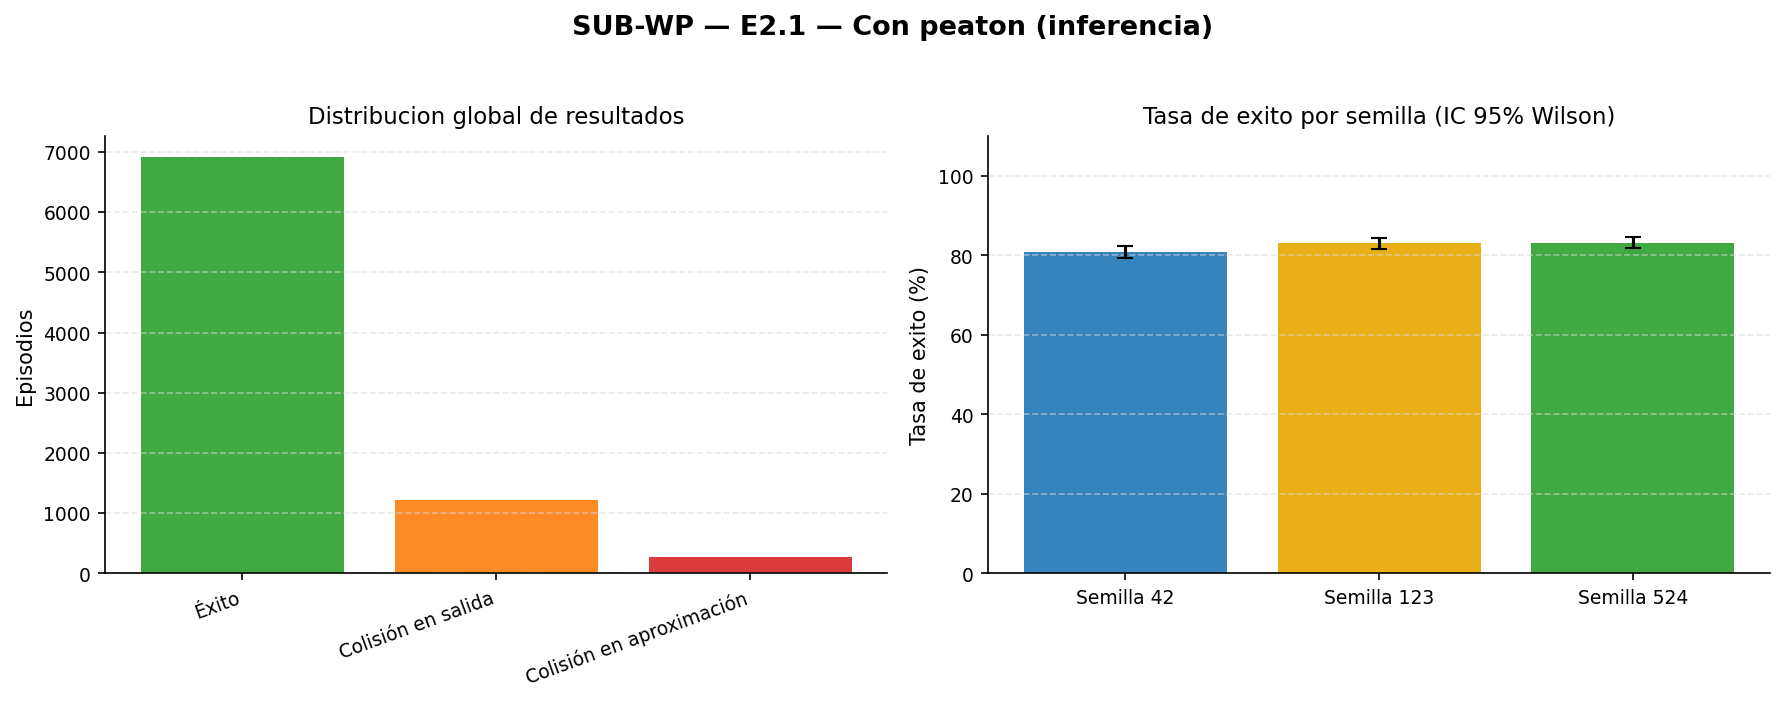

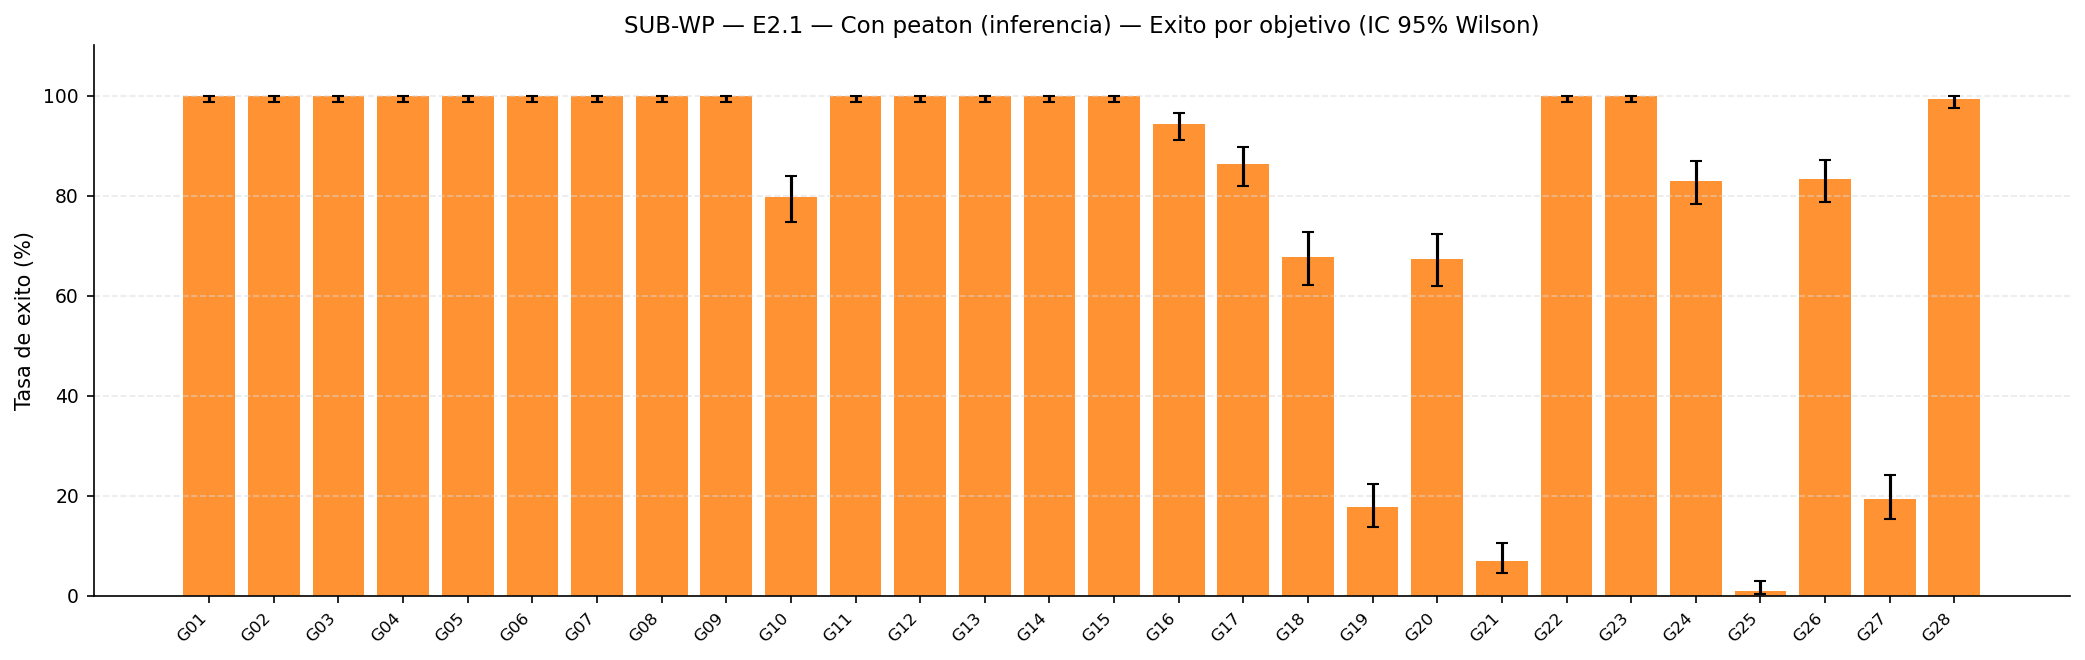

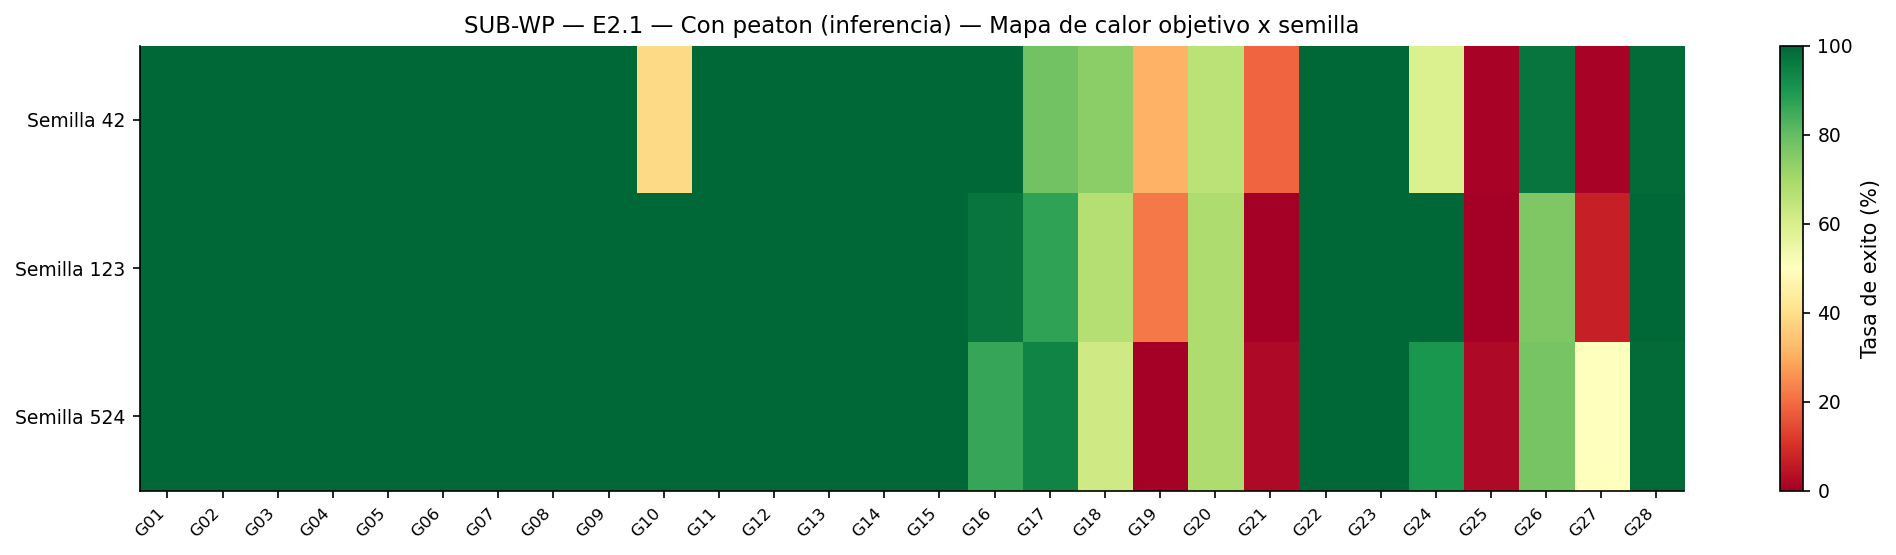

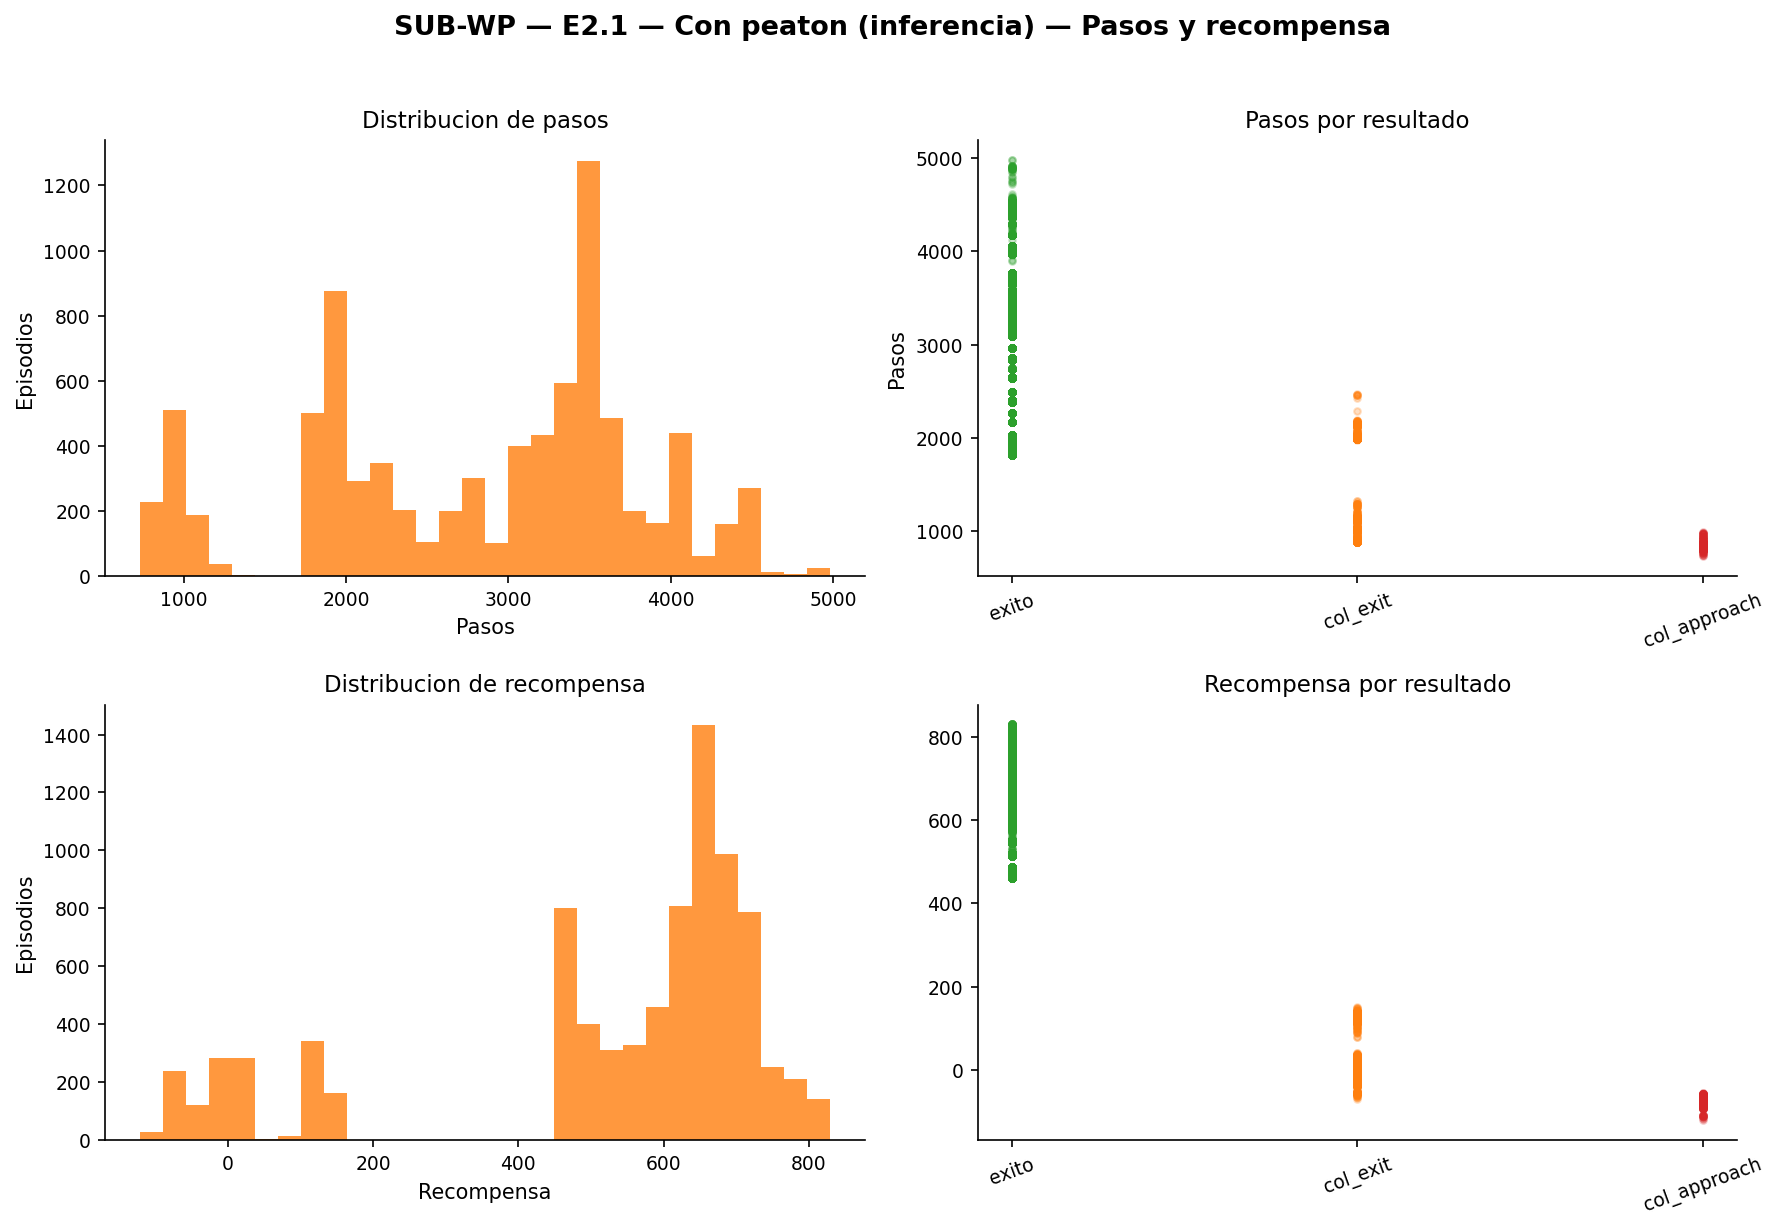

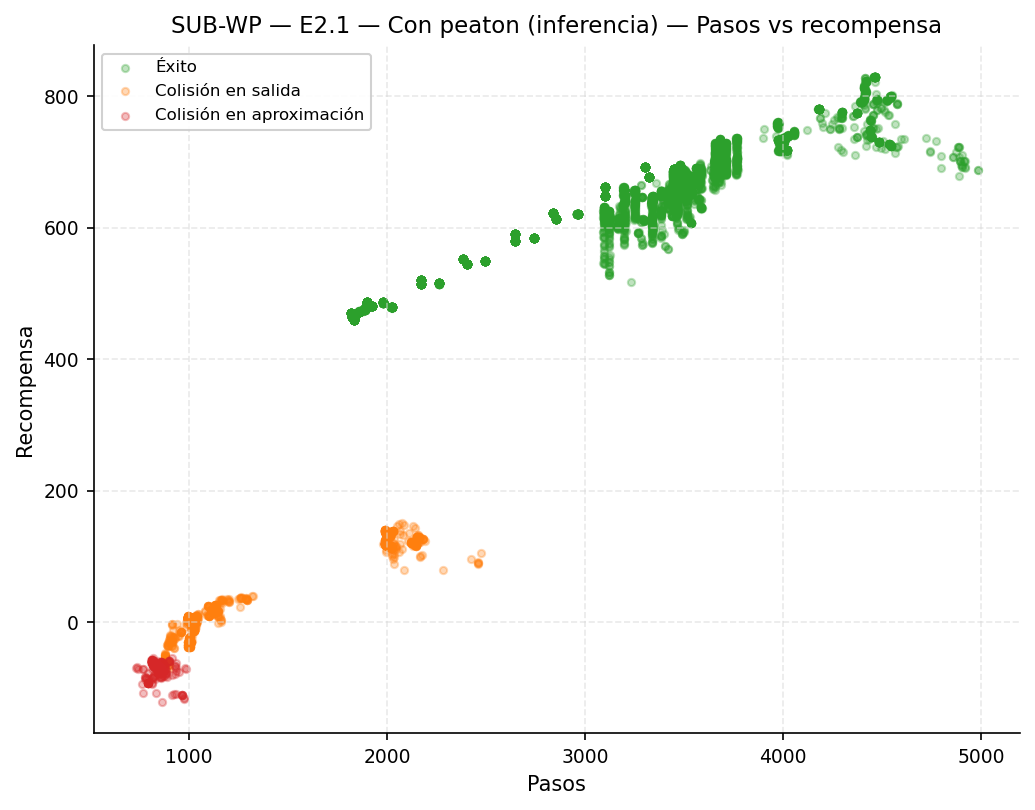

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_25': np.float64(1.0), 'goal_21': np.float64(7.0), 'goal_19': np.float64(17.7)}
  Mejores 3 objetivos: {'goal_02': np.float64(100.0), 'goal_15': np.float64(100.0), 'goal_14': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,6918,1482,0,82.36,81.53,83.16,17.64,16.84,18.47,0.0,2815.4,3120.0,999.8,521.83,621.52,244.91,no registrada,no registrada


In [21]:
resumen_subwp_e2_1_subwp = analyze_phase(subwp_dfs["subwp_e2_1"], "SUB-WP — E2.1 — Con peaton (inferencia)", "fig_subwp_subwp_e2_1", ARCH_COLORS["SUB-WP"])
if not resumen_subwp_e2_1_subwp.empty:
    resumen_subwp_e2_1_subwp.to_csv(TABLES_DIR / "tabla_resumen_subwp_subwp_e2_1.csv", index=False)
    display(resumen_subwp_e2_1_subwp)

### E2.1 — Sin peaton, control (inferencia)

- **Tarea evaluada**: ciclo completo, MISMO modelo E2.1 pero evaluado en un mundo sin peaton (control)
- **Peaton presente**: No
- **Observaciones de auditoria**: Mismo checkpoint E2.1, condicion de control sin peaton. No sustituye a E2.0 (ver arriba).


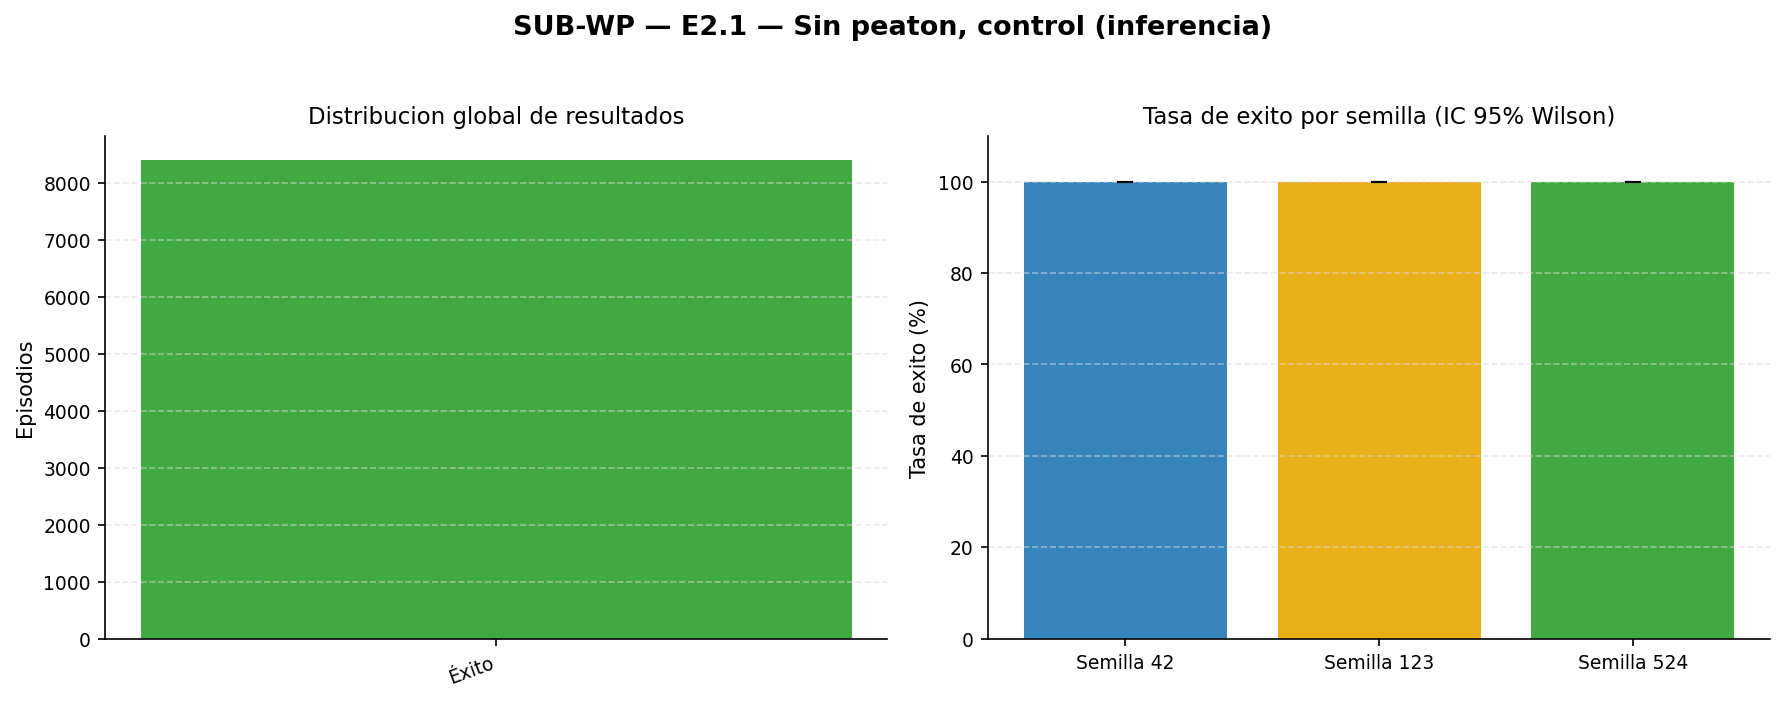

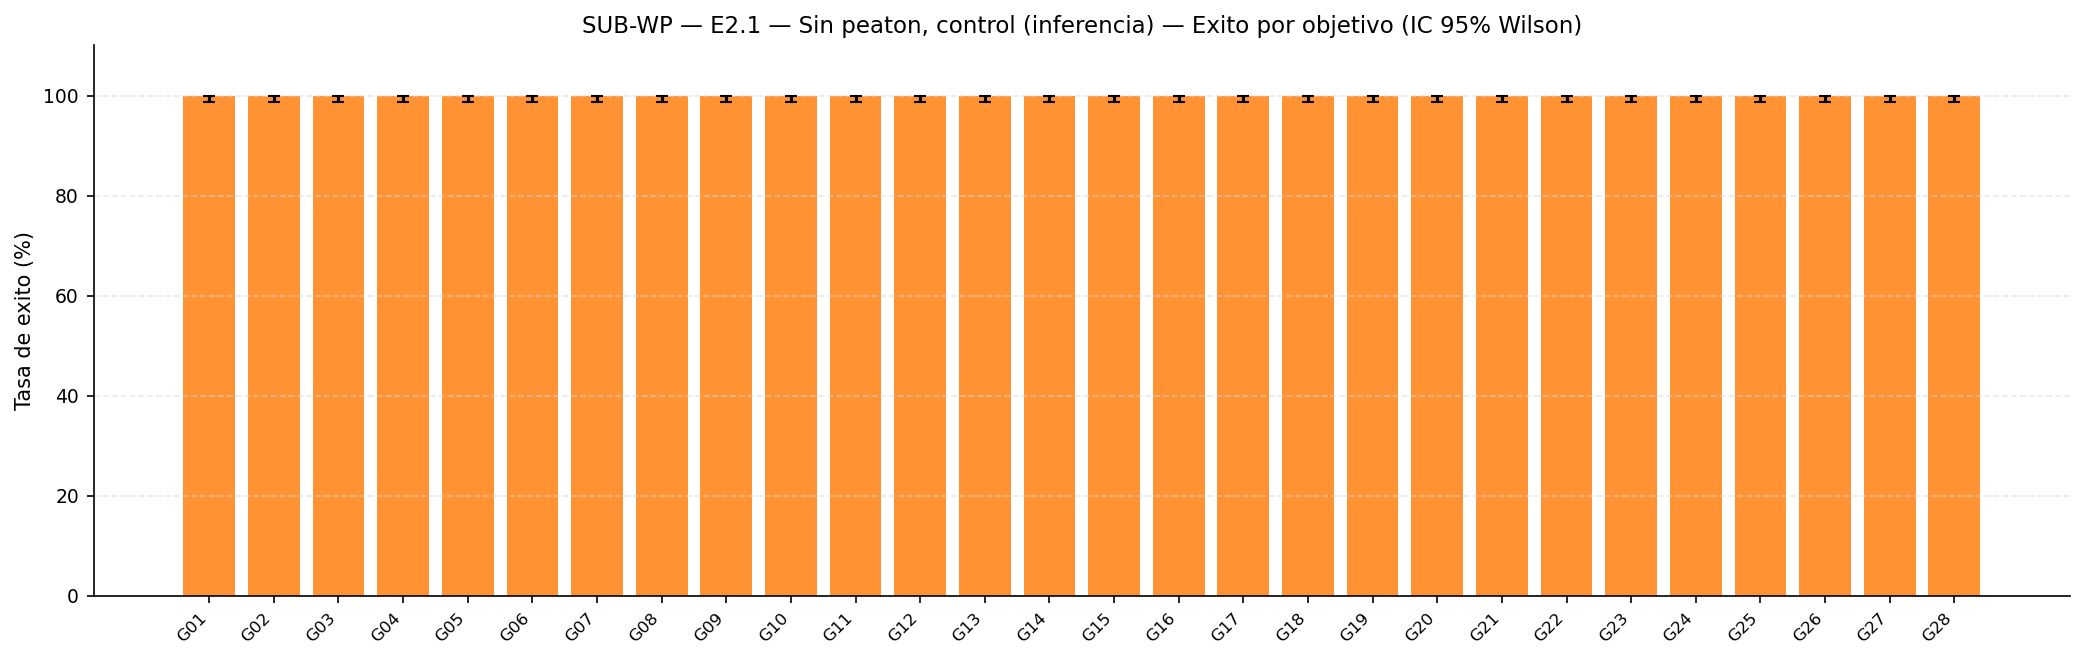

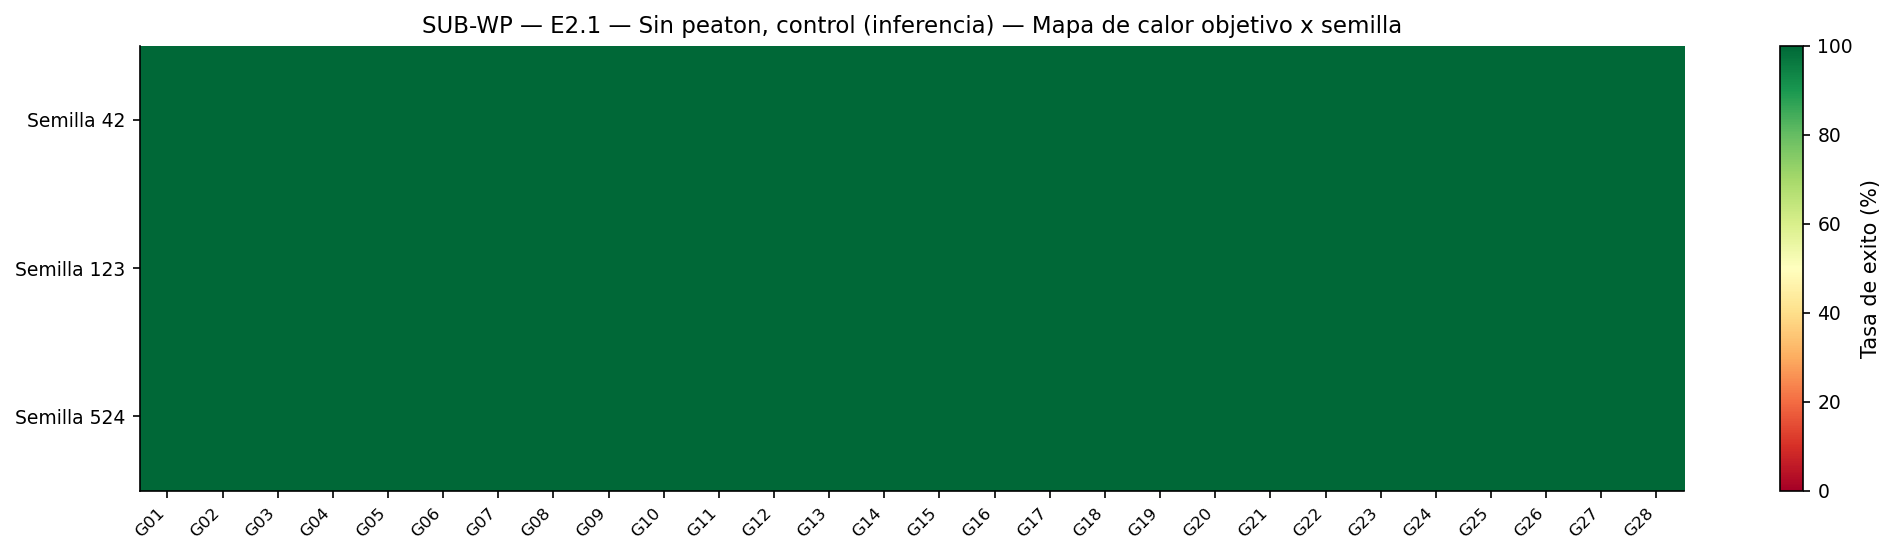

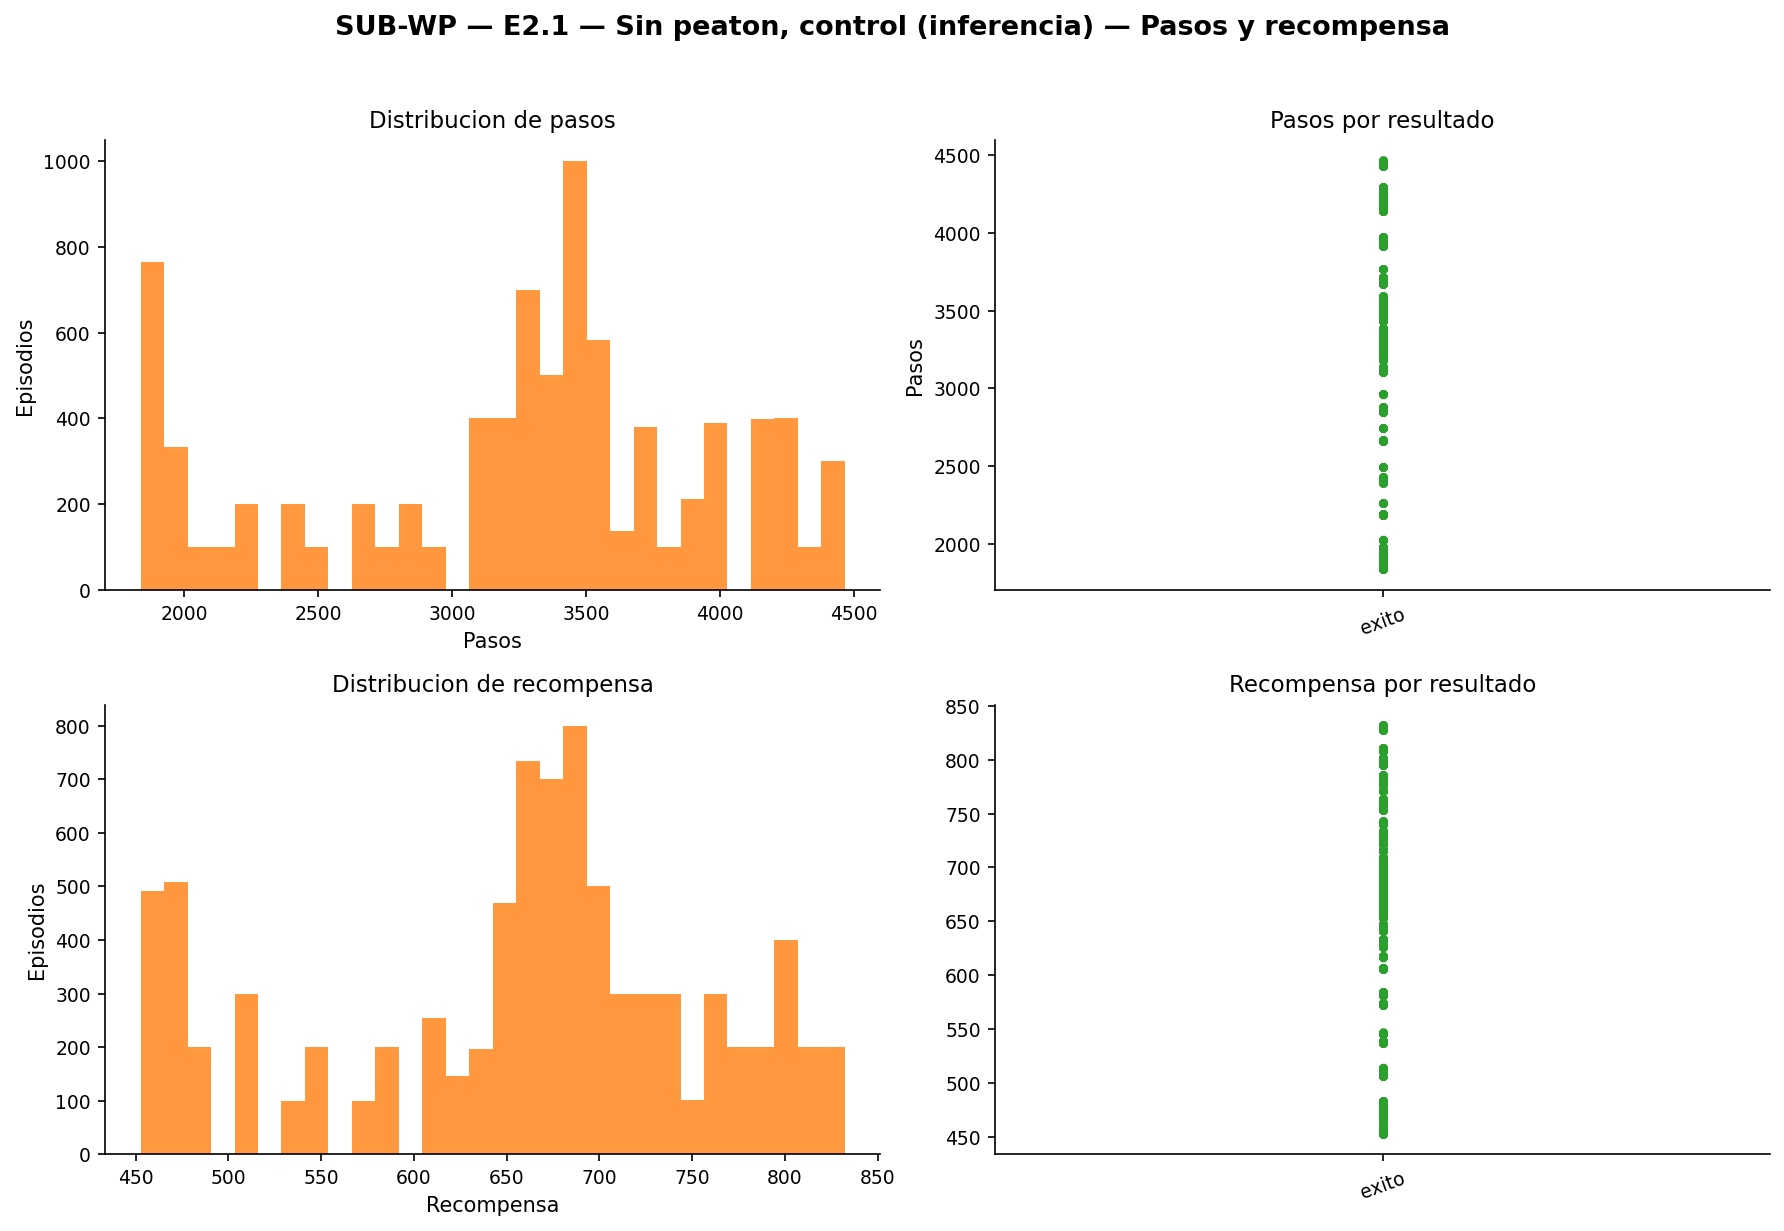

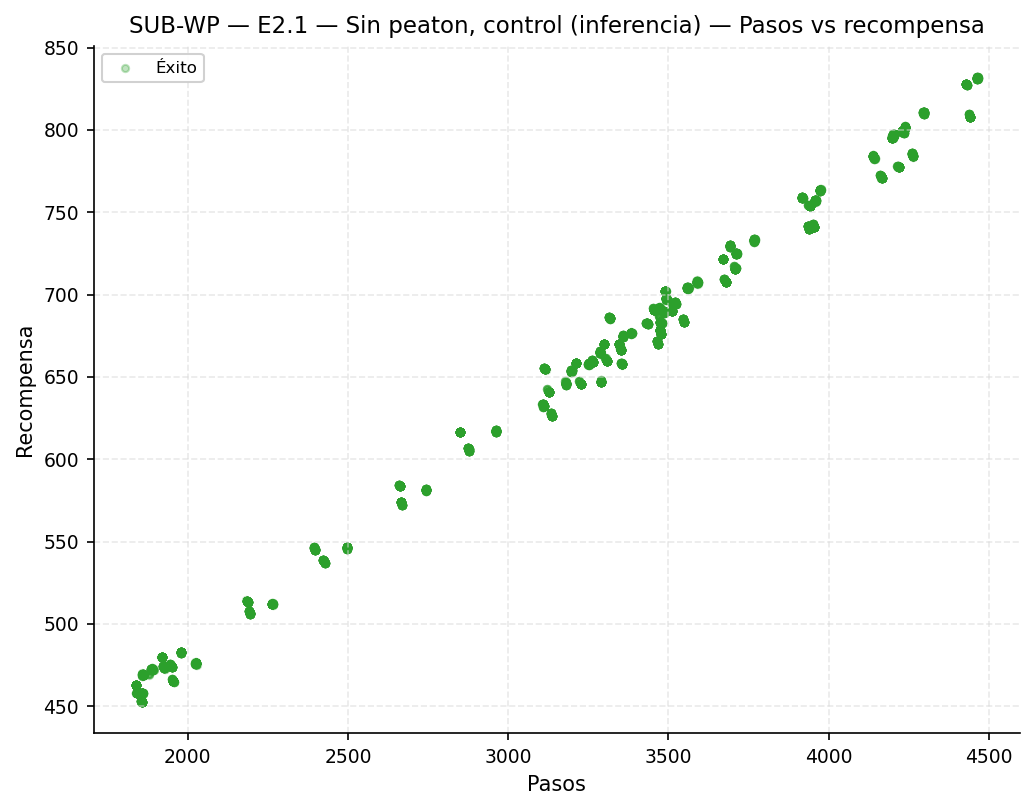

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_01': np.float64(100.0), 'goal_26': np.float64(100.0), 'goal_25': np.float64(100.0)}
  Mejores 3 objetivos: {'goal_02': np.float64(100.0), 'goal_27': np.float64(100.0), 'goal_28': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,8400,0,0,100.0,99.95,100.0,0.0,0.0,0.05,0.0,3236.5,3357.0,741.9,654.68,672.99,103.66,no registrada,no registrada


In [22]:
resumen_subwp_e2_1_noped_subwp = analyze_phase(subwp_dfs["subwp_e2_1_noped"], "SUB-WP — E2.1 — Sin peaton, control (inferencia)", "fig_subwp_subwp_e2_1_noped", ARCH_COLORS["SUB-WP"])
if not resumen_subwp_e2_1_noped_subwp.empty:
    resumen_subwp_e2_1_noped_subwp.to_csv(TABLES_DIR / "tabla_resumen_subwp_subwp_e2_1_noped.csv", index=False)
    display(resumen_subwp_e2_1_noped_subwp)

### E2.2 — Replanning LIDAR (inferencia)

- **Tarea evaluada**: ciclo completo con peaton + replanning LIDAR [1.5,4.5]m
- **Peaton presente**: Si
- **Observaciones de auditoria**: Modelo evaluado: subwp_e2_2_s{seed}_final.


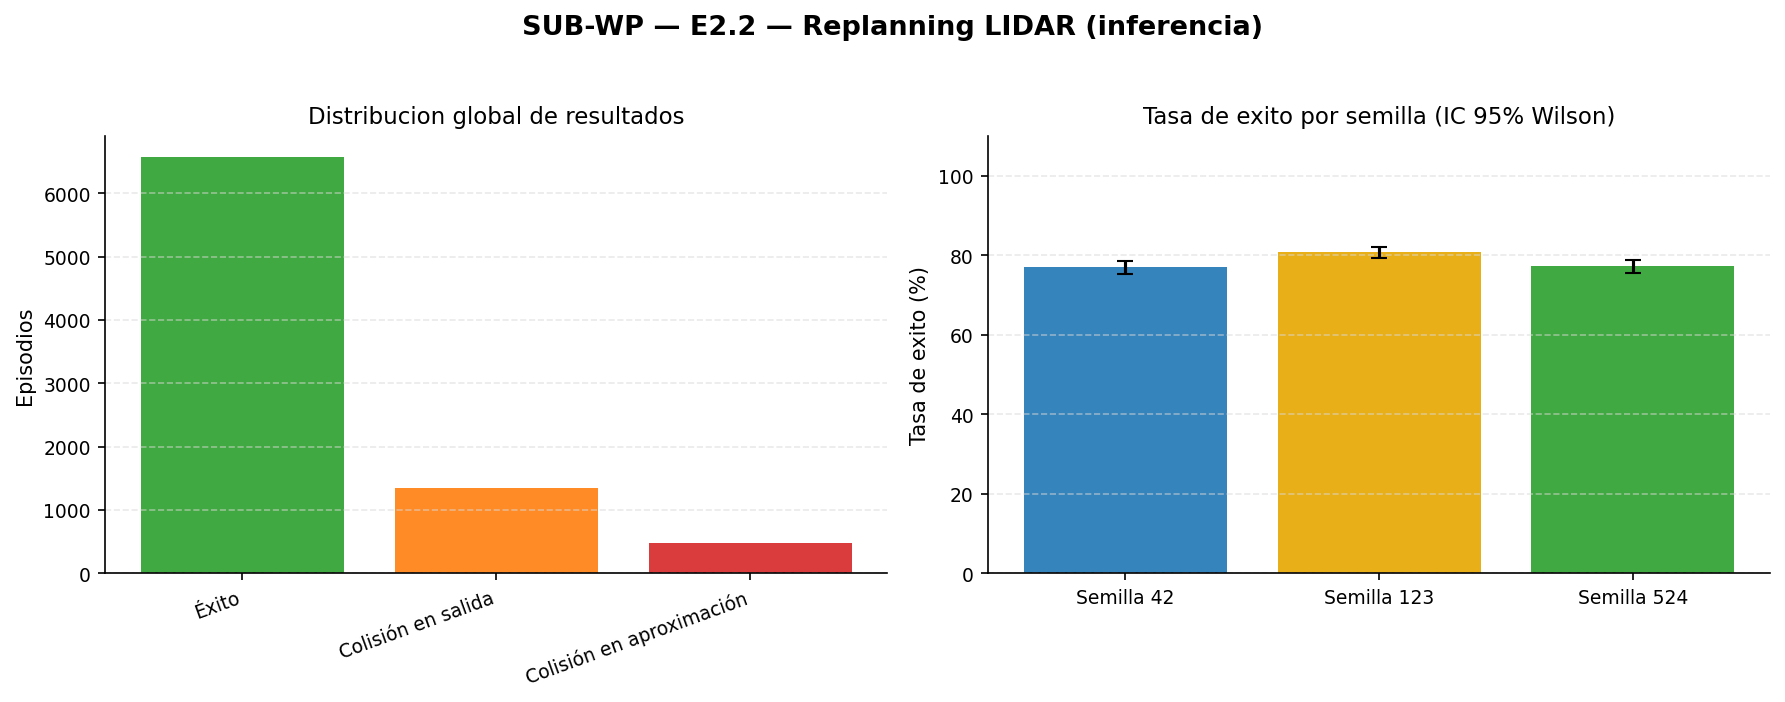

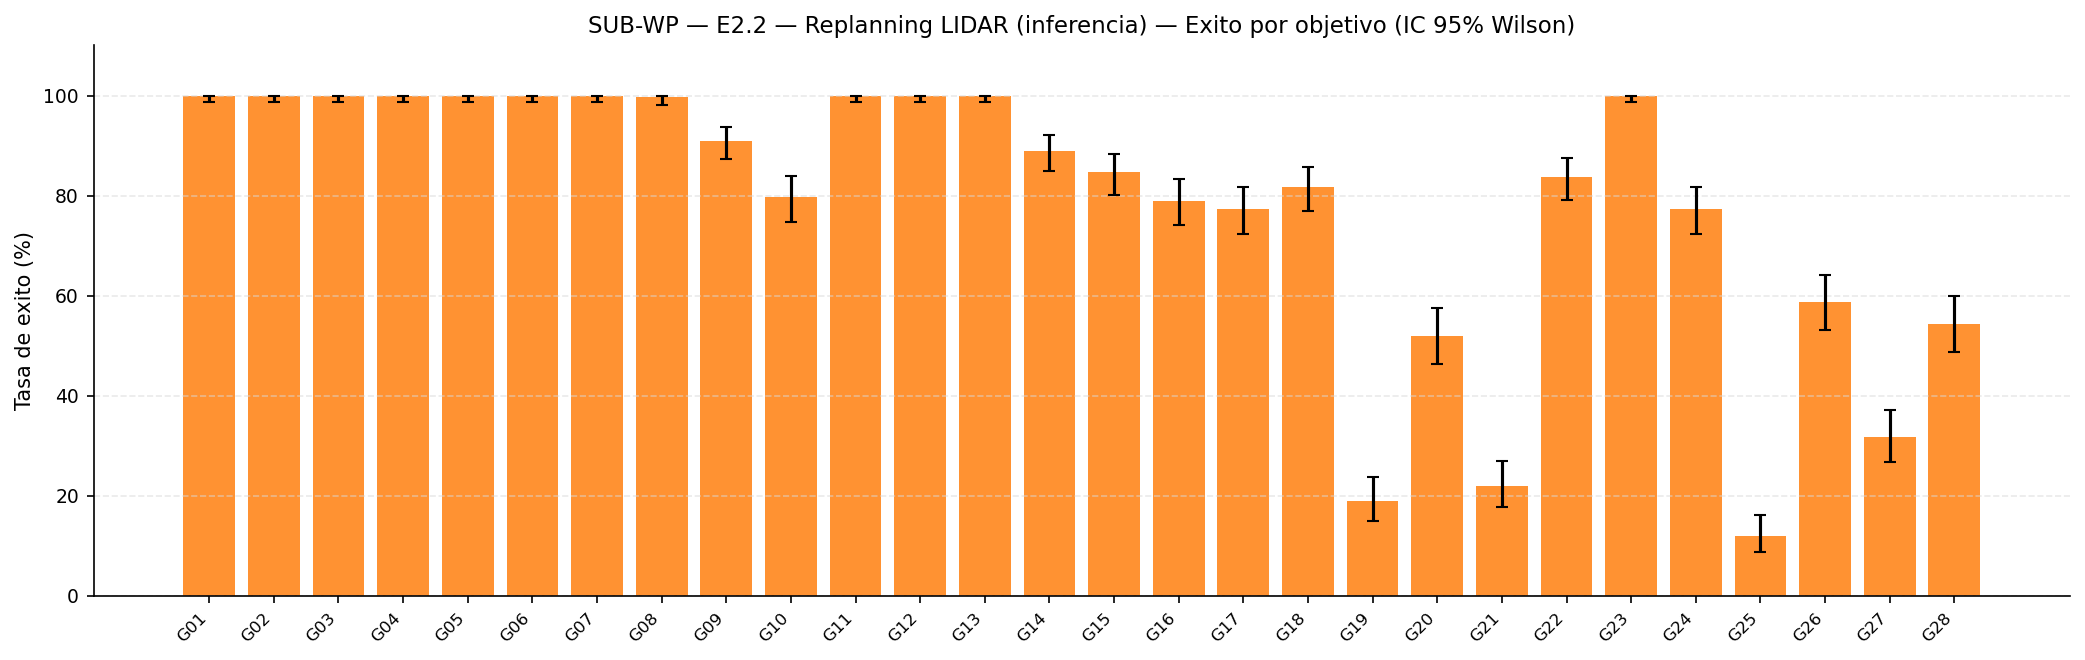

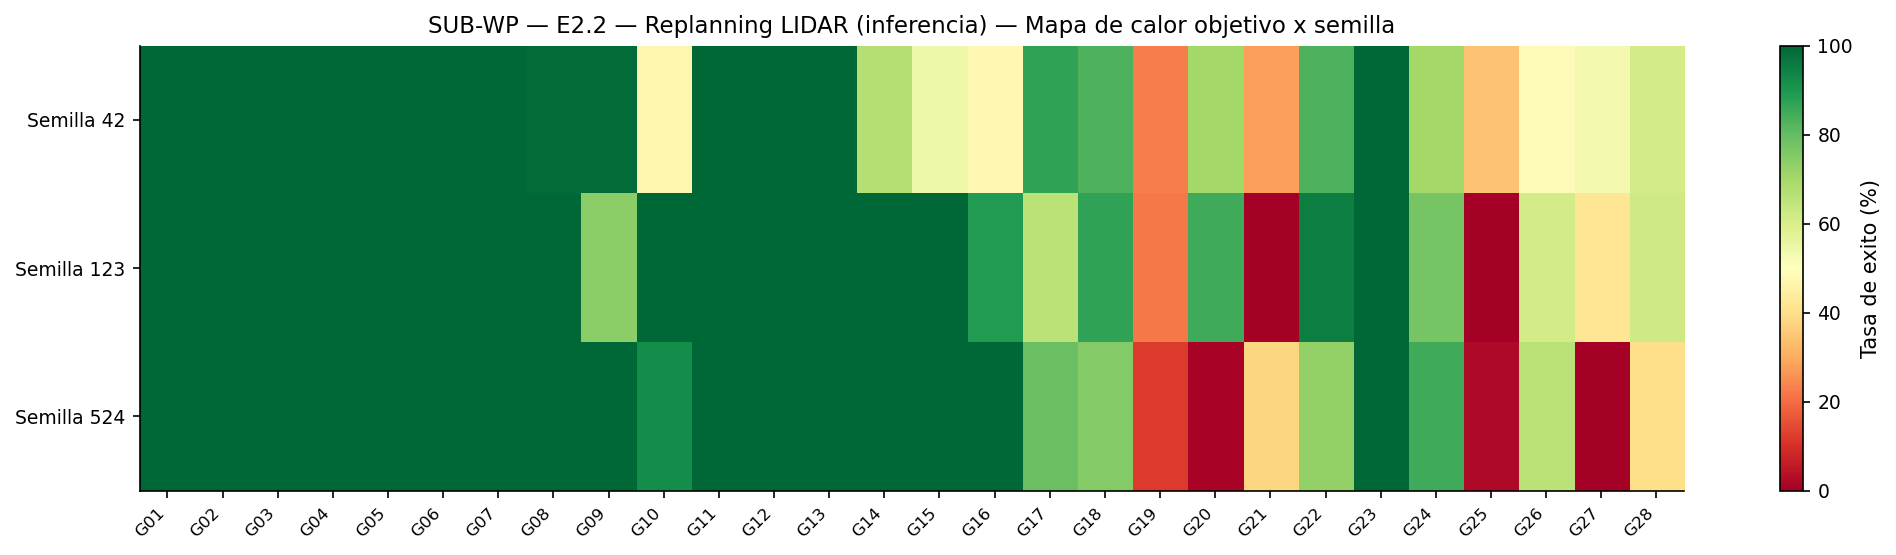

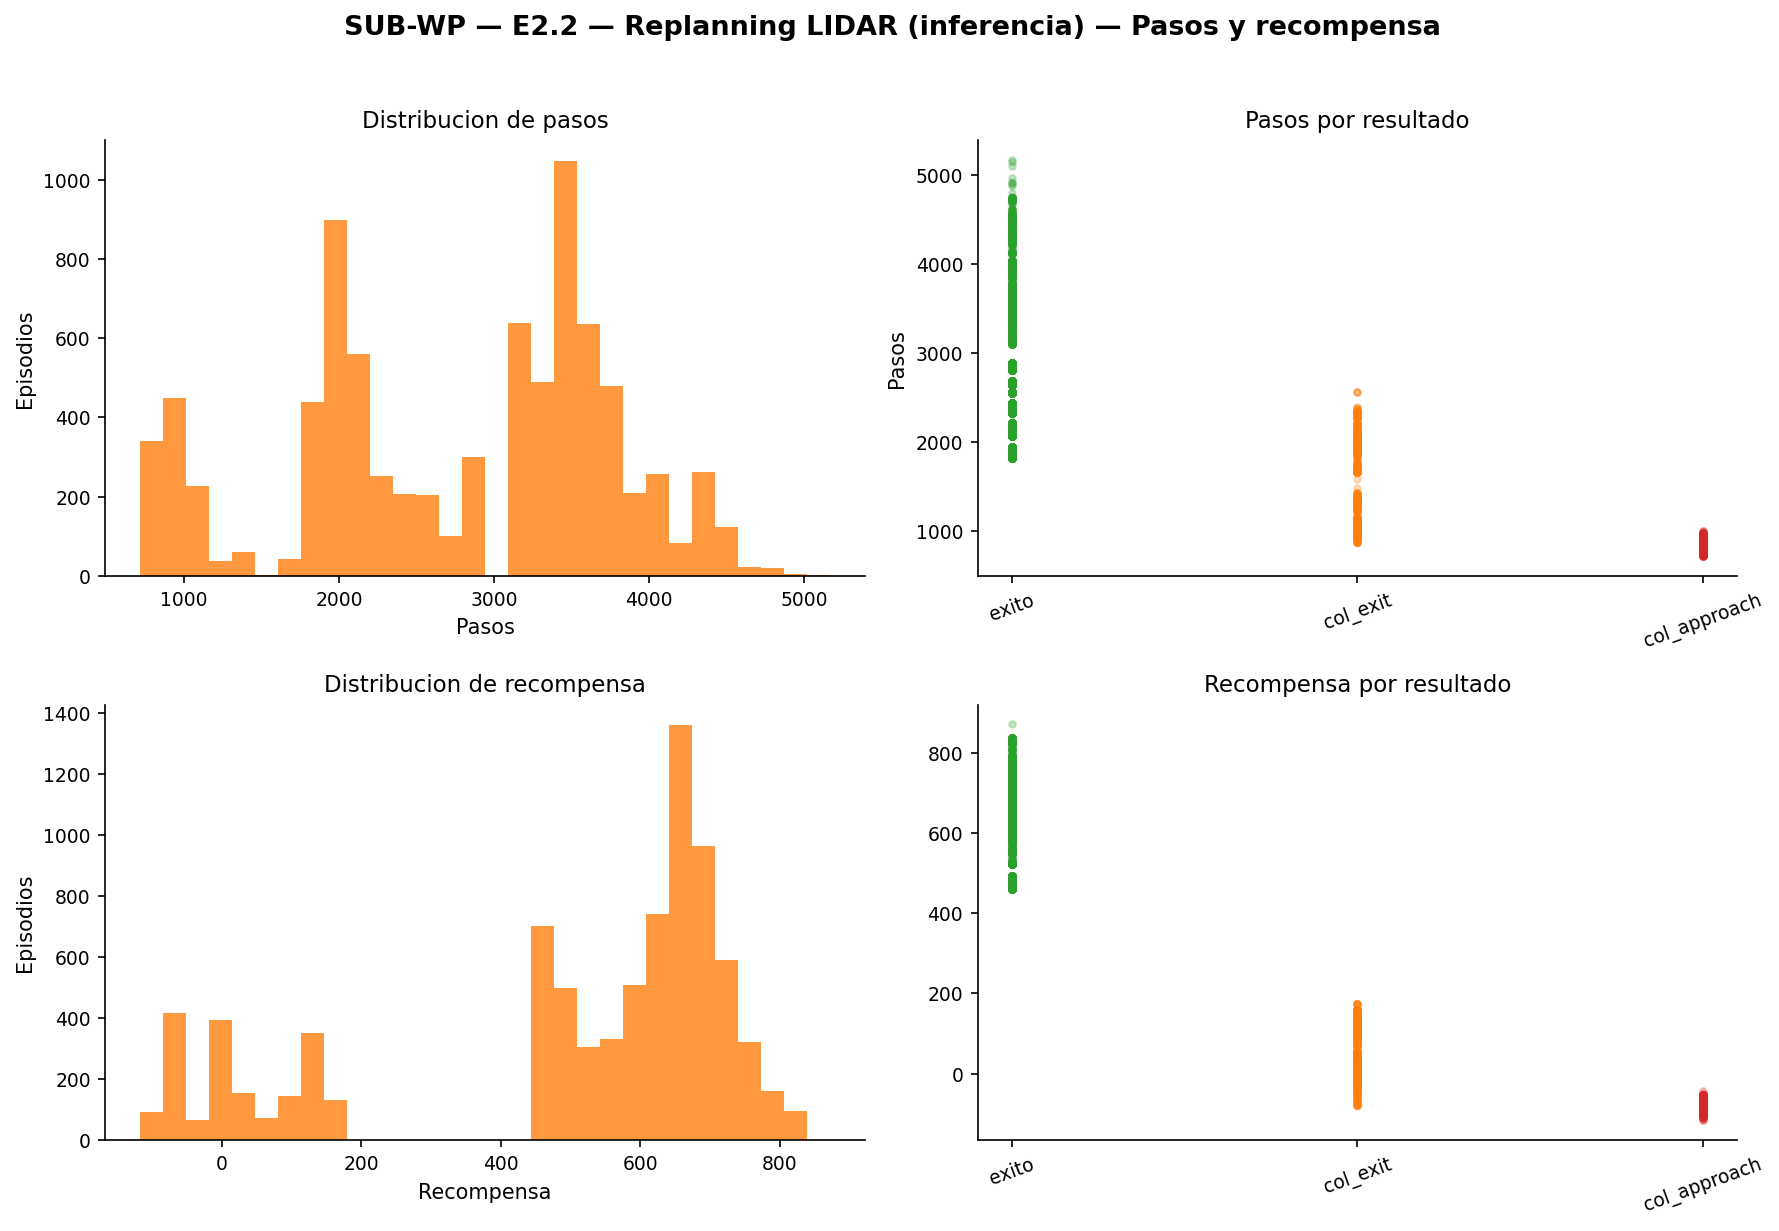

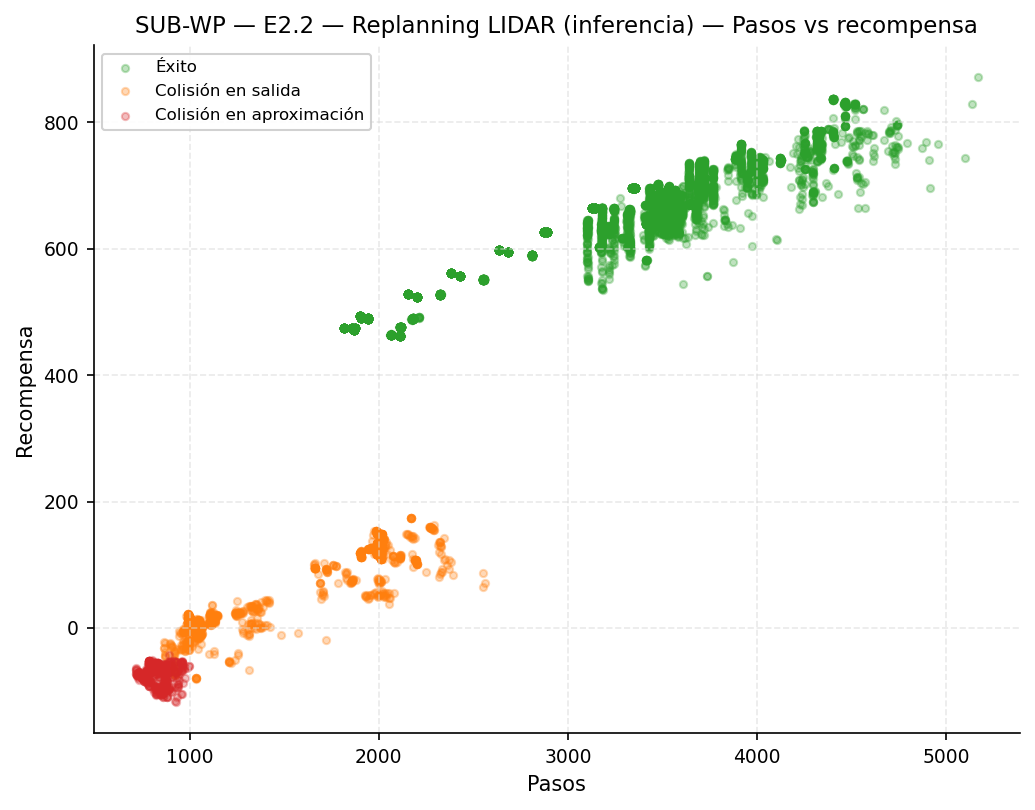

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_25': np.float64(12.0), 'goal_19': np.float64(19.0), 'goal_21': np.float64(22.0)}
  Mejores 3 objetivos: {'goal_02': np.float64(100.0), 'goal_13': np.float64(100.0), 'goal_01': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,6578,1822,0,78.31,77.42,79.18,21.69,20.82,22.58,0.0,2754.9,3105.0,1018.9,497.92,614.4,263.44,no registrada,no registrada


In [23]:
resumen_subwp_e2_2_subwp = analyze_phase(subwp_dfs["subwp_e2_2"], "SUB-WP — E2.2 — Replanning LIDAR (inferencia)", "fig_subwp_subwp_e2_2", ARCH_COLORS["SUB-WP"])
if not resumen_subwp_e2_2_subwp.empty:
    resumen_subwp_e2_2_subwp.to_csv(TABLES_DIR / "tabla_resumen_subwp_subwp_e2_2.csv", index=False)
    display(resumen_subwp_e2_2_subwp)

### E2.2b — Replanning LIDAR corregido (inferencia)

- **Tarea evaluada**: ciclo completo con peaton + replanning LIDAR [2.5,4.5]m
- **Peaton presente**: Si
- **Observaciones de auditoria**: Modelo evaluado: subwp_e2_2b_s{seed}_final.


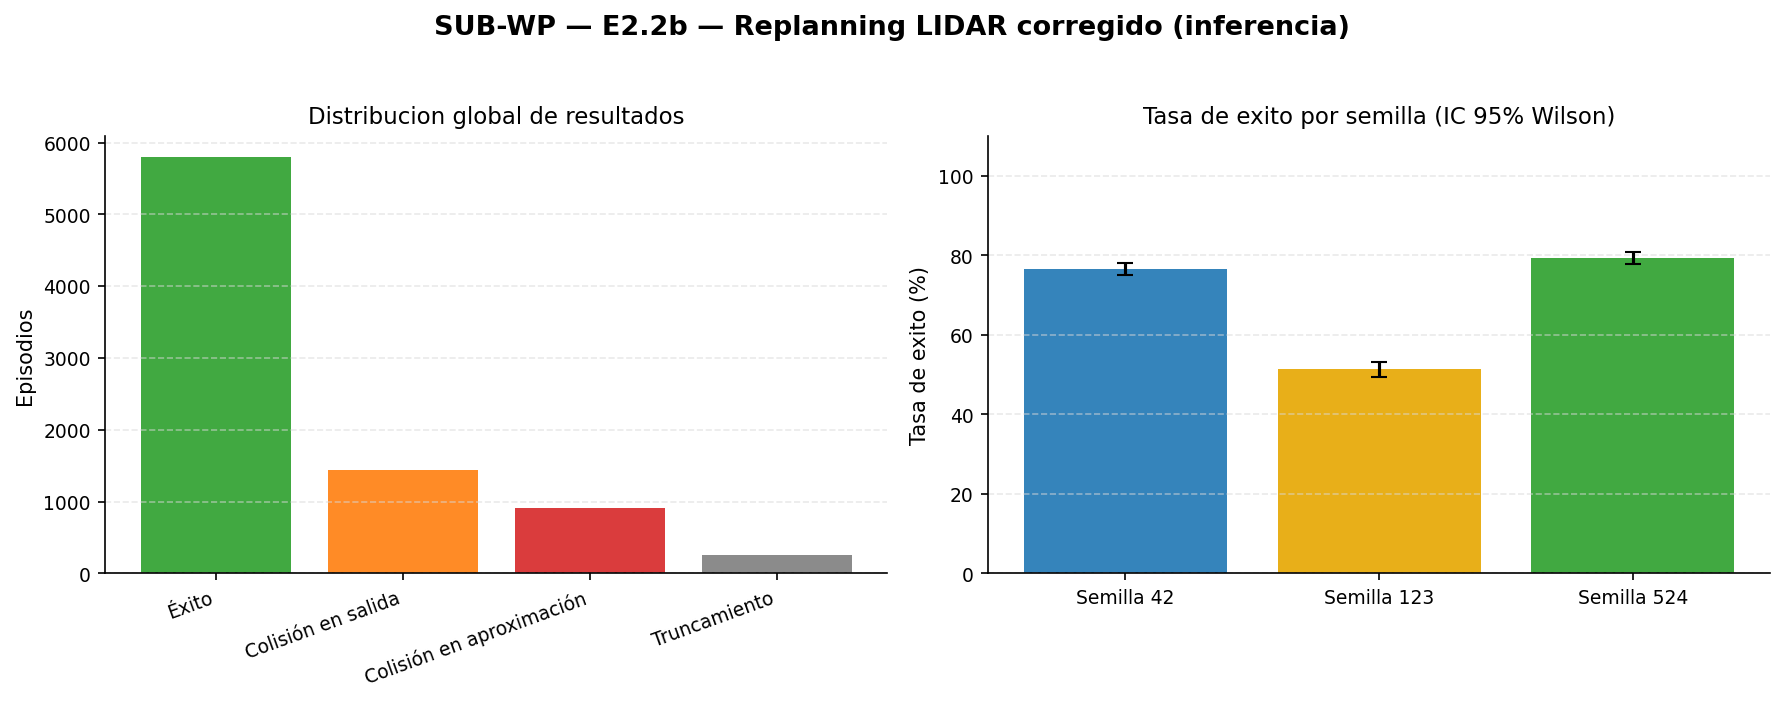

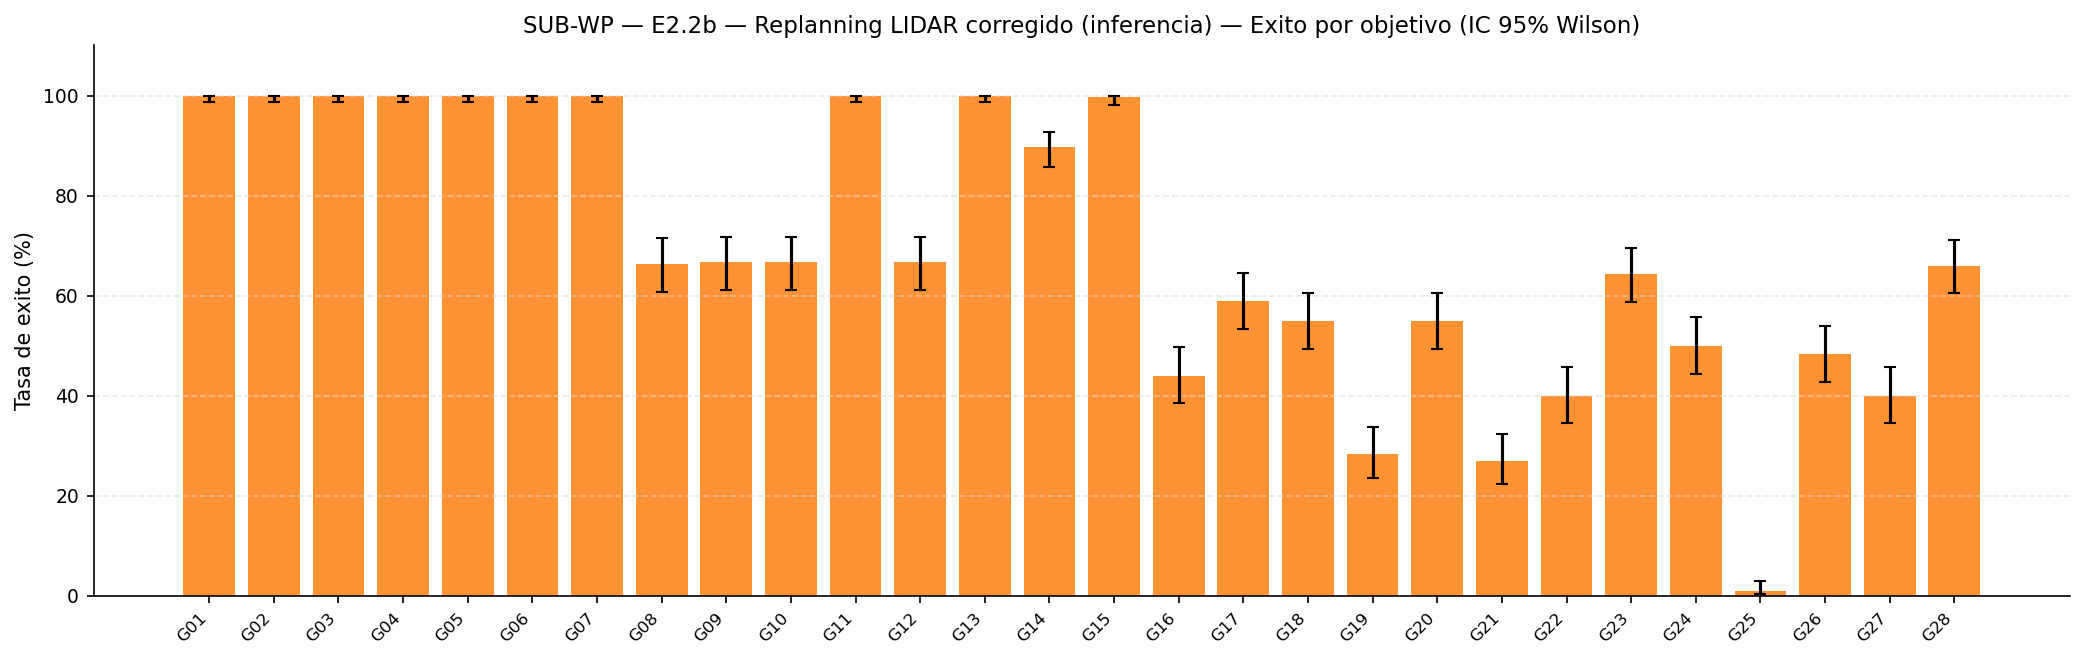

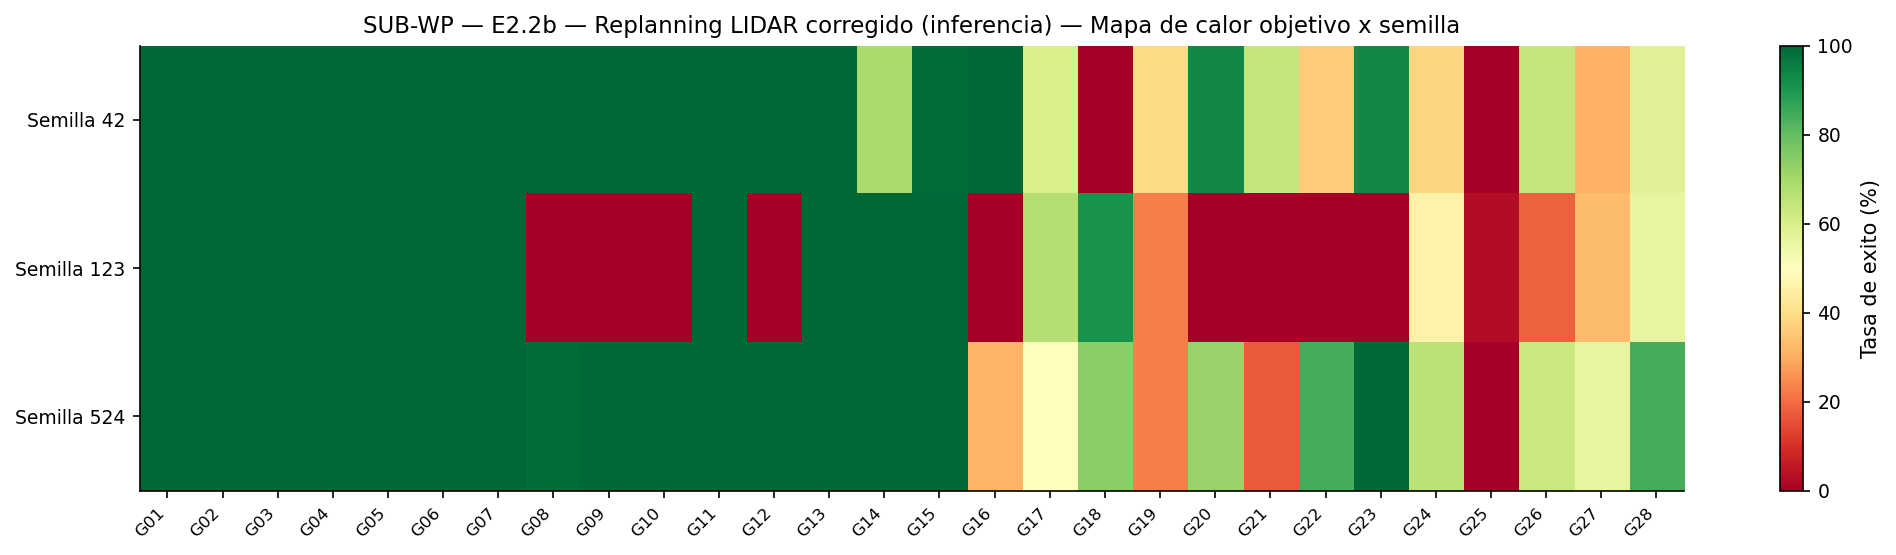

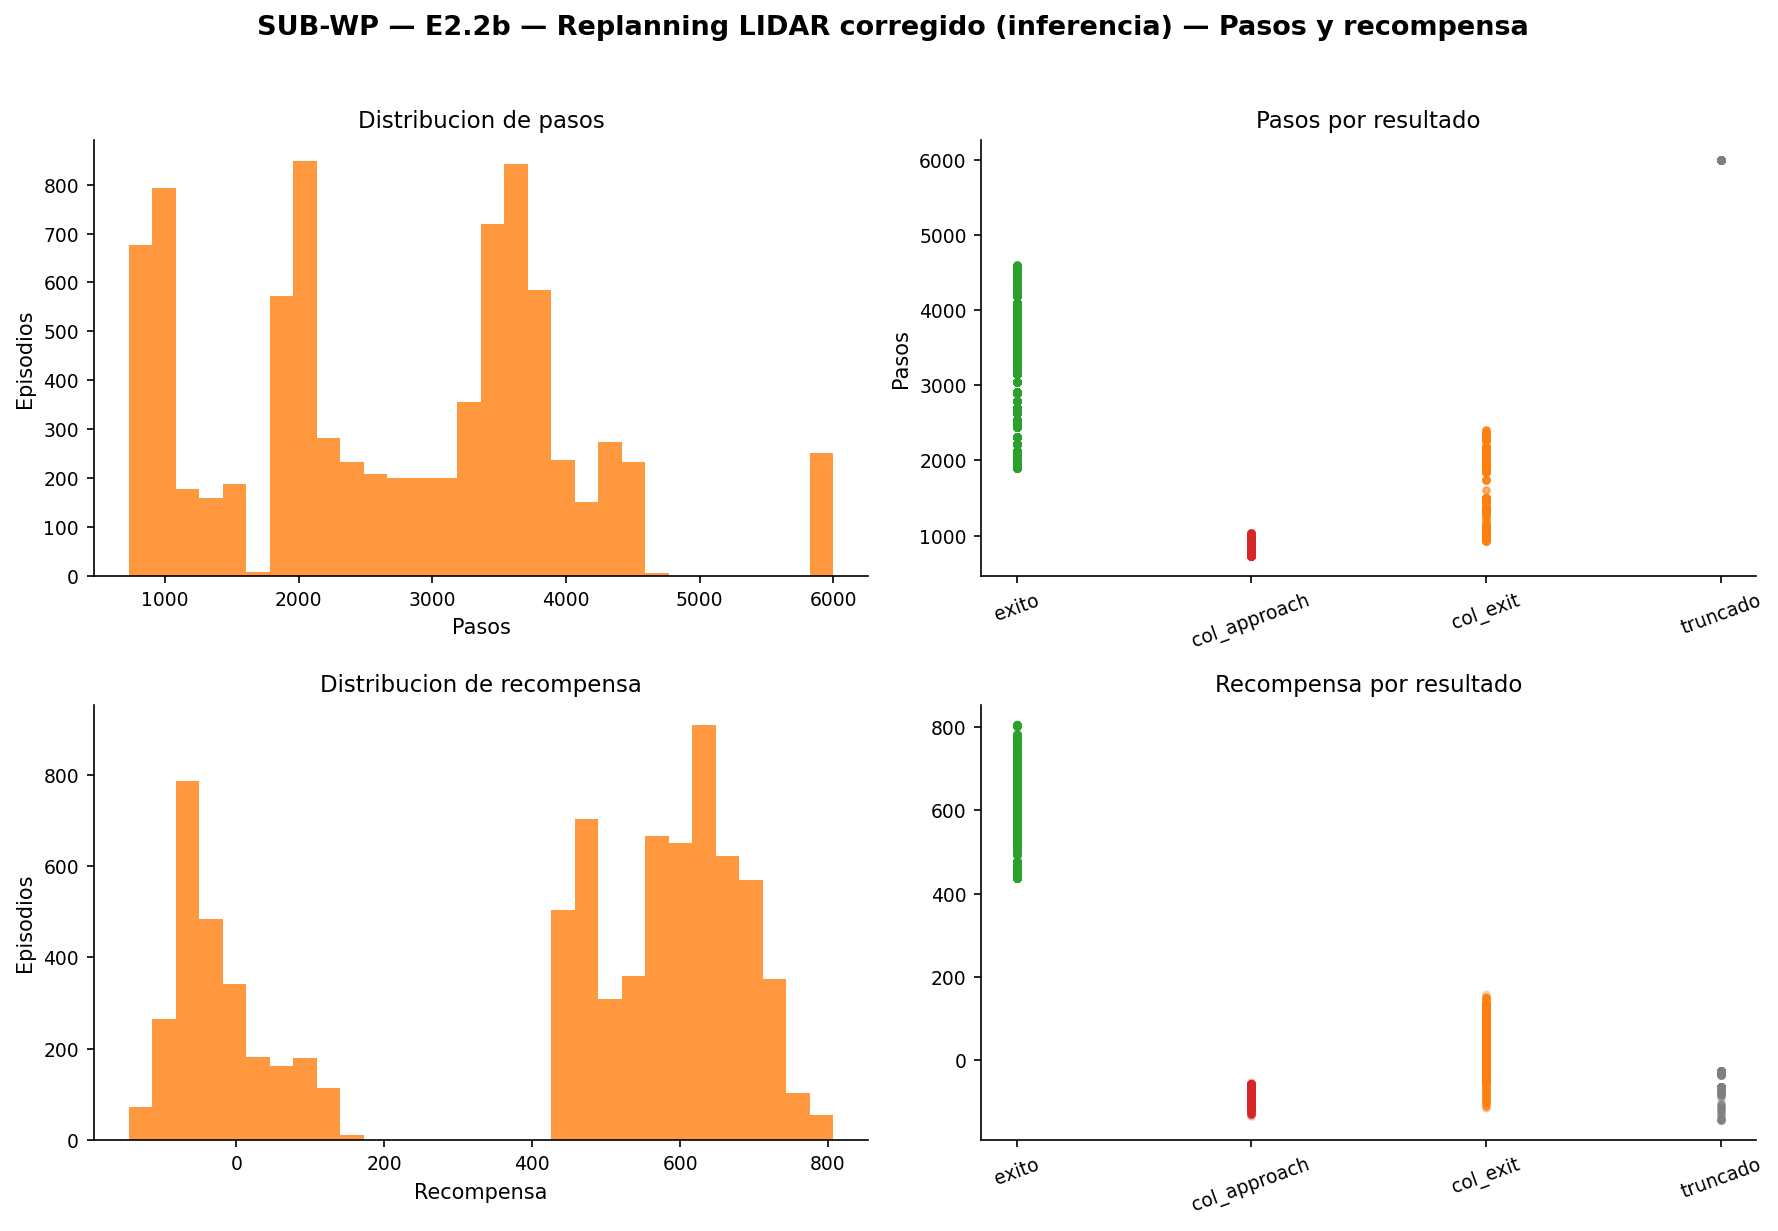

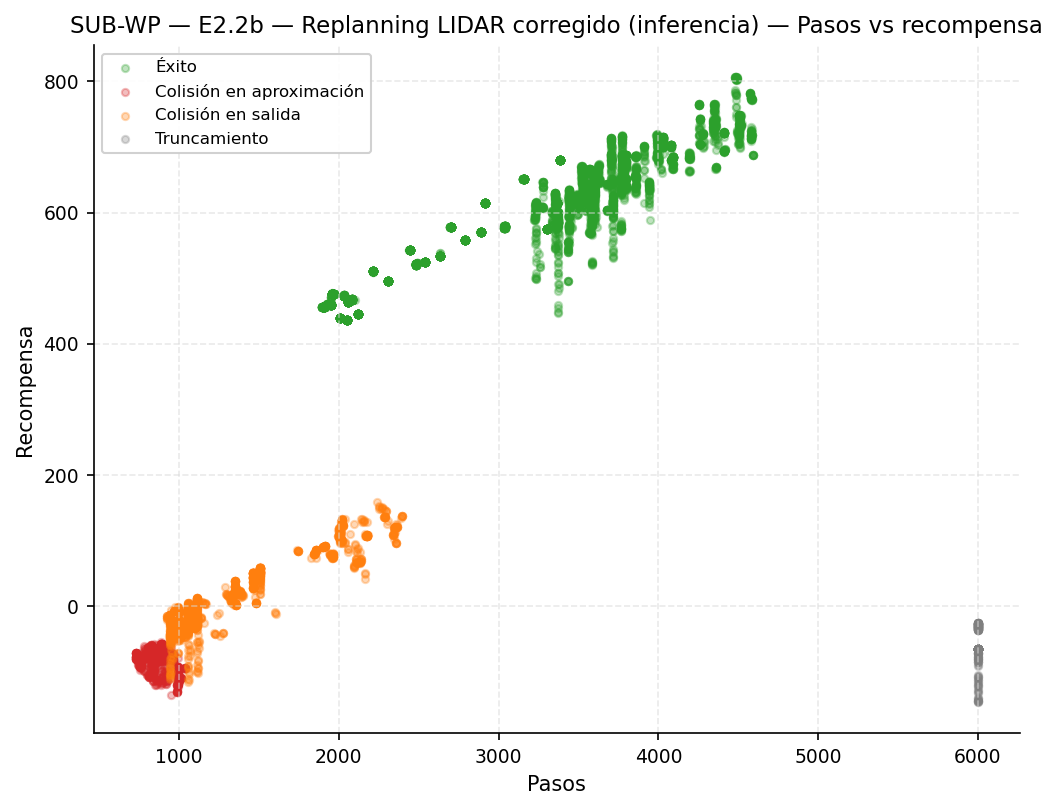

  [nota] No hay columnas de llegada a estanteria/entrega en esta fase: no se genera grafica de hitos.
  Peores 3 objetivos: {'goal_25': np.float64(1.0), 'goal_21': np.float64(27.0), 'goal_19': np.float64(28.3)}
  Mejores 3 objetivos: {'goal_03': np.float64(100.0), 'goal_02': np.float64(100.0), 'goal_01': np.float64(100.0)}


,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,ic95_colision_lo,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,8400,3,5801,2348,251,69.06,68.06,70.04,27.95,27.0,28.92,2.99,2691.9,2700.0,1262.5,402.3,524.9,296.32,no registrada,no registrada


In [24]:
resumen_subwp_e2_2b_subwp = analyze_phase(subwp_dfs["subwp_e2_2b"], "SUB-WP — E2.2b — Replanning LIDAR corregido (inferencia)", "fig_subwp_subwp_e2_2b", ARCH_COLORS["SUB-WP"])
if not resumen_subwp_e2_2b_subwp.empty:
    resumen_subwp_e2_2b_subwp.to_csv(TABLES_DIR / "tabla_resumen_subwp_subwp_e2_2b.csv", index=False)
    display(resumen_subwp_e2_2b_subwp)

---
## 9. Evolucion progresiva por arquitectura

Como las fases evaluan tareas distintas, se usa una vista de puntos con intervalos (Wilson 95%) por fase
en vez de una unica linea continua, que sugeriria una comparabilidad directa inexistente entre tareas de
dificultad diferente.

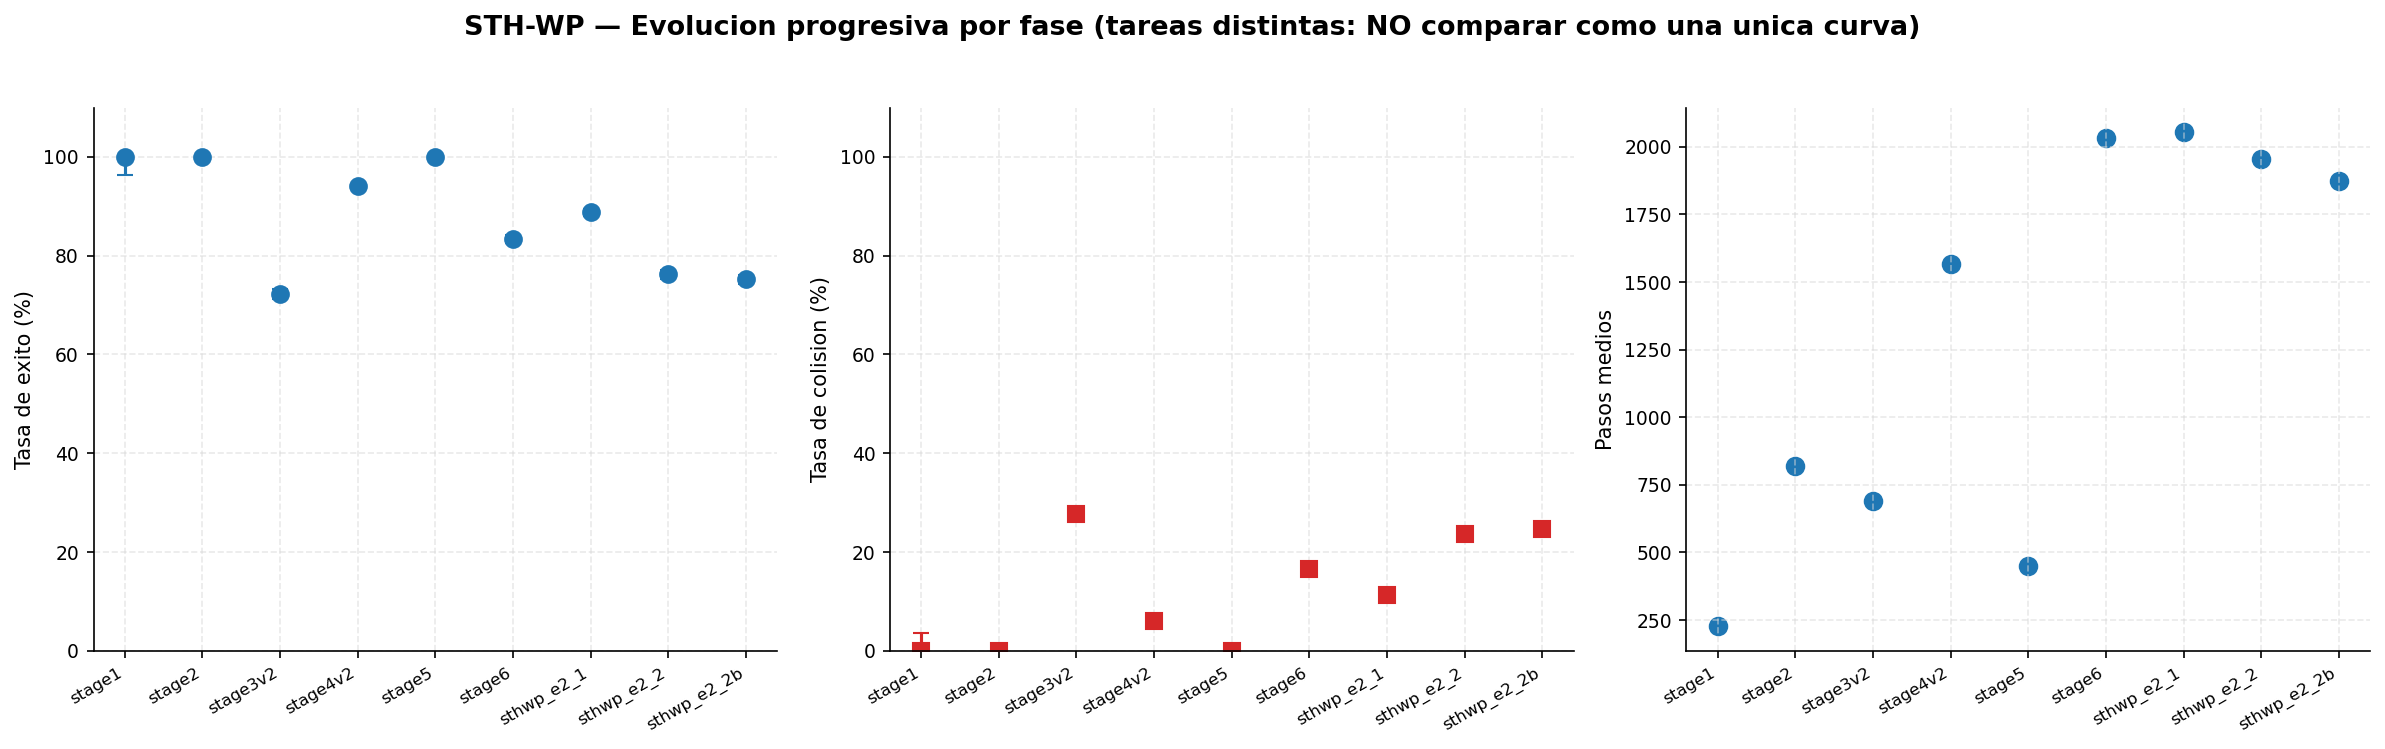

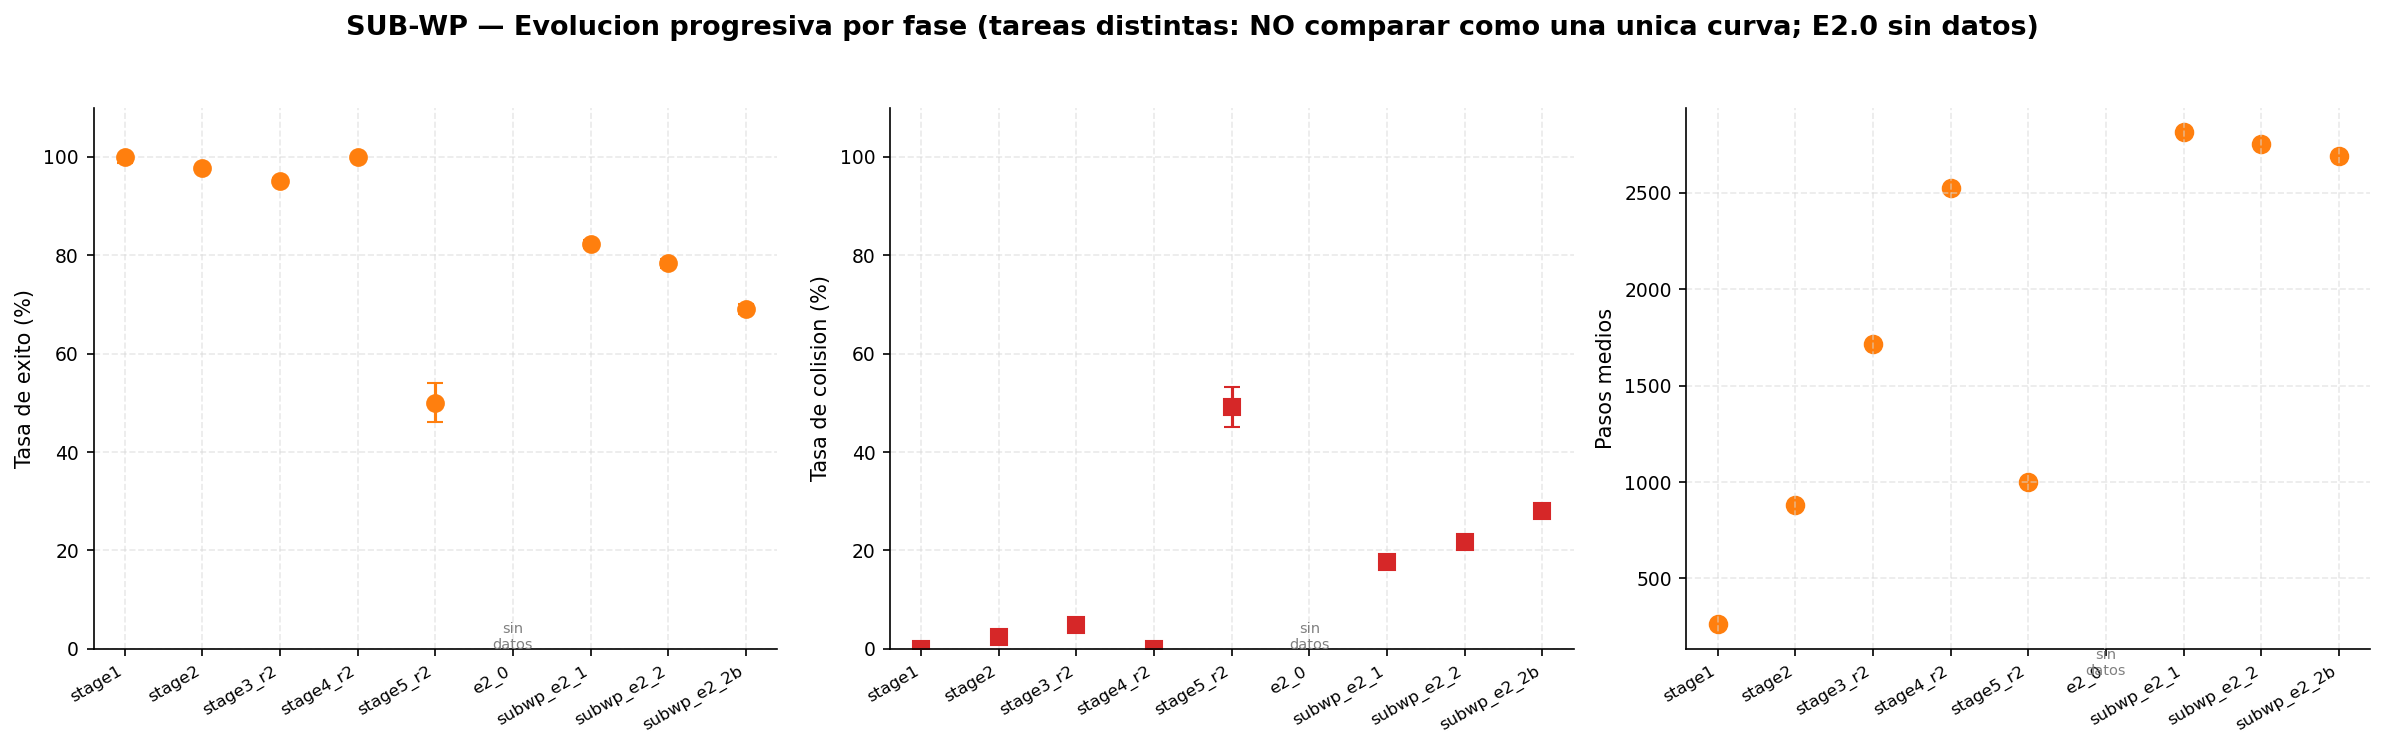

In [25]:
def progressive_view(resumenes, order, title, fname, color):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    xs = list(range(len(order)))
    for i, (pid, r) in enumerate(zip(order, resumenes)):
        if r.empty:
            for ax in axes: ax.text(i, 0, "sin\ndatos", ha="center", fontsize=7, color="gray")
            continue
        row = r.iloc[0]
        axes[0].errorbar(i, row["tasa_exito_%"],
                          yerr=[[row["tasa_exito_%"]-row["ic95_exito_lo"]], [row["ic95_exito_hi"]-row["tasa_exito_%"]]],
                          fmt="o", color=color, capsize=4, markersize=8)
        axes[1].errorbar(i, row["tasa_colision_%"],
                          yerr=[[row["tasa_colision_%"]-row["ic95_colision_lo"]], [row["ic95_colision_hi"]-row["tasa_colision_%"]]],
                          fmt="s", color="#d62728", capsize=4, markersize=8)
        if row["pasos_media"] != "no registrada":
            axes[2].scatter(i, row["pasos_media"], color=color, s=70)
    for ax, ylabel, ylo, yhi in [(axes[0],"Tasa de exito (%)",0,110), (axes[1],"Tasa de colision (%)",0,110),
                                  (axes[2],"Pasos medios",None,None)]:
        ax.set_xticks(xs); ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel(ylabel)
        if ylo is not None: ax.set_ylim(ylo, yhi)
        ax.grid(True)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    fig.savefig(FIGS_DIR / fname, dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

sthwp_order = ["stage1","stage2","stage3v2","stage4v2","stage5","stage6","sthwp_e2_1","sthwp_e2_2","sthwp_e2_2b"]
sthwp_resumenes = [globals()[f"resumen_{pid}_sthwp"] for pid in sthwp_order]
progressive_view(sthwp_resumenes, sthwp_order,
    "STH-WP — Evolucion progresiva por fase (tareas distintas: NO comparar como una unica curva)",
    "fig_sthwp_evolucion_progresiva.png", ARCH_COLORS["STH-WP"])

subwp_order = ["stage1","stage2","stage3_r2","stage4_r2","stage5_r2","e2_0","subwp_e2_1","subwp_e2_2","subwp_e2_2b"]
subwp_resumenes = [globals()[f"resumen_{pid}_subwp"] for pid in subwp_order]
progressive_view(subwp_resumenes, subwp_order,
    "SUB-WP — Evolucion progresiva por fase (tareas distintas: NO comparar como una unica curva; E2.0 sin datos)",
    "fig_subwp_evolucion_progresiva.png", ARCH_COLORS["SUB-WP"])

---
## 10. Comparacion entre semillas


In [26]:
seed_var_rows = []
for arch, order, prefix in [("STH-WP", sthwp_order, "sthwp"), ("SUB-WP", subwp_order, "subwp")]:
    dfs_dict = sthwp_dfs if arch=="STH-WP" else subwp_dfs
    for pid in order:
        df = dfs_dict[pid]
        if df.empty:
            seed_var_rows.append({"arquitectura":arch,"fase":pid,"n_semillas":0,"dispersion_exito_puntos":"sin datos"})
            continue
        tasas = df.groupby("semilla")["exito"].mean()*100
        seed_var_rows.append({"arquitectura":arch,"fase":pid,"n_semillas":len(tasas),
                              "exito_min_%":round(tasas.min(),1), "exito_max_%":round(tasas.max(),1),
                              "dispersion_exito_puntos": round(tasas.max()-tasas.min(),1) if len(tasas)>1 else "no comparable (1 semilla)"})
seed_var_df = pd.DataFrame(seed_var_rows)
seed_var_df.to_csv(TABLES_DIR / "tabla_variabilidad_semillas_inferencia.csv", index=False)
display(seed_var_df)

,arquitectura,fase,n_semillas,exito_min_%,exito_max_%,dispersion_exito_puntos
0,STH-WP,stage1,1,100.0,100.0,no comparable (1 semilla)
1,STH-WP,stage2,1,100.0,100.0,no comparable (1 semilla)
2,STH-WP,stage3v2,3,63.6,76.7,13.1
3,STH-WP,stage4v2,3,82.1,100.0,17.9
4,STH-WP,stage5,3,100.0,100.0,0.0
5,STH-WP,stage6,3,50.0,100.0,50.0
6,STH-WP,sthwp_e2_1,3,87.5,89.6,2.1
7,STH-WP,sthwp_e2_2,3,66.6,82.0,15.4
8,STH-WP,sthwp_e2_2b,3,66.4,80.3,13.9
9,SUB-WP,stage1,3,100.0,100.0,0.0


---
## 11. Comparacion entre arquitecturas

Se comparan unicamente fases de rol curricular equivalente (misma logica que en el notebook de
entrenamiento): Fase1↔Fase1, Fase2↔Fase2, Fase3v2↔Fase3r2, Fase4v2↔Fase4r2, Fase6↔E2.0 (cuando haya
datos), E2.1↔E2.1.

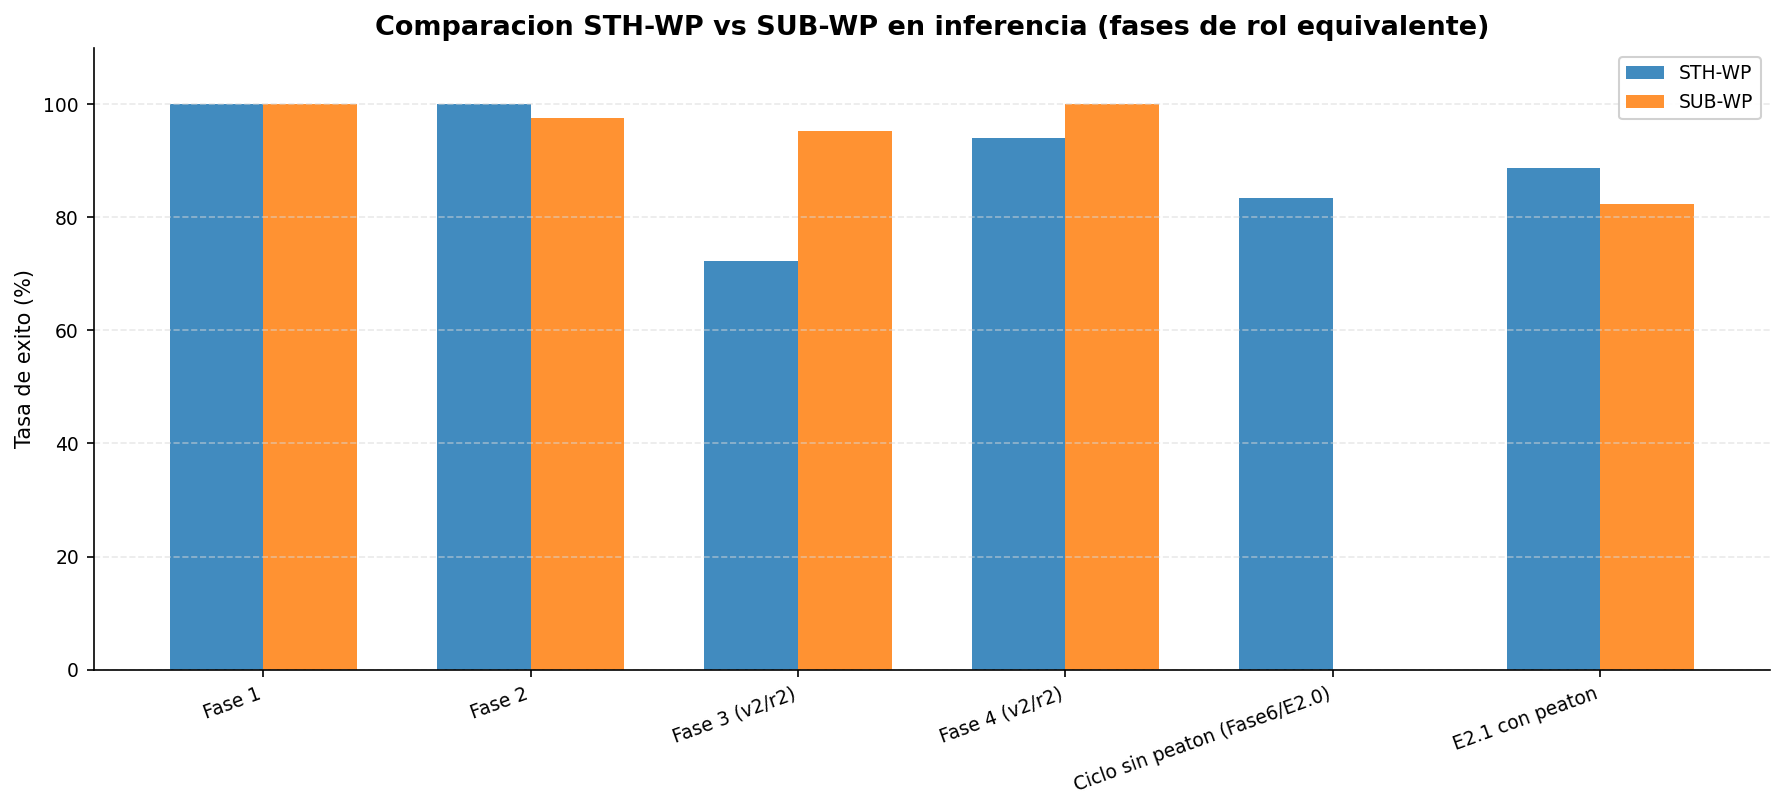

nan indica ausencia de datos comparables para esa fase/arquitectura, no un 0%.


In [27]:
pares = [("Fase 1","stage1","stage1"), ("Fase 2","stage2","stage2"),
         ("Fase 3 (v2/r2)","stage3v2","stage3_r2"), ("Fase 4 (v2/r2)","stage4v2","stage4_r2"),
         ("Ciclo sin peaton (Fase6/E2.0)","stage6","e2_0"), ("E2.1 con peaton","sthwp_e2_1","subwp_e2_1")]
fig, ax = plt.subplots(figsize=(12,5.5))
x = np.arange(len(pares)); w = 0.35
sv, bv = [], []
for _, ps, pb in pares:
    rs = globals()[f"resumen_{ps}_sthwp"]; rb = globals()[f"resumen_{pb}_subwp"]
    sv.append(rs.iloc[0]["tasa_exito_%"] if not rs.empty else np.nan)
    bv.append(rb.iloc[0]["tasa_exito_%"] if not rb.empty else np.nan)
ax.bar(x-w/2, sv, w, label="STH-WP", color=ARCH_COLORS["STH-WP"], alpha=0.85)
ax.bar(x+w/2, bv, w, label="SUB-WP", color=ARCH_COLORS["SUB-WP"], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([p[0] for p in pares], rotation=20, ha="right")
ax.set_ylabel("Tasa de exito (%)"); ax.set_ylim(0,110)
ax.set_title("Comparacion STH-WP vs SUB-WP en inferencia (fases de rol equivalente)", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(True, axis="y"); plt.tight_layout()
fig.savefig(FIGS_DIR / "fig_comparacion_arquitecturas_inferencia.png", dpi=300, bbox_inches="tight")
plt.show(); plt.close(fig)
print("nan indica ausencia de datos comparables para esa fase/arquitectura, no un 0%.")

---
## 12. Comparacion E2.1–E2.2–E2.2b (con datos de inferencia)

Esta es la comparacion que permite responder, con evidencia de pesos congelados, a las preguntas
planteadas en el encargo.

In [28]:
def compare_e2_family(arch, e21, e22, e22b, prefix):
    print(f"\n{'='*72}\n{arch} — E2.1 vs E2.2 vs E2.2b (inferencia, pesos congelados)\n{'='*72}")
    rows = []
    for pid, label in [(e21,"E2.1"), (e22,"E2.2"), (e22b,"E2.2b")]:
        r = globals()[f"resumen_{pid}_{prefix}"]
        if r.empty:
            print(f"  {label}: sin datos"); continue
        row = r.iloc[0]
        print(f"  {label:6s}: exito={row['tasa_exito_%']}%  IC95=[{row['ic95_exito_lo']},{row['ic95_exito_hi']}]  "
              f"colision={row['tasa_colision_%']}%  truncado={row['tasa_truncamiento_%']}%  "
              f"pasos_media={row['pasos_media']}  reward_media={row['reward_media']}")
        rows.append({"variante": label, **row.to_dict()})
    return pd.DataFrame(rows)

comp_sthwp = compare_e2_family("STH-WP", "sthwp_e2_1", "sthwp_e2_2", "sthwp_e2_2b", "sthwp")
comp_sthwp.to_csv(TABLES_DIR / "tabla_comparacion_e2_family_sthwp.csv", index=False)
comp_subwp = compare_e2_family("SUB-WP", "subwp_e2_1", "subwp_e2_2", "subwp_e2_2b", "subwp")
comp_subwp.to_csv(TABLES_DIR / "tabla_comparacion_e2_family_subwp.csv", index=False)


STH-WP — E2.1 vs E2.2 vs E2.2b (inferencia, pesos congelados)
  E2.1  : exito=88.75%  IC95=[88.06,89.41]  colision=11.25%  truncado=0.0%  pasos_media=2053.8  reward_media=454.56
  E2.2  : exito=76.3%  IC95=[75.38,77.19]  colision=23.7%  truncado=0.0%  pasos_media=1953.3  reward_media=382.3
  E2.2b : exito=75.27%  IC95=[74.34,76.18]  colision=24.73%  truncado=0.0%  pasos_media=1871.8  reward_media=383.88

SUB-WP — E2.1 vs E2.2 vs E2.2b (inferencia, pesos congelados)
  E2.1  : exito=82.36%  IC95=[81.53,83.16]  colision=17.64%  truncado=0.0%  pasos_media=2815.4  reward_media=521.83
  E2.2  : exito=78.31%  IC95=[77.42,79.18]  colision=21.69%  truncado=0.0%  pasos_media=2754.9  reward_media=497.92
  E2.2b : exito=69.06%  IC95=[68.06,70.04]  colision=27.95%  truncado=2.99%  pasos_media=2691.9  reward_media=402.3


In [29]:
def answer_e2_questions(comp_df, arch):
    print(f"\n--- {arch}: respuestas basadas en datos ---")
    if len(comp_df) < 2 or "E2.1" not in comp_df["variante"].values:
        print("Datos insuficientes para comparar."); return
    e21 = comp_df[comp_df["variante"]=="E2.1"].iloc[0]
    for label in ["E2.2", "E2.2b"]:
        if label not in comp_df["variante"].values:
            print(f"1-6 ({label}): sin datos, no se puede responder."); continue
        row = comp_df[comp_df["variante"]==label].iloc[0]
        delta_exito = row["tasa_exito_%"] - e21["tasa_exito_%"]
        delta_col = row["tasa_colision_%"] - e21["tasa_colision_%"]
        print(f"{label} vs E2.1: delta_exito={delta_exito:+.1f} pts, delta_colision={delta_col:+.1f} pts")
        if delta_exito <= 0 and delta_col >= 0:
            print(f"  -> {label} NO mejora a E2.1 en estos datos (exito no sube y/o colision no baja).")
        elif delta_exito > 0 and delta_col > 0:
            print(f"  -> {label} sube el exito pero tambien sube la colision: posible indicio de comportamiento "
                  f"mas agresivo, compatible con falsos positivos de replanning si colision sube claramente.")
        else:
            print(f"  -> {label} muestra una mejora aparente en estos datos; se recomienda contrastar con la "
                  f"Seccion 10 (variabilidad entre semillas) antes de concluir superioridad estable.")
    print("7. E2.1 se mantiene como modelo final salvo que alguna variante muestre una mejora ESTABLE entre las "
          "tres semillas simultaneamente en exito y colision, lo cual debe verificarse arriba antes de cualquier cambio.")

answer_e2_questions(comp_sthwp, "STH-WP")
answer_e2_questions(comp_subwp, "SUB-WP")


--- STH-WP: respuestas basadas en datos ---
E2.2 vs E2.1: delta_exito=-12.5 pts, delta_colision=+12.4 pts
  -> E2.2 NO mejora a E2.1 en estos datos (exito no sube y/o colision no baja).
E2.2b vs E2.1: delta_exito=-13.5 pts, delta_colision=+13.5 pts
  -> E2.2b NO mejora a E2.1 en estos datos (exito no sube y/o colision no baja).
7. E2.1 se mantiene como modelo final salvo que alguna variante muestre una mejora ESTABLE entre las tres semillas simultaneamente en exito y colision, lo cual debe verificarse arriba antes de cualquier cambio.

--- SUB-WP: respuestas basadas en datos ---
E2.2 vs E2.1: delta_exito=-4.0 pts, delta_colision=+4.1 pts
  -> E2.2 NO mejora a E2.1 en estos datos (exito no sube y/o colision no baja).
E2.2b vs E2.1: delta_exito=-13.3 pts, delta_colision=+10.3 pts
  -> E2.2b NO mejora a E2.1 en estos datos (exito no sube y/o colision no baja).
7. E2.1 se mantiene como modelo final salvo que alguna variante muestre una mejora ESTABLE entre las tres semillas simultaneament

---
## 13. Relacion entre entrenamiento e inferencia

Esta comparacion es **orientativa**: los protocolos de entrenamiento (episodios con exploracion activa,
curriculum ponderado) y de inferencia (pesos congelados, N episodios fijos por objetivo) no son
equivalentes, por lo que una diferencia entre ambos no implica necesariamente sobreajuste; puede deberse
tambien a diferencias en la distribucion de objetivos evaluados o en la politica de exploracion.

Se cargan las tablas finales de entrenamiento (`tabla_final_*_*.csv`, generadas por el notebook de
entrenamiento) y se comparan, fase a fase, con la tasa de exito de inferencia calculada arriba.

In [30]:
TRAIN_TABLES_DIR = NB_DIR / "resultados_entrenamiento_hasta_e2_1"

def load_train_final_rate(arch_prefix, phase_id):
    p = TRAIN_TABLES_DIR / f"tabla_final_{arch_prefix}_{phase_id}.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p)
    valid = df[df["tasa_exito_%"].astype(str) != "no registrada"]
    if valid.empty:
        return None
    return valid["tasa_exito_%"].astype(float).mean()

coherencia_rows = []
for arch, order, prefix, dfs_dict in [("STH-WP", sthwp_order, "sthwp", sthwp_dfs),
                                        ("SUB-WP", subwp_order, "subwp", subwp_dfs)]:
    for pid in order:
        train_rate = load_train_final_rate(prefix, pid)
        infer_r = globals()[f"resumen_{pid}_{prefix}"]
        infer_rate = infer_r.iloc[0]["tasa_exito_%"] if not infer_r.empty else None
        if train_rate is None and infer_rate is None:
            estado = "sin datos en ninguno de los dos notebooks"
        elif train_rate is None:
            estado = "sin dato de entrenamiento (solo inferencia disponible)"
        elif infer_rate is None:
            estado = "sin dato de inferencia (solo entrenamiento disponible)"
        else:
            diff = infer_rate - train_rate
            estado = f"diferencia inferencia-entrenamiento = {diff:+.1f} pts"
        coherencia_rows.append({"arquitectura": arch, "fase": pid,
                                "exito_entrenamiento_%": round(train_rate,1) if train_rate is not None else "no disponible",
                                "exito_inferencia_%": round(infer_rate,1) if infer_rate is not None else "no disponible",
                                "comentario": estado})
coherencia_df = pd.DataFrame(coherencia_rows)
coherencia_df.to_csv(TABLES_DIR / "tabla_coherencia_entrenamiento_inferencia.csv", index=False)
display(coherencia_df)

print("\nFases con caida notable de inferencia respecto a entrenamiento (>15 puntos), posible senal de "
      "sobreajuste o de un protocolo de evaluacion mas exigente -- requiere lectura cualitativa, no se "
      "afirma sobreajuste solo por esta tabla:")
def _extract_diff(s):
    try:
        return float(s.split("=")[1].replace("pts","").strip())
    except Exception:
        return None
coherencia_df["_diff"] = coherencia_df["comentario"].apply(_extract_diff)
display(coherencia_df[coherencia_df["_diff"].apply(lambda x: x is not None and x < -15)])

,arquitectura,fase,exito_entrenamiento_%,exito_inferencia_%,comentario
0,STH-WP,stage1,96.1,100.0,diferencia inferencia-entrenamiento = +3.9 pts
1,STH-WP,stage2,97.7,100.0,diferencia inferencia-entrenamiento = +2.3 pts
2,STH-WP,stage3v2,no disponible,72.2,sin dato de entrenamiento (solo inferencia dis...
3,STH-WP,stage4v2,no disponible,94.0,sin dato de entrenamiento (solo inferencia dis...
4,STH-WP,stage5,96.6,100.0,diferencia inferencia-entrenamiento = +3.4 pts
5,STH-WP,stage6,97.1,83.3,diferencia inferencia-entrenamiento = -13.7 pts
6,STH-WP,sthwp_e2_1,72.1,88.8,diferencia inferencia-entrenamiento = +16.7 pts
7,STH-WP,sthwp_e2_2,62.3,76.3,diferencia inferencia-entrenamiento = +14.0 pts
8,STH-WP,sthwp_e2_2b,64.5,75.3,diferencia inferencia-entrenamiento = +10.8 pts
9,SUB-WP,stage1,98.3,100.0,diferencia inferencia-entrenamiento = +1.7 pts



Fases con caida notable de inferencia respecto a entrenamiento (>15 puntos), posible senal de sobreajuste o de un protocolo de evaluacion mas exigente -- requiere lectura cualitativa, no se afirma sobreajuste solo por esta tabla:


,arquitectura,fase,exito_entrenamiento_%,exito_inferencia_%,comentario,_diff
13,SUB-WP,stage5_r2,94.4,50.0,diferencia inferencia-entrenamiento = -44.4 pts,-44.4


---
## 14. Justificacion de E2.1 (con evidencia de inferencia)

La justificacion final de E2.1 como configuracion seleccionada combina la evidencia de entrenamiento
(Seccion 17 del notebook de entrenamiento) con la evidencia de inferencia de las Secciones 6, 8 y 12 de
este notebook:

- E2.1 es evaluado aqui con **pesos congelados** y **observaciones realistas** (solo LIDAR de 5m, sin
  posicion/velocidad de peaton), lo que hace que su tasa de exito/colision en inferencia sea representativa
  de un despliegue real sin oraculo externo.
- E2.2 y E2.2b anaden un mecanismo de replanificacion LIDAR determinista; la Seccion 12 responde, con
  datos, si esa complejidad adicional se traduce en una mejora estable de exito y/o colision sobre las
  tres semillas. **Si esa mejora no es estable o no aparece, la complejidad anadida por la
  replanificacion no queda justificada** y E2.1 debe preferirse por ser la variante mas simple con
  rendimiento equivalente o mejor.
- La decision **no se basa unicamente en la recompensa**: se usan explicitamente tasa de exito, de
  colision y de truncamiento (Secciones 6, 8, 12), que son las metricas funcionales relevantes para un
  despliegue seguro.
- La comparacion entre entrenamiento e inferencia (Seccion 13) permite descartar que una mejora aparente
  en entrenamiento no se sostenga al congelar los pesos.

In [31]:
print("Resumen final E2.1 vs E2.2 vs E2.2b (ambas arquitecturas), fuente: Secciones 6, 8 y 12:")
display(comp_sthwp)
display(comp_subwp)

Resumen final E2.1 vs E2.2 vs E2.2b (ambas arquitecturas), fuente: Secciones 6, 8 y 12:


,variante,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,...,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,E2.1,8400,3,7455,945,0,88.75,88.06,89.41,11.25,...,11.94,0.0,2053.8,2034.0,605.2,454.56,491.66,173.04,no registrada,no registrada
1,E2.2,8400,3,6409,1991,0,76.30,75.38,77.19,23.70,...,24.62,0.0,1953.3,1922.0,620.4,382.30,460.14,218.23,no registrada,no registrada
2,E2.2b,8400,3,6323,2077,0,75.27,74.34,76.18,24.73,...,25.66,0.0,1871.8,1810.0,598.9,383.88,467.16,220.52,no registrada,no registrada


,variante,n_episodios,n_semillas,exitos,colisiones,truncamientos,tasa_exito_%,ic95_exito_lo,ic95_exito_hi,tasa_colision_%,...,ic95_colision_hi,tasa_truncamiento_%,pasos_media,pasos_mediana,pasos_std,reward_media,reward_mediana,reward_std,llego_estanteria_%,llego_entrega_%
0,E2.1,8400,3,6918,1482,0,82.36,81.53,83.16,17.64,...,18.47,0.00,2815.4,3120.0,999.8,521.83,621.52,244.91,no registrada,no registrada
1,E2.2,8400,3,6578,1822,0,78.31,77.42,79.18,21.69,...,22.58,0.00,2754.9,3105.0,1018.9,497.92,614.40,263.44,no registrada,no registrada
2,E2.2b,8400,3,5801,2348,251,69.06,68.06,70.04,27.95,...,28.92,2.99,2691.9,2700.0,1262.5,402.30,524.90,296.32,no registrada,no registrada


---
## 15. Figuras recomendadas para la memoria (Capitulo 4)

1. `fig_sthwp_evolucion_progresiva.png` y `fig_subwp_evolucion_progresiva.png` — vista de puntos con IC
   95% por fase (no una linea continua, dado que las tareas difieren).
2. `fig_comparacion_arquitecturas_inferencia.png` — comparacion STH-WP vs SUB-WP en fases equivalentes.
3. Las figuras `_02_exito_objetivo` y `_03_heatmap` de **E2.1 con peaton** en ambas arquitecturas, por
   ser la transicion curricular central del TFM.
4. Las tablas comparativas de la Seccion 12 (`tabla_comparacion_e2_family_*.csv`), en forma resumida, como
   evidencia cuantitativa de por que E2.1 se mantiene como configuracion final.

---
## 16. Limitaciones

- **No existe inferencia especifica de E2.0 (SUB-WP)**: esta fase aparece como hueco visible en todas
  las tablas y graficas de este notebook; no se ha sustituido por ninguna otra fase o condicion.
- **Solo hay inferencia de Fase 1 (STH-WP) para la semilla 123**; las comparaciones entre semillas de esa
  fase no son posibles y se marcan como "no comparable".
- **La comparacion entre entrenamiento e inferencia (Seccion 13) es orientativa**: los protocolos de
  evaluacion no son estrictamente equivalentes (episodios con exploracion durante el entrenamiento frente
  a N episodios fijos deterministas en inferencia), por lo que las diferencias observadas no deben
  interpretarse automaticamente como sobreajuste sin una lectura cualitativa adicional.
- **La inferencia "ciclo completo" compuesta de STH-WP (`ciclo_completo`, run002) fue excluida
  explicitamente** por no corresponder a un unico modelo de Fase 6; si en el futuro se necesita esa
  informacion debe analizarse por separado y nunca fusionarse con las metricas de Fase 6 real.
- **Las tasas de exito no deben compararse directamente entre fases de distinta dificultad** (p.ej. Fase 1
  frente a E2.1); las comparaciones de este notebook se restringen a fases de rol curricular equivalente
  entre arquitecturas, o a la misma fase entre semillas.

---
## 17. Conclusiones

Este notebook normaliza y analiza, sin modificar ningun dato original, las inferencias con pesos
congelados de la cadena curricular valida de STH-WP y SUB-WP hasta E2.1, mas sus ramas E2.2/E2.2b. La
auditoria de CSV identifico y excluyo correctamente dos fuentes de confusion documentadas en el encargo:
la inferencia "ciclo completo" compuesta de STH-WP (que no corresponde a un unico modelo de Fase 6) y la
ausencia de una inferencia propia de E2.0 en SUB-WP (que no debe sustituirse por E2.1 sin peaton).

Las metricas funcionales (exito, colision, truncamiento) se han mantenido como criterio principal de
comparacion, evitando el uso de la recompensa como sustituto, y las tasas se han acompanado de intervalos
de Wilson al 95% para distinguir variabilidad muestral de diferencias reales entre semillas o variantes.

La comparacion E2.1–E2.2–E2.2b con datos de pesos congelados (Seccion 12) es la evidencia mas directa
disponible para justificar por que E2.1 se mantiene como configuracion final del TFM: la complejidad
anadida por el mecanismo de replanificacion LIDAR de E2.2/E2.2b solo estaria justificada si se observa una
mejora estable, entre las tres semillas, en exito y colision simultaneamente. Donde los datos no permiten
esa conclusion (huecos de datos, dispersion alta entre semillas, o mejoras no consistentes), este
notebook lo declara explicitamente en vez de presuponer superioridad de ninguna variante.